# House Price Prediction (Notebook Untuk Eksperimen) 
Dataset: [House Prices - Advanced Regression Techniques (Kaggle)](https://www.kaggle.com/c/house-prices-advanced-regression-techniques)

Notebook ini digunakan sebagai tempat eksperimen untuk memahami permasalahan bisnis sampai mendapatkan model yg bagus, dan paham kenapa model tersebut bagus. Setelah itu, hasil dari notebook ini akan disusun ulang menjadi modular code di `src/`. Dalam melakukan eksperimen, saya menggunakan **CRISP-DM** karena merupakan framework standart Data Science Life Cycle. Berikut adalah urutan kerjanya:

| # | Langkah | Bagian |
|---|---|---|
| 0 | Business Understanding | 0 |
| 0.1 | Setup & reproducibility | 0.1 |
| 1 | Load data | 1 |
| 2 | Pre-processing **deterministik** (tipe data, cara baca `NA`, duplikat) | 2 |
| 3 | **Split train/holdout** | 3 |
| 4 | Data cleaning + EDA | 4 |
| 5 | Preprocessing pipeline + experiment design | 5 |
| 6 | Build model: baseline → regularized → ensemble | 6 |
| 7 | Evaluasi CV + checkpoint sebelum tuning | 7 |
| 8 | Hyperparameter tuning menggunakan CV di train | 8 |
| 9 | **Champion candidate gate** | 9 |
| 10 | Advanced error reduction experiments | 10 |
| 11 | **Final candidate decision + evaluasi Holdout** | 11 |
| 12 | Interpretasi final candidate model | 12 |
| 13 | Menyesuaikan model dengan kontrak API untuk production champion | 13 |
| 14 | Business insights, limitations, conclusion | 14 |
| 15 | Handoff hasil eksperimen ke production | 15 |


---

## 0. Business Understanding

### Business Context

Dataset **Ames Housing** adalah data transaksi penjualan rumah pada periode 2006–2010 sebanyak **1460 transaksi dan 79 fitur** di kota Ames, Iowa. Target yang akan diprediksi adalah `SalePrice`.

### Problem statement

Metode dalam memprediksi harga rumah sangat penting bagi buyer, seller, agen properti, platform listing, maupun Bank/KPR, karena jika harga diberikan terlalu tinggi maka akan sulit terjual, sedangkan jika terlalu murah akan kehilangan potensi keuntungan yang didapatkan. Sehingga penentuan harga rumah yang berbasis data sangat diperlukan untuk mendapatkan estimasi harga yang lebih optimal.

### Stakeholder yang menggunakan

| Pengguna | Kebutuhannya |
|---|---|
| Buyer | Mendapatkan estimasi harga rumah yang optimal |
| Seller | Menjadi estimasi nilai jual yang optimal |
| Agen properti | Patokan harga listing sebelum bertemu penjual |
| Platform listing | Estimasi otomatis di halaman properti |
| Bank / KPR | Pembanding cepat untuk nilai agunan |

### Goals

Membuat model yang memprediksi `SalePrice` dari atribut rumah yang tersedia, dengan target **RMSE pada skala `log1p(SalePrice)` ≤ 0.15** dan **R² minimal 80%**. Selain itu, membangun sistem MLOps yang dapat mengelola dan mempromosikan model terbaik berdasarkan quality gate, menyediakan UI untuk melakukan prediksi, serta dapat di-deploy.

### Metrik sukses

| Metrik | Buat siapa | Kenapa |
|---|---|---|
| **RMSE pada `log1p(SalePrice)`** (metrik utama) | teknis | Lebih memperhatikan perbedaan relatif antar harga rumah sehingga perbedaan harga yang sangat besar tidak terlalu mendominasi error. |
| **MAE dalam USD** | bisnis | Agar besar rata-rata kesalahan dapat dipahami langsung dalam satuan harga rumah. |
| **R²** | teknis | Menunjukkan seberapa besar keragaman harga yang berhasil dijelaskan oleh model. |

**Quality gate** (ambang minimum sebelum model boleh masuk registry) belum ditetapkan sekarang — akan dipatok setelah kita punya baseline di Bagian 6, supaya angkanya berdasar hasil eksperimen, bukan karangan.

### Non-goals

- **Tidak** mengejar peringkat leaderboard Kaggle.

### 0.1. Setup

Pada bagian ini dilakukan setup awal eksperimen untuk menjaga **reproducibility**, seperti standardisasi environment, `random_state`, path, dan konfigurasi yang digunakan selama eksperimen.

In [1]:
# Library
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_STATE = 42
HOLDOUT_SIZE = 0.2
np.random.seed(RANDOM_STATE)

# Path project
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

# Tampilan
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

warnings.filterwarnings("ignore", category=FutureWarning)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATA_RAW     :", DATA_RAW)
print("RANDOM_STATE :", RANDOM_STATE)

PROJECT_ROOT : /Users/gidion/Downloads/task_mlops/house_price_prediction
DATA_RAW     : /Users/gidion/Downloads/task_mlops/house_price_prediction/data/raw
RANDOM_STATE : 42


## 1. Load Data

Pada tahap ini untuk nge-load data dan melihat apakah berhasil di ambil atau tidak. Lalu melihat jumlah baris dan kolomnya dan melihat 3 data teratas.

In [2]:
train_raw = pd.read_csv(DATA_RAW / "train.csv")
test_raw = pd.read_csv(DATA_RAW / "test.csv")

print("train.csv :", train_raw.shape,)
print("test.csv  :", test_raw.shape)
print()

selisih = sorted(set(train_raw.columns) - set(test_raw.columns))
print("Kolom yang cuma ada di train.csv :", selisih)
print()

train_raw.head(3)

train.csv : (1460, 81)
test.csv  : (1459, 80)

Kolom yang cuma ada di train.csv : ['SalePrice']



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


Data berhasil di load dan memiliki 2 raw data:
 - `train.csv:` Berisi 1.460 baris dengan 81 kolom
 - `test.csv:` Berisi 1.459 baris dan 80 kolom (tidak include kolom target `SalePice`). Untuk test.csv hanya diguanakn utk submission kaggle, sehingga tidak digunakan pada project ini.

Project ini hanya akan menggunakan train.csv

## 2. Pre-processing Deterministik
Pada tahap ini saya melakukan global cleaning yang bisa di terapkan sebelum split train/val/test, yaitu cleaning yang tidak mengubah nilai statistiknya data (deterministik) sehingga tidak akan terjadi data leakage. Beirikut yang saya lakukan pada tahap ini:

1. Cek Type Data
2. Mengecek Nilai `NA` yang Memiliki Arti
3. Investigasi Missing Value
4. Cek Duplikat
5. Pemeriksaan Nilai & Konsistensi Data

### 2.1 Audit Tipe Data

In [3]:
print(f"Cek Jumlah Kolom Berdasarkan Tipe Data:")
print(train_raw.dtypes.value_counts().to_string())
print()

print("Kolom numerik:")
print(train_raw.select_dtypes(include="number").columns.tolist())

print("\nKolom kategorikal:")
print(train_raw.select_dtypes(include="object").columns.tolist())

Cek Jumlah Kolom Berdasarkan Tipe Data:
object     43
int64      35
float64     3

Kolom numerik:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Kolom kategorikal:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'H

In [4]:
# Mengecek apakah ada kolom teks yang sebenarnya numerik
kolom_teks = train_raw.select_dtypes(include="object").columns
tersangka_angka = []

for kol in kolom_teks:
    isi = train_raw[kol].dropna()

    # Menghitung proporsi nilai yang dapat dibaca sebagai angka
    porsi_angka = pd.to_numeric(
        isi,
        errors="coerce"
    ).notna().mean()

    # Jika lebih dari 50% nilainya berupa angka
    if porsi_angka > 0.5:
        tersangka_angka.append(
            (kol, round(porsi_angka, 3))
        )

print("Kolom teks yang mayoritas isinya angka:")
print("  ", tersangka_angka if tersangka_angka else "tidak ada")
print()

Kolom teks yang mayoritas isinya angka:
   tidak ada



**Hasil Audit Tipe Data:**

Dataset memiliki 43 kolom `object`, 35 kolom `int64`, dan 3 kolom `float64`. Pada pemeriksaan awal ini, saya tidak menemukan kolom bertipe teks yang mayoritas nilainya adalah numerik. Tetapi, ada beberapa kolom yg isinya angka seperti `MSSubClass` dan `MoSold` tetapi secara makna adalah kategorikal karena mempresentasikan kode/kategori. Hal ini akan di eksplore lebih jauh pada tahap EDA.

Namun, beberapa kolom numerik seperti `MSSubClass` dan `MoSold` perlu diperhatikan karena tipe datanya numerik secara teknis, tetapi nilainya dapat merepresentasikan kode/kategori. Hal ini akan ditinjau lebih lanjut pada tahap EDA dan preprocessing.

### 2.2 Mengecek Nilai `NA` yang Memiliki Arti

Pada tahap ini, saya mengecek apakah nilai `NA` pada suatu kolom memiliki arti khusus berdasarkan dokumentasi `data_description.txt` yang tersedia pada dataset Kaggle.

In [5]:
import re

# Menghitung jumlah missing value pada setiap kolom
missing = train_raw.isna().sum()

# Hanya mengambil kolom yang memiliki missing value,
# lalu mengurutkannya dari jumlah missing terbanyak
missing = missing[missing > 0].sort_values(ascending=False)

# Membuat tabel ringkasan missing value dengan format:
# - n_missing = jumlah nilai yang missing
# - pct        = persentase missing terhadap seluruh baris
peta_missing = pd.DataFrame({
    "n_missing": missing,
    "pct": (missing / len(train_raw) * 100).round(1),
})


# Membaca data_description.txt sebagai kamus/dokumentasi dataset,
# karena file tersebut digunakan untuk mengetahui apakah "NA" memiliki arti atau enggak
# pada suatu kolom, misalnya NA = tidak memiliki fitur tersebut.
kamus = (DATA_RAW / "data_description.txt").read_text(
    encoding="utf-8",
    errors="ignore"
)

# membuat fungsi utk mencari apakah kolom memiliki nilai "NA" yg punya arti khusus
def arti_na(kolom: str) -> str:
    
    # Mencari blok dokumentasi yang sesuai dengan nama kolom
    blok = re.search(
        rf"^{kolom}:.*?(?=^\w+:|\Z)",
        kamus,
        re.S | re.M
    )

    # Jika kolom tidak ditemukan di kamus
    if not blok:
        return "-"

    # Mencari keterangan untuk level "NA"
    baris_na = re.search(
        r"^\s+NA\s+(.+)$",
        blok.group(0),
        re.M
    )

    # Mengembalikan arti "NA" jika ditemukan
    return baris_na.group(1).strip() if baris_na else "-"


# Menambahkan informasi arti "NA" berdasarkan data_description.txt
# untuk setiap kolom yang memiliki missing value
peta_missing["arti_NA_di_kamus"] = [
    arti_na(k) for k in peta_missing.index
]


# Mengelompokkan missing value:
# - "structural" = NA memiliki arti khusus menurut dokumentasi
# - "perlu diperiksa" = belum ditemukan arti khusus di dokumentasi
peta_missing["jenis"] = np.where(
    peta_missing["arti_NA_di_kamus"] != "-",
    "structural",
    "perlu diperiksa"
)


# Untuk menampilkan peta missing value
print("Pemeriksaan Missing Value:")
print(peta_missing.to_string())

Pemeriksaan Missing Value:
              n_missing   pct arti_NA_di_kamus            jenis
PoolQC             1453  99.5          No Pool       structural
MiscFeature        1406  96.3             None       structural
Alley              1369  93.8  No alley access       structural
Fence              1179  80.8         No Fence       structural
MasVnrType          872  59.7                -  perlu diperiksa
FireplaceQu         690  47.3     No Fireplace       structural
LotFrontage         259  17.7                -  perlu diperiksa
GarageType           81   5.5        No Garage       structural
GarageYrBlt          81   5.5                -  perlu diperiksa
GarageFinish         81   5.5        No Garage       structural
GarageQual           81   5.5        No Garage       structural
GarageCond           81   5.5        No Garage       structural
BsmtFinType2         38   2.6      No Basement       structural
BsmtExposure         38   2.6      No Basement       structural
BsmtFinType1 

Sebagian besar missing value pada dataset memiliki arti khusus berdasarkan dokumentasi, seperti `PoolQC` yang berarti **No Pool**, `Alley` yang berarti **No alley access**, dan beberapa kolom garage/basement yang berarti fasilitas tersebut memang tidak tersedia.

Sementara itu, beberapa kolom seperti `MasVnrType`, `LotFrontage`, `GarageYrBlt`, `MasVnrArea`, dan `Electrical` belum memiliki arti `NA` yang jelas dari dokumentasi sehingga perlu diperiksa lebih lanjut pada tahap **Data Cleaning dan EDA**.

### 2.3 Investigasi Missing Value

Pada tahap ini, saya mengecek kembali beberapa missing value yang belum jelas penyebabnya, untuk memastikan apakah nilai tersebut benar-benar missing atau memiliki arti tertentu sebelum dilakukan cleaning.

In [6]:
# 1. Mengecek apakah baris yang GarageType-nya kosong juga memiliki GarageYrBlt yang kosong.
# Jika jumlahnya sama, ada indikasi bahwa GarageYrBlt kosong karena rumah tersebut memang tidak memiliki garage.
sama = (
    train_raw["GarageType"].isna() &
    train_raw["GarageYrBlt"].isna()
).sum()

print("Mengecek GarageYrBlt:")

# Menampilkan jumlah missing pada masing-masing kolom
print(f"GarageType kosong  : {train_raw['GarageType'].isna().sum()}")
print(f"GarageYrBlt kosong : {train_raw['GarageYrBlt'].isna().sum()}")

# Menampilkan jumlah baris yang kedua kolomnya sama-sama kosong
print(f"kosong bersamaan   : {sama}")
print("-"*50)

# 2. Membaca ulang file csv utk melihat nilai yg benar-benar tersimpan dan membandingkannya dengan hasil pembacaan train_raw.
train_mentah = pd.read_csv(
    DATA_RAW / "train.csv",
    keep_default_na=False,
    na_values=[""]
)

print("\nMengecek MasVnrType:")

# Melihat distribusi MasVnrType setelah dibaca dengan pengaturan default pandas
print("Dibaca dengan pengaturan default pandas:")
print(
    train_raw["MasVnrType"]
    .value_counts(dropna=False)
    .to_string()
)
print()

# Membandingkan dengan data yang dibaca tanpa konversi default pandas
print("Dibaca apa adanya dari file:")
print(
    train_mentah["MasVnrType"]
    .value_counts(dropna=False)
    .to_string()
)

Mengecek GarageYrBlt:
GarageType kosong  : 81
GarageYrBlt kosong : 81
kosong bersamaan   : 81
--------------------------------------------------

Mengecek MasVnrType:
Dibaca dengan pengaturan default pandas:
MasVnrType
NaN        872
BrkFace    445
Stone      128
BrkCmn      15

Dibaca apa adanya dari file:
MasVnrType
None       864
BrkFace    445
Stone      128
BrkCmn      15
NA           8


**Interpretasi**

- `GarageYrBlt` memiliki 81 missing dan seluruhnya berada pada baris yang `GarageType` nya juga missing. Ini menunjukkan bahwa missing pada `GarageYrBlt` kemungkinan besar bersifat **structural**, yaitu rumah tersebut memang tidak memiliki garage.

- Pada `MasVnrType`, pandas membaca **872 nilai sebagai `NaN`**, sedangkan pembacaan langsung dari file menunjukkan **864 nilai `None` dan 8 nilai `NA`**. Artinya, sebagian besar `NaN` berasal dari nilai `None` yang dikonversi otomatis oleh pandas, sehingga perlu diperhatikan saat menentukan strategi cleaning.

### 2.4 Cek duplikat

In [7]:
# Mengecek apakah ada baris yang duplikat
print("Cek Data Duplikat")
print(f"Baris duplikat : {train_raw.duplicated().sum()}")
print()

# Mengecek apakah Id sebagai identifier unik
print("Cek Id Duplikat (identifier)")
print(f"Id duplikat    : {train_raw['Id'].duplicated().sum()}")
print(f"Id unik        : {train_raw['Id'].nunique()} dari {len(train_raw)}")

Cek Data Duplikat
Baris duplikat : 0

Cek Id Duplikat (identifier)
Id duplikat    : 0
Id unik        : 1460 dari 1460


Tidak ditemukan **baris duplikat** pada dataset, dengan jumlah duplikat sebanyak 0 baris. Kolom `Id` juga tidak memiliki nilai duplikat dan seluruh **1460 Id bersifat unik**, sehingga tidak ada indikasi data yang tercatat dua kali berdasarkan pemeriksaan ini.

### 2.5 Pemeriksaan Nilai & Konsistensi Data

Pada tahap ini dilakukan pemeriksaan untuk memastikan nilai dalam dataset berada pada kondisi yang masuk akal dan konsisten, baik dalam satu kolom maupun antar kolom.

Pemeriksaan meliputi nilai yang tidak masuk akal, kontradiksi antar kolom, konsistensi data teks, serta pola tertentu yang perlu diperhatikan sebelum masuk ke tahap **Data Cleaning dan EDA**.

In [8]:
print("1. Mengecek Nilai Mustahil (tidak masuk akal):")

# Kolom yang secara logika tidak seharusnya memiliki nilai nol atau negatif
kolom_harus_positif = [
    "LotArea",
    "GrLivArea",
    "SalePrice",
    "YearBuilt",
    "YearRemodAdd"
]

for kol in kolom_harus_positif:

    # Menampilkan nilai minimum, maksimum,
    # dan jumlah nilai yang <= 0
    print(
        f"  {kol:<14} "
        f"min={train_raw[kol].min():>8}  "
        f"max={train_raw[kol].max():>8}  "
        f"jumlah <= 0: {int((train_raw[kol] <= 0).sum())}"
    )


print()
print("2. Mengecek Nilai yg kontra antar kolom")

# Mengecek apakah tahun renovasi lebih kecil daripada tahun rumah pertama kali dibangun
print(
    f"  YearRemodAdd < YearBuilt        : "
    f"{int((train_raw['YearRemodAdd'] < train_raw['YearBuilt']).sum())}"
)

# Mengecek apakah ada tahun pembangunan garage yang lebih besar dari tahun 2010
print(
    f"  GarageYrBlt > 2010 (masa depan) : "
    f"{int((train_raw['GarageYrBlt'] > 2010).sum())}"
)

# Mengecek apakah GrLivArea konsisten dengan jumlah luas lantai 1, lantai 2, dan LowQualFinSF
print(
    f"  GrLivArea != 1st + 2nd + LowQual : "
    f"{int((
        train_raw['GrLivArea']
        != train_raw['1stFlrSF']
        + train_raw['2ndFlrSF']
        + train_raw['LowQualFinSF']
    ).sum())}"
)

# Mengecek apakah TotalBsmtSF konsisten dengan jumlah basement finished 1, finished 2, dan unfinished
print(
    f"  TotalBsmtSF != Fin1 + Fin2 + Unf : "
    f"{int((
        train_raw['TotalBsmtSF']
        != train_raw['BsmtFinSF1']
        + train_raw['BsmtFinSF2']
        + train_raw['BsmtUnfSF']
    ).sum())}"
)


print()
print("3. Mengecek Konsistensi Teks")

# Mengambil semua kolom bertipe object
kolom_teks = train_raw.select_dtypes(include="object").columns


# Mencari kolom yang memiliki spasi berlebih di awal atau akhir nilai
spasi = [
    c for c in kolom_teks
    if (
        train_raw[c].dropna().astype(str)
        != train_raw[c].dropna().astype(str).str.strip()
    ).any()
]


# Mencari kolom yang memiliki perbedaan kapitalisasi,
# misalnya "Stone" dan "stone" dianggap berbeda
kapital = [
    c for c in kolom_teks
    if (
        train_raw[c].dropna().astype(str).nunique()
        != train_raw[c].dropna().astype(str).str.lower().nunique()
    )
]


print(
    f"  kolom dengan spasi berlebih : "
    f"{spasi if spasi else 'tidak ada'}"
)

print(
    f"  kolom beda kapitalisasi     : "
    f"{kapital if kapital else 'tidak ada'}"
)


print()
print("4. Mengecek Kualitas YearRemodAdd pada rumah tua")

# Membuat subset rumah yang dibangun sebelum tahun 1950
tua = train_raw[train_raw["YearBuilt"] < 1950]

print(
    f"  rumah dibangun sebelum 1950       : "
    f"{len(tua)}"
)

# Mengecek berapa rumah tua yang memiliki
# YearRemodAdd tepat pada tahun 1950
print(
    f"  di antaranya YearRemodAdd == 1950 : "
    f"{int((tua['YearRemodAdd'] == 1950).sum())}"
)

# Melihat nilai minimum YearRemodAdd di seluruh dataset
print(
    f"  YearRemodAdd minimum di dataset   : "
    f"{train_raw['YearRemodAdd'].min()}"
)

1. Mengecek Nilai Mustahil (tidak masuk akal):
  LotArea        min=    1300  max=  215245  jumlah <= 0: 0
  GrLivArea      min=     334  max=    5642  jumlah <= 0: 0
  SalePrice      min=   34900  max=  755000  jumlah <= 0: 0
  YearBuilt      min=    1872  max=    2010  jumlah <= 0: 0
  YearRemodAdd   min=    1950  max=    2010  jumlah <= 0: 0

2. Mengecek Nilai yg kontra antar kolom
  YearRemodAdd < YearBuilt        : 0
  GarageYrBlt > 2010 (masa depan) : 0
  GrLivArea != 1st + 2nd + LowQual : 0
  TotalBsmtSF != Fin1 + Fin2 + Unf : 0

3. Mengecek Konsistensi Teks
  kolom dengan spasi berlebih : tidak ada
  kolom beda kapitalisasi     : tidak ada

4. Mengecek Kualitas YearRemodAdd pada rumah tua
  rumah dibangun sebelum 1950       : 318
  di antaranya YearRemodAdd == 1950 : 166
  YearRemodAdd minimum di dataset   : 1950


**Interpretasi**

- Dari pemeriksaan nilai dan konsistensi data, tidak ditemukan nilai yang tidak masuk akal pada kolom yang diperiksa. Semua nilai pada `LotArea`, `GrLivArea`, `SalePrice`, `YearBuilt`, dan `YearRemodAdd` berada di atas 0.

- Pada pemeriksaan hubungan antar kolom juga tidak ditemukan kontradiksi. `YearRemodAdd` tidak ada yang lebih kecil dari `YearBuilt`, tidak ada `GarageYrBlt` yang lebih besar dari tahun 2010, serta nilai `GrLivArea` dan `TotalBsmtSF` konsisten dengan kolom pembentuknya.

- Untuk data kategorikal, tidak ditemukan spasi berlebih maupun perbedaan kapitalisasi. Artinya, tidak ada masalah format teks yang dapat membuat kategori yang seharusnya sama terbaca sebagai kategori berbeda.

- Pada `YearRemodAdd`, terdapat 318 rumah yang dibangun sebelum tahun 1950 dan 166 di antaranya memiliki `YearRemodAdd` = 1950. Hal ini perlu diperhatikan karena cukup banyak rumah lama memiliki tahun renovasi yang sama. Namun, pola ini belum dapat langsung dianggap sebagai kesalahan data, sehingga akan ditinjau lebih lanjut pada tahap **Data Cleaning dan EDA**.

**Kesimpulan:** Secara keseluruhan, pada tahap ini **tidak ditemukan masalah kualitas data yang perlu langsung diperbaiki atau dihapus**. Hasil pemeriksaan ini akan menjadi dasar untuk tahap cleaning dan EDA berikutnya.

## 3. Split Train / Holdout

Pada tahap ini, data dibagi menjadi **train** dan **holdout**. Validation dilakukan melalui **5-Fold Cross-Validation** pada data train, sedangkan holdout disimpan untuk evaluasi akhir.

Data **train** digunakan untuk proses training, eksperimen, dan tuning. Data **holdout** tidak digunakan selama proses tersebut dan hanya dibuka untuk evaluasi akhir model.

In [9]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi train dan holdout
train, holdout = train_test_split(
    train_raw,
    test_size=HOLDOUT_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

# Memastikan tidak ada data yang hilang
assert len(train) + len(holdout) == len(train_raw)

# Memastikan tidak ada Id yang masuk ke kedua bagian
assert set(train["Id"]).isdisjoint(set(holdout["Id"]))

print("Hasil Split Data:")
print(f"Data awal : {len(train_raw)} baris")
print(f"Train     : {len(train)} baris ({len(train)/len(train_raw):.0%})")
print(f"Holdout   : {len(holdout)} baris ({len(holdout)/len(train_raw):.0%})")

print()
print("Sebaran Statistik Deskriptive utk SalesPrice")

banding = pd.DataFrame({
    "Train": train["SalePrice"].describe(),
    "Holdout": holdout["SalePrice"].describe()
}).round(0)

print(banding)

Hasil Split Data:
Data awal : 1460 baris
Train     : 1168 baris (80%)
Holdout   : 292 baris (20%)

Sebaran Statistik Deskriptive utk SalesPrice
          Train   Holdout
count    1168.0     292.0
mean   181442.0  178840.0
std     77264.0   87731.0
min     34900.0   35311.0
25%    130000.0  127000.0
50%    165000.0  154150.0
75%    214925.0  209175.0
max    745000.0  755000.0


Data berhasil dibagi menjadi **1168 baris train (80%)** dan **292 baris holdout (20%)**.

Sebaran `SalePrice` pada train dan holdout terlihat cukup mirip. Nilai mean, median, serta rentang harga tidak menunjukkan perbedaan yang terlalu jauh, sehingga pembagian data tidak terlihat terlalu timpang.

Dengan demikian, **split data dapat dilanjutkan ke tahap berikutnya** dan holdout hanya diguanakn untuk evaluasi akhir.

## 4. Data Cleaning & EDA

Pada tahap ini dilakukan **Data Cleaning dan EDA menggunakan data `train` saja** untuk memahami kondisi data dan menentukan keputusan yang diperlukan sebelum masuk ke tahap preprocessing dan modeling.

**Sub-bagian:**

| Bagian | Isi | Jenis Analisis |
|---|---|---|
| 4.1 | Kamus fitur | Domain |
| 4.2 | Statistik deskriptif | Deskriptif |
| 4.3 | Penanganan missing value | Cleaning |
| 4.4 | Sebaran `SalePrice` | Univariate |
| 4.5 | Sebaran fitur numerik | Univariate |
| 4.6 | Sebaran fitur kategorikal | Univariate |
| 4.7 | Outlier | Cleaning |
| 4.8 | Fitur numerik vs `SalePrice` | Bivariate |
| 4.9 | Fitur kategorikal vs `SalePrice` | Bivariate |
| 4.10 | Hubungan antar fitur | Multivariate |
| 4.11 | Multikolinearitas | Multivariate |
| 4.12 | Feature engineering | Rekayasa fitur |
| 4.13 | Keputusan Fitur yang Mengandung Data Transaksi | Seleksi fitur |
| 4.14 | Data leakage | Seleksi fitur |
| 4.15 | Pemilihan fitur + VIF | Seleksi fitur |
| 4.16 | Uji stabilitas pemilihan fitur | Validasi |
| 4.17 | Pengecekan data holdout | Validasi |


**Urutan Analisis:**

Analisis dilakukan secara bertahap:

**Deskriptif → Univariate → Bivariate → Multivariate → Seleksi Fitur**

- **Deskriptif** → memahami kondisi umum data.
- **Univariate** → melihat pola masing-masing fitur.
- **Bivariate** → melihat hubungan fitur dengan `SalePrice`.
- **Multivariate** → melihat hubungan antar fitur dan potensi multikolinearitas.
- **Seleksi fitur** → menentukan fitur yang akan digunakan untuk modeling.

### 4.1 Kamus Fitur

Pada tahap ini, saya membuat kamus fitur untuk memahami karakteristik dan fungsi dari setiap fitur yang tersedia pada dataset.

Fitur dikelompokkan berdasarkan karakteristiknya agar lebih mudah digunakan saat melakukan **EDA dan seleksi fitur**. Deskripsi fitur mengacu pada `data_description.txt`.

Secara keseluruhan, terdapat **79 fitur** yang dikelompokkan menjadi **13 karakteristik**.

In [10]:
# (kelompok, deskripsi singkat) — diringkas dari data_description.txt Kaggle
FEATURE_CATALOG = {
"MSSubClass": ("01 · Tipe & kelas properti", "Kode tipe bangunan yang dijual (20=1 lantai baru, 60=2 lantai baru, 190=konversi 2 keluarga). Angkanya KODE, bukan ukuran."),
"MSZoning": ("01 · Tipe & kelas properti", "Zonasi umum: RL=residensial kepadatan rendah, RM=sedang, FV=floating village, C=komersial."),
"BldgType": ("01 · Tipe & kelas properti", "Tipe hunian: 1Fam=rumah tunggal, Duplex, Twnhs=townhouse tengah, TwnhsE=townhouse ujung."),
"HouseStyle": ("01 · Tipe & kelas properti", "Gaya & jumlah lantai: 1Story, 2Story, SLvl=split level, 1.5Fin, dst."),

"Neighborhood": ("02 · Lokasi & lingkungan", "Nama lingkungan di kota Ames (25 pilihan). Proksi paling langsung untuk 'lokasi, lokasi, lokasi'."),
"Condition1": ("02 · Lokasi & lingkungan", "Kedekatan dgn fasilitas/gangguan: Norm=normal, Artery=jalan arteri, RRAn=dekat rel, PosN=dekat taman."),
"Condition2": ("02 · Lokasi & lingkungan", "Kondisi kedekatan kedua, kalau rumahnya kena lebih dari satu. Hampir selalu Norm."),
"Street": ("02 · Lokasi & lingkungan", "Perkerasan jalan akses: Pave=aspal, Grvl=kerikil."),
"Alley": ("02 · Lokasi & lingkungan", "Jenis gang belakang: Grvl/Pave; NA = tidak punya akses gang."),

"LotFrontage": ("03 · Kavling & tanah", "Panjang sisi kavling yang menempel jalan (feet)."),
"LotArea": ("03 · Kavling & tanah", "Luas total kavling (square feet)."),
"LotShape": ("03 · Kavling & tanah", "Keteraturan bentuk kavling: Reg=teratur, IR1-IR3=makin tidak teratur."),
"LandContour": ("03 · Kavling & tanah", "Kerataan tanah: Lvl=rata, Bnk=nanjak dari jalan, HLS=lereng, Low=cekung."),
"LotConfig": ("03 · Kavling & tanah", "Posisi kavling: Inside=tengah blok, Corner=pojok, CulDSac=ujung jalan buntu."),
"LandSlope": ("03 · Kavling & tanah", "Kemiringan lahan: Gtl=landai, Mod=sedang, Sev=curam."),
"Utilities": ("03 · Kavling & tanah", "Utilitas yang tersedia: AllPub=listrik+gas+air+septic lengkap."),

"OverallQual": ("04 · Kualitas & kondisi", "Nilai keseluruhan material & finishing, skala 1-10. Ordinal sejati, dinilai assessor."),
"OverallCond": ("04 · Kualitas & kondisi", "Nilai kondisi keseluruhan rumah, skala 1-9."),
"Functional": ("04 · Kualitas & kondisi", "Kelayakan fungsi: Typ=normal, Min1/Min2=kerusakan kecil, Sal=rusak berat."),

"YearBuilt": ("05 · Umur & renovasi", "Tahun bangunan asli didirikan."),
"YearRemodAdd": ("05 · Umur & renovasi", "Tahun renovasi/penambahan. Sama dengan YearBuilt kalau belum pernah direnovasi."),

"RoofStyle": ("06 · Eksterior, atap & fondasi", "Bentuk atap: Gable=pelana, Hip=limas, Flat, Mansard, dst."),
"RoofMatl": ("06 · Eksterior, atap & fondasi", "Material atap: CompShg=sirap komposit (mayoritas), WdShngl, Metal, dst."),
"Exterior1st": ("06 · Eksterior, atap & fondasi", "Material penutup dinding luar utama: VinylSd, HdBoard, MetalSd, Wd Sdng, dst."),
"Exterior2nd": ("06 · Eksterior, atap & fondasi", "Material dinding luar kedua, kalau pakai lebih dari satu jenis."),
"MasVnrType": ("06 · Eksterior, atap & fondasi", "Jenis lapisan batu tempel: BrkFace, Stone, BrkCmn; None = tidak pakai."),
"MasVnrArea": ("06 · Eksterior, atap & fondasi", "Luas lapisan batu tempel (square feet)."),
"ExterQual": ("06 · Eksterior, atap & fondasi", "Kualitas material dinding luar: Ex>Gd>TA>Fa>Po. ORDINAL."),
"ExterCond": ("06 · Eksterior, atap & fondasi", "Kondisi material dinding luar saat ini: Ex>Gd>TA>Fa>Po. ORDINAL."),
"Foundation": ("06 · Eksterior, atap & fondasi", "Jenis fondasi: PConc=beton cor, CBlock=blok beton, BrkTil=bata, dst."),

"BsmtQual": ("07 · Basement", "TINGGI langit-langit basement (bukan kualitas material): Ex=100+ inci s/d Po; NA=tidak ada basement."),
"BsmtCond": ("07 · Basement", "Kondisi umum basement: rembes, retak, dsb. NA=tidak ada basement."),
"BsmtExposure": ("07 · Basement", "Akses keluar / jendela basement: Gd=walkout penuh, Av, Mn, No."),
"BsmtFinType1": ("07 · Basement", "Kualitas area basement yang sudah jadi (area 1): GLQ=bagus s/d Unf=belum jadi."),
"BsmtFinSF1": ("07 · Basement", "Luas area basement jadi tipe 1 (sq ft)."),
"BsmtFinType2": ("07 · Basement", "Kualitas area basement jadi kedua, kalau ada."),
"BsmtFinSF2": ("07 · Basement", "Luas area basement jadi tipe 2 (sq ft)."),
"BsmtUnfSF": ("07 · Basement", "Luas basement yang BELUM jadi (sq ft)."),
"TotalBsmtSF": ("07 · Basement", "Total luas basement = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF."),

"Heating": ("08 · Sistem rumah", "Jenis pemanas: GasA=gas forced air (mayoritas), GasW, Grav, dst."),
"HeatingQC": ("08 · Sistem rumah", "Kualitas & kondisi pemanas: Ex>Gd>TA>Fa>Po. ORDINAL."),
"CentralAir": ("08 · Sistem rumah", "Punya AC sentral atau tidak: Y/N."),
"Electrical": ("08 · Sistem rumah", "Sistem kelistrikan: SBrkr=circuit breaker standar, FuseA/B/F=sekring, Mix."),

"1stFlrSF": ("09 · Luas bangunan", "Luas lantai 1 (sq ft)."),
"2ndFlrSF": ("09 · Luas bangunan", "Luas lantai 2 (sq ft). 0 kalau rumah 1 lantai."),
"LowQualFinSF": ("09 · Luas bangunan", "Luas area jadi berkualitas rendah, semua lantai (sq ft)."),
"GrLivArea": ("09 · Luas bangunan", "Luas huni di atas permukaan tanah (sq ft) = 1stFlrSF + 2ndFlrSF + LowQualFinSF."),

"BsmtFullBath": ("10 · Ruangan & kamar mandi", "Jumlah kamar mandi lengkap di basement."),
"BsmtHalfBath": ("10 · Ruangan & kamar mandi", "Jumlah kamar mandi setengah (tanpa shower) di basement."),
"FullBath": ("10 · Ruangan & kamar mandi", "Jumlah kamar mandi lengkap di atas tanah."),
"HalfBath": ("10 · Ruangan & kamar mandi", "Jumlah kamar mandi setengah di atas tanah."),
"BedroomAbvGr": ("10 · Ruangan & kamar mandi", "Jumlah kamar tidur di atas tanah (TIDAK termasuk basement)."),
"KitchenAbvGr": ("10 · Ruangan & kamar mandi", "Jumlah dapur di atas tanah."),
"KitchenQual": ("10 · Ruangan & kamar mandi", "Kualitas dapur: Ex>Gd>TA>Fa>Po. ORDINAL."),
"TotRmsAbvGrd": ("10 · Ruangan & kamar mandi", "Total ruangan di atas tanah, tidak termasuk kamar mandi."),
"Fireplaces": ("10 · Ruangan & kamar mandi", "Jumlah perapian."),
"FireplaceQu": ("10 · Ruangan & kamar mandi", "Kualitas perapian: Ex>Gd>TA>Fa>Po; NA=tidak punya perapian."),

"GarageType": ("11 · Garasi & akses", "Letak garasi: Attchd=menempel rumah, Detchd=terpisah, BuiltIn; NA=tidak punya."),
"GarageYrBlt": ("11 · Garasi & akses", "Tahun garasi dibangun. NA = tidak punya garasi."),
"GarageFinish": ("11 · Garasi & akses", "Finishing interior garasi: Fin=jadi, RFn=setengah, Unf=belum."),
"GarageCars": ("11 · Garasi & akses", "Kapasitas garasi dalam jumlah mobil."),
"GarageArea": ("11 · Garasi & akses", "Luas garasi (sq ft)."),
"GarageQual": ("11 · Garasi & akses", "Kualitas garasi: Ex>Gd>TA>Fa>Po; NA=tidak punya."),
"GarageCond": ("11 · Garasi & akses", "Kondisi garasi: Ex>Gd>TA>Fa>Po; NA=tidak punya."),
"PavedDrive": ("11 · Garasi & akses", "Jalan masuk beraspal: Y=ya, P=sebagian, N=tidak."),

"WoodDeckSF": ("12 · Area luar ruang", "Luas dek kayu (sq ft)."),
"OpenPorchSF": ("12 · Area luar ruang", "Luas teras terbuka (sq ft)."),
"EnclosedPorch": ("12 · Area luar ruang", "Luas teras tertutup (sq ft)."),
"3SsnPorch": ("12 · Area luar ruang", "Luas teras tiga-musim (sq ft)."),
"ScreenPorch": ("12 · Area luar ruang", "Luas teras berkasa (sq ft)."),
"PoolArea": ("12 · Area luar ruang", "Luas kolam renang (sq ft)."),
"PoolQC": ("12 · Area luar ruang", "Kualitas kolam renang; NA=tidak punya kolam."),
"Fence": ("12 · Area luar ruang", "Kualitas pagar: GdPrv=privasi bagus, MnWw=kayu minimum; NA=tidak berpagar."),

"MiscFeature": ("13 · Transaksi & lain-lain", "Fasilitas tambahan yang tidak tercakup kolom lain: Shed=gudang, Gar2, TenC=lapangan tenis; NA=tidak ada."),
"MiscVal": ("13 · Transaksi & lain-lain", "Nilai dolar fasilitas tambahan tersebut."),
"MoSold": ("13 · Transaksi & lain-lain", "BULAN transaksi terjadi (1-12)."),
"YrSold": ("13 · Transaksi & lain-lain", "TAHUN transaksi terjadi (2006-2010)."),
"SaleType": ("13 · Transaksi & lain-lain", "Jenis transaksi: WD=warranty deed biasa, New=rumah baru dibangun & dijual, COD, kontrak cicilan."),
"SaleCondition": ("13 · Transaksi & lain-lain", "Kondisi penjualan: Normal, Abnorml=sitaan/tukar, Partial=rumah belum selesai saat akad, Family=antar keluarga."),
}


# Membuat daftar fitur tanpa Id dan target SalePrice
kolom_fitur = [c for c in train.columns if c not in ("Id", "SalePrice")]

# Memastikan kamus berisi 79 fitur dan sesuai dengan dataset
assert len(FEATURE_CATALOG) == 79, "Jumlah fitur di kamus tidak 79"
assert set(FEATURE_CATALOG) == set(kolom_fitur), "Kamus tidak sesuai dengan dataset"

# Mengubah kamus menjadi DataFrame agar lebih mudah dilihat
katalog = pd.DataFrame([
    {
        "fitur": fitur,
        "kelompok": info[0],
        "deskripsi": info[1]
    }
    for fitur, info in FEATURE_CATALOG.items()
])

print(f"Kamus lengkap: {len(FEATURE_CATALOG)} fitur")
print("Semua fitur sesuai dengan kolom dataset.")
print()

print("Jumlah fitur per kelompok:")
print(katalog.groupby("kelompok").size().to_string())

Kamus lengkap: 79 fitur
Semua fitur sesuai dengan kolom dataset.

Jumlah fitur per kelompok:
kelompok
01 · Tipe & kelas properti         4
02 · Lokasi & lingkungan           5
03 · Kavling & tanah               7
04 · Kualitas & kondisi            3
05 · Umur & renovasi               2
06 · Eksterior, atap & fondasi     9
07 · Basement                      9
08 · Sistem rumah                  4
09 · Luas bangunan                 4
10 · Ruangan & kamar mandi        10
11 · Garasi & akses                8
12 · Area luar ruang               8
13 · Transaksi & lain-lain         6


In [11]:
from IPython.display import Markdown, display

for kelompok in sorted(katalog["kelompok"].unique()):
    bagian = katalog[katalog["kelompok"] == kelompok]
    baris = "\n".join(f"| `{r.fitur}` | {r.deskripsi} |" for r in bagian.itertuples())
    display(Markdown(f"**{kelompok}** — {len(bagian)} fitur\n\n"
                     f"| Fitur | Arti |\n|---|---|\n{baris}\n"))

**01 · Tipe & kelas properti** — 4 fitur

| Fitur | Arti |
|---|---|
| `MSSubClass` | Kode tipe bangunan yang dijual (20=1 lantai baru, 60=2 lantai baru, 190=konversi 2 keluarga). Angkanya KODE, bukan ukuran. |
| `MSZoning` | Zonasi umum: RL=residensial kepadatan rendah, RM=sedang, FV=floating village, C=komersial. |
| `BldgType` | Tipe hunian: 1Fam=rumah tunggal, Duplex, Twnhs=townhouse tengah, TwnhsE=townhouse ujung. |
| `HouseStyle` | Gaya & jumlah lantai: 1Story, 2Story, SLvl=split level, 1.5Fin, dst. |


**02 · Lokasi & lingkungan** — 5 fitur

| Fitur | Arti |
|---|---|
| `Neighborhood` | Nama lingkungan di kota Ames (25 pilihan). Proksi paling langsung untuk 'lokasi, lokasi, lokasi'. |
| `Condition1` | Kedekatan dgn fasilitas/gangguan: Norm=normal, Artery=jalan arteri, RRAn=dekat rel, PosN=dekat taman. |
| `Condition2` | Kondisi kedekatan kedua, kalau rumahnya kena lebih dari satu. Hampir selalu Norm. |
| `Street` | Perkerasan jalan akses: Pave=aspal, Grvl=kerikil. |
| `Alley` | Jenis gang belakang: Grvl/Pave; NA = tidak punya akses gang. |


**03 · Kavling & tanah** — 7 fitur

| Fitur | Arti |
|---|---|
| `LotFrontage` | Panjang sisi kavling yang menempel jalan (feet). |
| `LotArea` | Luas total kavling (square feet). |
| `LotShape` | Keteraturan bentuk kavling: Reg=teratur, IR1-IR3=makin tidak teratur. |
| `LandContour` | Kerataan tanah: Lvl=rata, Bnk=nanjak dari jalan, HLS=lereng, Low=cekung. |
| `LotConfig` | Posisi kavling: Inside=tengah blok, Corner=pojok, CulDSac=ujung jalan buntu. |
| `LandSlope` | Kemiringan lahan: Gtl=landai, Mod=sedang, Sev=curam. |
| `Utilities` | Utilitas yang tersedia: AllPub=listrik+gas+air+septic lengkap. |


**04 · Kualitas & kondisi** — 3 fitur

| Fitur | Arti |
|---|---|
| `OverallQual` | Nilai keseluruhan material & finishing, skala 1-10. Ordinal sejati, dinilai assessor. |
| `OverallCond` | Nilai kondisi keseluruhan rumah, skala 1-9. |
| `Functional` | Kelayakan fungsi: Typ=normal, Min1/Min2=kerusakan kecil, Sal=rusak berat. |


**05 · Umur & renovasi** — 2 fitur

| Fitur | Arti |
|---|---|
| `YearBuilt` | Tahun bangunan asli didirikan. |
| `YearRemodAdd` | Tahun renovasi/penambahan. Sama dengan YearBuilt kalau belum pernah direnovasi. |


...

**09 · Luas bangunan** — 4 fitur

| Fitur | Arti |
|---|---|
| `1stFlrSF` | Luas lantai 1 (sq ft). |
| `2ndFlrSF` | Luas lantai 2 (sq ft). 0 kalau rumah 1 lantai. |
| `LowQualFinSF` | Luas area jadi berkualitas rendah, semua lantai (sq ft). |
| `GrLivArea` | Luas huni di atas permukaan tanah (sq ft) = 1stFlrSF + 2ndFlrSF + LowQualFinSF. |


**10 · Ruangan & kamar mandi** — 10 fitur

| Fitur | Arti |
|---|---|
| `BsmtFullBath` | Jumlah kamar mandi lengkap di basement. |
| `BsmtHalfBath` | Jumlah kamar mandi setengah (tanpa shower) di basement. |
| `FullBath` | Jumlah kamar mandi lengkap di atas tanah. |
| `HalfBath` | Jumlah kamar mandi setengah di atas tanah. |
| `BedroomAbvGr` | Jumlah kamar tidur di atas tanah (TIDAK termasuk basement). |
| `KitchenAbvGr` | Jumlah dapur di atas tanah. |
| `KitchenQual` | Kualitas dapur: Ex>Gd>TA>Fa>Po. ORDINAL. |
| `TotRmsAbvGrd` | Total ruangan di atas tanah, tidak termasuk kamar mandi. |
| `Fireplaces` | Jumlah perapian. |
| `FireplaceQu` | Kualitas perapian: Ex>Gd>TA>Fa>Po; NA=tidak punya perapian. |


**11 · Garasi & akses** — 8 fitur

| Fitur | Arti |
|---|---|
| `GarageType` | Letak garasi: Attchd=menempel rumah, Detchd=terpisah, BuiltIn; NA=tidak punya. |
| `GarageYrBlt` | Tahun garasi dibangun. NA = tidak punya garasi. |
| `GarageFinish` | Finishing interior garasi: Fin=jadi, RFn=setengah, Unf=belum. |
| `GarageCars` | Kapasitas garasi dalam jumlah mobil. |
| `GarageArea` | Luas garasi (sq ft). |
| `GarageQual` | Kualitas garasi: Ex>Gd>TA>Fa>Po; NA=tidak punya. |
| `GarageCond` | Kondisi garasi: Ex>Gd>TA>Fa>Po; NA=tidak punya. |
| `PavedDrive` | Jalan masuk beraspal: Y=ya, P=sebagian, N=tidak. |


**12 · Area luar ruang** — 8 fitur

| Fitur | Arti |
|---|---|
| `WoodDeckSF` | Luas dek kayu (sq ft). |
| `OpenPorchSF` | Luas teras terbuka (sq ft). |
| `EnclosedPorch` | Luas teras tertutup (sq ft). |
| `3SsnPorch` | Luas teras tiga-musim (sq ft). |
| `ScreenPorch` | Luas teras berkasa (sq ft). |
| `PoolArea` | Luas kolam renang (sq ft). |
| `PoolQC` | Kualitas kolam renang; NA=tidak punya kolam. |
| `Fence` | Kualitas pagar: GdPrv=privasi bagus, MnWw=kayu minimum; NA=tidak berpagar. |


**13 · Transaksi & lain-lain** — 6 fitur

| Fitur | Arti |
|---|---|
| `MiscFeature` | Fasilitas tambahan yang tidak tercakup kolom lain: Shed=gudang, Gar2, TenC=lapangan tenis; NA=tidak ada. |
| `MiscVal` | Nilai dolar fasilitas tambahan tersebut. |
| `MoSold` | BULAN transaksi terjadi (1-12). |
| `YrSold` | TAHUN transaksi terjadi (2006-2010). |
| `SaleType` | Jenis transaksi: WD=warranty deed biasa, New=rumah baru dibangun & dijual, COD, kontrak cicilan. |
| `SaleCondition` | Kondisi penjualan: Normal, Abnorml=sitaan/tukar, Partial=rumah belum selesai saat akad, Family=antar keluarga. |


**Interpretasi:**

Dataset memiliki **79 fitur** dan seluruhnya sudah sesuai dengan kolom yang tersedia pada dataset.

Fitur-fitur tersebut dapat dikelompokkan menjadi **13 karakteristik**, mulai dari tipe dan kelas properti, lokasi, kavling, kualitas rumah, basement, luas bangunan, ruangan, garasi, hingga informasi transaksi.

Pengelompokan ini membantu saya memahami fungsi setiap fitur sebelum masuk ke tahap EDA. Dengan adanya kamus fitur, analisis berikutnya dapat dilakukan dengan lebih terarah, terutama saat melihat hubungan fitur dengan `SalePrice` dan menentukan fitur yang akan digunakan dalam modeling.

**Keputusan:** seluruh 79 fitur tetap dipertahankan pada tahap awal EDA. Pengurangan atau pemilihan fitur akan dilakukan setelah melihat hasil analisis pada tahap berikutnya.

### 4.2 Statistik Deskriptif

Pada tahap ini dilakukan analisis statistik deskriptif untuk memahami karakteristik dasar dari fitur numerik dan kategorikal pada data train. Analisis ini digunakan untuk melihat pola sebaran data dan menemukan kondisi yang perlu diperhatikan sebelum masuk ke tahap analisis berikutnya.

| Kolom | Yang ingin dilihat | Kenapa perlu diperhatikan |
|---|---|---|
| **skew** | seberapa miring distribusi data | jika terlalu miring maka akan dilakukan transformasi log |
| **kurtosis** | seberapa berat bagian ekor distribusi | nilai tinggi dapat menunjukkan adanya lebih banyak nilai ekstrem atau outlier |
| **% nol** | berapa persen nilai yang bernilai 0 | jika >90% bernilai 0, fitur tersebut mungkin memiliki informasi yang sangat sedikit |
| **n unik** | berapa banyak nilai yang berbeda | jika nilainya sedikit, fitur numerik tersebut mungkin sebenarnya lebih cocok dianggap sebagai kategori |

Untuk fitur kategorikal, `describe()` juga belum cukup untuk melihat kondisi datanya. Karena itu, kita perlu melihat:

| Kolom | Yang ingin dilihat | Kenapa perlu diperhatikan |
|---|---|---|
| **% modus** | seberapa dominan kategori yang paling sering muncul | jika >95%, fitur tersebut hampir selalu memiliki kategori yang sama sehingga informasinya sangat sedikit |
| **kategori langka** | berapa kategori yang hanya muncul <10 baris | kategori yang terlalu sedikit dapat meningkatkan risiko overfitting saat dilakukan one-hot encoding |

In [12]:
from scipy.stats import kurtosis, skew

# Memisahkan fitur numerik dan kategorikal
X_train = train.drop(columns=["Id", "SalePrice"])

kol_num = X_train.select_dtypes(include=np.number).columns
kol_cat = X_train.select_dtypes(exclude=np.number).columns

# Statistik deskriptif fitur numerik
desk_num = pd.DataFrame({
    "mean": X_train[kol_num].mean(),
    "median": X_train[kol_num].median(),
    "std": X_train[kol_num].std(),
    "min": X_train[kol_num].min(),
    "max": X_train[kol_num].max(),
    "skew": X_train[kol_num].apply(lambda x: skew(x.dropna())),
    "kurtosis": X_train[kol_num].apply(lambda x: kurtosis(x.dropna())),
    "pct_nol": (X_train[kol_num] == 0).mean() * 100,
    "n_unik": X_train[kol_num].nunique(),
    "missing_%": X_train[kol_num].isna().mean() * 100,
}).round(2)

# Ringkasan kondisi fitur numerik
print(f"Statistik Deskriptif Numerik ({len(kol_num)} fitur)")
print(f"Fitur dengan |skew| > 1 : {(desk_num['skew'].abs() > 1).sum()}")
print(f"Fitur dengan |skew| > 3 : {(desk_num['skew'].abs() > 3).sum()}")
print(f"Fitur dengan > 50% nol  : {(desk_num['pct_nol'] > 50).sum()}")

# Tampilkan fitur dengan distribusi paling miring
print("\n10 fitur numerik paling miring:")
urut = desk_num.loc[desk_num["skew"].abs().sort_values(ascending=False).index]
print(urut.head(10)[
    ["mean", "median", "skew", "kurtosis", "pct_nol", "n_unik"]
].to_string())

Statistik Deskriptif Numerik (36 fitur)
Fitur dengan |skew| > 1 : 19
Fitur dengan |skew| > 3 : 10
Fitur dengan > 50% nol  : 13

10 fitur numerik paling miring:
                   mean  median   skew  kurtosis  pct_nol  n_unik
MiscVal           51.27     0.0  22.03    563.93    96.23      19
PoolArea           2.96     0.0  14.38    210.14    99.49       7
LotArea        10689.64  9600.0  11.94    185.64     0.00     890
3SsnPorch          3.81     0.0   9.82    111.31    98.29      17
LowQualFinSF       5.70     0.0   9.19     86.75    98.20      20
KitchenAbvGr       1.05     1.0   4.44     21.50     0.09       4
BsmtFinSF2        45.15     0.0   4.21     18.89    88.78     118
ScreenPorch       15.41     0.0   4.09     18.42    91.70      66
BsmtHalfBath       0.06     0.0   4.00     15.04    94.35       3
EnclosedPorch     21.84     0.0   3.16     10.99    86.30      98


In [13]:
# Statistik deskriptif fitur kategorikal
desk_cat = pd.DataFrame({
    "n_unik": X_train[kol_cat].nunique(),
    "modus": X_train[kol_cat].apply(
        lambda x: x.mode().iloc[0] if not x.mode().empty else None
    ),
    "pct_modus": X_train[kol_cat].apply(
        lambda x: x.value_counts(normalize=True).iloc[0] * 100
        if x.notna().any() else np.nan
    ),
    "n_kategori_langka": X_train[kol_cat].apply(
        lambda x: (x.value_counts() < 10).sum()
    ),
    "missing_%": X_train[kol_cat].isna().mean() * 100,
}).round(1)

# Ringkasan kondisi fitur kategorikal
print(f"Statistik Deskriptive Kategorikal ({len(kol_cat)} fitur)")

print("\n10 fitur paling didominasi satu kategori:")
print(
    desk_cat.sort_values("pct_modus", ascending=False)
    .head(10)
    .to_string()
)

# Cari fitur yang hampir hanya memiliki satu kategori
nyaris_konstan = desk_cat[desk_cat["pct_modus"] > 95].index.tolist()

print(f"\nFitur dengan modus > 95% (nyaris konstan, {len(nyaris_konstan)}):")
print(nyaris_konstan)

print(
    f"\nTotal kategori langka (< 10 baris): "
    f"{desk_cat['n_kategori_langka'].sum()}"
)

Statistik Deskriptive Kategorikal (43 fitur)

10 fitur paling didominasi satu kategori:
            n_unik    modus  pct_modus  n_kategori_langka  missing_%
Utilities        2   AllPub       99.9                  1        0.0
Street           2     Pave       99.7                  1        0.0
Condition2       8     Norm       99.1                  7        0.0
RoofMatl         7  CompShg       98.4                  6        0.0
Heating          6     GasA       97.6                  4        0.0
GarageCond       5       TA       96.1                  3        5.5
GarageQual       5       TA       95.1                  2        5.5
LandSlope        3      Gtl       94.9                  1        0.0
CentralAir       2        Y       92.9                  0        0.0
Functional       7      Typ       92.8                  3        0.0

Fitur dengan modus > 95% (nyaris konstan, 7):
['Street', 'Utilities', 'Condition2', 'RoofMatl', 'Heating', 'GarageQual', 'GarageCond']

Total kategori l

**Interpretasi:**

**Pada fitur numerik,** terdapat **19 dari 36 fitur** dengan `|skew| > 1` dan **10 fitur** dengan `|skew| > 3`. Beberapa fitur juga memiliki persentase nilai 0 yang sangat tinggi, seperti `PoolArea`, `MiscVal`, `3SsnPorch`, dan `LowQualFinSF`.

Hal ini menunjukkan bahwa beberapa fitur numerik memiliki distribusi yang cukup miring dan banyak nilai 0. Kondisi ini perlu diperhatikan saat melakukan preprocessing dan analisis lebih lanjut, tetapi belum menjadi alasan untuk langsung menghapus fitur.

---
**Pada fitur kategorikal,** terdapat **7 fitur** yang didominasi satu kategori lebih dari 95%, yaitu `Street`, `Utilities`, `Condition2`, `RoofMatl`, `Heating`, `GarageQual`, dan `GarageCond`. Selain itu, terdapat **76 kategori langka** yang muncul kurang dari 10 baris.

Namun, kategori yang jarang muncul belum tentu tidak berguna. Karena ada beberapa kategori memang bisa mewakili kondisi khusus pada rumah.

---
**Insight:** distribusi fitur pada dataset cukup beragam. Ada fitur numerik yang sangat miring, banyak nilai 0, serta fitur kategorikal yang didominasi oleh kategori tertentu.

**Keputusan:** pada tahap ini tidak ada fitur yang langsung dihapus hanya berdasarkan statistik deskriptif. Kondisi tersebut akan ditinjau lebih lanjut melalui **EDA, preprocessing, dan evaluasi model menggunakan CV**.

### 4.3 Audit Missing Value & Strategi Cleaning

Pada tahap ini dilakukan pemeriksaan kembali terhadap **missing value pada data train** untuk menentukan bagaimana setiap jenis missing akan ditangani.

Beberapa missing value memang menunjukkan bahwa suatu fitur **tidak tersedia pada rumah tersebut**, sedangkan missing lainnya perlu ditangani dengan nilai pengganti seperti median atau modus.

Strategi cleaning ditentukan berdasarkan kondisi data **train saja** agar informasi dari holdout tidak ikut digunakan.

> **Catatan:** pada tahap ini kita menentukan strateginya. Implementasi cleaning dan imputasi akan dilakukan di **Bagian 5** menggunakan `Pipeline`, sehingga aturan yang dipelajari dari train dapat digunakan secara konsisten pada data baru.

In [14]:
# Mencari kolom yang memiliki missing value di train
missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

# Membuat tabel ringkasan missing value
peta = pd.DataFrame({
    "n_missing": missing,
    "pct": (missing / len(train) * 100).round(1),
})

# Menentukan arti dan jenis missing value
peta["arti_NA_di_kamus"] = [arti_na(kolom) for kolom in peta.index]
peta["jenis"] = np.where(
    peta["arti_NA_di_kamus"] != "-",
    "structural",
    "perlu diperiksa"
)

# membuat skenario jika ada missing value maka di drop saja
print(f"Mising Value di Tran ({len(train)} baris)")
print(peta.to_string())

print(f"\nJumlah kolom bermissing : {len(peta)}")
print(f"Sisa baris jika dropna : {len(train.dropna())}")

Mising Value di Tran (1168 baris)
              n_missing   pct arti_NA_di_kamus            jenis
PoolQC             1162  99.5          No Pool       structural
MiscFeature        1122  96.1             None       structural
Alley              1094  93.7  No alley access       structural
Fence               935  80.1         No Fence       structural
MasVnrType          683  58.5                -  perlu diperiksa
FireplaceQu         547  46.8     No Fireplace       structural
LotFrontage         217  18.6                -  perlu diperiksa
GarageType           64   5.5        No Garage       structural
GarageYrBlt          64   5.5                -  perlu diperiksa
GarageFinish         64   5.5        No Garage       structural
GarageQual           64   5.5        No Garage       structural
GarageCond           64   5.5        No Garage       structural
BsmtFinType1         28   2.4      No Basement       structural
BsmtFinType2         28   2.4      No Basement       structural
BsmtEx

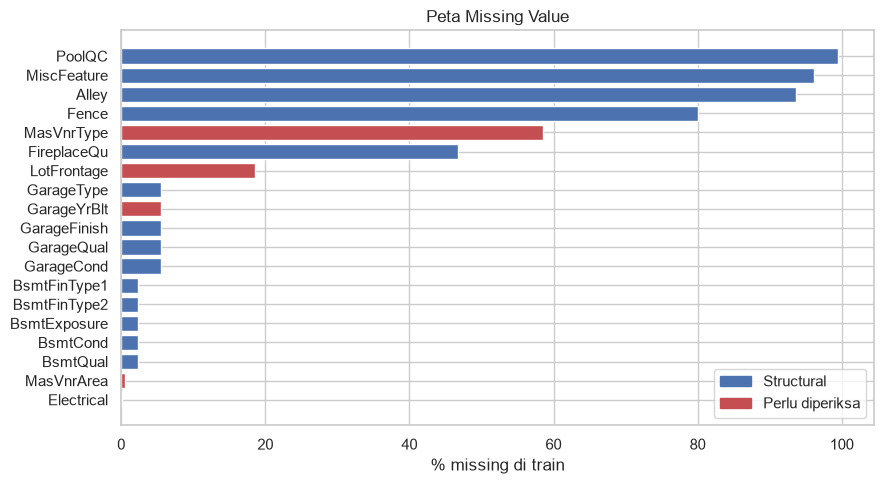

In [15]:
# Visualisasi persentase missing value
fig, ax = plt.subplots(figsize=(9, 5))

warna = [
    "#4C72B0" if jenis == "structural" else "#C44E52"
    for jenis in peta["jenis"]
]

ax.barh(peta.index[::-1], peta["pct"][::-1], color=warna[::-1])
ax.set_xlabel("% missing di train")
ax.set_title("Peta Missing Value")

# Legenda warna
from matplotlib.patches import Patch

legenda = [
    Patch(color="#4C72B0", label="Structural"),
    Patch(color="#C44E52", label="Perlu diperiksa"),
]

ax.legend(handles=legenda)

plt.tight_layout()
plt.show()

**Interpretasi & keputusan:**

Dari output terlihat bahwa `dropna()` menghasilkan **0 baris**, sehingga membuang semua baris yang memiliki missing value bukan pilihan yang tepat untuk dataset ini.

Sebagian besar missing value bersifat **structural**, seperti `PoolQC`, `Alley`, `FireplaceQu`, serta fitur garage dan basement. Missing tersebut menunjukkan bahwa fitur itu memang tidak tersedia pada rumah tersebut. Sementara itu, `MasVnrType`, `LotFrontage`, `GarageYrBlt`, `MasVnrArea`, dan `Electrical` masih perlu ditangani secara khusus.

**Artinya:** missing value pada dataset ini tidak bisa ditangani dengan satu aturan untuk semua fitur.

**Keputusan:** structural missing akan diberi nilai yang sesuai dengan arti fiturnya, sedangkan missing yang tidak memiliki arti khusus akan ditangani menggunakan nilai yang dipelajari dari data train.

**Selanjutnya:** strategi ini akan dimasukkan ke preprocessing `Pipeline` agar proses cleaning dapat diterapkan secara konsisten pada data train dan data baru.

### 4.4 Analisis Target `SalePrice`

Pada tahap ini dilakukan analisis terhadap `SalePrice` sebagai target yang akan diprediksi oleh model. Saya akan memahami statistik descriptive, penyebaran datanya, bentuk distribusinya, serta apakah terdapat nilai yang cukup ekstrem yang perlu diperhatikan sebelum menganalisis hubungan fitur dengan target.

In [16]:
# target SalePrice dari data train
target = train["SalePrice"].copy()

# Statistik descriptive dan bentuk distribusi target
target_stats = pd.Series({
    "n": target.notna().sum(),
    "mean": target.mean(),
    "median": target.median(),
    "std": target.std(),
    "min": target.min(),
    "q1": target.quantile(.25),
    "q3": target.quantile(.75),
    "max": target.max(),
    "skew": target.skew(),
    "kurtosis": target.kurt(),
})

print(target_stats.round(3).to_string())

n             1168.000
mean        181441.542
median      165000.000
std          77263.584
min          34900.000
q1          130000.000
q3          214925.000
max         745000.000
skew             1.743
kurtosis         5.475


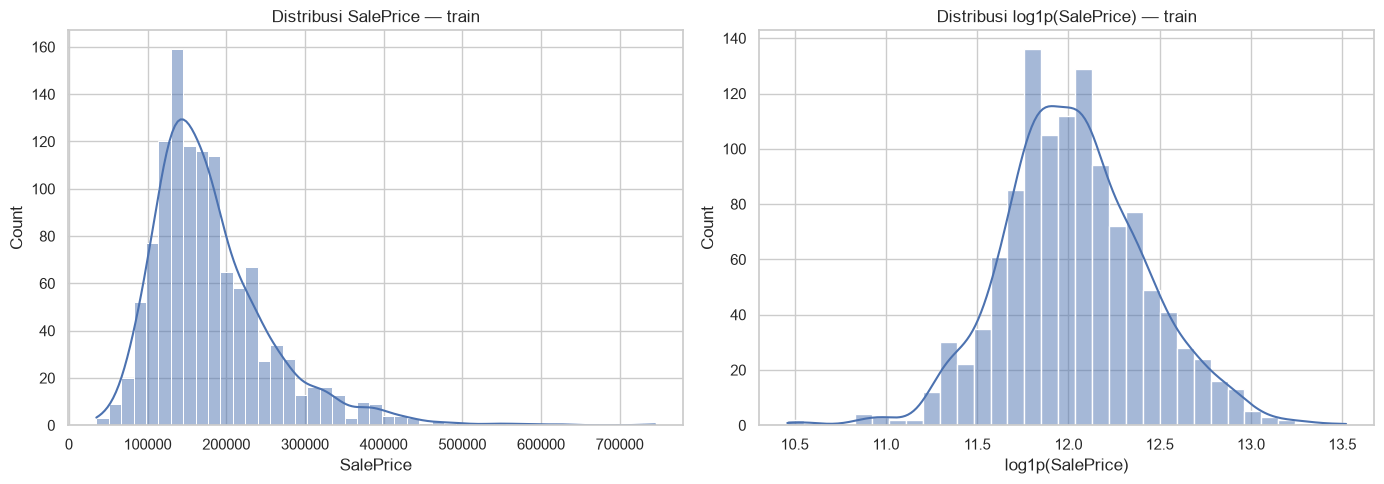

In [17]:
# Membuat visualisasi utk membandingkan distribusi SalePrice sebelum dan sesudah log transform
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(target, kde=True, ax=axes[0])
axes[0].set_title("Distribusi SalePrice — train")
axes[0].set_xlabel("SalePrice")

sns.histplot(np.log1p(target), kde=True, ax=axes[1])
axes[1].set_title("Distribusi log1p(SalePrice) — train")
axes[1].set_xlabel("log1p(SalePrice)")

plt.tight_layout()
plt.show()

**Interpretasi:**

`SalePrice` memiliki distribusi yang cukup **right-skewed**, terlihat dari nilai `skew` sebesar **1.743**. Mean (**181.442**) juga lebih tinggi dari median (**165.000**), yang menunjukkan adanya beberapa rumah dengan harga jauh lebih tinggi.

Nilai `kurtosis` sebesar **5.475** juga menunjukkan adanya ekor distribusi yang cukup berat. Harga maksimum mencapai **745.000**, jauh di atas Q3 sebesar **214.925**.

Setelah menggunakan `log1p(SalePrice)`, distribusi terlihat menjadi lebih seimbang. Ini dapat membantu agar model tidak terlalu dipengaruhi oleh beberapa rumah dengan harga sangat tinggi.

**Keputusan sementara:** saya akan membandingkan **Raw Target vs Log Target** menggunakan CV. Hasil CV akan menjadi dasar untuk menentukan transformasi target yang digunakan.

### 4.5 Analisis Univariate (Feature Numerik)

Pada tahap ini dilakukan analisis terhadap **fitur numerik satu per satu** untuk memahami karakteristik dan pola distribusi masing-masing fitur.

Analisis dilakukan menggunakan ringkasan statistik dan visualisasi pada beberapa fitur yang relevan, terutama untuk melihat **sebaran data, nilai ekstrem, banyaknya nilai 0, dan fitur yang hampir tidak memiliki variasi**.

Karena terdapat banyak fitur numerik maka tidak semua fitur akan dibuatkan grafik. Hasil analisis ini akan digunakan sebagai dasar untuk menentukan hal-hal yang perlu diperhatikan pada tahap preprocessing dan analisis berikutnya.

In [18]:
# Memisahkan fitur dari Id dan target SalePrice
X_train_eda = train.drop(columns=["Id", "SalePrice"])

# Mengambil fitur yang bertipe numerik
num_cols = X_train_eda.select_dtypes(include=np.number).columns.tolist()

# Membuat ringkasan statistik untuk setiap fitur numerik
num_summary = pd.DataFrame({
    "mean": X_train_eda[num_cols].mean(),
    "median": X_train_eda[num_cols].median(),
    "std": X_train_eda[num_cols].std(),
    "min": X_train_eda[num_cols].min(),
    "q1": X_train_eda[num_cols].quantile(.25),
    "q3": X_train_eda[num_cols].quantile(.75),
    "max": X_train_eda[num_cols].max(),
    "skew": X_train_eda[num_cols].skew(),
    "pct_zero": (X_train_eda[num_cols] == 0).mean() * 100,
    "n_unique": X_train_eda[num_cols].nunique(),
})

# Mengurutkan berdasarkan skewness paling tinggi
num_summary = num_summary.sort_values(
    "skew",
    key=lambda x: x.abs(),
    ascending=False
)

print(f"Jumlah fitur numerik: {len(num_cols)}")
display(num_summary.round(2))

Jumlah fitur numerik: 36


,mean,median,std,min,q1,q3,max,skew,pct_zero,n_unique
MiscVal,51.27,0.0,553.04,0.0,0.00,0.00,15500.0,22.05,96.23,19
PoolArea,2.96,0.0,41.65,0.0,0.00,0.00,738.0,14.40,99.49,7
LotArea,10689.64,9600.0,10759.37,1300.0,7587.25,11700.00,215245.0,11.96,0.00,890
3SsnPorch,3.81,0.0,31.52,0.0,0.00,0.00,508.0,9.83,98.29,17
LowQualFinSF,5.70,0.0,47.89,0.0,0.00,0.00,572.0,9.20,98.20,20
KitchenAbvGr,1.05,1.0,0.23,0.0,1.00,1.00,3.0,4.45,0.09,4
BsmtFinSF2,45.15,0.0,158.22,0.0,0.00,0.00,1127.0,4.22,88.78,118
ScreenPorch,15.41,0.0,55.88,0.0,0.00,0.00,480.0,4.09,91.70,66
BsmtHalfBath,0.06,0.0,0.24,0.0,0.00,0.00,2.0,4.01,94.35,3
EnclosedPorch,21.84,0.0,62.08,0.0,0.00,0.00,552.0,3.16,86.30,98


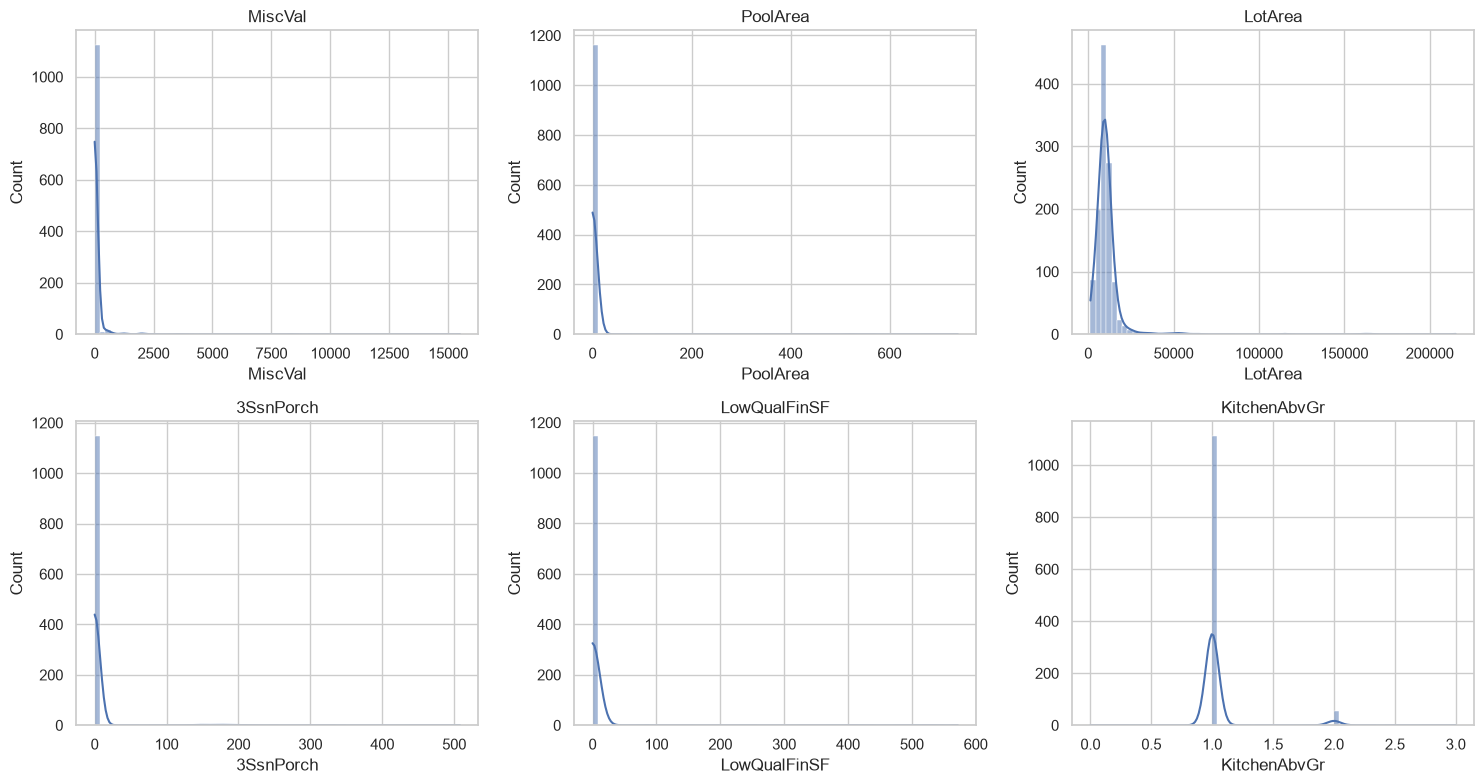

In [19]:
# Pilih 6 fitur numerik dengan skewness paling tinggi
plot_cols = num_summary.head(6).index.tolist()

# Buat histogram untuk melihat bentuk distribusi masing-masing fitur
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.ravel(), plot_cols):
    sns.histplot(X_train_eda[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


**Interpretasi:**

Output menunjukkan bahwa beberapa fitur numerik memiliki distribusi yang sangat skewed seperti pada feature`MiscVal`, `PoolArea`, dan `LotArea`. Beberapa fitur seperti `PoolArea`, `3SsnPorch`, dan `LowQualFinSF` juga memiliki lebih dari **98% nilai 0**.

Hal penting di sini adalah **nilai 0 tidak sama dengan missing**. Pada dataset House Prices, nilai `0` pada beberapa fitur memang dapat menunjukkan bahwa rumah tidak memiliki fasilitas tersebut. Jadi, nilai tersebut tetap merupakan informasi dan tidak boleh langsung dianggap sebagai missing value.

Selain itu, fitur seperti `MSSubClass` memiliki hanya **15 nilai unik**, sehingga perlu diperhatikan karena secara teknis bertipe numerik tetapi secara nilai lebih menyerupai kode kategori.

**Insight:** fitur numerik pada dataset memiliki karakteristik yang berbeda-beda. Ada fitur yang sangat skewed, banyak nilai 0, dan ada fitur numerik yang sebenarnya lebih menyerupai kategori.

**Keputusan:** kita tidak melakukan transformasi atau mengubah seluruh fitur numerik dengan satu aturan. Penanganannya akan disesuaikan dengan karakteristik fitur dan hasilnya akan dibandingkan menggunakan CV.

### 4.6 Analisis Univariate (Fitur Kategorikal)

Pada tahap ini dilakukan analisis terhadap **fitur kategorikal satu per satu** untuk memahami jumlah kategori, sebaran kategori, serta kategori yang terlalu jarang atau terlalu dominan.

Analisis ini akan membantu menentukan bagaimana setiap fitur kategorikal akan diproses pada tahap preprocessing, termasuk apakah kategori tertentu perlu dipertahankan, digabungkan, atau ditangani secara khusus.

Hasil analisis tetap akan digunakan sebagai bahan pertimbangan, bukan untuk langsung menghapus fitur.

In [20]:
# Mengambil fitur yang bertipe kategorikal
cat_cols = X_train_eda.select_dtypes(exclude=np.number).columns.tolist()

# Membuat ringkasan statistik fitur kategorikal
cat_summary = pd.DataFrame({
    "n_unique": X_train_eda[cat_cols].nunique(dropna=False),
    "mode": X_train_eda[cat_cols].apply(
        lambda x: x.mode(dropna=False).iloc[0]
    ),
    "mode_pct": X_train_eda[cat_cols].apply(
        lambda x: x.value_counts(dropna=False, normalize=True).iloc[0] * 100
    ),
    "missing_pct": X_train_eda[cat_cols].isna().mean() * 100,
})

# Menghitung jumlah kategori yang muncul kurang dari 10 baris
cat_summary["rare_categories_lt_10"] = [
    (X_train_eda[col].value_counts(dropna=False) < 10).sum()
    for col in cat_cols
]

# mengurutkan dari fitur yang paling didominasi satu kategori
cat_summary = cat_summary.sort_values("mode_pct", ascending=False)

print(f"Jumlah fitur kategorikal: {len(cat_cols)}")
display(cat_summary.round(2))

Jumlah fitur kategorikal: 43


,n_unique,mode,mode_pct,missing_pct,rare_categories_lt_10
Utilities,2,AllPub,99.91,0.00,1
Street,2,Pave,99.66,0.00,1
PoolQC,4,NaN,99.49,99.49,3
Condition2,8,Norm,99.06,0.00,7
RoofMatl,7,CompShg,98.37,0.00,6
Heating,6,GasA,97.60,0.00,4
MiscFeature,5,NaN,96.06,96.06,3
LandSlope,3,Gtl,94.86,0.00,1
Alley,3,NaN,93.66,93.66,0
CentralAir,2,Y,92.89,0.00,0


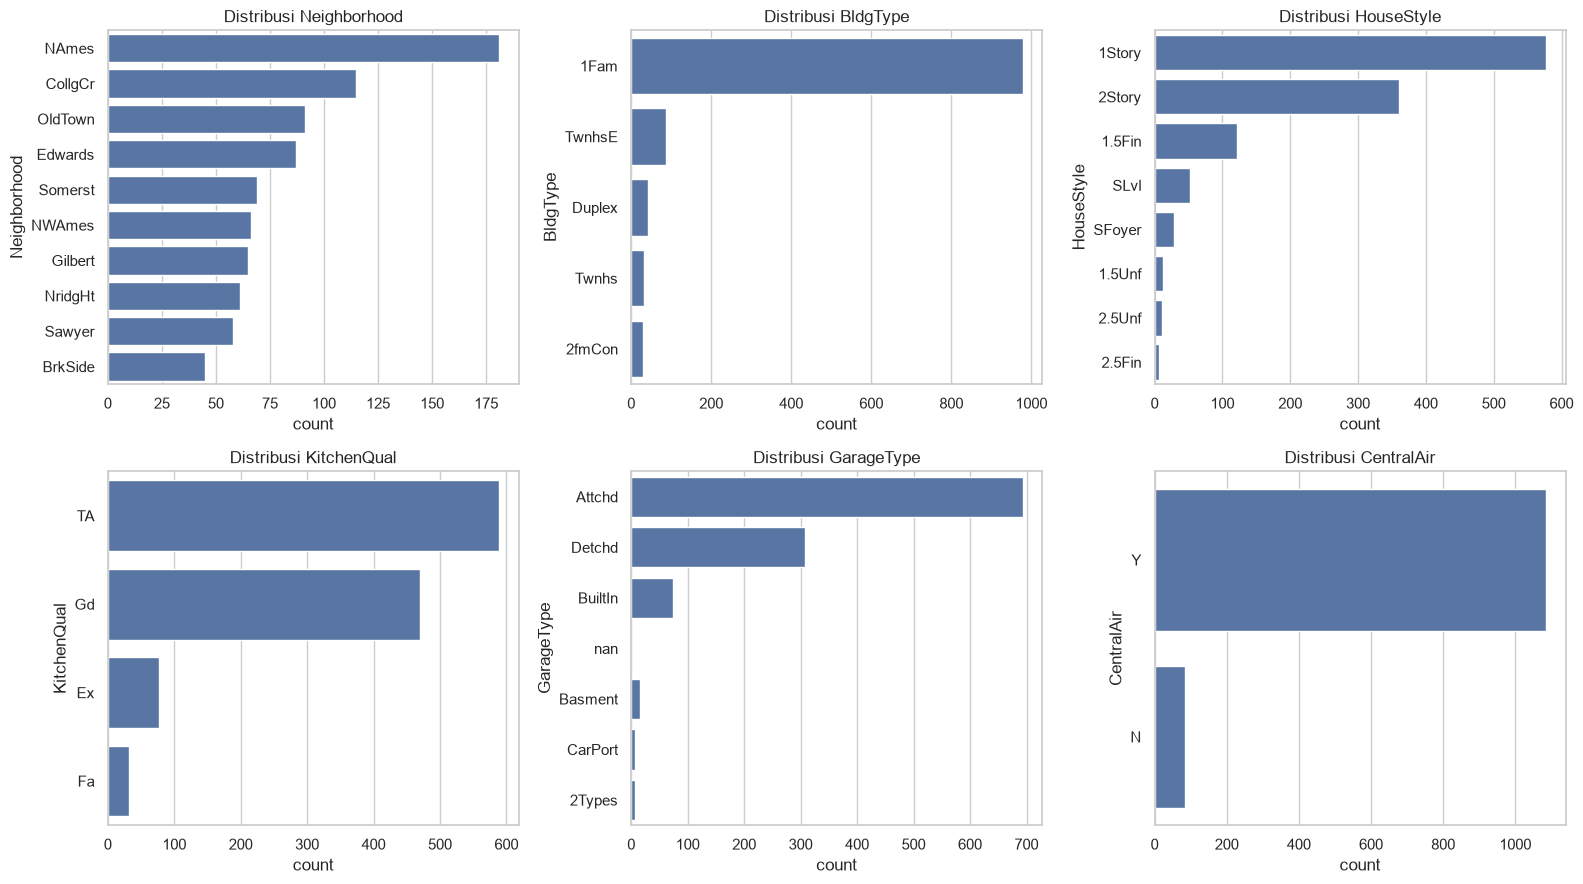

In [21]:
#  beberapa fitur kategorikal yang penting untuk dilihat distribusinya
selected_cat_plot = [
    "Neighborhood",
    "BldgType",
    "HouseStyle",
    "KitchenQual",
    "GarageType",
    "CentralAir"
]

# memastikan hanya kolom yang tersedia yang digunakan
selected_cat_plot = [
    col for col in selected_cat_plot
    if col in X_train_eda.columns
]

# Visualisasi kategori yang paling sering muncul
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.ravel(), selected_cat_plot):
    order = X_train_eda[col].value_counts(dropna=False).head(10).index
    sns.countplot(data=X_train_eda, y=col, order=order, ax=ax)
    ax.set_title(f"Distribusi {col}")

plt.tight_layout()
plt.show()

**Interpretasi:**

Distribusi fitur kategorikal menunjukkan dua kondisi utama:

1. **Ada fitur yang sangat didominasi oleh satu kategori** seperti `Utilities` dan `Street` yang lebih dari **99%** berada pada satu kategori. Beberapa fitur lain juga memiliki kategori yang sangat dominan.

2. **ada fitur dengan lebih banyak kategori** seperti `Neighborhood` yang memiliki **25 kategori**. Kategori yang jarang muncul juga cukup banyak, dengan total **76 kategori** yang memiliki kurang dari 10 observasi.

Namun, jumlah kategori yang banyak atau adanya kategori langka tidak otomatis membuat fitur tersebut tidak berguna. Contohnya `Neighborhood` yang tetap penting secara domain karena lokasi rumah dapat berkaitan dengan harga.

**Insight:** categorical feature tidak cukup dinilai hanya dari jumlah kategori atau seberapa dominan kategori tertentu.

**Keputusan:** categorical features tetap menjadi kandidat dan akan diproses menggunakan `OneHotEncoder`. Fitur yang terlalu dominan atau memiliki kategori langka akan ditinjau kembali bersama hasil analisis terhadap `SalePrice` dan evaluasi model.

### 4.7 Analisis Outlier

Pada tahap ini dilakukan pemeriksaan terhadap **nilai ekstrem pada fitur numerik** untuk mengetahui apakah nilai tersebut masih masuk akal atau perlu diperhatikan lebih lanjut.

Analisis dilakukan dengan membedakan nilai ekstrem secara statistik dengan nilai yang memang masih masuk akal berdasarkan kondisi rumah.

Hasil analisis ini akan menjadi dasar untuk menentukan apakah outlier perlu ditangani atau tetap dipertahankan. **Outlier tidak langsung dihapus hanya karena nilainya ekstrem.**

In [22]:
outlier_rows = []

# menghitung jumlah outlier menggunakan aturan IQR untuk setiap fitur numerik
for col in num_cols:
    s = X_train_eda[col].dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    # jika IQR = 0, tidak ada variasi yang bisa digunakan untuk mencari outlier
    if iqr == 0:
        n_outlier = 0
    else:
        batas_bawah = q1 - 1.5 * iqr
        batas_atas = q3 + 1.5 * iqr

        n_outlier = ((s < batas_bawah) | (s > batas_atas)).sum()

    outlier_rows.append(
        (col, n_outlier, n_outlier / len(s) * 100)
    )

# tabel ringkasan dan urutkan dari persentase outlier terbesar
outlier_summary = pd.DataFrame(
    outlier_rows,
    columns=["feature", "n_outlier_iqr", "pct_outlier"]
).sort_values("pct_outlier", ascending=False)

display(outlier_summary.head(15).round(2))

,feature,n_outlier_iqr,pct_outlier
4,OverallCond,99,8.48
0,MSSubClass,84,7.19
1,LotFrontage,68,7.15
7,MasVnrArea,77,6.63
28,OpenPorchSF,60,5.14
2,LotArea,54,4.62
11,TotalBsmtSF,47,4.02
27,WoodDeckSF,30,2.57
20,BedroomAbvGr,26,2.23
22,TotRmsAbvGrd,25,2.14


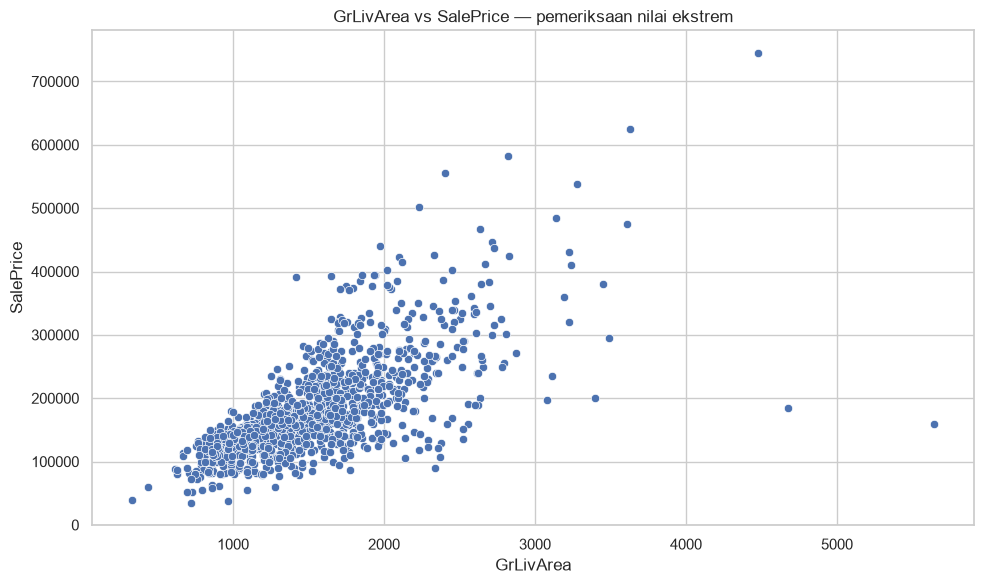

,Id,GrLivArea,OverallQual,SalePrice,SaleCondition
1298,1299,5642,10,160000,Partial
523,524,4676,10,184750,Partial
1182,1183,4476,10,745000,Abnorml


In [23]:
# Lihat hubungan GrLivArea dengan SalePrice untuk memeriksa nilai ekstrem
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=train,
    x="GrLivArea",
    y="SalePrice",
    ax=ax
)

ax.set_title("GrLivArea vs SalePrice — pemeriksaan nilai ekstrem")
plt.tight_layout()
plt.show()

# Tampilkan rumah dengan GrLivArea yang sangat besar
extreme_grliv = train.loc[
    train["GrLivArea"] > 4000,
    ["Id", "GrLivArea", "OverallQual", "SalePrice", "SaleCondition"]
]

display(
    extreme_grliv.sort_values("GrLivArea", ascending=False)
)

**Interpretasi**

Pada scatterplot `GrLivArea` terhadap `SalePrice`, terlihat pola umum bahwa rumah dengan living area lebih besar cenderung mempunyai harga lebih tinggi. Dan terlihat juga beberapa rumah dengan `GrLivArea` yang sangat besar. Tiga observasi terbesar memiliki `GrLivArea` **4476–5642**, tetapi kondisinya berbeda-beda. Salah satunya memiliki `SalePrice` **745000**, sedangkan dua lainnya hanya sekitar **160000–184750**.

IQR juga menandai beberapa fitur lain sebagai outlier, tetapi jumlah outlier tidak otomatis berarti datanya salah.

**Insight:** nilai ekstrem perlu dilihat bersama fitur lain dan kondisi rumah, bukan hanya berdasarkan batas statistik.

**Keputusan:** outlier tidak langsung dibuang pada tahap EDA. Saya akan menguji secara terpisah apakah model lebih baik dengan outlier dipertahankan atau dihapus.

### 4.8 Analisis Bivariate (Fitur Numerik vs `SalePrice`)

Pada tahap ini dilakukan analisis untuk melihat **hubungan antara fitur numerik dengan `SalePrice`**.

Hubungan akan dilihat menggunakan **Pearson dan Spearman**, kemudian dibandingkan untuk melihat fitur mana yang memiliki hubungan yang cukup kuat dengan target.

Hasil analisis ini digunakan sebagai **indikator awal**, bukan sebagai bukti bahwa fitur tersebut menyebabkan perubahan pada `SalePrice`. Selanjutnya, temuan ini akan dibandingkan dengan hasil analisis dan evaluasi model.

In [24]:
from scipy.stats import pearsonr, spearmanr

# utk menyimpan hasil menghitung korelasi Pearson dan Spearman untuk setiap fitur numerik
biv_num = []

for col in num_cols:
    tmp = train[[col, "SalePrice"]].dropna()

    # filter karena Korelasi tidak bisa dihitung jika nilainya hanya satu jenis
    if tmp[col].nunique() > 1:
        pearson = pearsonr(tmp[col], tmp["SalePrice"])[0]
        spearman = spearmanr(tmp[col], tmp["SalePrice"]).statistic
    else:
        pearson, spearman = np.nan, np.nan

    biv_num.append((col, pearson, spearman))

# tabel dan urutkan berdasarkan kekuatan korelasi Spearman
biv_num = pd.DataFrame(
    biv_num,
    columns=["feature", "pearson", "spearman"]
)

biv_num["abs_spearman"] = biv_num["spearman"].abs()

biv_num = biv_num.sort_values(
    "abs_spearman",
    ascending=False
)

display(biv_num.round(3))

,feature,pearson,spearman,abs_spearman
3,OverallQual,0.786,0.801,0.801
15,GrLivArea,0.696,0.723,0.723
25,GarageCars,0.641,0.687,0.687
5,YearBuilt,0.517,0.643,0.643
26,GarageArea,0.624,0.639,0.639
18,FullBath,0.553,0.626,0.626
11,TotalBsmtSF,0.598,0.595,0.595
24,GarageYrBlt,0.480,0.582,0.582
12,1stFlrSF,0.588,0.566,0.566
6,YearRemodAdd,0.509,0.563,0.563


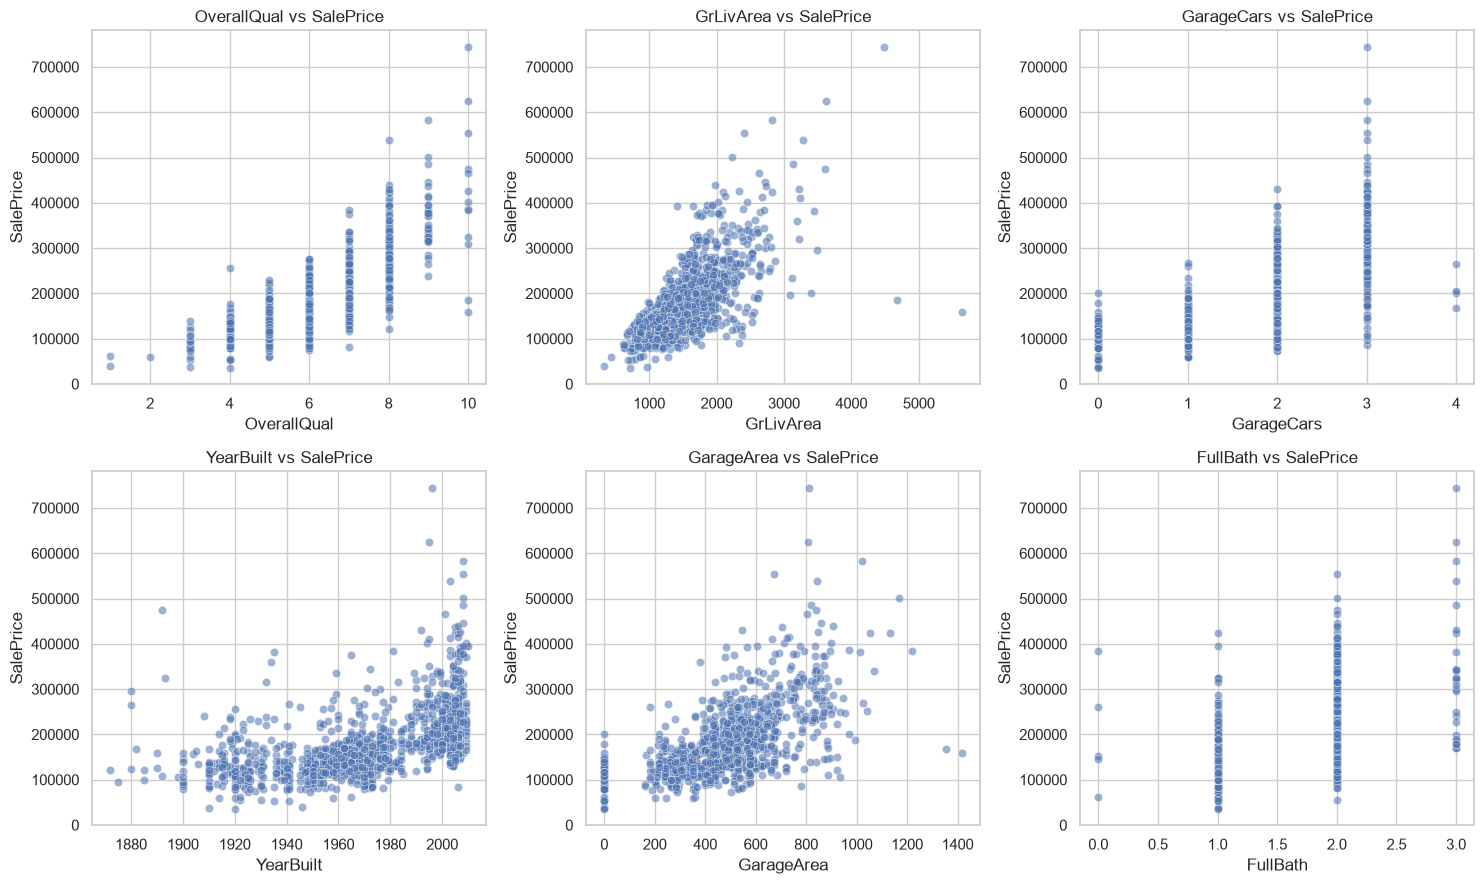

In [25]:
#  6 fitur dengan hubungan terkuat terhadap SalePrice
top_num = biv_num.head(6)["feature"].tolist()

# Visualisasi hubungan masing-masing fitur dengan SalePrice
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, col in zip(axes.ravel(), top_num):
    sns.scatterplot(
        data=train,
        x=col,
        y="SalePrice",
        ax=ax,
        alpha=.55
    )
    ax.set_title(f"{col} vs SalePrice")

plt.tight_layout()
plt.show()

**Interpretasi:**

Perbandingan Pearson dan Spearman menunjukkan bahwa hubungan fitur dengan `SalePrice` tidak selalu berbentuk linear.

`OverallQual` dan `GrLivArea` memiliki hubungan paling kuat dengan `SalePrice`, dengan Spearman masing-masing **0.801** dan **0.723**. `GarageCars`, `YearBuilt`, `GarageArea`, dan `FullBath` juga menunjukkan hubungan yang cukup kuat.

`LotArea` juga menarik karena Spearman (**0.464**) lebih tinggi dibanding Pearson (**0.266**). Ini menunjukkan bahwa luas lahan memiliki hubungan yang cukup konsisten dengan harga, tetapi hubungannya tidak sepenuhnya linear dan distribusinya sangat skewed.

Sebaliknya, beberapa fitur seperti `MoSold`, `YrSold`, `MiscVal`, dan `MSSubClass` memiliki hubungan yang sangat lemah dengan `SalePrice` berdasarkan korelasi ini.

**Insight:** Pearson dan Spearman dapat memberikan gambaran yang berbeda tentang hubungan fitur dengan target.

**Keputusan:** Pearson dan Spearman hanya digunakan sebagai **screening awal**. Hasilnya akan dilengkapi dengan analisis lain seperti Eta², Mutual Information, stability analysis, VIF, dan akhirnya CV.

### 4.9 Analisis Bivariate (Fitur Kategorikal vs `SalePrice`)

Pada tahap ini dilakukan analisis untuk melihat **perbedaan `SalePrice` antar kategori** pada setiap fitur kategorikal.

Saya akan membandingkan harga antar kelompok dan mengukur seberapa kuat perbedaan tersebut. Hasilnya digunakan untuk melihat fitur kategorikal mana yang memiliki hubungan dengan `SalePrice`.

Analisis ini digunakan sebagai **screening awal**, bukan untuk menyimpulkan bahwa suatu kategori menyebabkan harga menjadi lebih tinggi atau lebih rendah.

In [26]:
from scipy.stats import f_oneway


# Menghitung Eta² untuk melihat seberapa besar perbedaan kategori yg berhubungan dengan variasi SalePrice
def eta_squared_categorical(data, cat_col, target_col):
    tmp = data[[cat_col, target_col]].dropna()

    grand_mean = tmp[target_col].mean()
    groups = [
        group[target_col].values
        for _, group in tmp.groupby(cat_col, observed=True)
    ]

    if len(groups) < 2:
        return np.nan

    # Variasi antar kelompok dibandingkan dengan variasi total
    ss_between = sum(
        len(group) * (group.mean() - grand_mean) ** 2
        for group in groups
    )
    ss_total = ((tmp[target_col] - grand_mean) ** 2).sum()

    return ss_between / ss_total if ss_total else np.nan


biv_cat = []

# menganalisis setiap fitur kategorikal terhadap SalePrice
for col in cat_cols:
    tmp = train[[col, "SalePrice"]].dropna()

    # memisahkan SalePrice berdasarkan kategori
    groups = [
        group["SalePrice"].values
        for _, group in tmp.groupby(col, observed=True)
    ]

    # filter karena ANOVA membutuhkan minimal 2 observasi pada setiap kelompok
    groups = [group for group in groups if len(group) >= 2]

    if len(groups) >= 2:
        try:
            f_stat, p_value = f_oneway(*groups)
        except Exception:
            f_stat, p_value = np.nan, np.nan
    else:
        f_stat, p_value = np.nan, np.nan

    biv_cat.append((
        col,
        eta_squared_categorical(train, col, "SalePrice"),
        f_stat,
        p_value,
        tmp[col].nunique()
    ))


# tabel hasil dan urutkan berdasarkan Eta² terbesar
biv_cat = pd.DataFrame(
    biv_cat,
    columns=[
        "feature",
        "eta_squared",
        "anova_F",
        "anova_p",
        "n_categories"
    ]
)

biv_cat = biv_cat.sort_values("eta_squared", ascending=False)

display(biv_cat.round(4))

,feature,eta_squared,anova_F,anova_p,n_categories
8,Neighborhood,0.5319,56.4190,0.0000,25
30,KitchenQual,0.4614,332.4031,0.0000,4
18,ExterQual,0.4509,318.5668,0.0000,4
21,BsmtQual,0.4490,308.5620,0.0000,4
38,PoolQC,0.4177,1.0761,0.4443,3
2,Alley,0.3072,31.9331,0.0000,2
34,GarageFinish,0.2634,196.8994,0.0000,3
20,Foundation,0.2492,77.1550,0.0000,6
27,HeatingQC,0.2111,103.1197,0.0000,5
33,GarageType,0.2018,55.5062,0.0000,6


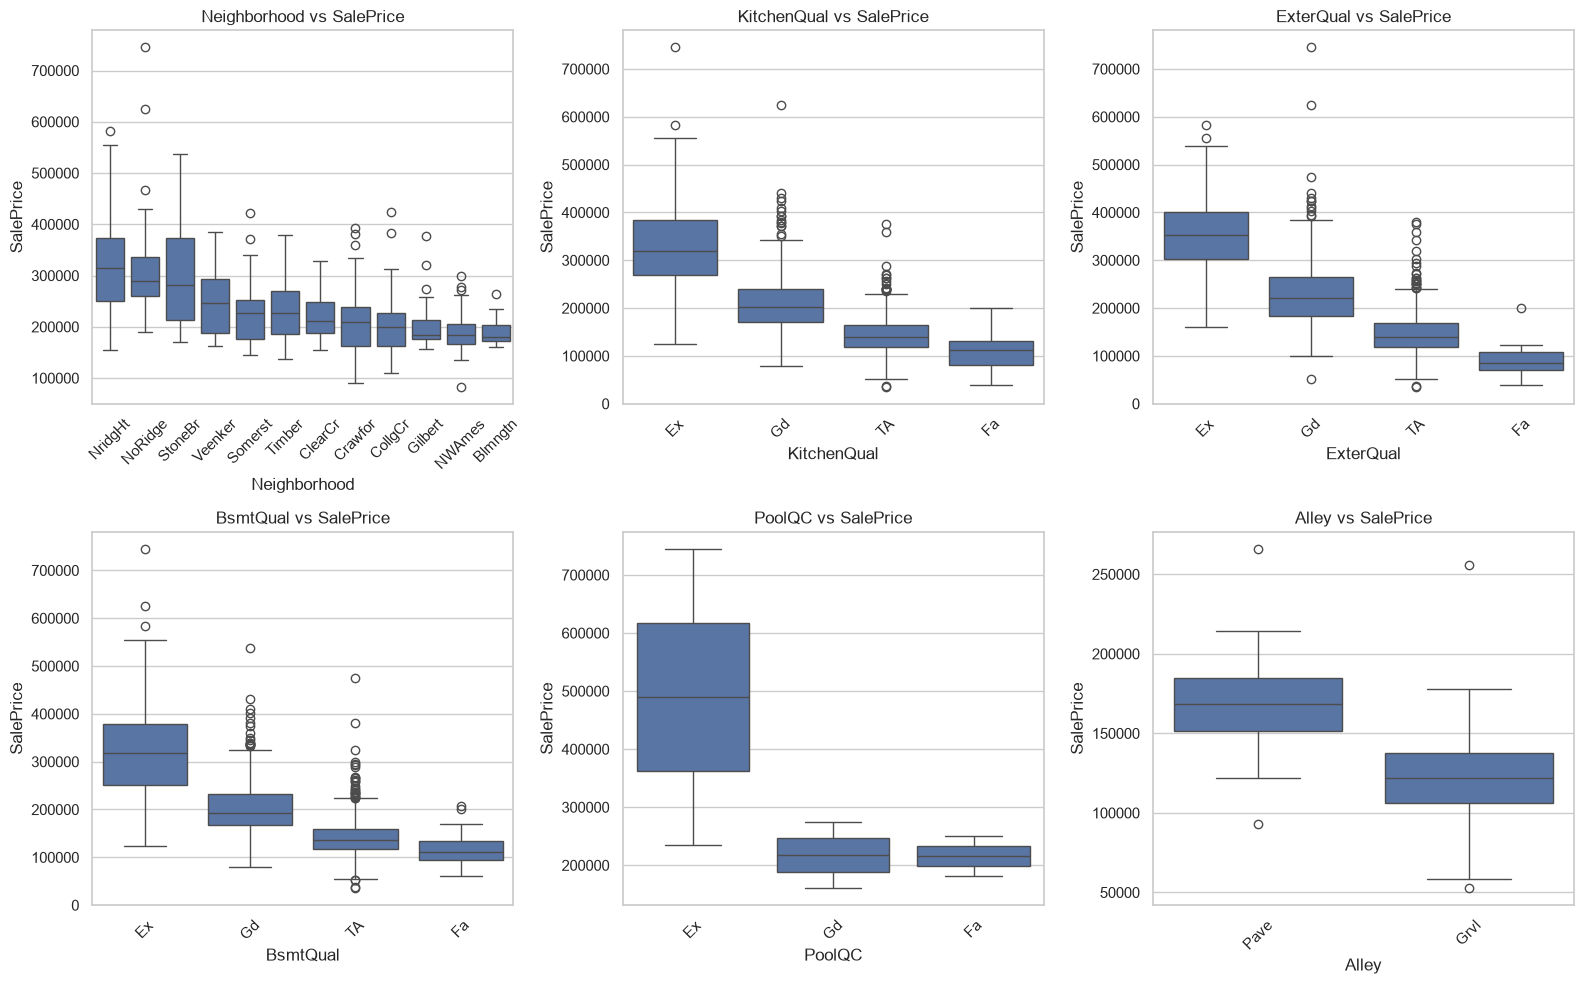

In [27]:
# 6 fitur kategorikal dengan Eta² terbesar
top_cat = biv_cat.head(6)["feature"].tolist()

# Visualisasi perbedaan SalePrice antar kategori
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axes.ravel(), top_cat):

    # mengambil 12 kategori dengan median SalePrice tertinggi
    median_price = (
        train.groupby(col, observed=True)["SalePrice"]
        .median()
        .sort_values(ascending=False)
        .head(12)
    )

    order = median_price.index

    # boxplot untuk membandingkan distribusi harga
    sns.boxplot(
        data=train[train[col].isin(order)],
        x=col,
        y="SalePrice",
        order=order,
        ax=ax
    )

    ax.tick_params(axis="x", rotation=45)
    ax.set_title(f"{col} vs SalePrice")

plt.tight_layout()
plt.show()

**Interpretasi:**

Hasil Eta² dan ANOVA menunjukkan bahwa beberapa fitur kategorikal memiliki perbedaan `SalePrice` yang cukup jelas antar kategori.

`Neighborhood` menjadi fitur paling kuat dengan **Eta² 0.532**, diikuti `KitchenQual`, `ExterQual`, dan `BsmtQual`. Ini memperkuat temuan sebelumnya bahwa **lokasi dan kualitas rumah** mempunyai hubungan yang kuat dengan harga.

Tetapi, pada `PoolQC` nilai Eta² terlihat tinggi (**0.418**), tetapi ANOVA tidak signifikan (`p = 0.444`). Hal ini perlu diperhatikan karena sebagian besar nilainya merupakan **structural missing** dan hanya sedikit rumah yang memiliki pool. Jadi, effect size yang tinggi belum tentu berarti hasilnya stabil.

**Insight:** kita tidak cukup melihat satu metrik saja. Effect size, jumlah observasi tiap kategori, kondisi missing, dan relevansi domain perlu dilihat bersama.

**Keputusan:** fitur kategorikal yang menunjukkan hubungan kuat dan masuk akal secara domain tetap menjadi kandidat. Keputusan akhirnya tetap menunggu hasil modeling dan CV.

### 4.10 Analisis Multivariate (Hubungan Antar Fitur)

Pada tahap ini dilakukan analisis terhadap beberapa fitur untuk melihat pola yang tidak terlihat ketika fitur dianalisis satu per satu.

Saya akan mengeksplorasi hubungan dan kemungkinan **interaksi antar fitur**, terutama pada fitur yang secara domain berkaitan dengan harga rumah.

Hasil analisis ini digunakan untuk memahami struktur data dan mencari pola yang perlu diperhatikan, bukan langsung menentukan fitur final.

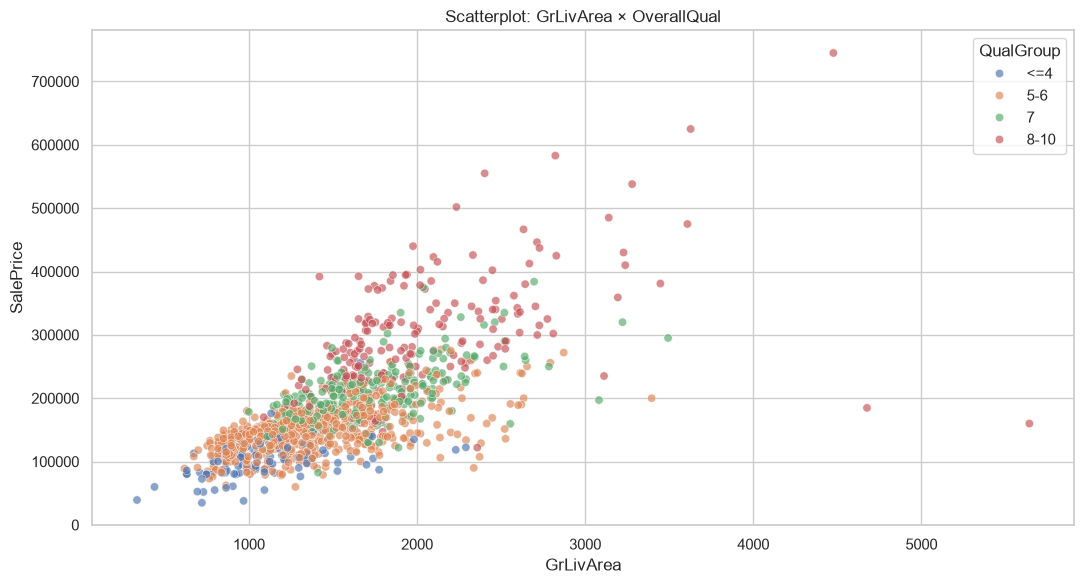

,QualGroup,n,median_price,median_grlivarea
0,<=4,107,106250.0,1040.0
1,5-6,619,143900.0,1314.0
2,7,258,200000.0,1658.0
3,8-10,184,285000.0,1906.5


In [28]:
# Membuat Kelompok rumah berdasarkan OverallQual

train_plot = train.copy()

train_plot["QualGroup"] = pd.cut(
    train_plot["OverallQual"],
    bins=[0, 4, 6, 7, 10],
    labels=["<=4", "5-6", "7", "8-10"]
)

# Melihat hubungan GrLivArea dan SalePrice berdasarkan kelompok kualitas
fig, ax = plt.subplots(figsize=(11, 6))

sns.scatterplot(
    data=train_plot,
    x="GrLivArea",
    y="SalePrice",
    hue="QualGroup",
    alpha=.65,
    ax=ax
)

ax.set_title("Scatterplot: GrLivArea × OverallQual")
plt.tight_layout()
plt.show()

# ringkasajumlah rumah dan median tiap kelompok
interaction_table = (
    train_plot.groupby("QualGroup", observed=True)
    .agg(
        n=("SalePrice", "size"),
        median_price=("SalePrice", "median"),
        median_grlivarea=("GrLivArea", "median")
    )
).reset_index()

display(interaction_table.round(2))

**Interpretasi:**

Scatterplot menunjukkan bahwa hubungan antara `GrLivArea` dan `SalePrice` terlihat berbeda pada tingkat `OverallQual` yang berbeda.

Median `SalePrice` juga meningkat dari **106.250** pada kualitas `<=4` menjadi **285.000** pada kualitas `8-10`. Pada kelompok kualitas yang lebih tinggi, rumah dengan `GrLivArea` besar cenderung berada pada rentang harga yang lebih tinggi.

**Artinya:** ada indikasi bahwa `OverallQual` dan `GrLivArea` tidak bekerja sepenuhnya secara terpisah. Hubungan luas rumah dengan harga dapat berbeda tergantung pada kualitas rumah.

Ini merupakan indikasi **interaction effect**.

**Keputusan:** `QualxArea = OverallQual × GrLivArea` menjadi kandidat feature engineering.

Tetapi saya tidak akan langsung menganggap fitur ini berhasil. Fitur tersebut harus diuji melalui **ablation dan CV**.

### 4.11 Analisis Multikolinearitas

Pada tahap ini dilakukan pemeriksaan untuk melihat apakah beberapa fitur memiliki informasi yang terlalu mirip atau saling tumpang tindih.

Pemeriksaan dilakukan dalam dua tahap:

1. **Correlation heatmap** → melihat hubungan antar pasangan fitur.
2. **VIF** → memeriksa apakah suatu fitur banyak dijelaskan oleh gabungan fitur lainnya.

Hasilnya digunakan untuk mengetahui fitur yang memiliki potensi redundansi sebelum masuk ke tahap modeling.

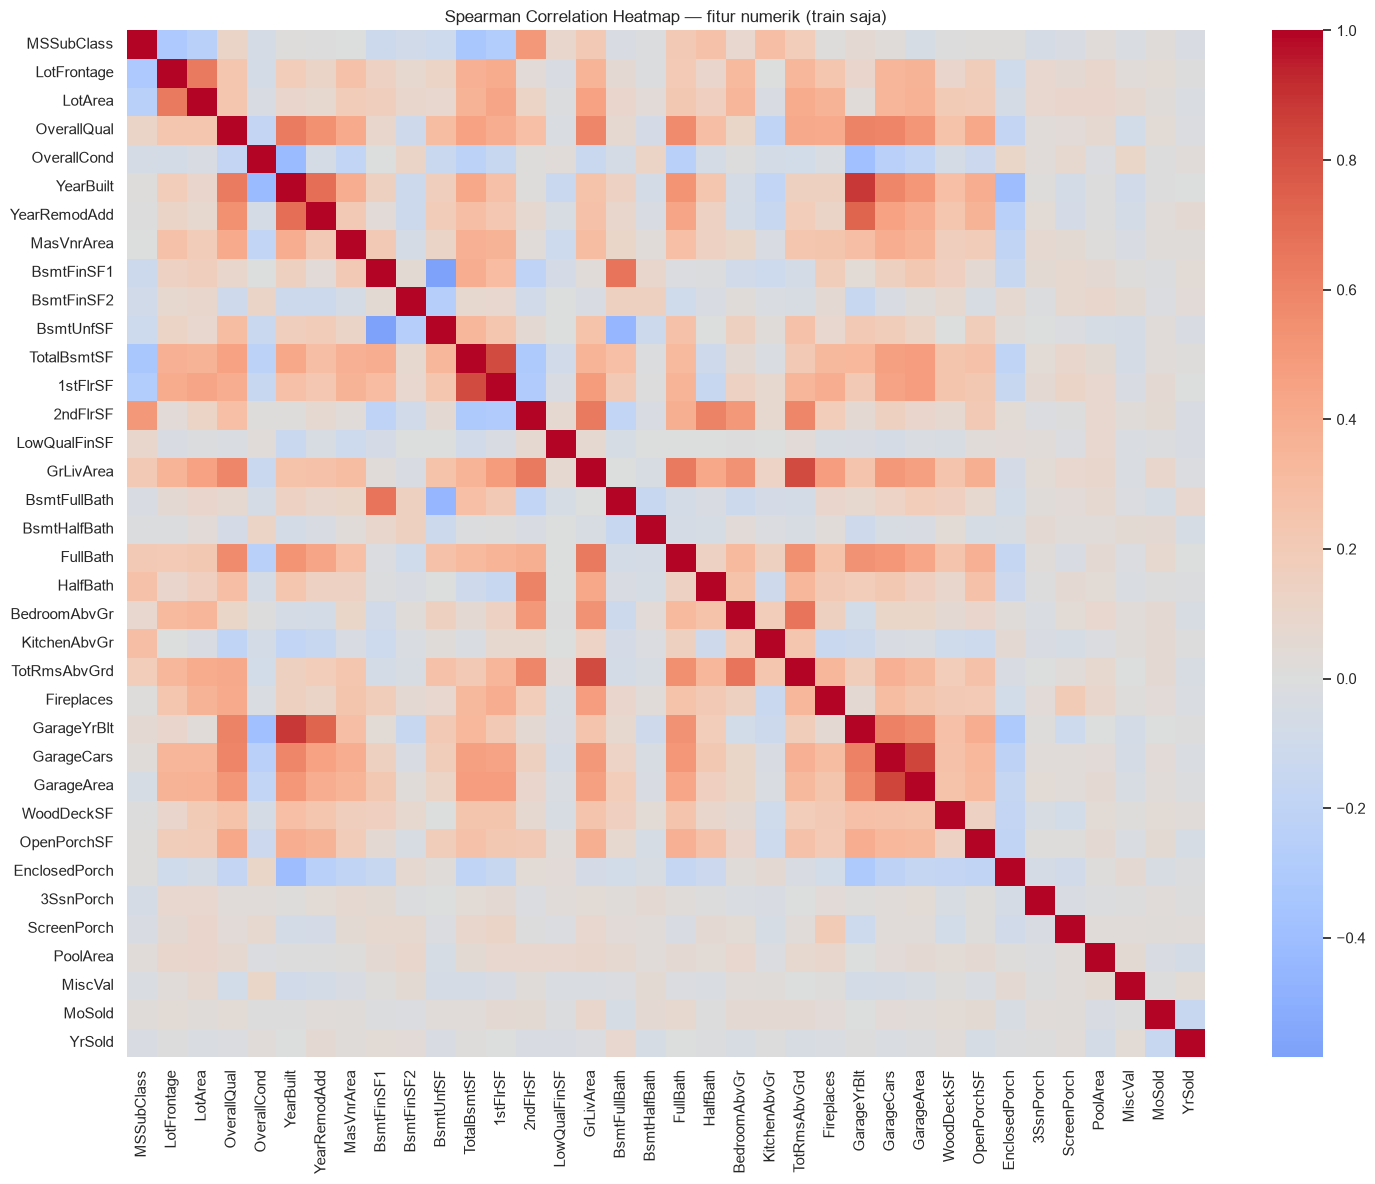

In [29]:
# menghitung korelasi Spearman antar fitur numerik
corr = train[num_cols].corr(method="spearman")

# Visualisasikan hubungan antar fitur
plt.figure(figsize=(15, 12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=False
)

plt.title("Spearman Correlation Heatmap — fitur numerik (train saja)")
plt.tight_layout()
plt.show()

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# karena beberapa fitur merupakan hasil penjumlahan fitur lain, sehingga dikeluarkan sementara agar VIF dapat dihitung.
vif_cols = [
    c for c in num_cols
    if c not in ["GrLivArea", "TotalBsmtSF"]
]

# menggunakan data train dan isi missing sementara dengan median
vif_data = train[vif_cols].copy()
vif_data = vif_data.fillna(vif_data.median())

# Hapus fitur konstan jika ada
vif_data = vif_data.loc[:, vif_data.nunique() > 1]

# Hitung VIF
vif_table = pd.DataFrame({
    "feature": vif_data.columns,
    "VIF": [
        variance_inflation_factor(vif_data.values, i)
        for i in range(vif_data.shape[1])
    ]
})

vif_table = vif_table.sort_values("VIF", ascending=False)

display(vif_table.round(2))


,feature,VIF
11,1stFlrSF,6.27
12,2ndFlrSF,5.87
8,BsmtFinSF1,5.61
23,GarageCars,5.59
24,GarageArea,5.52
5,YearBuilt,5.08
20,TotRmsAbvGrd,5.00
10,BsmtUnfSF,4.46
22,GarageYrBlt,3.21
3,OverallQual,3.18


**Interpretasi**

Heatmap menunjukkan beberapa kelompok fitur yang mempunyai hubungan cukup kuat, terutama pada fitur yang sama-sama menggambarkan **luas bangunan, basement, dan garasi**.

Hasil VIF memperkuat temuan tersebut. Beberapa fitur memiliki VIF di atas 5, seperti `1stFlrSF`, `2ndFlrSF`, `BsmtFinSF1`, `GarageCars`, dan `GarageArea`. Ini menunjukkan adanya informasi yang cukup tumpang tindih antar fitur.

Contohnya:

- `GarageCars` dan `GarageArea` sama-sama membawa informasi tentang garasi;
- `1stFlrSF` dan `2ndFlrSF` sama-sama membawa informasi tentang luas lantai.

**Insight:** adanya multicollinearity tidak otomatis berarti fitur harus dibuang. Dampaknya juga bergantung pada model yang digunakan.

**Keputusan:** hasil ini akan menjadi pertimbangan saat membuat **Full Candidate** dan **Reduced Candidate**, kemudian keduanya dibandingkan menggunakan CV.

### 4.12 Hubungan Fitur dengan `SalePrice`

Pada tahap ini saya menggabungkan beberapa hasil analisis sebelumnya untuk melihat fitur mana yang mempunyai hubungan dengan `SalePrice`.

saya menggunakan **Pearson, Spearman, Eta², dan Mutual Information (MI)** sebagai beberapa sudut pandang yang saling melengkapi. Hasilnya akan digunakan sebagai **screening awal**, dan bukan sebagai satu-satunya alasan untuk memilih fitur final.

In [31]:
from sklearn.feature_selection import mutual_info_regression

# mengambil semua fitur tanpa Id dan target
X_mi = train.drop(columns=["Id", "SalePrice"]).copy()

# mengubah fitur kategorikal menjadi angka agar MI bisa dihitung
for col in X_mi.select_dtypes(exclude=np.number).columns:
    X_mi[col] = X_mi[col].astype("category").cat.codes

# mengisi missing value agar tidak mengganggu perhitungan MI
X_mi = X_mi.fillna(X_mi.median(numeric_only=True))
X_mi = X_mi.fillna(0)

# menghitung Mutual Information dengan target log1p(SalePrice)
mi = mutual_info_regression(
    X_mi,
    np.log1p(train["SalePrice"]),
    random_state=RANDOM_STATE
)

# mengurutkan fitur berdasarkan nilai MI dari terbesar - terkecil
mi_table = pd.DataFrame({
    "feature": X_mi.columns,
    "MI": mi
}).sort_values("MI", ascending=False)

display(mi_table.head(25).round(4))

,feature,MI
16,OverallQual,0.5378
11,Neighborhood,0.4742
45,GrLivArea,0.4469
61,GarageArea,0.3607
60,GarageCars,0.3560
18,YearBuilt,0.3363
37,TotalBsmtSF,0.3322
52,KitchenQual,0.3192
29,BsmtQual,0.3177
26,ExterQual,0.3084


**Interpretasi:**

Hasil Mutual Information memperkuat beberapa temuan sebelumnya. Pada `OverallQual`, `Neighborhood`, dan `GrLivArea` kembali berada di posisi teratas, sehingga ketiganya mempunyai hubungan yang cukup kuat dengan `SalePrice` dari beberapa sudut pandang.

Fitur seperti `GarageArea`, `GarageCars`, `YearBuilt`, `TotalBsmtSF`, dan beberapa fitur kualitas juga menunjukkan nilai MI yang cukup tinggi.

**Artinya:** hasil MI memberikan tambahan bukti bahwa beberapa fitur layak dipertimbangkan, tetapi MI sendiri tidak cukup untuk menentukan fitur final.

**Keputusan:** hasil MI akan digabungkan dengan korelasi, Eta², domain knowledge, leakage audit, VIF, stability, dan terutama hasil CV sebelum menentukan fitur yang digunakan model.

### 4.13 Keputusan Fitur yang Mengandung Data Transaksi

Pada tahap ini kita mencatat fitur yang berkaitan dengan proses transaksi dan memutuskan apakah fitur tersebut dapat digunakan saat prediksi dilakukan.

`MoSold`, `YrSold`, `SaleType`, dan `SaleCondition` dikeluarkan karena nilainya berkaitan dengan kejadian penjualan, bukan hanya kondisi rumah.

Keputusan ini akan digunakan sebagai dasar sebelum masuk ke tahap **feature selection**.

In [32]:
leakage_candidates = ["MoSold", "YrSold", "SaleType", "SaleCondition"]

leakage_audit = pd.DataFrame({
    "feature": leakage_candidates,
    "available_at_prediction": ["Tidak"] * 4,
    "decision": ["EXCLUDE"] * 4,
    "reason": [
        "bulan transaksi baru diketahui saat/setelah penjualan",
        "tahun transaksi baru diketahui saat/setelah penjualan",
        "jenis transaksi bukan atribut rumah",
        "kondisi transaksi bukan atribut rumah"
    ]
})

display(leakage_audit)

,feature,available_at_prediction,decision,reason
0,MoSold,Tidak,EXCLUDE,bulan transaksi baru diketahui saat/setelah pe...
1,YrSold,Tidak,EXCLUDE,tahun transaksi baru diketahui saat/setelah pe...
2,SaleType,Tidak,EXCLUDE,jenis transaksi bukan atribut rumah
3,SaleCondition,Tidak,EXCLUDE,kondisi transaksi bukan atribut rumah


### Interpretasi

Dari hasil di atas, **empat fitur yang berkaitan dengan transaksi**:

- `MoSold`
- `YrSold`
- `SaleType`
- `SaleCondition`

diputuskan untuk **dikeluarkan dari candidate utama**. Alasannya bukan karena fitur tersebut tidak berhubungan dengan `SalePrice`, tetapi karena **informasinya belum tersedia saat prediction dilakukan**.

Jika tujuan kita adalah memprediksi harga berdasarkan **karakteristik rumah sebelum transaksi**, maka fitur transaksi tidak cocok digunakan sebagai input utama model.

**Keputusan:** keempat fitur tersebut tidak digunakan dalam model serving.

Jadi, model yang kita pilih bukan hanya yang punya score bagus, tetapi juga menggunakan **informasi yang realistis tersedia saat prediction**.

### 4.14 Pemeriksaan Feature Redundancy dan Kandidat Fitur

Pada tahap ini saya melakukan pemeriksaan untuk **feature selection**. Feature selection bukan hanya memilih fitur yang memiliki hubungan paling besar dengan `SalePrice`. Pemilihan fitur juga perlu melihat beberapa hal seperti:

1. **Signal:** apakah fitur memiliki hubungan dengan target?
2. **Redundancy:** apakah informasinya sudah diwakili oleh fitur lain?
3. **Availability:** apakah fitur tersedia saat prediction?
4. **Operational cost:** Apakah user nantinya realistis untuk memberikan data fitur ini saat melakukan prediction?

Jadi, fitur yang bagus bukan hanya yang memiliki hubungan dengan target, tetapi juga **tidak terlalu berulang, tersedia saat prediction, dan mudah diminta datanya ke user**.

Karena itu, pada tahap ini kita menentukan **kandidat awal fitur** berdasarkan hasil analisis sebelumnya.

Final feature set **belum dikunci**. Keputusan akhir akan dibuat setelah kandidat dibandingkan melalui **baseline dan evaluasi model**.

In [33]:
# Menentukan kandidat awal fitur berdasarkan hasil analisis sebelumnya.
candidate_features = [
    "OverallQual", "OverallCond", "GrLivArea", "TotalBsmtSF",
    "1stFlrSF", "GarageCars", "GarageArea", "YearBuilt",
    "YearRemodAdd", "FullBath", "TotRmsAbvGrd", "Fireplaces",
    "LotArea", "Neighborhood", "KitchenQual", "HeatingQC",
    "CentralAir", "MSZoning"
]

# memastikan hanya fitur yang tersedia di data train yang digunakan.
candidate_features = [c for c in candidate_features if c in train.columns]

# list utk menyimpan informasi penting dari setiap kandidat fitur.
candidate_review = []

for c in candidate_features:
    # menggunakan Spearman untuk fitur numerik.
    if c in biv_num["feature"].values:
        signal = biv_num.loc[biv_num["feature"] == c, "spearman"].iloc[0]
        signal_type = "Spearman"

    # menggunakan Eta² untuk fitur kategorikal.
    elif c in biv_cat["feature"].values:
        signal = biv_cat.loc[biv_cat["feature"] == c, "eta_squared"].iloc[0]
        signal_type = "Eta²"

    else:
        signal, signal_type = np.nan, "n/a"

    candidate_review.append((
        c,
        train[c].dtype,
        train[c].nunique(dropna=True),
        signal_type,
        signal
    ))

# menampilkan kandidat fitur berdasarkan nilai signal.
candidate_review = pd.DataFrame(
    candidate_review,
    columns=["feature", "dtype", "n_unique", "signal_metric", "signal"]
)

display(
    candidate_review
    .sort_values("signal", ascending=False)
    .round(4)
)

,feature,dtype,n_unique,signal_metric,signal
0,OverallQual,int64,10,Spearman,0.8010
2,GrLivArea,int64,734,Spearman,0.7234
5,GarageCars,int64,5,Spearman,0.6868
7,YearBuilt,int64,111,Spearman,0.6432
6,GarageArea,int64,394,Spearman,0.6387
9,FullBath,int64,4,Spearman,0.6256
3,TotalBsmtSF,int64,630,Spearman,0.5950
4,1stFlrSF,int64,657,Spearman,0.5663
8,YearRemodAdd,int64,61,Spearman,0.5629
13,Neighborhood,object,25,Eta²,0.5319


**Interpretasi:**

Tabel candidate review menunjukkan bahwa beberapa fitur memiliki hubungan yang cukup kuat dengan `SalePrice`.

Fitur dengan hubungan paling kuat adalah:

- `OverallQual` → 0.8010
- `GrLivArea` → 0.7234
- `GarageCars` → 0.6868
- `YearBuilt` → 0.6432
- `GarageArea` → 0.6387
- `FullBath` → 0.6256

Untuk fitur categorical saya menggunakan **Eta²**, sehingga tidak dibandingkan langsung dengan nilai Spearman. `Neighborhood` dan `KitchenQual` juga menunjukkan hubungan yang cukup kuat dengan `SalePrice`.

Namun, nilai signal ini **belum menjadi alasan untuk langsung memilih atau membuang fitur**. Beberapa fitur dapat membawa informasi yang sama dengan fitur lain, dan ada juga fitur yang perlu dipertimbangkan dari sisi availability dan penggunaan di API.

**Artinya:** feature selection tetap dilakukan berdasarkan beberapa pertimbangan:

**signal + redundancy + availability + business relevance + serving practicality.**

**Keputusan:** seluruh candidate set ini dibawa ke tahap **preprocessing dan modeling**. Final feature set belum ditetapkan pada tahap EDA.

### 4.15 Candidate Feature Engineering

Pada tahap ini saya mencoba membuat beberapa **fitur baru** dari informasi yang sudah tersedia untuk melihat apakah model dapat mempelajari pola dengan lebih baik.

Contoh fitur yang akan diuji:

- total area rumah
- total bathroom berbobot
- umur rumah
- umur sejak renovasi
- interaction antara kualitas rumah dan luas rumah.

Feature engineering dilakukan setelah split. Namun, jika suatu transformasi perlu **mempelajari nilai atau parameter dari data**, maka parameter tersebut hanya boleh dipelajari dari **train/CV** agar tidak terjadi data leakage.

Untuk saat ini, fitur-fitur tersebut hanya **kandidat yang diuji pada data train**. Jika terbukti membantu, implementasi final akan dimasukkan ke dalam **Pipeline**.

In [34]:
# beberapa kandidat fitur baru dari fitur yang sudah ada.
fe_candidates = pd.DataFrame(index=train.index)

# Total luas basement + luas area yang digunakan untuk tinggal.
fe_candidates["TotalSF_candidate"] = (
    train["TotalBsmtSF"] + train["GrLivArea"]
)

# Total bathroom dengan bobot:
# full bathroom = 1 dan half bathroom = 0.5.
fe_candidates["TotalBath_candidate"] = (
    train["FullBath"]
    + 0.5 * train["HalfBath"]
    + train["BsmtFullBath"]
    + 0.5 * train["BsmtHalfBath"]
)

# Umur rumah saat tahun penjualan.
fe_candidates["HouseAge_candidate"] = (
    train["YrSold"] - train["YearBuilt"]
)

# Umur rumah sejak renovasi terakhir.
fe_candidates["RemodAge_candidate"] = (
    train["YrSold"] - train["YearRemodAdd"]
)

# Mengabungkan kualitas rumah dengan luas area yang digunakan untuk tinggal.
fe_candidates["QualxArea_candidate"] = (
    train["OverallQual"] * train["GrLivArea"]
)

# mengecek hubungan setiap fitur baru dengan SalePrice.
fe_corr = pd.DataFrame({
    "feature": fe_candidates.columns,
    "spearman_with_target": [
        spearmanr(fe_candidates[c], train["SalePrice"]).statistic
        for c in fe_candidates.columns
    ],
    "pct_missing": fe_candidates.isna().mean() * 100
}).sort_values(
    "spearman_with_target",
    key=lambda s: s.abs(),
    ascending=False
)

display(fe_corr.round(4))

,feature,spearman_with_target,pct_missing
QualxArea_candidate,QualxArea_candidate,0.8479,0.0
TotalSF_candidate,TotalSF_candidate,0.8082,0.0
TotalBath_candidate,TotalBath_candidate,0.6873,0.0
HouseAge_candidate,HouseAge_candidate,-0.6399,0.0
RemodAge_candidate,RemodAge_candidate,-0.5671,0.0


**Interpretasi:**

Hasil feature engineering menunjukkan bahwa beberapa fitur baru memiliki hubungan yang cukup kuat dengan `SalePrice`. Seperti pada `QualxArea_candidate` memiliki hubungan paling kuat dengan `SalePrice` yaitu **0.8479**. Fitur ini menggabungkan `OverallQual` dan `GrLivArea`, sehingga mewakili hubungan antara **kualitas dan luas rumah**.

Lalu pada feature `TotalSF_candidate` juga memiliki hubungan yang kuat yaitu **0.8082**, sedangkan `TotalBath_candidate` sebesar **0.6873**.

`HouseAge_candidate` dan `RemodAge_candidate` memiliki hubungan negatif, yang menunjukkan bahwa semakin tua rumah, harga cenderung lebih rendah.

Namun, hubungan yang kuat belum berarti feature engineering akan membuat model menjadi lebih baik. Bisa saja fitur baru hanya menggabungkan informasi yang sudah dimiliki fitur sebelumnya.

**Artinya:** hasil dari feature engineering tetap harus di uji pengaruhnya terhadap performa model.

**Keputusan:** semua engineered features menjadi **candidate experiment** dan akan diuji menggunakan **ablation/CV**.

### 4.16 Stabilitas EDA — Apakah Temuan Kita Kebetulan?

Pada tahap ini saya melakukan pengecekan untuk melihat apakah hasil EDA sebelumnya **konsisten** atau hanya muncul karena kebetulan dari sample data tertentu.

EDA sebelumnya dilakukan pada satu data `train`. Karena itu, ranking fitur bisa saja berubah jika sample datanya berbeda. Untuk mengeceknya, saya akan menggunakan beberapa **subsample dari data train**.

Tujuannya bukan untuk mendapatkan angka final, tetapi untuk melihat apakah fitur yang dianggap penting **muncul secara konsisten** pada beberapa sample.

In [35]:
rng = np.random.RandomState(RANDOM_STATE) # # menggunakan random state yang sama agar hasilnya reproducible

stability_runs = []

# mengulangi pengecekan sebanyak 10 kali.
for run in range(10):

    # mengambil 80% data dari train secara acak.
    sample_idx = rng.choice(
        train.index,
        size=int(len(train) * 0.8),
        replace=False
    )
    sample = train.loc[sample_idx]

    rows = []

    # menghitung Spearman setiap fitur numerik dengan SalePrice.
    for col in num_cols:
        tmp = sample[[col, "SalePrice"]].dropna()

        if len(tmp) > 5 and tmp[col].nunique() > 1:
            rho = spearmanr(
                tmp[col],
                tmp["SalePrice"]
            ).statistic
        else:
            rho = np.nan

        rows.append((col, abs(rho)))

    # mengambil 15 fitur dengan hubungan terkuat pada sample ini.
    rank = pd.DataFrame(
        rows,
        columns=["feature", "abs_spearman"]
    ).sort_values(
        "abs_spearman",
        ascending=False
    )

    # menyimpan fitur yang masuk Top 15.
    for feature in rank.head(15)["feature"]:
        stability_runs.append((run, feature))

# menghitung berapa kali setiap fitur masuk Top 15.
stability = (
    pd.Series([x[1] for x in stability_runs])
    .value_counts()
    .rename("times_in_top15")
)

display(stability.head(20).to_frame())

,times_in_top15
OverallQual,10
GrLivArea,10
GarageCars,10
YearBuilt,10
GarageArea,10
FullBath,10
GarageYrBlt,10
TotalBsmtSF,10
YearRemodAdd,10
1stFlrSF,10


**Interpretasi:**

Hasil stability analysis menunjukkan bahwa beberapa fitur secara konsisten masuk **Top 15** pada seluruh 10 subsample. Fitur seperti `OverallQual`, `GrLivArea`, `GarageCars`, `YearBuilt`, `GarageArea`, `FullBath`, `TotalBsmtSF`, dan beberapa fitur lainnya muncul **10 dari 10 kali**. Sementara itu, `LotFrontage` dan `MasVnrArea` hanya muncul **5 dari 10 kali**, sehingga hasilnya tidak sekonsisten fitur lainnya.

**Artinya:** fitur yang konsisten muncul pada beberapa sample lebih meyakinkan dibandingkan fitur yang hanya muncul sesekali.

Namun, stability analysis **bukan pengganti CV**. Tetapi, Analisis ini hanya menjadi evidence tambahan sebelum kita menentukan fitur dan model. **Keputusan:** hasil stability digunakan sebagai pertimbangan tambahan, sedangkan keputusan final tetap berdasarkan **kemampuan model melakukan generalisasi melalui CV**.

**Interpretasi & Keputusan:**

Sampai tahap ini saya sudah melihat data dari berbagai sisi, mulai dari:

- statistik deskriptif
- missing value
- skewness
- outlier
- distribusi categorical
- Pearson dan Spearman
- Eta²
- interaction
- correlation dan VIF
- Mutual Information
- stability
- leakage
- feature engineering

Dari hasil tersebut, saya mendapatkan beberapa hal yang perlu diuji lebih lanjut:

1. `SalePrice` cukup skewed → **log target layak diuji**.
2. `OverallQual` dan `GrLivArea` memiliki hubungan yang kuat dengan `SalePrice`.
3. `Neighborhood` juga membawa informasi penting.
4. Beberapa fitur memiliki informasi yang mirip → **Full vs Reduced Candidate perlu dibandingkan**.
5. `QualxArea` menunjukkan hubungan yang kuat → **interaction layak diuji**.
6. Outlier tidak langsung dibuang karena belum tentu merupakan data yang salah.
7. `Holdout` tetap disimpan dan tidak digunakan untuk membuat keputusan selama eksperimen.

**Kesimpulan:** EDA belum menentukan model atau fitur terbaik. EDA menghasilkan **hipotesis yang selanjutnya harus dibuktikan melalui eksperimen modeling dan CV**.

### 4.17 Pemeriksaan Kandidat Fitur dan Multikolinearitas

Sebelum masuk ke preprocessing, saya akan memastikan kandidat fitur yang dipilih sudah dipahami dari sisi **leakage** dan **redundancy/multicollinearity**. Saya tidak akan menggunakan aturan **`VIF > 10 → otomatis hapus fitur`**. VIF digunakan sebagai alat untuk melihat fitur yang memiliki informasi yang mirip, tetapi keputusan akhir tetap mempertimbangkan makna fitur dan model yang digunakan.

Untuk model linear, multicollinearity dapat membuat koefisien menjadi tidak stabil. Karena itu, **Ridge/Lasso/ElasticNet** akan diuji untuk melihat apakah regularization dapat membantu.

Untuk **Random Forest/XGBoost**, keputusan akan berdasarkan hasil **cross-validation**, bukan hanya dari nilai VIF.

#### Candidate Feature Set Sementara

Kandidat fitur sementara berasal dari hasil EDA. Beberapa fitur yang memiliki informasi mirip tetap kita pertahankan agar nanti bisa **dibandingkan melalui eksperimen**.

Fitur categorical tidak dimasukkan ke perhitungan VIF karena VIF digunakan untuk variabel numerik. Fitur categorical akan diproses melalui **encoding dan model pipeline** pada tahap berikutnya.

In [36]:
# menggunakan candidate_features dari bagian 4.14.
# saya tidak mendefinisikan ulang agar hanya ada satu sumber kandidat fitur.
assert "candidate_features" in globals(), "Jalankan bagian 4.14 terlebih dahulu."

# memastika semua kandidat masih tersedia di train.
candidate_features = [c for c in candidate_features if c in train.columns]

# memisahkan fitur numerik dan kategorikal.
candidate_num = [
    c for c in candidate_features
    if pd.api.types.is_numeric_dtype(train[c])
]

candidate_cat = [
    c for c in candidate_features
    if c not in candidate_num
]

print(f"Jumlah candidate features : {len(candidate_features)}")
print(f"Numerik                   : {len(candidate_num)}")
print(f"Kategorikal               : {len(candidate_cat)}")

# menampilkan tipe data, jumlah nilai unik, dan missing value.
display(pd.DataFrame({
    "feature": candidate_features,
    "type": [str(train[c].dtype) for c in candidate_features],
    "unique": [train[c].nunique(dropna=True) for c in candidate_features],
    "missing_%": [train[c].isna().mean() * 100 for c in candidate_features]
}).round(2))

Jumlah candidate features : 18
Numerik                   : 13
Kategorikal               : 5


,feature,type,unique,missing_%
0,OverallQual,int64,10,0.0
1,OverallCond,int64,9,0.0
2,GrLivArea,int64,734,0.0
3,TotalBsmtSF,int64,630,0.0
4,1stFlrSF,int64,657,0.0
5,GarageCars,int64,5,0.0
6,GarageArea,int64,394,0.0
7,YearBuilt,int64,111,0.0
8,YearRemodAdd,int64,61,0.0
9,FullBath,int64,4,0.0


##### 4.17.1 Audit Leakage Terakhir

Sebelum candidate feature set digunakan, saya akan melakukan pengecekan terakhir untuk memastikan tidak ada fitur transaksi yang masuk kembali.

`MoSold`, `YrSold`, `SaleType`, dan `SaleCondition` sudah dikeluarkan karena informasinya berkaitan dengan proses transaksi dan tidak tersedia saat prediction. Pengecekan ini menggunakan `assert` sebagai **pengaman**, sehingga notebook akan berhenti jika fitur transaksi tersebut tidak sengaja masuk kembali.

> **Catatan:** 4.13 digunakan untuk mengambil keputusan, sedangkan bagian ini digunakan untuk memastikan keputusan tersebut tetap terjaga sebelum feature set dikunci.

In [37]:
# Daftar fitur yang tidak boleh masuk ke candidate set.
leakage_features = [
    "MoSold",
    "YrSold",
    "SaleType",
    "SaleCondition"
]

# Cek apakah ada fitur leakage yang masih masuk candidate set.
leakage_in_candidates = [
    c for c in candidate_features
    if c in leakage_features
]

print("Leakage features yang masuk candidate set:", leakage_in_candidates)

# Hentikan proses jika ada fitur leakage yang masuk.
assert not leakage_in_candidates, \
    "Ada leakage feature yang masih masuk candidate set."

print("✓ Candidate feature set lolos leakage audit.")

Leakage features yang masuk candidate set: []
✓ Candidate feature set lolos leakage audit.


##### 4.17.2 VIF Sebelum Pengurangan Redundancy

Pada tahap ini saya menghitung **VIF** untuk melihat apakah ada fitur numerik yang memiliki informasi yang terlalu mirip.

Missing value numerik diisi sementara dengan **median dari train** agar data bisa digunakan untuk menghitung VIF. Nilai ini hanya untuk analisis dan **bukan bagian dari preprocessing final**.

Tujuannya bukan mencari nilai VIF yang bagus, tetapi memahami **fitur mana yang memiliki informasi yang saling tumpang tindih** sebelum kita menentukan candidate feature set.

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Fungsi untuk menghitung VIF setiap fitur numerik.
def calculate_vif(df, features):
    X = df[features].copy()

    # Isi missing value sementara dengan median dari train.
    X = X.fillna(X.median(numeric_only=True))
    X = X.astype(float)

    rows = []

    # Hitung VIF untuk setiap fitur.
    for i, feature in enumerate(X.columns):
        rows.append({
            "feature": feature,
            "VIF": variance_inflation_factor(X.values, i)
        })

    return (
        pd.DataFrame(rows)
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

# Hitung VIF sebelum melakukan pengurangan fitur yang redundant.
vif_before = calculate_vif(train, candidate_num)

display(vif_before.round(2))

,feature,VIF
0,GrLivArea,5.30
1,GarageCars,5.30
2,GarageArea,5.05
3,1stFlrSF,3.90
4,TotalBsmtSF,3.82
5,TotRmsAbvGrd,3.34
6,YearBuilt,2.98
7,OverallQual,2.77
8,FullBath,2.24
9,YearRemodAdd,2.03


**Hasil VIF menunjukkan bahwa beberapa fitur memiliki informasi yang cukup mirip, terutama:**

- `GrLivArea` = **5.30**
- `GarageCars` = **5.30**
- `GarageArea` = **5.05**
- `1stFlrSF` = **3.90**
- `TotalBsmtSF` = **3.82**

Tidak ada fitur yang memiliki VIF lebih dari 10. Namun, beberapa fitur tetap menunjukkan adanya **redundancy** karena informasinya saling berdekatan.

**Artinya:** saya tidak menggunakan aturan `VIF > 10 → hapus fitur` secara otomatis. VIF hanya digunakan untuk melihat adanya redundancy, sedangkan keputusan akhir tetap berdasarkan hasil eksperimen model.

**Keputusan:** kita akan membuat **reduced candidate** dengan mengurangi beberapa fitur yang paling redundant, lalu membandingkannya dengan candidate set lengkap menggunakan **CV**.

#### 4.17.3 Membuat Reduced Candidate Set

Untuk eksperimen reduced set, saya mengurangi beberapa fitur yang informasinya cukup mirip dengan fitur lain:

- `1stFlrSF` → informasinya sudah banyak terwakili oleh `GrLivArea`.
- `GarageArea` → informasi ukuran garasi diringkas dengan `GarageCars`.
- `TotRmsAbvGrd` → informasinya sudah banyak tercermin dari ukuran area hidup.
- `YearRemodAdd` → kita mempertahankan `YearBuilt` untuk mengurangi fitur tahun yang saling berkorelasi.

**Catatan:** reduced set ini masih merupakan **candidate untuk eksperimen**, bukan final feature set. Dampaknya akan dibandingkan melalui **CV**.

In [39]:
# Buat reduced candidate dengan menghapus fitur yang dianggap redundant.
reduced_candidate_features = [
    c for c in candidate_features
    if c not in [
        "1stFlrSF",
        "GarageArea",
        "TotRmsAbvGrd",
        "YearRemodAdd"
    ]
]

# Pisahkan fitur numerik dan kategorikal.
reduced_num = [
    c for c in reduced_candidate_features
    if pd.api.types.is_numeric_dtype(train[c])
]

reduced_cat = [
    c for c in reduced_candidate_features
    if c not in reduced_num
]

# Hitung kembali VIF setelah fitur dikurangi.
vif_after = calculate_vif(train, reduced_num)

print(f"Candidate awal   : {len(candidate_features)} fitur")
print(f"Reduced candidate: {len(reduced_candidate_features)} fitur")

display(vif_after.round(2))

Candidate awal   : 18 fitur
Reduced candidate: 14 fitur


,feature,VIF
0,GrLivArea,2.72
1,OverallQual,2.65
2,YearBuilt,2.37
3,FullBath,2.12
4,GarageCars,1.84
5,TotalBsmtSF,1.64
6,Fireplaces,1.38
7,OverallCond,1.24
8,LotArea,1.17


#### Interpretasi

Setelah reduction, candidate set berubah dari **18 menjadi 14 fitur**.

VIF tertinggi sekarang:

- `GrLivArea` = **2.72**
- `OverallQual` = **2.65**
- `YearBuilt` = **2.37**
- `FullBath` = **2.12**

Dibandingkan sebelumnya, VIF menjadi lebih rendah sehingga **redundancy antar fitur numerik menjadi lebih terkendali**.

Tetapi VIF yang lebih rendah tidak otomatis berarti model menjadi lebih bagus. Kita mungkin mengurangi redundancy, tetapi juga bisa saja menghilangkan informasi yang masih berguna untuk prediksi.

**Keputusan:** kita tidak langsung menetapkan Reduced Candidate sebagai final. Kita tetap mempertahankan dua scenario:

- **Full Candidate** → 18 fitur
- **Reduced Candidate** → 14 fitur

Keduanya akan dibandingkan melalui **CV** untuk melihat mana yang memberikan performa lebih baik.

### 4.18 EDA → Modeling Hypothesis

Bagian ini akan menjadi penghubung dari **EDA menuju modeling**. Karena Hasil EDA sebelumnya digunakan untuk membuat beberapa **hipotesis yang akan diuji melalui eksperimen modeling**.

Saya tidak memilih algoritma hanya karena algoritma. Tetapi setiap model yang diuji harus memiliki alasan berdasarkan hasil EDA.

In [40]:
hypotheses = pd.DataFrame([
    ["Target skewed", "Transformasi log target dapat membuat distribusi target lebih stabil.", "Bandingkan target asli vs log1p pada CV."],
    ["OverallQual & GrLivArea kuat", "Model linear seharusnya mampu menangkap signal utama.", "Linear Regression."],
    ["Multicollinearity", "Regularization dapat membuat model linear lebih stabil.", "Ridge, Lasso, ElasticNet."],
    ["Quality × Area interaction", "Hubungan kualitas dan luas tidak sepenuhnya additive/linear.", "Interaction feature + tree-based models."],
    ["Banyak categorical features", "Model membutuhkan encoding yang konsisten.", "ColumnTransformer + OneHotEncoder."],
    ["Non-linear relationships", "Model tree/boosting dapat menangkap pola non-linear tanpa membuat semua interaction secara manual.", "Random Forest dan XGBoost."],
    ["Feature engineering candidates", "Fitur turunan mungkin meningkatkan signal.", "Ablation test melalui CV."],
    ["Redundancy", "Reduced feature set mungkin membantu model linear tanpa kehilangan banyak signal.", "Bandingkan full vs reduced candidate set."]
], columns=["Temuan EDA", "Hipotesis", "Eksperimen"])

display(hypotheses)


,Temuan EDA,Hipotesis,Eksperimen
0,Target skewed,Transformasi log target dapat membuat distribu...,Bandingkan target asli vs log1p pada CV.
1,OverallQual & GrLivArea kuat,Model linear seharusnya mampu menangkap signal...,Linear Regression.
2,Multicollinearity,Regularization dapat membuat model linear lebi...,"Ridge, Lasso, ElasticNet."
3,Quality × Area interaction,Hubungan kualitas dan luas tidak sepenuhnya ad...,Interaction feature + tree-based models.
4,Banyak categorical features,Model membutuhkan encoding yang konsisten.,ColumnTransformer + OneHotEncoder.
5,Non-linear relationships,Model tree/boosting dapat menangkap pola non-l...,Random Forest dan XGBoost.
6,Feature engineering candidates,Fitur turunan mungkin meningkatkan signal.,Ablation test melalui CV.
7,Redundancy,Reduced feature set mungkin membantu model lin...,Bandingkan full vs reduced candidate set.


Tabel hypothesis ini menjadi **Penguhubung dari hasil EDA ke eksperimen modeling**. Setiap temuan EDA sekarang memiliki hipotesis dan eksperimen yang jelas.

Contohnya:

- target skewed → **Raw Target vs Log Target**;
- multicollinearity → **Linear/Ridge/Lasso/ElasticNet**;
- redundancy → **Full vs Reduced Candidate**;
- interaction → **Feature Engineering + Tree-based Models**;
- banyak categorical → **ColumnTransformer + OneHotEncoder**;
- non-linear relationship → **Random Forest dan XGBoost**;
- feature engineering → **Ablation test melalui CV**.

**Artinya:** aya tidak memilih model hanya karena model tersebut populer. Setiap model dan eksperimen dipilih berdasarkan **temuan EDA yang ingin kita buktikan**.

**Keputusan:** semua scenario akan dibandingkan secara fair menggunakan **CV pada training data**, sedangkan `holdout` tetap **sealed** dan hanya digunakan untuk evaluasi akhir.

## 5. Preprocessing & Experiment Design

Pada tahap ini saya mengubah hasil EDA sebelumnya dan candidate feature set menjadi **preprocessing pipeline yang konsisten dan reproducible**. Tujuannya bukan mencari model terbaik terlebih dahulu, tetapi memastikan setiap model mendapatkan **perlakuan data yang sama** dan tidak terjadi data leakage.

Alur preprocessing:

**raw train → feature engineering (jika digunakan) → imputation → encoding → scaling (jika diperlukan) → model → target transformation (jika menggunakan log target)**

> **Catatan leakage:** `imputer`, `encoder`, dan `scaler` mempelajari data dari di fit melalui **Pipeline pada training fold**. dan `Holdout` tetap tidak digunakan selama proses eksperimen.

### 5.1 Pembagian Fitur Numerik dan Kategorikal

Berdasarkan candidate feature set, fitur ini dibagi menjadi dua tipe:

**Numerik** → fitur yang berupa angka, misalnya:

`OverallQual`, `GrLivArea`, `TotalBsmtSF`, `GarageCars`, `YearBuilt`, `LotArea`.

**Kategorikal** → fitur yang berupa kategori, misalnya:

`Neighborhood`, `KitchenQual`, `HeatingQC`, `CentralAir`, `MSZoning`.

> **Catatan:** tipe data integer tidak selalu berarti fitur numerik. Contohnya `MSSubClass` merupakan kode kategori. Namun, fitur ini tidak masuk dalam candidate feature set kita.


### 5.2 Missing Value Strategy

Dari EDA sebelumnya, sebagian besar missing value memiliki **makna tertentu**, misalnya:

- tidak ada basement
- tidak ada garage
- tidak ada fireplace
- tidak ada pool

Karena itu, saya tidak bisa memperlakukan semua `NaN` sebagai data yang hilang biasa.

Strategi yang digunakan:

- **Categorical structural missing** → `"None"`.
- **Numeric structural missing** → `0`, jika memang berarti "tidak ada".
- **Numeric unknown** → median dari **training fold**.
- **Categorical unknown** → kategori `"Missing"` atau kategori yang paling sering, sesuai kebutuhan fitur.

Semua proses ini akan dilakukan di dalam **Pipeline** agar nilai yang dipelajari dari data hanya berasal dari **training fold** Dengan cara ini, preprocessing tetap konsisten dan **tidak menyebabkan data leakage** selama cross-validation.

In [41]:
# Fitur categorical yang missing-nya berarti fitur tersebut tidak ada.
structural_cat_features = [
    "MasVnrType", "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "PoolQC", "Fence", "MiscFeature"
]

# Fitur numerik yang missing-nya dapat berarti nilainya 0.
structural_num_features = [
    "MasVnrArea",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath",
    "GarageCars", "GarageArea",
    "PoolArea", "MiscVal"
]

# Gunakan hanya fitur yang tersedia di data train.
structural_cat_features = [
    c for c in structural_cat_features
    if c in train.columns
]

structural_num_features = [
    c for c in structural_num_features
    if c in train.columns
]

print("Structural categorical:", len(structural_cat_features))
print("Structural numeric    :", len(structural_num_features))

Structural categorical: 14
Structural numeric    : 11


### 5.3 Encoding Categorical Features

Karena Model machine learning tidak bisa langsung menggunakan nilai categorical seperti `"CollgCr"` atau `"Gd"` dalam bentuk string. Maka saya akan menggunakan **OneHotEncoder** untuk mengubah categorical features menjadi beberapa kolom binary.

Contohnya:

`KitchenQual = {Ex, Gd, TA, Fa, Po}`

akan diubah menjadi beberapa kolom yang menunjukkan kategori masing-masing.

saya menggunakan:

```python
handle_unknown="ignore"

### 5.4 Scaling

Scaling digunakan untuk membuat skala fitur numerik menjadi lebih sebanding. Scaling penting untuk:

- Linear Regression
- Ridge
- Lasso
- ElasticNet

Hal ini penting karena Ridge, Lasso, dan ElasticNet memberikan penalti berdasarkan besar koefisien. Jika skala fitur berbeda jauh, hasil regularization dapat ikut terpengaruh. Untuk **Random Forest dan XGBoost**, scaling tidak terlalu diperlukan karena model tree melakukan pemisahan berdasarkan nilai threshold.

Karena setiap model memiliki kebutuhan preprocessing yang berbeda, kita akan menggunakan **Pipeline yang sesuai dengan scenario/model** agar eksperimen tetap fair dan konsisten.

### 5.5 Target Transformation

Dari hasil EDA, `SalePrice` terlihat cukup **right-skewed**.

Karena itu, kita akan membandingkan dua scenario:

```text
y = SalePrice

dan

y = log1p(SalePrice)

### 5.6 Membuat Preprocessing Pipeline

Pada tahap ini aya membuat **blueprint preprocessing** yang akan digunakan dalam eksperimen. Alurnya:

```text
                 Input Data
                     │
          ┌──────────┴──────────┐
          │                     │
       Numerik              Categorical
          │                     │
      Imputation           Imputation
          │                     │
        Scaling             OneHot
          │                     │
          └──────────┬──────────┘
                     │
              Model / Estimator
                     │
              Target Transform
                (log1p / none)

In [42]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Membuat preprocessing untuk fitur numerik dan categorical.
def make_preprocessor(
    numeric_features,
    categorical_features,
    scale_numeric=True
):
    # Numerik: isi missing dengan median.
    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    # Scaling digunakan untuk model yang membutuhkannya.
    if scale_numeric:
        numeric_steps.append(
            ("scaler", StandardScaler())
        )

    numeric_pipeline = Pipeline(numeric_steps)

    # Categorical: isi missing lalu ubah menjadi One-Hot Encoding.
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        ))
    ])

    # Gabungkan preprocessing numerik dan categorical.
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features)
        ],
        remainder="drop"
    )


# Pipeline dengan scaling untuk model linear.
preprocessor_scaled = make_preprocessor(
    reduced_num,
    reduced_cat,
    scale_numeric=True
)

# Pipeline tanpa scaling untuk model tree-based.
preprocessor_unscaled = make_preprocessor(
    reduced_num,
    reduced_cat,
    scale_numeric=False
)

print("✓ Preprocessing blueprint berhasil dibuat.")
print("✓ Belum dilakukan fit terhadap data.")

✓ Preprocessing blueprint berhasil dibuat.
✓ Belum dilakukan fit terhadap data.


Output menunjukkan bahwa **preprocessing blueprint berhasil dibuat dan belum dilakukan fit**. Pada tahap ini saya baru menentukan aturan preprocessing, belum mempelajari nilai dari data. Ini saya lakukna agar saat CV dilakukan, setiap fold mengikuti proses:

**training fold → fit preprocessing → fit model → validation fold → evaluate**

Dengan menggunakan Pipeline, `imputer`, `encoder`, dan `scaler` akan dipelajari hanya dari **training fold**.

**Artinya:** Pipeline bukan hanya membuat kode lebih rapi, tetapi juga membantu mencegah **data leakage** saat CV.

**Keputusan:** preprocessing akan menjadi bagian dari estimator yang digunakan dalam **CV dan modeling**.

### 5.7 Experiment Scenarios

Pada tahap ini saya membuat beberapa **scenario** untuk menguji keputusan dari EDA secara fair. Setiap scenario dibuat untuk menjawab pertanyaan tertentu, bukan hanya mencari kombinasi yang menghasilkan score paling bagus.

#### Scenario 1: Reduced + Scaled + Log Target

- Reduced candidate features
- Median imputation
- One-hot encoding
- Scaling
- Target `log1p`

**Tujuan:** membuat baseline preprocessing yang sesuai dengan hasil EDA.

#### Scenario 2: Reduced + Scaled + Raw Target

Preprocessing sama seperti Scenario 1, tetapi target tidak menggunakan transformasi log.

**Tujuan:** menguji apakah `log1p(SalePrice)` benar-benar membantu performa model.

#### Scenario 3: Full vs Reduced + Log Target

Membandingkan candidate feature set sebelum dan sesudah pengurangan redundancy.

**Tujuan:** melihat apakah pengurangan fitur yang redundant benar-benar membantu model.

#### Scenario 4: Reduced + Engineered Features + Log Target

Menambahkan candidate feature engineering seperti `TotalSF`, `TotalBath`, dan `QualxArea`.

**Tujuan:** melakukan ablation test untuk melihat apakah feature engineering benar-benar meningkatkan CV.

#### Scenario 5: Non-linear Models

Menguji model yang dapat menangkap hubungan non-linear:

- Random Forest
- XGBoost
- Neural Network / `MLPRegressor`

**Tujuan:** menguji hasil EDA bahwa hubungan antara fitur rumah dan harga tidak seluruhnya linear.


**Saya juga menguji Neural Network.** Disini saya menggunakan Neural Network sebagai **model pembanding**, bukan berarti otomatis menjadi model terbaik. Lalu untuk `MLPRegressor` sensitif terhadap skala fitur, sehingga scaling tetap digunakan. Model ini juga memiliki beberapa hyperparameter yang perlu dituning. saya ingin melihat apakah Neural Network dapat memberikan hasil yang lebih baik dibandingkan model tree/boosting. Jika hasilnya tidak lebih baik, itu tetap menjadi hasil eksperimen yang penting. Model yang lebih kompleks **belum tentu lebih baik** untuk data tabular ini.

#### Scenario 6: Best Base Models → Stacking

Setelah base model dibandingkan, beberapa model dengan performa dan karakteristik yang berbeda dapat digunakan untuk stacking.

**Tujuan:** menguji apakah kombinasi beberapa model dapat memberikan generalisasi yang lebih baik dibandingkan satu model.

> **Catatan:** final model dan final scenario belum dipilih. Semua keputusan akan berdasarkan **cross-validation pada training data**, sedangkan `holdout` tetap tidak digunakan.

In [43]:
scenario_plan = pd.DataFrame([
    ["S1", "Reduced + scaled + log target", "Baseline preprocessing", "Linear/Ridge/Lasso/ElasticNet"],
    ["S2", "Reduced + scaled + raw target", "Uji pengaruh target transformation", "Linear/Ridge/Lasso/ElasticNet"],
    ["S3", "Full vs reduced + log target", "Uji dampak redundancy", "Linear/Ridge/Lasso/ElasticNet"],
    ["S4", "Reduced + engineered features + log target", "Uji feature engineering", "Linear/Ridge/XGBoost"],
    ["S5", "Best preprocessing + non-linear models", "Uji pola non-linear", "Random Forest/XGBoost/Neural Network"],
    ["S6", "Best base models", "Uji kombinasi model", "Stacking"]
], columns=["Scenario", "Setup", "Pertanyaan", "Model"])

display(scenario_plan)

,Scenario,Setup,Pertanyaan,Model
0,S1,Reduced + scaled + log target,Baseline preprocessing,Linear/Ridge/Lasso/ElasticNet
1,S2,Reduced + scaled + raw target,Uji pengaruh target transformation,Linear/Ridge/Lasso/ElasticNet
2,S3,Full vs reduced + log target,Uji dampak redundancy,Linear/Ridge/Lasso/ElasticNet
3,S4,Reduced + engineered features + log target,Uji feature engineering,Linear/Ridge/XGBoost
4,S5,Best preprocessing + non-linear models,Uji pola non-linear,Random Forest/XGBoost/Neural Network
5,S6,Best base models,Uji kombinasi model,Stacking


Tabel scenario menunjukkan bahwa aya sudah memiliki **desain eksperimen yang jelas** sebelum masuk ke modeling.

saya akan menguji:

- **S1** → baseline preprocessing;
- **S2** → pengaruh `log1p(SalePrice)`;
- **S3** → dampak Full vs Reduced Candidate;
- **S4** → pengaruh feature engineering;
- **S5** → model dengan pola non-linear;
- **S6** → kombinasi beberapa base model melalui stacking.

Semua scenario akan menggunakan **Pipeline** agar preprocessing tetap konsisten dan tidak menyebabkan data leakage.

**Kesimpulan:** saya tidak langsung memilih model terbaik. Setiap scenario dibuat untuk menjawab pertanyaan dari hasil EDA. Setelah ini saya bisa masuk ke **model building dan eksperimen CV**

## 6. Build Model

Pada tahap ini saya mulai **melatih dan membandingkan model** berdasarkan hypothesis dan scenario yang sudah dibuat dari hasil EDA. saya mulai dari **Linear Regression sebagai baseline**. Baseline digunakan sebagai titik pembanding untuk melihat apakah model lain benar-benar memberikan improvement.

**Urutan eksperimen:**

1. Linear Regression — baseline
2. Ridge
3. Lasso
4. ElasticNet
5. Random Forest
6. XGBoost
7. Neural Network / `MLPRegressor`
8. Stacking — setelah base model dibandingkan

Untuk tahap awal, semua model akan diuji menggunakan **5-fold cross-validation pada training data**.

### 6.1 Setup Modeling & Reproducibility

Pada tahap ini saya menyiapkan konfigurasi untuk proses modeling agar hasil eksperimen **konsisten dan dapat direproduksi**.

saya menggunakan `RANDOM_STATE` yang sama untuk model yang memiliki proses random. Dan juga menyiapkan fungsi evaluasi **5-fold CV**. Metric utama yang digunakan adalah **RMSE pada log pada target**, sedangkan **MAE dalam skala harga** digunakan untuk membantu melihat error dari sisi bisnis.

In [44]:
# Library yang digunakan untuk modeling dan evaluasi.
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_validate
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor

# Konfigurasi agar hasil eksperimen konsisten.
RANDOM_STATE = 42
N_SPLITS = 5


# Buat 5-Fold Cross-Validation dengan data diacak.
cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)


# Tampilkan konfigurasi modeling.
print(f"CV folds       : {N_SPLITS}")
print(f"Random state   : {RANDOM_STATE}")

CV folds       : 5
Random state   : 42


### 6.2 Feature Engineering Transformer

Pada tahap ini saya membuat **feature engineering transformer** agar fitur baru tetap menjadi bagian dari Pipeline.

Fitur yang akan diuji:

- `TotalSF` = `TotalBsmtSF + GrLivArea`
- `TotalBath` = kombinasi full dan half bathroom
- `QualxArea` = `OverallQual × GrLivArea`

Feature engineering ini bersifat **row-wise**, artinya setiap nilai baru dihitung dari fitur pada baris yang sama dan tidak menggunakan statistik dari baris lain. Oleh Karena itu, proses ini aman dari leakage selama fitur yang digunakan **tersedia saat prediction**. Dengan memasukkannya ke Pipeline, feature engineering akan dilakukan secara konsisten saat **training, CV, dan serving**.

In [45]:
class HouseFeatureEngineer(BaseEstimator, TransformerMixin):
    # Membuat fitur baru dari fitur yang sudah tersedia.
    
    def fit(self, X, y=None):
        # Tidak ada parameter yang perlu dipelajari dari data.
        return self

    def transform(self, X):
        #copy agar data asli tidak berubah.
        X = X.copy()

        # Total luas basement + luas area tempat tinggal.
        total_bsmt_sf = (
            X["TotalBsmtSF"].fillna(0)
            if "TotalBsmtSF" in X.columns
            else 0
        )

        gr_liv_area = (
            X["GrLivArea"].fillna(0)
            if "GrLivArea" in X.columns
            else 0
        )

        X["TotalSF"] = total_bsmt_sf + gr_liv_area

        # Total bathroom dengan bobot:
        # full bathroom = 1 dan half bathroom = 0.5.
        full_bath = (
            X["FullBath"].fillna(0)
            if "FullBath" in X.columns
            else 0
        )

        half_bath = (
            X["HalfBath"].fillna(0)
            if "HalfBath" in X.columns
            else 0
        )

        bsmt_full_bath = (
            X["BsmtFullBath"].fillna(0)
            if "BsmtFullBath" in X.columns
            else 0
        )

        bsmt_half_bath = (
            X["BsmtHalfBath"].fillna(0)
            if "BsmtHalfBath" in X.columns
            else 0
        )

        X["TotalBath"] = (
            full_bath
            + 0.5 * half_bath
            + bsmt_full_bath
            + 0.5 * bsmt_half_bath
        )

        # Gabungkan kualitas rumah dengan luas area tempat tinggal.
        overall_qual = (
            X["OverallQual"].fillna(0)
            if "OverallQual" in X.columns
            else 0
        )

        X["QualxArea"] = overall_qual * gr_liv_area

        return X

**Note Penting tentang `HouseAge`:**

Saya **tidak memasukkan `HouseAge = YrSold - YearBuilt` ke production candidate** karena `YrSold` sudah saya identifikasi sebagai informasi transaksi yang tidak tersedia saat prediction dan tidak dimasukkan oleh user melalui UI Streamlit. Ini menunjukkan bahwa feature engineering tidak hanya dilihat dari **signal statistik**, tetapi juga dari **availability saat prediction**.

Karena itu, scenario engineered utama saya menggunakan fitur yang dapat dihitung dari input properti, yaitu:

- `TotalSF`
- `TotalBath`
- `QualxArea`

### 6.3 Factory Preprocessing

Pada tahap ini saya membuat **factory preprocessing** agar setiap scenario menggunakan preprocessing yang konsisten.

Perbedaan preprocessing berdasarkan model:

- **Linear / Ridge / Lasso / ElasticNet / Neural Network** → menggunakan scaling.
- **Random Forest / XGBoost** → tidak membutuhkan scaling.
- **Categorical** → imputation + `OneHotEncoder`.
- **Numerik** → median imputation.

`handle_unknown="ignore"` digunakan agar pipeline tetap bisa memproses kategori baru saat prediction. Untuk production, validasi input saya lakukan dengan menggunakan **Pydantic**.

In [46]:
from sklearn.impute import SimpleImputer

# Membuat preprocessing berdasarkan tipe fitur dan kebutuhan scaling.
def make_model_preprocessor(
    numeric_features,
    categorical_features,
    scale_numeric=True,
    dense_output=False
):
    # Fitur numerik: isi missing value dengan median.
    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    # Scaling hanya digunakan oleh model yang membutuhkannya.
    if scale_numeric:
        numeric_steps.append(
            ("scaler", StandardScaler())
        )

    # Mengabungkan preprocessing numerik menjadi satu pipeline.
    numeric_pipeline = Pipeline(numeric_steps)

    # Fitur categorical:
    # isi missing value, lalu ubah kategori menjadi One-Hot Encoding.
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=not dense_output
        ))
    ])

    # Mengabungkan preprocessing numerik dan categorical.
    # Fitur selain yang disebutkan akan dibuang.
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ],
        remainder="drop"
    )

Selesai membuat Function `make_model_preprocessor()` utk preprocessing, sehingga dapat disesuaikan dengan kebutuhan model.

- Fitur numerik → median imputation + scaling jika diperlukan.
- Fitur categorical → most-frequent imputation + One-Hot Encoding.
- `handle_unknown="ignore"` membuat pipeline tetap bisa memproses kategori baru saat prediction.
- `dense_output` dapat digunakan untuk menyesuaikan bentuk output dengan kebutuhan model.

**Artinya:** setiap model dapat menggunakan preprocessing yang sesuai tanpa membuat pipeline secara manual berulang kali.

**Alur Preprocessing:**

```text
                 Input Data
                     │
          ┌──────────┴──────────┐
          │                     │
       Numerik              Categorical
          │                     │
     Median Impute        Most Frequent
          │                     │
       Scaling*            One-Hot Encode
          │                     │
          └──────────┬──────────┘
                     │
              Preprocessed Data

* Scaling hanya jika diperlukan

### 6.4 Menentukan Feature Set untuk Setiap Scenario

Pada tahap ini saya menentukan **feature set yang akan digunakan dalam eksperimen modeling**. saya mempertahankan dua candidate utama:

- **Full Candidate** → untuk melihat apakah fitur tambahan memberikan informasi yang berguna.
- **Reduced Candidate** → candidate set setelah mengurangi fitur yang redundant (multikolinearity).

Untuk scenario dengan **feature engineering**, saya menggunakan **Reduced Candidate** lalu menambahkan engineered features seperti `TotalSF`, `TotalBath`, dan `QualxArea`.

> **Catatan:** final feature set belum diputuskan pada tahap ini. Keputusan akhir akan berdasarkan hasil **CV**, kemudian model terpilih akan dievaluasi pada **holdout**.

In [47]:
# Menggunakan candidate feature set dari Bagian 4.
full_features = candidate_features.copy()
reduced_features = reduced_candidate_features.copy()

# Engineered features yang akan ditambahkan ke Reduced Candidate.
engineered_features = ["TotalSF", "TotalBath", "QualxArea"]


# memisahkan fitur numerik dan categorical pada Full Candidate.
full_num = [
    c for c in full_features
    if pd.api.types.is_numeric_dtype(train[c])
]

full_cat = [
    c for c in full_features
    if c not in full_num
]


# memisahkan fitur numerik dan categorical pada Reduced Candidate.
reduced_num = [
    c for c in reduced_features
    if pd.api.types.is_numeric_dtype(train[c])
]

reduced_cat = [
    c for c in reduced_features
    if c not in reduced_num
]


# Engineered scenario menggunakan Reduced Candidate + engineered features.
engineered_num = reduced_num + engineered_features
engineered_cat = reduced_cat


# menampilkan jumlah fitur pada setiap scenario.
print("Full candidate   :", len(full_features))
print("Reduced candidate:", len(reduced_features))
print("Engineered       :", len(engineered_num) + len(engineered_cat))

Full candidate   : 18
Reduced candidate: 14
Engineered       : 17


### 6.5 Model Definitions

Pada tahap ini saya menentukan beberapa **model yang akan dibandingkan**. Setiap model dipilih karena memiliki tujuan eksperimen yang berbeda.

- **Linear Regression** → digunakan sebagai **baseline**.
- **Ridge, Lasso, ElasticNet** → menguji apakah regularization dapat membantu ketika beberapa fitur saling berkorelasi.
- **Random Forest** → menguji ensemble berbasis bagging.
- **XGBoost** → menguji gradient boosting untuk menangkap hubungan **non-linear dan interaction**.
- **MLPRegressor** → digunakan sebagai Neural Network sederhana untuk membandingkan kemampuan model dalam menangkap pola non-linear. Karena Neural Network sensitif terhadap skala fitur, scaling akan digunakan.
- **Stacking** → belum langsung digunakan. Model ini akan dibuat setelah base models dibandingkan untuk melihat apakah kombinasi beberapa model dapat memberikan hasil yang lebih baik.

**Keputusan:** semua base model akan dibandingkan terlebih dahulu menggunakan **CV** sebelum menentukan apakah Stacking perlu digunakan.

In [48]:
# Model tree-based yang akan digunakan pada eksperimen awal.
models_tree = {
    
    # Random Forest: ensemble berbasis bagging.
    "RandomForest": RandomForestRegressor(
        n_estimators=400,          # Jumlah decision tree.
        max_features="sqrt",      # Fitur yang dipertimbangkan pada setiap split.
        min_samples_leaf=1,       # Minimum jumlah data pada leaf.
        random_state=RANDOM_STATE,
        n_jobs=-1                 # Gunakan seluruh CPU yang tersedia.
    ),

    # XGBoost: gradient boosting untuk menangkap pola non-linear.
    "XGBoost": XGBRegressor(
        n_estimators=500,         # Jumlah boosting rounds/tree.
        learning_rate=0.03,       # Seberapa besar kontribusi setiap tree.
        max_depth=3,              # Kedalaman maksimum setiap tree.
        min_child_weight=1,       # Minimum bobot pada child node.
        subsample=0.8,            # Gunakan 80% data pada setiap boosting round.
        colsample_bytree=0.8,     # Gunakan 80% fitur pada setiap tree.
        reg_alpha=0.0,            # L1 regularization.
        reg_lambda=1.0,           # L2 regularization.
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

### 6.6 Helper untuk Membuat Estimator

Pada tahap ini saya membuat **helper function** untuk membangun estimator dengan preprocessing dan target transformation yang sesuai.

Target `SalePrice` akan diuji dalam dua bentuk:

- **Raw target** → `SalePrice`
- **Log target** → `log1p(SalePrice)`

Untuk log target, saya menggunakan **`TransformedTargetRegressor`** sehingga transformasi dan inverse transformation dilakukan secara otomatis.

Dengan cara ini, saat `predict()` dipanggil maka hasil prediction dapat dikembalikan ke **skala harga asli** tanpa perlu melakukan `expm1()` secara manual.

**Keputusan:** helper ini akan digunakan agar setiap scenario menggunakan proses pembentukan estimator yang **konsisten dan mudah dibandingkan**.

In [49]:
# Membuat estimator lengkap sesuai kebutuhan setiap scenario.
def build_estimator(
    model,
    numeric_features,
    categorical_features,
    scale_numeric=True,
    use_log_target=True,
    use_feature_engineering=False,
    dense_output=False
):
    steps = []

    # menambahkan feature engineering jika scenario digunakan.
    if use_feature_engineering:
        steps.append(
            ("feature_engineering", HouseFeatureEngineer())
        )

    # menambahkan preprocessing numerik dan categorical.
    steps.append((
        "preprocessor",
        make_model_preprocessor(
            numeric_features,
            categorical_features,
            scale_numeric=scale_numeric,
            dense_output=dense_output
        )
    ))

    # menambahkan model sebagai tahap terakhir dalam Pipeline.
    steps.append(("model", model))

    # mengabungkan feature engineering, preprocessing, dan model.
    regressor = Pipeline(steps)

    # mengabungkan log1p untuk target jika scenario menggunakan log target.
    if use_log_target:
        return TransformedTargetRegressor(
            regressor=regressor,
            func=np.log1p,
            inverse_func=np.expm1
        )

    # Jika tidak menggunakan log target, gunakan estimator biasa.
    return regressor

Function `build_estimator()` berhasil menggabungkan seluruh proses menjadi satu estimator.

Alurnya dapat berubah sesuai scenario:

```text
Input Data
    │
    ▼
Feature Engineering*
    │
    ▼
Preprocessing
    │
    ▼
Model
    │
    ▼
Prediction
    │
    ▼
expm1*
    │
    ▼
SalePrice

### 6.7 Fungsi Evaluasi Cross-Validation

Pada tahap ini saya membuat fungsi untuk **mengevaluasi setiap model menggunakan 5-fold cross-validation**.

Metric yang digunakan:

- **RMSE log** → metric utama untuk membandingkan performa model.
- **MAE USD** → membantu melihat besar error dalam skala harga asli.
- **R²** → metric pendukung untuk melihat seberapa besar variasi `SalePrice` yang dapat dijelaskan model.

Untuk scenario dengan log target, RMSE dihitung pada skala `log1p(SalePrice)`. Sementara MAE dan R² dihitung setelah hasil prediction dikembalikan ke **skala harga asli**. Semua fold tetap menggunakan **training data**. `Holdout` masih **sealed** dan belum digunakan.

**Keputusan:** fungsi ini akan digunakan sebagai standar evaluasi agar semua model dapat dibandingkan secara **fair dan konsisten**.

In [50]:
def evaluate_cv(
    estimator,
    X,
    y,
    cv,
    model_name,
    scenario_name
):
    # Menyimpan hasil evaluasi dari setiap fold.
    rows = []

    # Jalankan cross-validation sesuai pembagian fold yang sudah dibuat.
    for fold, (train_idx, valid_idx) in enumerate(cv.split(X), start=1):
        
        # Pisahkan data training dan validation untuk fold saat ini.
        X_tr = X.iloc[train_idx]
        X_va = X.iloc[valid_idx]
        y_tr = y.iloc[train_idx]
        y_va = y.iloc[valid_idx]

        # Fit estimator hanya menggunakan training fold.
        estimator.fit(X_tr, y_tr)

        # Buat prediction pada validation fold.
        pred = estimator.predict(X_va)

        # Ubah target dan prediction ke log scale untuk menghitung RMSE_log.
        y_va_log = np.log1p(y_va)
        pred_log = np.log1p(
            np.clip(pred, a_min=0, a_max=None)
        )

        # Simpan hasil evaluasi fold saat ini.
        rows.append({
            "scenario": scenario_name,
            "model": model_name,
            "fold": fold,
            
            # RMSE pada log target sebagai metric utama.
            "RMSE_log": np.sqrt(
                mean_squared_error(y_va_log, pred_log)
            ),
            
            # MAE pada skala harga asli.
            "MAE_USD": mean_absolute_error(y_va, pred),
            
            # R² pada skala harga asli.
            "R2": r2_score(y_va, pred)
        })

    # Gabungkan hasil seluruh fold menjadi DataFrame.
    return pd.DataFrame(rows)

### 6.8 Baseline: Linear Regression

Pada tahap ini saya mulai eksperimen dari **Linear Regression** sebagai model paling sederhana.

Tujuannya bukan untuk langsung mendapatkan model terbaik, tetapi untuk membuat **reference point** yang bisa digunakan saat membandingkan model lainnya. Jika model yang lebih kompleks hanya memberikan improvement yang kecil dibandingkan Linear Regression, maka saya  perlu mempertimbangkan apakah tambahan kompleksitas tersebut memang **sepadan untuk digunakan di production**.

**Keputusan:** hasil Linear Regression akan menjadi **baseline** untuk membandingkan model-model berikutnya.

In [51]:
# Model yang menggunakan scaling pada fitur numerik.
# Scaling dibutuhkan terutama oleh model linear dan Neural Network.
models_scaled = {
    # Linear Regression sebagai baseline.
    "LinearRegression": LinearRegression(),

    # Ridge menggunakan L2 regularization.
    "Ridge": Ridge(alpha=10.0),

    # Lasso menggunakan L1 regularization.
    "Lasso": Lasso(
        alpha=0.001,
        max_iter=10000
    ),

    # ElasticNet menggabungkan L1 dan L2 regularization.
    "ElasticNet": ElasticNet(
        alpha=0.001,
        l1_ratio=0.5,
        max_iter=10000,
    ),

    # Neural Network untuk menguji pola non-linear.
    "NeuralNetwork": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        random_state=RANDOM_STATE,
    ),
}


# Model tree-based yang tidak membutuhkan scaling.
models_tree = {
    # Random Forest menggunakan banyak decision tree.
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        max_features="sqrt",
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    # XGBoost menggunakan gradient boosting untuk menangkap
    # hubungan non-linear dan interaction.
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
    ),
}


# utk memastikan seluruh model sudah siap digunakan.
print("Scaled models:", list(models_scaled))
print("Tree models  :", list(models_tree))

Scaled models: ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet', 'NeuralNetwork']
Tree models  : ['RandomForest', 'XGBoost']


Output menunjukkan bahwa seluruh model yang akan digunakan dalam eksperimen sudah berhasil didefinisikan.

Model dibagi menjadi dua kelompok:

- **Scaled models** → Linear Regression, Ridge, Lasso, ElasticNet, dan Neural Network.
- **Tree models** → Random Forest dan XGBoost.

Pembagian ini mengikuti kebutuhan preprocessing masing-masing model.

```text
              Semua Model
                   │
          ┌────────┴────────┐
          │                 │
   Scaled Models       Tree Models
          │                 │
   Linear Regression   Random Forest
   Ridge               XGBoost
   Lasso
   ElasticNet
   Neural Network
          │                 │
          └────────┬────────┘
                   ▼
              CV Comparison

In [52]:
# Membuat estimator Linear Regression sebagai baseline.
# Menggunakan Reduced Candidate, scaling, dan log target.
baseline_estimator = build_estimator(
    models_scaled["LinearRegression"],
    reduced_num,
    reduced_cat,
    scale_numeric=True,
    use_log_target=True,
    use_feature_engineering=False
)


# Evaluasi baseline menggunakan 5-fold CV pada training data.
baseline_result = evaluate_cv(
    baseline_estimator,
    train[reduced_features],
    train["SalePrice"],
    cv,
    "LinearRegression",
    "S1_Reduced_Scaled_Log"
)


# menampilkan rata-rata dan standar deviasi metric dari seluruh fold.
display(
    baseline_result.groupby(["scenario", "model"])[
        ["RMSE_log", "MAE_USD", "R2"]
    ].agg(["mean", "std"]).round(4)
)

RMSE_log             MAE_USD  \
                                           mean     std        mean   
scenario              model                                           
S1_Reduced_Scaled_Log LinearRegression   0.1495  0.0294  18664.7895   

                                                       R2          
                                              std    mean     std  
scenario              model                                        
S1_Reduced_Scaled_Log LinearRegression  1359.3088  0.6258  0.4763

**Linear Regression menghasilkan:**

- RMSE Log = **0.1495 ± 0.0294**
- MAE ≈ **$18,665**
- R² ≈ **0.6258**

Hasil ini digunakan sebagai **baseline** untuk membandingkan model berikutnya. Std **0.0294** menunjukkan performa antar-fold cukup bervariasi.

**Keputusan:** Linear Regression dipertahankan sebagai **reference baseline**.

### 6.9 Model Comparison: Reduced Candidate + Scaled + Log Target

Pada eksperimen ini saya menjaga **feature set, preprocessing, dan target transformation tetap sama**. Yang berubah hanya **algoritmanya**.

Tujuannya agar perbedaan performa dapat lebih mudah dikaitkan dengan **jenis model yang digunakan**, bukan karena perubahan pada data atau preprocessing.

**Keputusan:** semua model akan dibandingkan menggunakan konfigurasi yang sama melalui **5-fold CV**.

In [53]:
# Menyimpan hasil CV dari setiap model.
results_s1 = []


# Evaluasi model yang membutuhkan scaling.
for name, model in models_scaled.items():
    estimator = build_estimator(
        model,
        reduced_num,
        reduced_cat,
        scale_numeric=True,
        use_log_target=True,
        use_feature_engineering=False,
        # Neural Network membutuhkan output dense.
        dense_output=(name == "NeuralNetwork")
    )

    # Evaluasi menggunakan 5-fold CV pada training data.
    fold_result = evaluate_cv(
        estimator,
        train[reduced_features],
        train["SalePrice"],
        cv,
        name,
        "S1_Reduced_Scaled_Log"
    )
    results_s1.append(fold_result)


# Evaluasi model tree-based yang tidak membutuhkan scaling.
for name, model in models_tree.items():
    estimator = build_estimator(
        model,
        reduced_num,
        reduced_cat,
        scale_numeric=False,
        use_log_target=True,
        use_feature_engineering=False
    )

    # Evaluasi menggunakan 5-fold CV pada training data.
    fold_result = evaluate_cv(
        estimator,
        train[reduced_features],
        train["SalePrice"],
        cv,
        name,
        "S1_Reduced_Log"
    )
    results_s1.append(fold_result)


# Mengabungkan hasil seluruh model dan fold.
results_s1 = pd.concat(
    results_s1,
    ignore_index=True
)


# Hitung rata-rata dan std metric untuk setiap model.
summary_s1 = (
    results_s1
    .groupby(["scenario", "model"])
    .agg(
        RMSE_log_mean=("RMSE_log", "mean"),
        RMSE_log_std=("RMSE_log", "std"),
        MAE_USD_mean=("MAE_USD", "mean"),
        R2_mean=("R2", "mean")
    )
    # Urutkan berdasarkan RMSE_log terbaik.
    .sort_values("RMSE_log_mean")
)

# menampilkan hasil perbandingan seluruh model.
display(summary_s1.round(4))

RMSE_log_mean  RMSE_log_std  \
scenario              model                                           
S1_Reduced_Log        XGBoost                  0.1307        0.0149   
                      RandomForest             0.1418        0.0146   
S1_Reduced_Scaled_Log Ridge                    0.1485        0.0316   
                      ElasticNet               0.1490        0.0317   
                      LinearRegression         0.1495        0.0294   
                      Lasso                    0.1503        0.0324   
                      NeuralNetwork            0.3016        0.1265   

                                        MAE_USD_mean   R2_mean  
scenario              model                                     
S1_Reduced_Log        XGBoost             16942.7299    0.8625  
                      RandomForest        17979.0674    0.8383  
S1_Reduced_Scaled_Log Ridge               18589.3606    0.5860  
                      ElasticNet          18610.3347    0.5825  
                      LinearRegression    18664.7895    0.6258  
                      Lasso               18816.5486    0.5527  
                      NeuralNetwork      110031.4002 -994.9183

Hasil perbandingan menunjukkan bahwa **XGBoost memberikan performa terbaik** pada scenario ini.

**XGBoost:**
- RMSE Log = **0.1307**
- MAE ≈ **$16,943**
- R² = **0.8625**

**Random Forest:**
- RMSE Log = **0.1418**
- MAE ≈ **$17,979**
- R² = **0.8383**

Model linear berada di sekitar **0.1485–0.1503**, sedangkan Neural Network menghasilkan **0.3016** dengan R² yang sangat buruk. Dibandingkan baseline Linear Regression (**0.1495**), XGBoost memberikan improvement sekitar **12,6%** pada RMSE Log.

**Artinya:** model boosting lebih mampu menangkap hubungan **non-linear dan interaction** pada dataset ini dibandingkan model linear.

**Keputusan:** XGBoost menjadi **kandidat utama**, Random Forest menjadi **challenger** sedangkan model linear tetap digunakan sebagai **baseline/reference**.

### 6.10 Ablation — Raw Target vs Log Target

Pada tahap ini saya menguji apakah penggunaan **log target** benar-benar membantu performa model. saya menggunakan **feature set, preprocessing, dan model yang sama**. Yang diubah hanya target:

- **Raw target** → `SalePrice`
- **Log target** → `log1p(SalePrice)`

Dengan cara ini, saya bisa melihat **pengaruh target transformation** tanpa mencampurnya dengan perubahan pada fitur atau model.

**Keputusan:** hasil kedua scenario akan dibandingkan menggunakan **5-fold CV**.

In [ ]:
# Menyimpan hasil perbandingan raw target dan log target.
target_comparison = []


# membandingkan dua bentuk target menggunakan feature set dan preprocessing yang sama.
for use_log, label in [
    (True, "LogTarget"),
    (False, "RawTarget")
]:
    # Uji setiap model scaled pada kedua bentuk target.
    for name, model in models_scaled.items():
        estimator = build_estimator(
            model,
            reduced_num,
            reduced_cat,
            scale_numeric=True,
            use_log_target=use_log,
            use_feature_engineering=False,
            # Neural Network membutuhkan output dense.
            dense_output=(name == "NeuralNetwork")
        )

        # Evaluasi menggunakan 5-fold CV pada training data.
        fold_result = evaluate_cv(
            estimator,
            train[reduced_features],
            train["SalePrice"],
            cv,
            name,
            f"S2_{label}"
        )

        target_comparison.append(fold_result)


# mengabungkan hasil seluruh model dan scenario.
target_comparison = pd.concat(
    target_comparison,
    ignore_index=True
)


# Hitung rata-rata metric untuk setiap model dan target transformation.
summary_target = (
    target_comparison
    .groupby(["scenario", "model"])
    .agg(
        RMSE_log_mean=("RMSE_log", "mean"),
        MAE_USD_mean=("MAE_USD", "mean"),
        R2_mean=("R2", "mean")
    )
    # Urutkan berdasarkan RMSE_log terbaik.
    .sort_values("RMSE_log_mean")
)

# Tampilkan hasil perbandingan.
display(summary_target.round(4))

/opt/anaconda3/envs/house-price-mlops/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:784: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.982926e+10, tolerance: 5.453e+08
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/envs/house-price-mlops/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:784: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.996430e+10, tolerance: 5.595e+08
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/envs/house-price-mlops/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:784: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the s

RMSE_log_mean  MAE_USD_mean   R2_mean
scenario     model                                                  
S2_LogTarget Ridge                    0.1485    18589.3606    0.5860
             ElasticNet               0.1490    18610.3347    0.5825
             LinearRegression         0.1495    18664.7895    0.6258
             Lasso                    0.1503    18816.5486    0.5527
             NeuralNetwork            0.3016   110031.4002 -994.9183
S2_RawTarget Ridge                    0.3774    19824.8830    0.8104
             ElasticNet               0.3777    20038.6469    0.8095
             LinearRegression         0.3779    20097.4349    0.8090
             Lasso                    0.3779    20097.5904    0.8090
             NeuralNetwork            4.0378    86853.1011   -1.6767

**Perbandingan target menunjukkan perbedaan yang sangat jelas.**

Pada model linear:

- **Log Target** → RMSE Log sekitar **0.1485–0.1503**
- **Raw Target** → RMSE Log sekitar **0.3774–0.3779**

Raw target menghasilkan RMSE Log yang jauh lebih besar dibandingkan log target.

**Artinya:** `log1p(SalePrice)` memang lebih sesuai untuk dataset ini. Hasil CV juga mendukung temuan EDA bahwa `SalePrice` memiliki right-skew yang kuat. Sehingga keputusan penggunaan log target tidak hanya berdasarkan histogram, tetapi juga sudah didukung oleh **hasil cross-validation**.

**Keputusan:** **Log Target** menjadi scenario utama untuk eksperimen berikutnya.

### 6.11 Ablation: Full Candidate vs Reduced Candidate

Pada tahap ini saya menguji apakah **pengurangan fitur yang redundant** benar-benar memberikan improvement pada performa model.

Di Bagian 4, Reduced Candidate dibuat untuk mengurangi redundancy dan menurunkan VIF. Namun, **VIF yang lebih rendah tidak otomatis berarti model menjadi lebih akurat**. Karena itu, Full Candidate dan Reduced Candidate akan dibandingkan menggunakan **model, preprocessing, dan target transformation yang sama**.

**Keputusan:** hasil akhirnya akan ditentukan berdasarkan **performa CV**, bukan hanya berdasarkan nilai VIF.

In [55]:
# Menyimpan hasil perbandingan Full Candidate dan Reduced Candidate.
feature_set_results = []


# Uji kedua feature set menggunakan konfigurasi yang sama.
for feature_label, feature_list in [
    ("FullCandidate", full_features),
    ("ReducedCandidate", reduced_features)
]:
    # Pisahkan fitur numerik dan categorical.
    num_features = [
        c for c in feature_list
        if pd.api.types.is_numeric_dtype(train[c])
    ]

    cat_features = [
        c for c in feature_list
        if c not in num_features
    ]

    # Gunakan model linear untuk membandingkan kedua feature set.
    for name in [
        "LinearRegression",
        "Ridge",
        "Lasso",
        "ElasticNet"
    ]:
        model = models_scaled[name]

        # Gunakan preprocessing dan log target yang sama.
        estimator = build_estimator(
            model,
            num_features,
            cat_features,
            scale_numeric=True,
            use_log_target=True,
            use_feature_engineering=False
        )

        # Evaluasi menggunakan 5-fold CV pada training data.
        fold_result = evaluate_cv(
            estimator,
            train[feature_list],
            train["SalePrice"],
            cv,
            name,
            f"S3_{feature_label}"
        )

        feature_set_results.append(fold_result)


# Gabungkan hasil seluruh model dan feature set.
feature_set_results = pd.concat(
    feature_set_results,
    ignore_index=True
)


# Hitung rata-rata dan std metric untuk setiap scenario dan model.
summary_feature_set = (
    feature_set_results
    .groupby(["scenario", "model"])
    .agg(
        RMSE_log_mean=("RMSE_log", "mean"),
        RMSE_log_std=("RMSE_log", "std"),
        MAE_USD_mean=("MAE_USD", "mean"),
        R2_mean=("R2", "mean")
    )
    # Urutkan berdasarkan RMSE_log terbaik.
    .sort_values("RMSE_log_mean")
)

# Tampilkan hasil perbandingan.
display(summary_feature_set.round(4))

RMSE_log_mean  RMSE_log_std  \
scenario            model                                           
S3_ReducedCandidate Ridge                    0.1485        0.0316   
                    ElasticNet               0.1490        0.0317   
S3_FullCandidate    Ridge                    0.1493        0.0337   
S3_ReducedCandidate LinearRegression         0.1495        0.0294   
S3_FullCandidate    ElasticNet               0.1500        0.0341   
S3_ReducedCandidate Lasso                    0.1503        0.0324   
S3_FullCandidate    LinearRegression         0.1505        0.0315   
                    Lasso                    0.1511        0.0349   

                                      MAE_USD_mean  R2_mean  
scenario            model                                    
S3_ReducedCandidate Ridge               18589.3606   0.5860  
                    ElasticNet          18610.3347   0.5825  
S3_FullCandidate    Ridge               18775.3201   0.5321  
S3_ReducedCandidate LinearRegression    18664.7895   0.6258  
S3_FullCandidate    ElasticNet          18815.7590   0.5188  
S3_ReducedCandidate Lasso               18816.5486   0.5527  
S3_FullCandidate    LinearRegression    18905.6705   0.5754  
                    Lasso               19002.9882   0.4807

Hasil perbandingan menunjukkan bahwa **Reduced Candidate sedikit lebih baik** daripada Full Candidate pada semua model linear.

Contohnya:

- Ridge: **0.1485** Reduced vs **0.1493** Full
- ElasticNet: **0.1490** Reduced vs **0.1500** Full
- Linear Regression: **0.1495** Reduced vs **0.1505** Full
- Lasso: **0.1503** Reduced vs **0.1511** Full

Improvement-nya memang kecil, tetapi polanya **konsisten pada semua model linear**.

**Artinya:** pengurangan redundancy membantu model linear, meskipun pengaruhnya tidak terlalu besar.

Namun, hasil ini belum berarti Reduced Candidate pasti lebih baik untuk semua model. **Tree-based models seperti XGBoost** dapat memanfaatkan fitur tambahan dengan cara yang berbeda.

**Keputusan:** Reduced Candidate dipertahankan untuk eksperimen model linear. Full Candidate tetap akan diuji pada model tree-based untuk melihat apakah fitur tambahan masih memberikan improvement.

### 6.12 Ablation — Feature Engineering

Pada tahap ini saya menguji apakah **engineered features** benar-benar membantu performa model.

Fitur yang diuji:
- `TotalSF`
- `TotalBath`
- `QualxArea`

Eksperimen dimulai dari **Reduced Candidate**, kemudian dibandingkan antara:

- **tanpa feature engineering**
- **dengan feature engineering**

Prinsipnya adalah **ablation** yaitu hanya feature engineering yang diubah, sementara model, preprocessing, dan target transformation tetap sama. Jika hasilnya konsisten lebih baik, feature engineering memiliki alasan yang lebih kuat untuk dipertahankan.

**Keputusan:** hasil akhir akan ditentukan berdasarkan **performa CV**, bukan hanya berdasarkan hubungan fitur dengan target pada EDA.

In [56]:
# Menyimpan hasil perbandingan tanpa dan dengan feature engineering.
engineered_results = []


# Bandingkan scenario tanpa dan dengan feature engineering.
for use_fe, label in [
    (False, "WithoutFE"),
    (True, "WithFE")
]:
    input_features = reduced_features + (
        engineered_features if use_fe else []
    )

    # FeatureEngineer membutuhkan raw source columns untuk membuat
    # fitur baru, sehingga input ke pipeline tetap berasal dari Reduced Candidate.
    X_input = train[reduced_features]

    # Tambahkan engineered features sebagai fitur numerik
    # jika scenario menggunakan feature engineering.
    num_features = reduced_num + (
        engineered_features if use_fe else []
    )

    cat_features = reduced_cat


    # Menggunakan model linear untuk membandingkan pengaruh feature engineering.
    for name in [
        "LinearRegression",
        "Ridge",
        "ElasticNet"
    ]:
        estimator = build_estimator(
            models_scaled[name],
            num_features,
            cat_features,
            scale_numeric=True,
            use_log_target=True,
            use_feature_engineering=use_fe
        )

        # Evaluasi menggunakan 5-fold CV pada training data.
        fold_result = evaluate_cv(
            estimator,
            X_input,
            train["SalePrice"],
            cv,
            name,
            f"S4_{label}"
        )

        engineered_results.append(fold_result)


# Gabungkan hasil seluruh model dan scenario.
engineered_results = pd.concat(
    engineered_results,
    ignore_index=True
)


# Hitung rata-rata dan std metric untuk setiap scenario dan model.
summary_engineered = (
    engineered_results
    .groupby(["scenario", "model"])
    .agg(
        RMSE_log_mean=("RMSE_log", "mean"),
        RMSE_log_std=("RMSE_log", "std"),
        MAE_USD_mean=("MAE_USD", "mean"),
        R2_mean=("R2", "mean")
    )
    # Urutkan berdasarkan RMSE_log terbaik.
    .sort_values("RMSE_log_mean")
)

# Tampilkan hasil perbandingan.
display(summary_engineered.round(4))

RMSE_log_mean  RMSE_log_std  MAE_USD_mean  \
scenario     model                                                         
S4_WithFE    LinearRegression         0.1468        0.0240    18649.3034   
             Ridge                    0.1469        0.0302    18535.1689   
             ElasticNet               0.1472        0.0288    18573.8369   
S4_WithoutFE Ridge                    0.1485        0.0316    18589.3606   
             ElasticNet               0.1490        0.0317    18610.3347   
             LinearRegression         0.1495        0.0294    18664.7895   

                               R2_mean  
scenario     model                      
S4_WithFE    LinearRegression   0.7130  
             Ridge              0.6206  
             ElasticNet         0.6393  
S4_WithoutFE Ridge              0.5860  
             ElasticNet         0.5825  
             LinearRegression   0.6258

Hasil ablation menunjukkan bahwa **feature engineering memberikan improvement pada ketiga model linear**.

**Tanpa FE:**
- Ridge = **0.1485**
- ElasticNet = **0.1490**
- Linear Regression = **0.1495**

**Dengan FE:**
- Linear Regression = **0.1468**
- Ridge = **0.1469**
- ElasticNet = **0.1472**

Improvement terlihat konsisten. Contohnya Linear Regression turun dari **0.1495 → 0.1468**.

**Artinya:** engineered features memberikan informasi tambahan yang membantu model linear menangkap pola pada data. Namun, improvement ini masih relatif kecil dibandingkan hasil **XGBoost = 0.1307**.

**Keputusan:** feature engineering dipertahankan sebagai **candidate scenario**, tetapi XGBoost tetap menjadi **kandidat utama**.

### 6.13 Consolidated Model Comparison

Pada tahap ini saya sudah memiliki beberapa hasil eksperimen yang menjawab pertanyaan berbeda. Sekarang saya menggabungkan hasil tersebut untuk melihat **model mana yang paling layak menjadi kandidat utama**.

Penilaian tidak hanya berdasarkan RMSE, tetapi juga mempertimbangkan:

- **performa** → seberapa baik hasil prediction
- **stabilitas** → seberapa konsisten performa antar-fold
- **kompleksitas** → seberapa rumit model dan prosesnya
- **preprocessing** → apakah membutuhkan scaling atau proses tambahan
- **interpretability** → seberapa mudah hasil model dipahami
- **production readiness** → seberapa mudah model digunakan dan dipelihara

**Catatan:** pada tahap ini saya masih menentukan **candidate**, bukan final champion. Keputusan akhir akan dilanjutkan dengan eksperimen dan evaluasi berikutnya.

In [57]:
# Gabungkan seluruh hasil eksperimen model menjadi satu tabel.
all_model_results = pd.concat([
    # S1: perbandingan antar model.
    summary_s1.reset_index().assign(
        experiment="S1_Model_Comparison"
    ),

    # S2: perbandingan raw target dan log target.
    summary_target.reset_index().assign(
        experiment="S2_Target"
    ),

    # S3: perbandingan Full Candidate dan Reduced Candidate.
    summary_feature_set.reset_index().assign(
        experiment="S3_Feature_Set"
    ),

    # S4: perbandingan tanpa dan dengan feature engineering.
    summary_engineered.reset_index().assign(
        experiment="S4_Feature_Engineering"
    )
], ignore_index=True)


# Urutkan seluruh hasil berdasarkan RMSE_log terbaik.
display(
    all_model_results
    .sort_values("RMSE_log_mean")
    .round(4)
)

,scenario,model,RMSE_log_mean,RMSE_log_std,MAE_USD_mean,R2_mean,experiment
0,S1_Reduced_Log,XGBoost,0.1307,0.0149,16942.7299,0.8625,S1_Model_Comparison
1,S1_Reduced_Log,RandomForest,0.1418,0.0146,17979.0674,0.8383,S1_Model_Comparison
25,S4_WithFE,LinearRegression,0.1468,0.0240,18649.3034,0.7130,S4_Feature_Engineering
26,S4_WithFE,Ridge,0.1469,0.0302,18535.1689,0.6206,S4_Feature_Engineering
27,S4_WithFE,ElasticNet,0.1472,0.0288,18573.8369,0.6393,S4_Feature_Engineering
2,S1_Reduced_Scaled_Log,Ridge,0.1485,0.0316,18589.3606,0.5860,S1_Model_Comparison
28,S4_WithoutFE,Ridge,0.1485,0.0316,18589.3606,0.5860,S4_Feature_Engineering
7,S2_LogTarget,Ridge,0.1485,NaN,18589.3606,0.5860,S2_Target
17,S3_ReducedCandidate,Ridge,0.1485,0.0316,18589.3606,0.5860,S3_Feature_Set
3,S1_Reduced_Scaled_Log,ElasticNet,0.1490,0.0317,18610.3347,0.5825,S1_Model_Comparison


Setelah seluruh eksperimen digabungkan, **XGBoost tetap memberikan performa terbaik** dengan RMSE Log = **0.1307** dan MAE ≈ **$16,943**.

Random Forest berada di posisi berikutnya dengan RMSE Log = **0.1418**, sedangkan model linear dengan feature engineering berada di sekitar **0.1468–0.1472**.

Neural Network masih tertinggal jauh dengan RMSE Log = **0.3016**.

**Artinya:** hasil eksperimen sejauh ini menunjukkan bahwa model tree-based, terutama XGBoost lebih baik dalam menangkap pola pada dataset dibandingkan model linear.

**Keputusan checkpoint:**
- **Primary candidate → XGBoost**
- **Challenger → Random Forest**
- **Reference → Linear/Ridge/Lasso/ElasticNet**
- **Neural Network → tidak menjadi jalur utama**

Selanjutnya saya fokus pada **hyperparameter tuning XGBoost**.

### 6.14 Stacking (Setelah Base Models Dibandingkan)

Pada tahap ini saya menguji **Stacking** setelah base models sebelumnya sudah dibandingkan. **Stacking** menggabungkan beberapa base models, kemudian menggunakan **meta-model** untuk mempelajari cara menggabungkan hasil prediction dari base models tersebut.

Saya tidak menggunakannya sejak awal karena stacking menambah **kompleksitas model**. Sekarang saya sudah memiliki baseline dan beberapa base models dengan karakteristik berbeda, sehingga stacking memiliki alasan yang lebih kuat untuk diuji.

Untuk eksperimen ini kita menggunakan:

- **Reduced Candidate**
- **Log Target**
- Base models dari keluarga yang berbeda agar prediction-nya berpotensi saling melengkapi.

**Keputusan:** Stacking akan dibandingkan dengan base models menggunakan **5-fold CV** untuk melihat apakah tambahan kompleksitas memberikan improvement yang cukup.

Strukturnya:
```teks
SalePrice
   ↓
log1p
   ↓
Stacking
   ├── Ridge
   ├── ElasticNet
   ├── Random Forest
   └── XGBoost
   ↓
prediction
   ↓
expm1
   ↓
SalePrice

In [58]:
# Menyiapkan base models yang akan digunakan dalam Stacking.
# Setiap model diberi nama agar mudah dikenali oleh StackingRegressor.
stack_base_estimators = [
    (
        "ridge",
        build_estimator(
            Ridge(alpha=10.0),
            reduced_num,
            reduced_cat,
            scale_numeric=True,
            use_log_target=False,
            use_feature_engineering=False
        )
    ),
    (
        "elasticnet",
        build_estimator(
            ElasticNet(
                alpha=0.0005,
                l1_ratio=0.5,
                max_iter=20000,
                random_state=RANDOM_STATE
            ),
            reduced_num,
            reduced_cat,
            scale_numeric=True,
            use_log_target=False,
            use_feature_engineering=False
        )
    ),
    (
        "randomforest",
        build_estimator(
            RandomForestRegressor(
                n_estimators=300,
                max_features="sqrt",
                random_state=RANDOM_STATE,
                n_jobs=-1
            ),
            reduced_num,
            reduced_cat,
            scale_numeric=False,
            use_log_target=False,
            use_feature_engineering=False
        )
    )
]

# Jika XGBoost tersedia, tambahkan sebagai base model.
# XGBoost dipilih karena sebelumnya memberikan performa yang kuat
# dan berasal dari keluarga model yang berbeda dari Ridge/ElasticNet.
if "XGBoost" in models_tree:
    stack_base_estimators.append(
        (
            "xgboost",
            build_estimator(
                models_tree["XGBoost"],
                reduced_num,
                reduced_cat,
                scale_numeric=False,
                use_log_target=False,
                use_feature_engineering=False
            )
        )
    )

# Membuat StackingRegressor.
# Base models akan menghasilkan prediction terlebih dahulu,
# kemudian prediction tersebut digunakan oleh meta-model.
#
# Ridge digunakan sebagai meta-model karena sederhana
# dan dapat membantu menggabungkan prediction dari base models.
stacking_model = StackingRegressor(
    estimators=stack_base_estimators,
    final_estimator=Ridge(alpha=10.0),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

# StackingRegressor di dalam ensemble menggunakan raw target.
# Karena eksperimen ini menggunakan log target, maka seluruh stacking model dibungkus dengan TransformedTargetRegressor.
#
# Saat training  : SalePrice -> log1p(SalePrice)
# Saat prediction: hasil log -> kembali ke SalePrice dengan expm1()
stacking_estimator = TransformedTargetRegressor(
    regressor=stacking_model,
    func=np.log1p,
    inverse_func=np.expm1
)

# Evaluasi Stacking menggunakan 5-fold CV.
# Holdout tetap tidak digunakan pada tahap ini.
stacking_result = evaluate_cv(
    stacking_estimator,
    train[reduced_features],
    train["SalePrice"],
    cv,
    "Stacking",
    "S6_Reduced_Stacking_Log"
)

# Tampilkan rata-rata dan standar deviasi metric dari setiap fold.
display(
    stacking_result.groupby(["scenario", "model"])[
        ["RMSE_log", "MAE_USD", "R2"]
    ].agg(["mean", "std"]).round(4)
)

RMSE_log             MAE_USD            \
                                     mean     std        mean       std   
scenario                model                                             
S6_Reduced_Stacking_Log Stacking   0.1322  0.0196  16626.0375  753.7243   

                                      R2          
                                    mean     std  
scenario                model                     
S6_Reduced_Stacking_Log Stacking  0.8459  0.0605

**Stacking menghasilkan:**

- RMSE Log = **0.1322 ± 0.0196**
- MAE ≈ **$16,626**
- R² = **0.8459 ± 0.0605**

MAE Stacking lebih rendah dibandingkan XGBoost baseline, yaitu sekitar **$16,626 vs $16,943**. Namun, metric utama project ini adalah **RMSE Log**. Pada metric ini, XGBoost masih lebih baik yaitu **XGBoost = 0.1307 < Stacking = 0.1322**

Std Stacking sebesar **0.0196** juga lebih tinggi dibandingkan XGBoost (**0.0149**), sehingga performanya sedikit kurang stabil antar-fold.

**Artinya:** menggabungkan beberapa model tidak otomatis menghasilkan performa yang lebih baik. Pada eksperimen ini, Stacking memang memberikan MAE yang lebih rendah, tetapi belum mengalahkan XGBoost pada metric utama.

**Keputusan:** Stacking tetap disimpan sebagai **challenger**, tetapi **XGBoost tetap menjadi primary candidate**. Selanjutnya saya fokus pada **hyperparameter tuning XGBoost**.

## 7. Model Evaluation — Checkpoint sebelum Tuning

Pada tahap ini saya membuat **ringkasan hasil eksperimen CV** sebelum masuk ke hyperparameter tuning. Tujuannya untuk memastikan agar tidak langsung melakukan tuning pada semua model, tetapi memilih kandidat berdasarkan hasil eksperimen yang sudah dilakukan.

**Aturan Keputusan:**

1. **Pilih kandidat terbaik** berdasarkan hasil CV.
2. **Periksa stabilitas** performa antar-fold.
3. **Pertimbangkan trade-off** antara performa dan kompleksitas model.
4. Kandidat yang paling layak akan masuk ke **hyperparameter tuning**.
5. Setelah tuning selesai, **satu kandidat final** akan diuji pada `holdout`.

Dengan demikian, urutan eksperimen tetap:

**Build → CV Evaluation → Candidate Selection → Hyperparameter Tuning → Final Holdout Evaluation**

**Keputusan:** pada checkpoint ini saya menentukan model mana yang layak dilanjutkan ke tahap tuning.

In [59]:
# Gabungkan hasil dari setiap eksperimen yang sudah dilakukan.
# Setiap tabel diubah menjadi DataFrame biasa agar bisa digabungkan.
evaluation_tables = [
    summary_s1.reset_index(),
    summary_target.reset_index(),
    summary_feature_set.reset_index(),
    summary_engineered.reset_index(),

    # Hasil Stacking dihitung dari seluruh fold terlebih dahulu,
    # kemudian diringkas menjadi mean dan std seperti hasil eksperimen lainnya.
    stacking_result.groupby(["scenario", "model"]).agg(
        RMSE_log_mean=("RMSE_log", "mean"),
        RMSE_log_std=("RMSE_log", "std"),
        MAE_USD_mean=("MAE_USD", "mean"),
        R2_mean=("R2", "mean")
    ).reset_index()
]

# Gabungkan seluruh hasil eksperimen menjadi satu tabel.
# ignore_index=True membuat nomor index dibuat ulang dari awal.
evaluation_summary = pd.concat(
    evaluation_tables,
    ignore_index=True,
    sort=False
)

# Urutkan berdasarkan RMSE Log terkecil.
# Semakin kecil RMSE Log, semakin baik performa model.
display(
    evaluation_summary
    .sort_values("RMSE_log_mean")
    .round(4)
)

,scenario,model,RMSE_log_mean,RMSE_log_std,MAE_USD_mean,R2_mean
0,S1_Reduced_Log,XGBoost,0.1307,0.0149,16942.7299,0.8625
31,S6_Reduced_Stacking_Log,Stacking,0.1322,0.0196,16626.0375,0.8459
1,S1_Reduced_Log,RandomForest,0.1418,0.0146,17979.0674,0.8383
25,S4_WithFE,LinearRegression,0.1468,0.0240,18649.3034,0.7130
26,S4_WithFE,Ridge,0.1469,0.0302,18535.1689,0.6206
27,S4_WithFE,ElasticNet,0.1472,0.0288,18573.8369,0.6393
2,S1_Reduced_Scaled_Log,Ridge,0.1485,0.0316,18589.3606,0.5860
7,S2_LogTarget,Ridge,0.1485,NaN,18589.3606,0.5860
17,S3_ReducedCandidate,Ridge,0.1485,0.0316,18589.3606,0.5860
28,S4_WithoutFE,Ridge,0.1485,0.0316,18589.3606,0.5860


Evaluation checkpoint menunjukkan bahwa **XGBoost masih menjadi kandidat terbaik** sebelum tuning.

Hasil utama:

- **XGBoost** → RMSE Log = **0.1307 ± 0.0149**, MAE ≈ **$16,943**
- **Stacking** → RMSE Log = **0.1322 ± 0.0196**, MAE ≈ **$16,626**
- **Random Forest** → RMSE Log = **0.1418 ± 0.0146**
- Model linear dengan feature engineering berada di sekitar **0.1468–0.1472**
- **Neural Network** masih tertinggal jauh dengan RMSE Log = **0.3016**

Beberapa hasil eksperimen juga sudah mendukung keputusan sebelumnya:

- `log1p(SalePrice)` lebih baik daripada raw target;
- Reduced Candidate sedikit membantu model linear;
- feature engineering memberikan improvement pada model linear;
- model tree-based lebih kuat daripada model linear;
- Stacking memiliki MAE lebih rendah, tetapi belum mengalahkan XGBoost pada **metric utama RMSE Log**.

**Artinya:** berdasarkan hasil CV sejauh ini, XGBoost memiliki alasan paling kuat untuk dilanjutkan ke tahap tuning. Saya tidak melakukan tuning pada semua model karena akan menambah kompleksitas tanpa bukti bahwa model tersebut lebih berpotensi mengalahkan XGBoost.

**Selanjutnya Hyperparameter Tuning**

Tuning selanjutnya hanya menggunakan **training data + 5-Fold CV**. `Holdout` tetap **sealed** dan baru digunakan setelah kandidat final ditentukan.

## 8. Hyperparameter Tuning — Grid Search vs Optuna

Pada tahap ini saya melakukan **hyperparameter tuning** pada XGBoost menggunakan dua metode:

1. **Grid Search** → mencoba seluruh kombinasi parameter yang sudah saya tentukan.
2. **Optuna** → memilih trial berikutnya berdasarkan hasil trial sebelumnya sehingga pencarian parameter lebih adaptif.

Keduanya tetap menggunakan **5-Fold Cross-Validation** dan hanya menggunakan **training data**.


**Alasan saya Membandingkan Dua Metode:**

- **Grid Search** lebih sederhana dan mudah dijelaskan karena seluruh kombinasi parameter sudah ditentukan sejak awal. Namun, jumlah kombinasi dapat bertambah sangat banyak ketika search space diperluas.

- **Optuna** lebih fleksibel untuk search space yang lebih besar karena tidak harus mencoba semua kombinasi. Trial berikutnya dapat diarahkan berdasarkan hasil trial sebelumnya.

Untuk project MLOps ini, perbandingan keduanya membantu saya menentukan metode tuning yang memberikan **performa dan efisiensi pencarian yang lebih baik**.

**Keputusan:** hasil Grid Search dan Optuna akan dibandingkan menggunakan **RMSE Log**, stabilitas antar-fold, dan waktu/efisiensi tuning. Model terbaik dari tahap ini akan menjadi kandidat untuk evaluasi berikutnya.

### 8.1 Grid Search

Pada Scikit-learn menyediakan `GridSearchCV` untuk mencoba seluruh kombinasi parameter secara otomatis dengan cross-validation. `RandomizedSearchCV` juga tersedia untuk mengambil sejumlah kombinasi secara acak.

| Metode | Strategi | Kelebihan | Kekurangan |
|---|---|---|---|
| `GridSearchCV` | Semua kombinasi | Sederhana, reproducible | Bisa mahal |
| `RandomizedSearchCV` | Sampling acak | Lebih hemat | Tidak adaptif |
| Optuna | Adaptive | Efisien untuk search space besar | Dependency tambahan |

**Keputusan:** saya akan membandingkan **GridSearchCV vs Optuna** menggunakan **5-Fold CV** pada training data. `Holdout` tetap sealed.

### 8.2 Setup tuning

In [60]:
from sklearn.model_selection import GridSearchCV

# Menggunakan Reduced Candidate yang sudah dipilih dari eksperimen sebelumnya.
# Data ini hanya berasal dari training set.
X_tune = train[reduced_features].copy()
y_tune = train["SalePrice"].copy()

# Cek konfigurasi dasar sebelum proses tuning dimulai.
print("Tuning feature count:", len(reduced_features))
print("Tuning rows:", len(X_tune))
print("CV folds:", cv.n_splits)
print("Primary metric: RMSE on log1p(SalePrice)")
print("Holdout status: SEALED")

Tuning feature count: 14
Tuning rows: 1168
CV folds: 5
Primary metric: RMSE on log1p(SalePrice)
Holdout status: SEALED


In [61]:
from sklearn.model_selection import ParameterGrid

In [62]:
# Custom scoring:  RMSE pada log1p(SalePrice)

from sklearn.metrics import make_scorer


# Hitung RMSE pada skala log agar metric tuning
# sama dengan metric utama yang digunakan sebelumnya.
def rmse_log_metric(y_true, y_pred):
    # Ubah nilai aktual dan prediction ke log scale.
    y_true_log = np.log1p(np.asarray(y_true))
    y_pred_log = np.log1p(
        np.clip(np.asarray(y_pred), a_min=0, a_max=None)
    )

    # Hitung RMSE antara target log dan prediction log.
    return np.sqrt(
        mean_squared_error(y_true_log, y_pred_log)
    )


# Buat scorer untuk digunakan oleh GridSearchCV.
# greater_is_better=False karena RMSE yang lebih kecil lebih baik.
rmse_log_scorer = make_scorer(
    rmse_log_metric,
    greater_is_better=False
)

print("✓ Custom scorer aktif: RMSE pada log1p(SalePrice)")

✓ Custom scorer aktif: RMSE pada log1p(SalePrice)


### 8.3 GridSearchCV (XGBoost)

In [63]:
# Search space untuk hyperparameter XGBoost.
# Grid Search akan mencoba seluruh kombinasi dari parameter berikut.
xgb_grid = {
    "n_estimators": [300, 500],
    "learning_rate": [0.02, 0.03, 0.05],
    "max_depth": [2, 3, 4],
    "min_child_weight": [1, 3],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "reg_lambda": [1, 5],
}

# Buat model XGBoost dasar tanpa menentukan hyperparameter tuning.
xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Gabungkan XGBoost dengan preprocessing dan log target
# agar estimator yang dituning sama dengan eksperimen sebelumnya.
xgb_grid_estimator = build_estimator(
    xgb_base,
    reduced_num,
    reduced_cat,
    scale_numeric=False,
    use_log_target=True,
    use_feature_engineering=False,
    dense_output=False,
)

# Cari posisi parameter XGBoost di dalam estimator.
# Karena XGBoost dibungkus oleh beberapa layer,
# nama parameter tidak langsung seperti "n_estimators".
params = xgb_grid_estimator.get_params(deep=True)

n_estimator_keys = [
    k for k in params
    if k.endswith("__n_estimators")
]

# Pastikan parameter XGBoost berhasil ditemukan.
if not n_estimator_keys:
    raise RuntimeError(
        "Path parameter XGBoost tidak ditemukan pada estimator."
    )

# Ambil prefix yang digunakan untuk mengakses parameter XGBoost.
xgb_prefix = n_estimator_keys[0].rsplit("__", 1)[0]

# Tambahkan prefix tersebut ke seluruh hyperparameter XGBoost.
# Hasilnya akan menjadi parameter yang dikenali oleh GridSearchCV.
xgb_grid_search_params = {
    f"{xgb_prefix}__{name}": values
    for name, values in xgb_grid.items()
}

# Tampilkan konfigurasi dasar Grid Search.
print("Estimator:", type(xgb_grid_estimator).__name__)
print("Detected XGBoost prefix:", xgb_prefix)

# Hitung jumlah seluruh kombinasi parameter yang akan diuji.
print(
    "Number of combinations:",
    len(list(ParameterGrid(xgb_grid_search_params)))
)

# Jalankan Grid Search menggunakan 5-Fold CV.
grid_search_xgb = GridSearchCV(
    estimator=xgb_grid_estimator,
    param_grid=xgb_grid_search_params,

    # Gunakan RMSE Log sebagai metric utama.
    scoring=rmse_log_scorer,

    # Gunakan CV yang sama dengan eksperimen sebelumnya.
    cv=cv,

    # Gunakan seluruh CPU yang tersedia.
    n_jobs=-1,

    # Model terbaik tidak langsung di-fit ulang.
    # Fit final akan dilakukan setelah kandidat dipilih.
    refit=False,

    # Tidak perlu menyimpan training score.
    return_train_score=False,

    # Tampilkan progress selama proses tuning.
    verbose=1,
)

# Jalankan Grid Search hanya pada training data.
# Holdout tetap tidak digunakan.
grid_search_xgb.fit(X_tune, y_tune)

# Ambil seluruh hasil Grid Search dan urutkan
# berdasarkan ranking performa terbaik.
grid_xgb_results = (
    pd.DataFrame(grid_search_xgb.cv_results_)
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

# Karena GridSearchCV menggunakan negative RMSE,
# ubah kembali menjadi RMSE positif agar lebih mudah dibaca.
grid_xgb_results["RMSE_log_mean"] = (
    -grid_xgb_results["mean_test_score"]
)

# Tampilkan 10 kombinasi terbaik.
display(
    grid_xgb_results[
        [
            "rank_test_score",
            "RMSE_log_mean",
            "std_test_score",
            "params"
        ]
    ].head(10)
)

# Tampilkan kombinasi parameter terbaik dan score-nya.
print(
    "Best GridSearchCV RMSE_log:",
    -grid_search_xgb.best_score_
)
print("Best parameters:", grid_search_xgb.best_params_)

Estimator: TransformedTargetRegressor
Detected XGBoost prefix: regressor__model
Number of combinations: 72
Fitting 5 folds for each of 72 candidates, totalling 360 fits


,rank_test_score,RMSE_log_mean,std_test_score,params
0,1,0.130126,0.013829,"{'regressor__model__colsample_bytree': 0.8, 'r..."
1,2,0.130274,0.014081,"{'regressor__model__colsample_bytree': 0.8, 'r..."
2,3,0.130354,0.012928,"{'regressor__model__colsample_bytree': 0.8, 'r..."
3,4,0.130716,0.013371,"{'regressor__model__colsample_bytree': 0.8, 'r..."
4,5,0.130847,0.012037,"{'regressor__model__colsample_bytree': 0.8, 'r..."
5,6,0.131165,0.011206,"{'regressor__model__colsample_bytree': 0.8, 'r..."
6,7,0.131333,0.012370,"{'regressor__model__colsample_bytree': 0.8, 'r..."
7,8,0.131388,0.012068,"{'regressor__model__colsample_bytree': 0.8, 'r..."
8,9,0.131529,0.011687,"{'regressor__model__colsample_bytree': 0.8, 'r..."
9,10,0.131568,0.013822,"{'regressor__model__colsample_bytree': 0.8, 'r..."


Best GridSearchCV RMSE_log: 0.13012623035577559
Best parameters: {'regressor__model__colsample_bytree': 0.8, 'regressor__model__learning_rate': 0.05, 'regressor__model__max_depth': 3, 'regressor__model__min_child_weight': 1, 'regressor__model__n_estimators': 500, 'regressor__model__reg_lambda': 1, 'regressor__model__subsample': 0.8}


Grid Search mencoba **72 kombinasi parameter × 5 fold = 360 model fits**.

Hasil terbaik:

- RMSE Log = **0.130126**
- Std = **0.013829**

Hasil ini sedikit lebih baik dibandingkan baseline XGBoost: **0.130126 vs 0.1307** Dengan improvement relatifnya sekitar **0.44%**.

Std juga sedikit lebih rendah dari baseline (**0.013829 vs 0.0149**), sehingga hasil tuning tidak hanya sedikit lebih akurat, tetapi juga sedikit lebih stabil antar-fold.

**Artinya:** tuning pada search space ini memberikan improvement, tetapi belum terlalu besar. Scorer yang digunakan sekarang sudah konsisten dengan metric utama project, yaitu **RMSE pada `log1p(SalePrice)`**, sehingga hasilnya dapat dibandingkan secara fair dengan eksperimen sebelumnya.

**Keputusan:** hasil Grid Search akan menjadi **benchmark tuning** dan selanjutnya dibandingkan dengan **Optuna**. Parameter terbaik belum langsung dianggap sebagai final karena masih perlu dibandingkan dengan metode tuning lainnya.

### 8.4 RandomizedSearchCV benchmark

In [64]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform


# Search space untuk XGBoost.
# Berbeda dengan Grid Search, nilai parameter diambil secara acak
# dari distribution yang sudah ditentukan.
xgb_random_space = {
    f"{xgb_prefix}__n_estimators": randint(250, 901),
    f"{xgb_prefix}__learning_rate": uniform(0.01, 0.05),
    f"{xgb_prefix}__max_depth": randint(2, 6),
    f"{xgb_prefix}__min_child_weight": randint(1, 6),
    f"{xgb_prefix}__subsample": uniform(0.7, 0.3),
    f"{xgb_prefix}__colsample_bytree": uniform(0.7, 0.3),
    f"{xgb_prefix}__reg_lambda": uniform(0.5, 9.5),
}


# Jalankan Randomized Search dengan 30 kombinasi acak.
# Setiap kombinasi tetap dievaluasi menggunakan 5-Fold CV.
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_grid_estimator,
    param_distributions=xgb_random_space,
    n_iter=30,

    # Gunakan metric utama project.
    scoring=rmse_log_scorer,

    # Gunakan CV yang sama dengan eksperimen sebelumnya.
    cv=cv,

    # Agar hasil random search dapat direproduksi.
    random_state=RANDOM_STATE,

    n_jobs=-1,

    # Model terbaik tidak langsung di-fit ulang.
    # Fit final dilakukan setelah kandidat tuning dipilih.
    refit=False,

    # Tidak perlu menyimpan training score.
    return_train_score=False,

    verbose=1,
)


# Jalankan Randomized Search hanya pada training data.
# Holdout tetap tidak digunakan.
random_search_xgb.fit(X_tune, y_tune)


# Ambil hasil seluruh trial dan urutkan dari yang terbaik.
random_xgb_results = (
    pd.DataFrame(random_search_xgb.cv_results_)
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)


# GridSearchCV menggunakan negative RMSE sebagai score.
# Ubah kembali menjadi RMSE positif agar mudah dibandingkan.
random_xgb_results["RMSE_log_mean"] = (
    -random_xgb_results["mean_test_score"]
)


# meanampilkan 10 kombinasi terbaik.
display(
    random_xgb_results[
        [
            "rank_test_score",
            "RMSE_log_mean",
            "std_test_score",
            "params"
        ]
    ].head(10)
)


# Tampilkan hasil terbaik dan parameter yang digunakan.
print(
    "Best RandomizedSearchCV RMSE_log:",
    -random_search_xgb.best_score_
)
print("Best parameters:", random_search_xgb.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,rank_test_score,RMSE_log_mean,std_test_score,params
0,1,0.131983,0.015930,{'regressor__model__colsample_bytree': 0.78692...
1,2,0.132497,0.014575,{'regressor__model__colsample_bytree': 0.70691...
2,3,0.132582,0.013938,{'regressor__model__colsample_bytree': 0.90270...
3,4,0.133302,0.013949,{'regressor__model__colsample_bytree': 0.91397...
4,5,0.133340,0.011639,{'regressor__model__colsample_bytree': 0.83180...
5,6,0.133358,0.014524,{'regressor__model__colsample_bytree': 0.85928...
6,7,0.133570,0.012475,{'regressor__model__colsample_bytree': 0.77406...
7,8,0.133890,0.012056,{'regressor__model__colsample_bytree': 0.75115...
8,9,0.134507,0.014449,{'regressor__model__colsample_bytree': 0.81236...
9,10,0.134541,0.011989,{'regressor__model__colsample_bytree': 0.94065...


Best RandomizedSearchCV RMSE_log: 0.13198349753301236
Best parameters: {'regressor__model__colsample_bytree': np.float64(0.7869254358741303), 'regressor__model__learning_rate': np.float64(0.018061064362700222), 'regressor__model__max_depth': 3, 'regressor__model__min_child_weight': 2, 'regressor__model__n_estimators': 806, 'regressor__model__reg_lambda': np.float64(3.308520015458283), 'regressor__model__subsample': np.float64(0.7316482779490812)}


**Interpretasi Randomized Search CV:**

Randomized Search mencoba **30 kombinasi × 5 fold = 150 fits**.

Hasil terbaik:

- RMSE Log = **0.131983**
- Std = **0.015930**

Hasil ini sedikit lebih buruk dibandingkan baseline XGBoost (**0.1307**) dan juga masih kalah dari Grid Search (**0.130126**).

**Artinya:** pada search space dan 30 random trials ini, RandomizedSearchCV belum menemukan parameter sebaik Grid Search. Namun, RandomizedSearchCV hanya menggunakan **150 fits**, jauh lebih sedikit dibandingkan Grid Search yang menggunakan **360 fits**.

**Keputusan:** RandomizedSearchCV tetap berguna untuk **coarse exploration**, tetapi pada eksperimen ini **Grid Search menghasilkan kandidat yang lebih baik**. Selanjutnya saya akan membandingkannya dengan **Optuna**.

### 8.5 Optuna: Adaptive Hyperparameter Optimization

Pada tahap ini saya menggunakan **Optuna** untuk mencari hyperparameter XGBoost secara adaptif.
Berbeda dengan Grid Search yang mencoba seluruh kombinasi, Optuna menentukan trial berikutnya berdasarkan hasil trial sebelumnya.

Eksperimen tetap menggunakan **5-Fold CV**, **log target**, dan hanya menggunakan **training data**.

**Keputusan:** hasil Optuna akan dibandingkan dengan **GridSearchCV** dan **RandomizedSearchCV** untuk menentukan metode tuning yang paling efektif.

In [65]:
import optuna

def optuna_objective(trial):
    # membuat model XGBoost untuk satu trial.
    # Nilai hyperparameter akan dipilih oleh Optuna
    # dari search space yang sudah ditentukan.
    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,

        # Jumlah tree yang akan dibuat.
        n_estimators=trial.suggest_int("n_estimators", 250, 900),

        # Learning rate dipilih pada rentang 0.01–0.06.
        # log=True membuat pencarian lebih cocok untuk parameter ini.
        learning_rate=trial.suggest_float(
            "learning_rate", 0.01, 0.06, log=True
        ),

        # Kedalaman tree.
        max_depth=trial.suggest_int("max_depth", 2, 5),

        # Minimum jumlah data yang diperlukan pada child node.
        min_child_weight=trial.suggest_int(
            "min_child_weight", 1, 6
        ),

        # Proporsi data yang digunakan pada setiap boosting round.
        subsample=trial.suggest_float(
            "subsample", 0.7, 1.0
        ),

        # Proporsi fitur yang digunakan pada setiap tree.
        colsample_bytree=trial.suggest_float(
            "colsample_bytree", 0.7, 1.0
        ),

        # L2 regularization untuk membantu mengontrol kompleksitas model.
        reg_lambda=trial.suggest_float(
            "reg_lambda", 0.5, 10.0, log=True
        ),
    )

    # Gunakan estimator yang sama dengan eksperimen sebelumnya:
    # Reduced Candidate + preprocessing + log target.
    estimator = build_estimator(
        model,
        reduced_num,
        reduced_cat,
        scale_numeric=False,
        use_log_target=True,
        use_feature_engineering=False,
        dense_output=False,
    )

    # Menyimpan RMSE Log dari setiap fold.
    fold_scores = []

    # Evaluasi trial menggunakan 5-Fold CV.
    for fold_idx, (train_idx, valid_idx) in enumerate(
        cv.split(X_tune, y_tune)
    ):
        # Pisahkan training dan validation fold.
        X_tr = X_tune.iloc[train_idx]
        X_va = X_tune.iloc[valid_idx]
        y_tr = y_tune.iloc[train_idx]
        y_va = y_tune.iloc[valid_idx]

        # Fit hanya pada training fold.
        estimator.fit(X_tr, y_tr)

        # Buat prediction pada validation fold.
        pred = estimator.predict(X_va)

        # Hitung RMSE pada log1p(SalePrice),
        # sesuai dengan metric utama project.
        y_va_log = np.log1p(y_va)

        # Lindungi perhitungan log dari prediction negatif.
        pred_log = np.log1p(
            np.maximum(pred, 0)
        )

        fold_rmse = np.sqrt(
            mean_squared_error(y_va_log, pred_log)
        )

        # Simpan hasil fold untuk menghitung rata-rata trial.
        fold_scores.append(fold_rmse)

        # Laporkan hasil fold ke Optuna.
        # Optuna dapat menggunakan informasi ini untuk pruning.
        trial.report(fold_rmse, step=fold_idx)

        # Hentikan trial jika performanya sudah tidak menjanjikan.
        if trial.should_prune():
            raise optuna.TrialPruned()

    # Nilai yang diminimalkan oleh Optuna adalah
    # rata-rata RMSE Log dari seluruh fold.
    return float(np.mean(fold_scores))


# Buat Optuna study.
# direction="minimize" karena RMSE Log semakin kecil semakin baik.
study_xgb = optuna.create_study(
    direction="minimize",

    # TPE memilih trial berikutnya berdasarkan hasil trial sebelumnya.
    # Seed digunakan agar eksperimen dapat direproduksi.
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    ),

    # Trial yang performanya kurang baik dapat dihentikan lebih awal.
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5
    ),
)


# Jalankan 50 trial Optuna.
# Setiap trial akan menggunakan 5-Fold CV.
study_xgb.optimize(
    optuna_objective,
    n_trials=50,
    show_progress_bar=True,
)


# Tampilkan hasil terbaik dari seluruh trial.
print(
    "Best Optuna RMSE_log:",
    study_xgb.best_value
)

print("Best Optuna parameters:")

for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")


# Ambil seluruh hasil trial menjadi DataFrame
# agar dapat dianalisis dan dibandingkan.
optuna_xgb_results = study_xgb.trials_dataframe()

# Tampilkan 10 trial terbaik berdasarkan RMSE Log.
display(
    optuna_xgb_results[
        ["number", "value", "state"]
    ]
    .sort_values("value")
    .head(10)
)

/opt/anaconda3/envs/house-price-mlops/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-09-10 15:00:58,176] A new study created in memory with name: no-name-e9dcb405-34bc-46fa-b263-f4595d26d85c
Best trial: 0. Best value: 0.135527:   2%|▏         | 1/50 [00:03<02:48,  3.44s/it]

[I 2026-09-10 15:01:01,618] Trial 0 finished with value: 0.1355270072493656 and parameters: {'n_estimators': 493, 'learning_rate': 0.05492872600571018, 'max_depth': 4, 'min_child_weight': 4, 'subsample': 0.7468055921327309, 'colsample_bytree': 0.7467983561008608, 'reg_lambda': 0.5950295391592122}. Best is trial 0 with value: 0.1355270072493656.


Best trial: 1. Best value: 0.134296:   4%|▍         | 2/50 [00:09<03:48,  4.76s/it]

[I 2026-09-10 15:01:07,292] Trial 1 finished with value: 0.13429582852208927 and parameters: {'n_estimators': 813, 'learning_rate': 0.0293601586511158, 'max_depth': 4, 'min_child_weight': 1, 'subsample': 0.9909729556485983, 'colsample_bytree': 0.9497327922401265, 'reg_lambda': 0.9445600138094694}. Best is trial 1 with value: 0.13429582852208927.


Best trial: 1. Best value: 0.134296:   6%|▌         | 3/50 [00:11<02:45,  3.53s/it]

...

Best trial: 25. Best value: 0.129826:  98%|█████████▊| 49/50 [01:48<00:01,  1.23s/it]

[I 2026-09-10 15:02:46,334] Trial 48 pruned. 


Best trial: 25. Best value: 0.129826: 100%|██████████| 50/50 [01:50<00:00,  2.21s/it]

[I 2026-09-10 15:02:48,863] Trial 49 finished with value: 0.13057715030133515 and parameters: {'n_estimators': 609, 'learning_rate': 0.04776755247840765, 'max_depth': 2, 'min_child_weight': 1, 'subsample': 0.8160273008126604, 'colsample_bytree': 0.7426683462663973, 'reg_lambda': 5.202841678518164}. Best is trial 25 with value: 0.12982614799743047.
Best Optuna RMSE_log: 0.12982614799743047
Best Optuna parameters:
  n_estimators: 724
  learning_rate: 0.04752376525665829
  max_depth: 2
  min_child_weight: 1
  subsample: 0.7543665361925171
  colsample_bytree: 0.8128584085114464
  reg_lambda: 3.4283415339212073


,number,value,state
36,36,0.117064,PRUNED
37,37,0.117254,PRUNED
32,32,0.117868,PRUNED
28,28,0.118277,PRUNED
14,14,0.120834,PRUNED
25,25,0.129826,COMPLETE
26,26,0.130117,COMPLETE
23,23,0.130147,COMPLETE
21,21,0.130148,COMPLETE
18,18,0.130209,COMPLETE


**Interpretasi Optuna:**

Optuna menjalankan **50 trial** dengan evaluasi menggunakan **5-Fold CV**. Beberapa trial dihentikan lebih awal (**PRUNED**) karena performanya tidak cukup menjanjikan.

Hasil terbaik Optuna  RMSE Log = **0.12983**

Hasil ini lebih baik dibandingkan:

- Baseline XGBoost = **0.13070**
- Grid Search = **0.13013**
- Randomized Search = **0.13198**

Parameter terbaik menggunakan:

- `n_estimators` = **724**
- `learning_rate` ≈ **0.0475**
- `max_depth` = **2**
- `min_child_weight` = **1**
- `subsample` ≈ **0.754**
- `colsample_bytree` ≈ **0.813**
- `reg_lambda` ≈ **3.43**

**Artinya:** pada search space dan seed yang digunakan, Optuna memberikan **RMSE Log terbaik** dibandingkan tiga pendekatan sebelumnya. Optuna juga menggunakan **pruning**, sehingga trial yang performanya kurang baik dapat dihentikan lebih awal tanpa menyelesaikan seluruh fold.

**Keputusan:** Optuna menjadi **metode tuning terbaik sejauh ini** dengan RMSE Log **0.12983**. Namun, hasil ini belum langsung menjadi final karena kandidat hasil tuning masih perlu dievaluasi dan dibandingkan sebelum masuk ke **final holdout evaluation**.

### 8.6 Perbandingan Tiga Strategi Tuning

Pada tahap ini saya menggabungkan hasil **GridSearchCV, RandomizedSearchCV, dan Optuna** untuk melihat metode tuning mana yang memberikan hasil terbaik.

Perbandingan dilihat dari:

- **RMSE Log** sebagai metric utama;
- jumlah trial;
- perkiraan jumlah model fits.

**Keputusan:** metode dengan hasil terbaik akan digunakan sebagai dasar untuk menentukan kandidat model setelah tuning.

In [66]:
# Simpan hasil dari setiap metode tuning
# agar dapat dibandingkan dalam satu tabel.
comparison_rows = [
    {
        "method": "Baseline XGBoost",
        "trials": 1,

        # Baseline hanya dievaluasi menggunakan 5-Fold CV.
        "approx_model_fits": cv.n_splits,

        # Nilai baseline berasal dari hasil CV sebelumnya.
        "best_RMSE_log": 0.1307,
    },
    {
        "method": "GridSearchCV",
        
        # Setiap kombinasi parameter dianggap sebagai satu trial.
        "trials": len(grid_xgb_results),

        # Setiap trial diuji pada seluruh fold.
        "approx_model_fits": (
            len(grid_xgb_results) * cv.n_splits
        ),

        # GridSearchCV menggunakan negative RMSE,
        # sehingga dikembalikan menjadi RMSE positif.
        "best_RMSE_log": -grid_search_xgb.best_score_,
    },
    {
        "method": "RandomizedSearchCV",
        "trials": 30,

        # 30 trial × jumlah fold.
        "approx_model_fits": (
            30 * cv.n_splits
        ),

        # Ubah negative RMSE menjadi RMSE positif.
        "best_RMSE_log": -random_search_xgb.best_score_,
    },
]


# Tambahkan hasil Optuna jika study berhasil dijalankan.
if study_xgb is not None:
    comparison_rows.append({
        "method": "Optuna",

        # Jumlah seluruh trial yang dijalankan,
        # termasuk trial yang di-prune.
        "trials": len(study_xgb.trials),

        # Ini adalah perkiraan maksimum model fits
        # jika seluruh trial menyelesaikan semua fold.
        # Trial yang di-prune dapat membuat jumlah aktual lebih kecil.
        "approx_model_fits": (
            len(study_xgb.trials) * cv.n_splits
        ),

        # Optuna langsung menggunakan RMSE Log
        # sebagai objective yang diminimalkan.
        "best_RMSE_log": study_xgb.best_value,
    })


# Gabungkan seluruh hasil menjadi satu DataFrame.
# Urutkan dari RMSE Log terkecil karena semakin kecil semakin baik.
tuning_method_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("best_RMSE_log")
    .reset_index(drop=True)
)

# Tampilkan hasil perbandingan.
display(
    tuning_method_comparison.round(5)
)

,method,trials,approx_model_fits,best_RMSE_log
0,Optuna,50,250,0.12983
1,GridSearchCV,72,360,0.13013
2,Baseline XGBoost,1,5,0.13070
3,RandomizedSearchCV,30,150,0.13198


**Hasil perbandingan menunjukkan:**

| Metode | Trials | Approx. Fits | Best RMSE Log |
|---|---:|---:|---:|
| Optuna | 50 | 250 | **0.12983** |
| GridSearchCV | 72 | 360 | **0.13013** |
| Baseline XGBoost | 1 | 5 | **0.13070** |
| RandomizedSearchCV | 30 | 150 | **0.13198** |

Optuna memberikan **RMSE Log terendah = 0.12983**, sedikit lebih baik daripada GridSearchCV (**0.13013**) dan baseline (**0.13070**). Optuna juga menggunakan perkiraan maksimum **250 fits**, lebih sedikit dibandingkan GridSearchCV yang membutuhkan **360 fits**.

**Artinya:** pada search space yang digunakan, Optuna memberikan trade-off yang paling baik antara **performa dan jumlah evaluasi**. Namun, hasil ini masih bergantung pada search space dan jumlah trial yang digunakan.

**Keputusan:** Optuna menjadi **metode tuning utama**. Selanjutnya saya lanjutkan dengan tuning yang lebih terstruktur untuk memastikan hasil **0.12983** cukup stabil dan masih dapat ditingkatkan.

**Tuning Journey → Baseline → Sensitivity → Coarse Search → Optuna Broad → Focused Refinement → Confirmation**

### 8.8 Advanced Experiment — Reliable Broad-Feature Tuning

Pada tahap ini saya melakukan tuning secara **bertahap dan terstruktur** agar proses menuju kandidat terbaik dapat ditelusuri dari baseline hingga hasil akhir.

**Urutan eksperimen:**

1. **Baseline** → titik awal sebelum tuning.
2. **Sensitivity** → menguji pengaruh parameter secara terkontrol.
3. **Coarse Randomized Search** → mencari area parameter yang menjanjikan.
4. **Optuna Phase A — Broad Search** → mengeksplorasi search space secara luas.
5. **Optuna Phase B — Focused Refinement** → mempersempit pencarian di sekitar area terbaik.
6. **Top-Candidate Confirmation** → menguji ulang kandidat terbaik dengan evaluator CV yang sama.
7. **Final Re-evaluation** → menghitung ulang metric fold-by-fold dan menentukan `candidate_params`.

Dengan alur ini, setiap improvement dapat ditelusuri berdasarkan hasil eksperimen sebelumnya.


**Aturan Eksperimen:**

- **Primary metric:** RMSE pada `log1p(SalePrice)`.
- **CV:** 5-fold dengan `random_state=42`.
- **Feature set:** 75 predictor non-leakage.
- **Preprocessing:** fit hanya pada training fold.
- **Holdout:** tetap **SEALED**.
- `SalePrice` hanya digunakan sebagai target, bukan sebagai fitur.
- Parameter dari eksperimen sebelumnya hanya digunakan sebagai **pembanding**, bukan dimasukkan ke dalam search.

> **Catatan:** benchmark sebelumnya hanya digunakan sebagai pembanding dan tidak dimasukkan ke dalam pencarian Optuna.

#### 8.8.1 Broad Feature Set Tanpa Leakage

Pada tahap ini saya menggunakan feature set yang lebih luas, tetapi tetap mengeluarkan fitur yang sudah diidentifikasi sebagai **leakage**. Tujuannya adalah melihat apakah **fitur tambahan yang tidak mengandung leakage** dapat membantu performa XGBoost.

In [67]:
# Fitur yang sudah diidentifikasi sebagai data transaksi.
# Fitur ini tidak boleh digunakan untuk prediction.
leakage_features = [
    "MoSold",
    "YrSold",
    "SaleType",
    "SaleCondition"
]


# Gunakan seluruh predictor yang tersedia,
# kecuali Id, target SalePrice, dan fitur leakage.
broad_features = [
    c for c in train.columns
    if c not in ["Id", "SalePrice"] + leakage_features
]


# Pisahkan fitur numerik dan categorical.
broad_num = [
    c for c in broad_features
    if pd.api.types.is_numeric_dtype(train[c])
]

broad_cat = [
    c for c in broad_features
    if c not in broad_num
]


# Tampilkan jumlah dan pembagian fitur.
print("Broad candidate features :", len(broad_features))
print("Numerical                 :", len(broad_num))
print("Categorical               :", len(broad_cat))
print("Excluded leakage fields  :", leakage_features)


# Pastikan tidak ada fitur leakage yang masuk kembali.
print(
    "Leakage fields present   :",
    [c for c in leakage_features if c in broad_features]
)


# Pengaman agar broad feature set benar-benar bebas dari leakage.
assert not any(
    c in broad_features
    for c in leakage_features
)

print("Leakage audit broad feature set: LOLOS")

Broad candidate features : 75
Numerical                 : 34
Categorical               : 41
Excluded leakage fields  : ['MoSold', 'YrSold', 'SaleType', 'SaleCondition']
Leakage fields present   : []
Leakage audit broad feature set: LOLOS


Broad Feature Set memiliki **75 predictor**:
- 34 numerical features
- 41 categorical features

Fitur `Id`, `SalePrice`, dan empat fitur transaksi:
- `MoSold`
- `YrSold`
- `SaleType`
- `SaleCondition`

tidak digunakan.

Hasil leakage audit menunjukkan **LOLOS**, sehingga seluruh 75 fitur yang digunakan tidak mengandung fitur leakage yang sudah ditentukan.

**Artinya:** Broad Feature Set memberikan model lebih banyak informasi dibandingkan Reduced Candidate 14 fitur, tetapi tetap menjaga aturan leakage.

**Keputusan:** Broad Feature Set akan digunakan sebagai **candidate untuk tuning XGBoost** untuk melihat apakah fitur tambahan tersebut dapat meningkatkan performa.

#### 8.8.2 CV Evaluator yang Konsisten

Pada tahap ini saya membuat evaluator CV khusus untuk **Broad Feature Set**. Preprocessing selalu di-fit hanya pada **training fold**, sedangkan validation fold hanya ditransformasi. Target juga selalu menggunakan `log1p`.

Tujuannya agar setiap trial menggunakan proses CV yang **konsisten dan bebas leakage**.

In [68]:
# Gunakan 5-Fold CV dengan pembagian data yang tetap.
# random_state digunakan agar hasil eksperimen dapat direproduksi.
from sklearn.model_selection import KFold

broad_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


# Gunakan Broad Feature Set sebagai input.
# Target tetap SalePrice.
X_broad = train[broad_features].copy()
y_broad = train["SalePrice"].copy()


# Buat preprocessing baru untuk setiap fold.
# Dengan cara ini, preprocessing selalu di-fit
# hanya menggunakan training fold.
def make_broad_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    # Missing value numerik diisi dengan median
                    # yang dipelajari dari training fold.
                    ("imputer", SimpleImputer(strategy="median"))
                ]),
                broad_num,
            ),
            (
                "cat",
                Pipeline([
                    # Missing value categorical diisi
                    # berdasarkan kategori yang paling sering.
                    ("imputer", SimpleImputer(strategy="most_frequent")),

                    # Ubah categorical menjadi One-Hot Encoding.
                    # Kategori baru saat validation tetap dapat diproses.
                    ("onehot", OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=True
                    )),
                ]),
                broad_cat,
            ),
        ],

        # Fitur selain yang sudah ditentukan akan dibuang.
        remainder="drop",
    )


# Evaluasi satu kombinasi parameter XGBoost menggunakan 5-Fold CV.
def broad_cv_score(params, return_fold_scores=False):
    fold_scores = []

    # Jalankan CV pada Broad Feature Set.
    for fold_no, (tr_idx, va_idx) in enumerate(
        broad_cv.split(X_broad, y_broad),
        start=1
    ):
        # Pisahkan training dan validation fold.
        X_tr_raw = X_broad.iloc[tr_idx]
        X_va_raw = X_broad.iloc[va_idx]

        # Gunakan log1p pada target.
        y_tr_log = np.log1p(
            y_broad.iloc[tr_idx].to_numpy()
        )
        y_va_log = np.log1p(
            y_broad.iloc[va_idx].to_numpy()
        )

        # Buat preprocessing baru untuk fold ini.
        pre = make_broad_preprocessor()

        # Fit preprocessing hanya pada training fold.
        X_tr = pre.fit_transform(X_tr_raw)

        # Validation fold hanya ditransformasi.
        X_va = pre.transform(X_va_raw)

        # Buat copy untuk menjaga isolasi antar-trial.
        if hasattr(X_tr, "copy"):
            X_tr = X_tr.copy()

        if hasattr(X_va, "copy"):
            X_va = X_va.copy()

        # Buat XGBoost menggunakan parameter
        # yang diberikan oleh proses tuning.
        model = XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=1,
            tree_method="hist",
            verbosity=0,
            **params,
        )

        # Fit model hanya pada training fold
        # dengan target dalam skala log.
        model.fit(
            X_tr,
            y_tr_log,
            verbose=False
        )

        # Buat prediction pada validation fold.
        pred_log = model.predict(X_va)

        # Hitung RMSE pada skala log.
        fold_rmse = np.sqrt(
            mean_squared_error(
                y_va_log,
                pred_log
            )
        )

        # Simpan hasil fold.
        fold_scores.append(float(fold_rmse))

    # Hitung rata-rata dan standar deviasi
    # dari RMSE seluruh fold.
    mean_rmse = float(np.mean(fold_scores))
    std_rmse = float(np.std(fold_scores))

    # Jika diperlukan, kembalikan hasil setiap fold juga.
    if return_fold_scores:
        return mean_rmse, std_rmse, fold_scores

    return mean_rmse, std_rmse


# Pastikan evaluator berhasil dibuat.
print("CV evaluator siap.")
print("Rows:", len(X_broad))
print("Folds:", broad_cv.get_n_splits())
print("Primary metric: RMSE(log1p(y_true), log1p(y_pred))")

CV evaluator siap.
Rows: 1168
Folds: 5
Primary metric: RMSE(log1p(y_true), log1p(y_pred))


Output menunjukkan bahwa **CV evaluator berhasil dibuat** dengan:

- **1.168 rows** training data
- **5-Fold CV**
- **Primary metric:** RMSE pada `log1p(SalePrice)`

Evaluator ini memastikan preprocessing di setiap fold hanya dipelajari dari **training fold**, sedangkan validation fold hanya digunakan untuk evaluasi.

**Artinya:** setiap kombinasi hyperparameter akan diuji dengan aturan yang sama, sehingga hasil tuning dapat dibandingkan secara fair.

**Keputusan:** `broad_cv_score()` menjadi **evaluator utama** untuk seluruh eksperimen broad-feature tuning berikutnya.

#### 8.8.3 Sanity Check: Baseline Broad XGBoost

Sebelum melakukan tuning, saya menguji kembali **baseline XGBoost** pada Broad Feature Set. Tujuannya untuk memastikan evaluator CV memberikan hasil yang masuk akal sebelum digunakan untuk eksperimen berikutnya.

In [69]:
# Gunakan parameter XGBoost yang sama dengan baseline sebelumnya.
# Parameter ini menjadi titik awal sebelum proses tuning.
baseline_broad_params = {
    "n_estimators": 500,
    "learning_rate": 0.03,
    "max_depth": 3,
    "min_child_weight": 1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
}


# Evaluasi baseline menggunakan Broad Feature Set dan 5-Fold CV.
# Fold scores juga disimpan untuk melihat konsistensi antar-fold.
baseline_broad_rmse, baseline_broad_std, baseline_broad_folds = (
    broad_cv_score(
        baseline_broad_params,
        return_fold_scores=True,
    )
)


# Tampilkan rata-rata RMSE Log, standar deviasi,
# dan hasil dari masing-masing fold.
print(
    "Baseline broad RMSE_log :",
    round(baseline_broad_rmse, 6)
)

print(
    "Baseline broad STD      :",
    round(baseline_broad_std, 6)
)

print(
    "Fold RMSE_log           :",
    [round(x, 6) for x in baseline_broad_folds]
)

Baseline broad RMSE_log : 0.125265
Baseline broad STD      : 0.017643
Fold RMSE_log           : [0.130729, 0.13204, 0.151803, 0.109375, 0.102377]


Broad baseline menghasilkan:

- RMSE Log = **0.125265**
- Std = **0.017643**
- Fold scores = **0.130729, 0.132040, 0.151803, 0.109375, 0.102377**

Hasil **0.125265** sudah lebih baik dibandingkan Reduced Candidate baseline XGBoost sekitar **0.1307**. Improvement relatifnya sekitar **4.16%**.

**Artinya:** penggunaan **75 fitur tanpa leakage** memberikan informasi tambahan yang berguna untuk XGBoost dibandingkan Reduced Candidate. Namun, performa antar-fold masih cukup bervariasi. Fold ke-3 menjadi fold paling sulit dengan RMSE **0.151803**, sedangkan fold ke-5 menjadi yang terbaik dengan **0.102377**.

**Keputusan:** Broad baseline menjadi **titik awal tuning**. Selanjutnya saya akan menguji apakah hyperparameter tuning dapat memberikan improvement lebih lanjut.

#### 8.8.4 Phase 1: Controlled Sensitivity: Satu Parameter pada Satu Waktu

Sebelum menggunakan optimizer, saya ingin memahami **arah pengaruh setiap hyperparameter**.

Prinsipnya:
- mulai dari `baseline_broad_params`;
- ubah satu parameter;
- parameter lainnya tetap;
- bandingkan RMSE Log dengan baseline.

Ini bukan untuk mencari parameter terbaik. Tujuannya untuk mendapatkan **intuisi awal** dan memastikan evaluator merespons perubahan parameter secara masuk akal.

Parameter yang diuji:

- `n_estimators`
- `learning_rate`
- `max_depth`
- `min_child_weight`
- `subsample`
- `colsample_bytree`
- `reg_lambda`
- `reg_alpha`
- `gamma`

Semua konfigurasi tetap dievaluasi menggunakan **5-Fold CV yang sama**.

In [70]:
# Phase 1 — Controlled one-factor-at-a-time sensitivity

# Nilai yang diuji untuk setiap hyperparameter.
# Hanya satu parameter yang diubah pada setiap eksperimen,
# sedangkan parameter lainnya tetap menggunakan baseline.
sensitivity_specs = [
    ("n_estimators", [900, 1500]),
    ("learning_rate", [0.015, 0.03]),
    ("max_depth", [2, 4]),
    ("min_child_weight", [2, 6]),
    ("subsample", [0.70, 0.85]),
    ("colsample_bytree", [0.45, 0.75]),
    ("reg_lambda", [0.7, 3.0]),
    ("reg_alpha", [1e-4, 0.05]),
    ("gamma", [0.0, 0.05]),
]

# Simpan hasil baseline sebagai pembanding utama.
sensitivity_rows = [{
    "stage": "Baseline",
    "changed_parameter": "none",
    "value": None,
    "RMSE_log": baseline_broad_rmse,
    "RMSE_log_std": baseline_broad_std,
}]

# Uji setiap parameter secara terpisah.
# Parameter lain tetap menggunakan nilai dari baseline.
for param_name, values in sensitivity_specs:
    for value in values:
        trial_params = baseline_broad_params.copy()
        trial_params[param_name] = value

        # Evaluasi menggunakan evaluator Broad Feature Set
        # dan 5-Fold CV yang sama untuk setiap konfigurasi.
        mean_rmse, std_rmse = broad_cv_score(trial_params)

        sensitivity_rows.append({
            "stage": "One-factor",
            "changed_parameter": param_name,
            "value": value,
            "RMSE_log": mean_rmse,
            "RMSE_log_std": std_rmse,
        })

# Urutkan hasil dari RMSE Log terbaik ke terburuk.
sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values("RMSE_log")

display(sensitivity_df.round(6))

# Tampilkan lima konfigurasi dengan RMSE Log terbaik.
print("Best one-factor result:")
display(
    sensitivity_df.head(5).round(6)
)

,stage,changed_parameter,value,RMSE_log,RMSE_log_std
2,One-factor,n_estimators,1500.0000,0.122553,0.016673
1,One-factor,n_estimators,900.0000,0.123344,0.016941
11,One-factor,colsample_bytree,0.4500,0.124043,0.018920
9,One-factor,subsample,0.7000,0.124209,0.016875
10,One-factor,subsample,0.8500,0.124402,0.017009
12,One-factor,colsample_bytree,0.7500,0.124435,0.017155
7,One-factor,min_child_weight,2.0000,0.124665,0.017483
13,One-factor,reg_lambda,0.7000,0.124805,0.016767
16,One-factor,reg_alpha,0.0500,0.125052,0.017199
14,One-factor,reg_lambda,3.0000,0.125103,0.017972


Best one-factor result:


,stage,changed_parameter,value,RMSE_log,RMSE_log_std
2,One-factor,n_estimators,1500.00,0.122553,0.016673
1,One-factor,n_estimators,900.00,0.123344,0.016941
11,One-factor,colsample_bytree,0.45,0.124043,0.018920
9,One-factor,subsample,0.70,0.124209,0.016875
10,One-factor,subsample,0.85,0.124402,0.017009


**Interpretasi Controlled Sensitivity:**

Phase 1 mengubah **satu parameter dalam satu waktu** dengan parameter lainnya tetap menggunakan baseline.

Hasil terbaik:

- `n_estimators = 1500` → **0.122553**
- `n_estimators = 900` → **0.123344**
- `colsample_bytree = 0.45` → **0.124043**
- `subsample = 0.70` → **0.124209**
- `subsample = 0.85` → **0.124402**

Baseline = **0.125265**. Perubahan `n_estimators` dari 500 menjadi 1500 memberikan improvement paling besar, dari **0.125265 menjadi 0.122553**.

**Artinya:** di sekitar baseline, model tampaknya mendapat manfaat dari **lebih banyak boosting rounds**. Sementara itu, beberapa parameter lain seperti `colsample_bytree` dan `subsample` juga menunjukkan improvement, tetapi lebih kecil. Sebaliknya, perubahan `max_depth`, `learning_rate`, dan `gamma` pada nilai yang diuji tidak memberikan improvement dibandingkan baseline.

Namun, hasil ini belum cukup untuk menentukan parameter final karena setiap parameter masih diuji secara terpisah. Parameter XGBoost dapat saling berinteraksi, misalnya `n_estimators` yang lebih tinggi dapat memberikan hasil berbeda ketika dikombinasikan dengan `learning_rate` atau regularisasi yang berbeda.

**Keputusan:** hasil Phase 1 digunakan sebagai **arah pencarian**, bukan sebagai parameter final. Selanjutnya saya akan mencari **kombinasi beberapa hyperparameter sekaligus**.

#### 8.8.5 Phase 2: Coarse Randomized Search
Pada Phase 2, saya mulai menguji **kombinasi beberapa hyperparameter sekaligus**.

Tujuan Phase 2:

- mengeksplorasi ruang parameter yang lebih luas
- mencari area parameter yang lebih baik dari baseline
- mendapatkan beberapa kandidat awal untuk masuk ke adaptive search

Jumlah trial sengaja dibuat terbatas agar eksperimen tetap **efisien**. Hasil Phase 1 digunakan sebagai **arah pencarian**, tetapi setiap kombinasi tetap dievaluasi menggunakan **5-Fold CV yang sama**.

**Note:** hasil Phase 2 masih berupa **kandidat**, belum menjadi keputusan champion.

In [71]:
# Phase 2 — Coarse randomized search

from sklearn.model_selection import ParameterSampler
from scipy.stats import uniform, loguniform, randint

# Search space dibuat cukup luas untuk mengeksplorasi
# berbagai kombinasi hyperparameter secara acak.
coarse_space = {
    "n_estimators": randint(900, 2201),
    "learning_rate": loguniform(0.010, 0.035),
    "max_depth": randint(2, 6),
    "min_child_weight": loguniform(1.0, 8.0),
    "subsample": uniform(0.65, 0.25),
    "colsample_bytree": uniform(0.40, 0.40),
    "reg_lambda": loguniform(0.5, 10.0),
    "reg_alpha": loguniform(1e-5, 0.2),
    "gamma": uniform(0.0, 0.08),
}

# Ambil 12 kombinasi secara acak dari search space.
# random_state dibuat tetap agar hasil dapat direproduksi.
coarse_candidates = list(
    ParameterSampler(
        coarse_space,
        n_iter=12,
        random_state=RANDOM_STATE,
    )
)

coarse_rows = []

# Evaluasi setiap kombinasi menggunakan 5-Fold CV yang sama.
for trial_no, params in enumerate(coarse_candidates, start=1):
    params = dict(params)

    # Pastikan parameter yang harus berupa integer
    # tetap dikonversi ke integer setelah proses sampling.
    params["n_estimators"] = int(params["n_estimators"])
    params["max_depth"] = int(params["max_depth"])

    mean_rmse, std_rmse = broad_cv_score(params)

    coarse_rows.append({
        "trial": trial_no,
        "RMSE_log": mean_rmse,
        "RMSE_log_std": std_rmse,
        **params,
    })

# Urutkan dari RMSE Log terbaik ke terburuk.
coarse_results = pd.DataFrame(coarse_rows).sort_values(
    "RMSE_log"
).reset_index(drop=True)

print("Coarse search selesai.")
print("Jumlah trial:", len(coarse_results))
display(coarse_results.head(10).round(6))

# Ambil kombinasi dengan RMSE Log terbaik sebagai
# kandidat awal untuk tahap adaptive search berikutnya.
coarse_best_params = coarse_results.iloc[0][
    list(coarse_space.keys())
].to_dict()

coarse_best_params["n_estimators"] = int(coarse_best_params["n_estimators"])
coarse_best_params["max_depth"] = int(coarse_best_params["max_depth"])

print("Best coarse candidate:")
for k, v in coarse_best_params.items():
    print(f"  {k}: {v}")

Coarse search selesai.
Jumlah trial: 12


,trial,RMSE_log,RMSE_log_std,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_alpha,reg_lambda,subsample
0,11,0.123018,0.016707,0.425423,0.024879,0.015029,4,3.419756,1625,0.065453,2.057481,0.679899
1,3,0.125780,0.015797,0.644661,0.000565,0.010293,4,3.569096,1599,0.000376,1.960337,0.846294
2,12,0.126496,0.017032,0.685298,0.060863,0.020201,4,1.703149,1694,0.001771,1.799756,0.656355
3,4,0.126577,0.016715,0.479870,0.041139,0.021005,4,5.978656,1546,0.000054,0.607581,0.887221
4,7,0.127189,0.017111,0.787834,0.062011,0.032445,3,6.868412,1715,0.000254,2.761434,0.780209
5,6,0.127313,0.017326,0.413755,0.072746,0.013829,5,4.810158,1921,0.001725,2.571914,0.696214
6,5,0.127474,0.018068,0.786253,0.064672,0.014646,2,1.616285,991,0.000782,0.720685,0.773794
7,9,0.127632,0.016176,0.720879,0.005964,0.034430,5,2.273074,1547,0.000011,5.753204,0.826714
8,8,0.127733,0.017193,0.784469,0.067563,0.025503,4,5.603051,1116,0.000162,2.541171,0.685231
9,2,0.127757,0.017324,0.640446,0.056646,0.010261,3,4.487762,1705,0.000010,9.769380,0.804370


Best coarse candidate:
  n_estimators: 1625
  learning_rate: 0.015028715185857938
  max_depth: 4
  min_child_weight: 3.419755930793496
  subsample: 0.6798985614845754
  colsample_bytree: 0.42542334011440947
  reg_lambda: 2.057480777345668
  reg_alpha: 0.06545285853960311
  gamma: 0.024878585737252976


**Interpretasi Coarse Randomized Search**

Phase 2 menguji **12 kombinasi hyperparameter** secara acak.

Kandidat terbaik menghasilkan:

- RMSE Log = **0.123018**
- Std = **0.016707**

Hasil ini lebih baik daripada baseline broad **0.125265**. Improvement relatifnya sekitar **1.79%**.

Kombinasi terbaik memiliki:

- `n_estimators = 1625`
- `learning_rate ≈ 0.0150`
- `max_depth = 4`
- `min_child_weight ≈ 3.42`
- `subsample ≈ 0.680`
- `colsample_bytree ≈ 0.425`
- `reg_lambda ≈ 2.06`
- `reg_alpha ≈ 0.065`
- `gamma ≈ 0.025`

Hasil ini masih sejalan dengan Phase 1, yaitu **jumlah estimator yang lebih tinggi** dan **learning rate yang relatif rendah**.

**Artinya:** kombinasi beberapa parameter mulai memberikan hasil yang lebih baik daripada baseline, dan Phase 2 membantu mempersempit area parameter yang menarik untuk diuji lebih lanjut. Namun, hanya **12 trial** yang diuji sehingga hasil ini belum cukup untuk menentukan parameter optimum.

**Keputusan:** kandidat terbaik Phase 2 digunakan sebagai **referensi area pencarian** untuk adaptive search berikutnya, bukan sebagai final parameter.

#### 8.8.6 Phase 3: Optuna Broad Search

Setelah Phase 1 memberikan intuisi dan Phase 2 menemukan beberapa kombinasi awal, saya mulai menggunakan **Optuna** untuk mencari kombinasi hyperparameter secara adaptif. Optuna tidak menggunakan kombinasi terbaik dari eksperimen sebelumnya sebagai parameter awal. Search dimulai dari **search space yang sudah ditentukan**, kemudian trial berikutnya dipilih berdasarkan hasil trial sebelumnya.

Dengan alur ini, proses tuning dapat ditelusuri:

**Baseline → Sensitivity → Coarse Search → Optuna Broad → Focused Refinement**

Hasil eksperimen sebelumnya tetap digunakan sebagai **referensi**, bukan sebagai kandidat yang menentukan proses search Optuna.

**Keputusan:** Phase 3 digunakan untuk mengeksplorasi search space secara lebih luas sebelum dilanjutkan ke **Focused Refinement**.

In [72]:
# Phase 3 — Optuna Phase A objective
#
# Search space dibuat cukup luas untuk eksplorasi,
# tetapi tetap berada pada rentang yang realistis
# untuk dataset House Prices dan waktu komputasi MacBook.

def broad_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 900, 2200),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.010, 0.035, log=True
        ),
        "max_depth": trial.suggest_int("max_depth", 2, 5),
        "min_child_weight": trial.suggest_float(
            "min_child_weight", 1.0, 8.0, log=True
        ),
        "subsample": trial.suggest_float("subsample", 0.65, 0.90),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.40, 0.80
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 0.5, 10.0, log=True
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-5, 0.2, log=True
        ),
        "gamma": trial.suggest_float("gamma", 0.0, 0.08),
    }

    # Setiap trial dievaluasi dengan 5-Fold CV yang sama.
    mean_rmse, std_rmse = broad_cv_score(params)

    # Simpan variasi RMSE antar-fold untuk analisis hasil trial.
    trial.set_user_attr("rmse_std", std_rmse)

    return mean_rmse


# Benchmark lama hanya digunakan sebagai REFERENCE.
# Parameter ini tidak dimasukkan sebagai warm-start
# atau trial awal yang dipaksakan ke dalam search.
assistant_benchmark_params = {
    "n_estimators": 1489,
    "learning_rate": 0.01553368079784698,
    "max_depth": 3,
    "min_child_weight": 5.774129433628203,
    "subsample": 0.7578558988821942,
    "colsample_bytree": 0.40542816300119855,
    "reg_lambda": 1.7267414011225477,
    "reg_alpha": 1.650169409913532e-05,
    "gamma": 0.022759624234271185,
}

print("Optuna objective siap.")
print("Benchmark lama disimpan sebagai reference-only, bukan input search.")

Optuna objective siap.
Benchmark lama disimpan sebagai reference-only, bukan input search.


In [73]:
# Phase 3 — Run Optuna Broad Search

# Buat study untuk meminimalkan RMSE Log.
# TPE memilih trial berikutnya berdasarkan hasil trial sebelumnya.

from optuna.trial import TrialState
broad_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE,
        n_startup_trials=8,
    ),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=8,
        n_warmup_steps=2,
    ),
)

# Benchmark lama tidak dimasukkan sebagai trial awal.
# Optuna memulai search dari search space Phase 3.
broad_study.optimize(
    broad_objective,
    n_trials=30,
    show_progress_bar=True,
)

# Ambil trial yang berhasil selesai untuk mengetahui
# berapa banyak trial yang benar-benar menghasilkan metric.
completed = [
    t for t in broad_study.trials
    if t.state == TrialState.COMPLETE
]

print("\nPhase A selesai.")
print("Total trials  :", len(broad_study.trials))
print("Completed     :", len(completed))
print("Best RMSE_log :", round(broad_study.best_value, 6))

print("Best parameters:")
for k, v in broad_study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-09-10 15:03:37,683] A new study created in memory with name: no-name-383883e7-dada-45b8-9676-79d10561a2dd
Best trial: 0. Best value: 0.124631:   3%|▎         | 1/30 [00:01<00:35,  1.22s/it]

[I 2026-09-10 15:03:38,904] Trial 0 finished with value: 0.12463148494002238 and parameters: {'n_estimators': 1387, 'learning_rate': 0.03290434676902257, 'max_depth': 4, 'min_child_weight': 3.4725018253966304, 'subsample': 0.6890046601106091, 'colsample_bytree': 0.46239780813448106, 'reg_lambda': 0.5950295391592122, 'reg_alpha': 0.05314343038625029, 'gamma': 0.048089200939456705}. Best is trial 0 with value: 0.12463148494002238.


Best trial: 0. Best value: 0.124631:   7%|▋         | 2/30 [00:03<00:57,  2.04s/it]

[I 2026-09-10 15:03:41,523] Trial 1 finished with value: 0.12606172703326524 and parameters: {'n_estimators': 1821, 'learning_rate': 0.010261228661677833, 'max_depth': 5, 'min_child_weight': 5.64638664293258, 'subsample': 0.703084777669569, 'colsample_bytree': 0.4727299868828403, 'reg_lambda': 0.8661333735273129, 'reg_alpha': 0.0002034955951308026, 'gamma': 0.04198051453057903}. Best is trial 0 with value: 0.12463148494002238.


Best trial: 2. Best value: 0.123676:  10%|█         | 3/30 [00:06<01:02,  2.30s/it]

...

[I 2026-09-10 15:04:36,869] Trial 27 finished with value: 0.1255652308199337 and parameters: {'n_estimators': 1946, 'learning_rate': 0.024596195095565487, 'max_depth': 2, 'min_child_weight': 2.099130505051455, 'subsample': 0.8680523660848413, 'colsample_bytree': 0.7691557573464817, 'reg_lambda': 0.5141439784318301, 'reg_alpha': 2.2723299731879916e-05, 'gamma': 0.0330226171872184}. Best is trial 15 with value: 0.12098054427810034.


Best trial: 15. Best value: 0.120981:  97%|█████████▋| 29/30 [01:01<00:02,  2.11s/it]

[I 2026-09-10 15:04:38,962] Trial 28 finished with value: 0.12308115865418227 and parameters: {'n_estimators': 1757, 'learning_rate': 0.02931750461734051, 'max_depth': 3, 'min_child_weight': 1.484031511645069, 'subsample': 0.8221254200915323, 'colsample_bytree': 0.725772473312117, 'reg_lambda': 1.3531346975698602, 'reg_alpha': 0.00037651910134456524, 'gamma': 0.014725111509246488}. Best is trial 15 with value: 0.12098054427810034.


Best trial: 15. Best value: 0.120981: 100%|██████████| 30/30 [01:02<00:00,  2.09s/it]

[I 2026-09-10 15:04:40,510] Trial 29 finished with value: 0.12582226768381038 and parameters: {'n_estimators': 2053, 'learning_rate': 0.03332040784588558, 'max_depth': 2, 'min_child_weight': 3.6950161836986077, 'subsample': 0.7388468035590666, 'colsample_bytree': 0.6747910411215277, 'reg_lambda': 0.6831856865143329, 'reg_alpha': 7.02439922764872e-05, 'gamma': 0.05828117543128608}. Best is trial 15 with value: 0.12098054427810034.

Phase A selesai.
Total trials  : 30
Completed     : 30
Best RMSE_log : 0.120981
Best parameters:
  n_estimators: 2165
  learning_rate: 0.024811163001369888
  max_depth: 2
  min_child_weight: 1.9836806992242824
  subsample: 0.8184227116696507
  colsample_bytree: 0.7427630611821371
  reg_lambda: 1.1510527698540107
  reg_alpha: 1.432676346352993e-05
  gamma: 0.006718426290242995


**Interpretasi Optuna Phase A**

Phase A menjalankan **30 trial** pada Broad Feature Set, dan seluruh trial berhasil selesai.

Hasil terbaik mencapai:

**RMSE Log = 0.120981**

Jika dibandingkan dengan:

- broad baseline = **0.125265**
- best one-factor = **0.122553**
- coarse search = **0.123018**

Optuna berhasil menemukan kombinasi yang lebih baik dari seluruh hasil sebelumnya. Improvement dari baseline broad sekitar **3.42%**.

Kombinasi terbaik menggunakan:

- `n_estimators = 2165`
- `learning_rate ≈ 0.0248`
- `max_depth = 2`
- `min_child_weight ≈ 1.98`
- `subsample ≈ 0.818`
- `colsample_bytree ≈ 0.743`
- `reg_lambda ≈ 1.15`
- `reg_alpha ≈ 0.000014`
- `gamma ≈ 0.0067`

**Artinya:** Phase A mulai menunjukkan area parameter yang lebih menjanjikan, terutama kombinasi **estimator tinggi, depth rendah, dan learning rate sekitar 0.025**. Namun, hasil ini belum menjadi parameter final karena search masih berada pada tahap eksplorasi broad.

**Keputusan:** area terbaik dari Phase A akan digunakan sebagai dasar untuk mempersempit search space pada **Phase B — Focused Refinement**.

,trial,RMSE_log,state,best_so_far
20,20,0.123246,TrialState.COMPLETE,0.120981
21,21,0.121842,TrialState.COMPLETE,0.120981
22,22,0.121912,TrialState.COMPLETE,0.120981
23,23,0.123000,TrialState.COMPLETE,0.120981
24,24,0.122259,TrialState.COMPLETE,0.120981
25,25,0.121914,TrialState.COMPLETE,0.120981
26,26,0.123186,TrialState.COMPLETE,0.120981
27,27,0.125565,TrialState.COMPLETE,0.120981
28,28,0.123081,TrialState.COMPLETE,0.120981
29,29,0.125822,TrialState.COMPLETE,0.120981


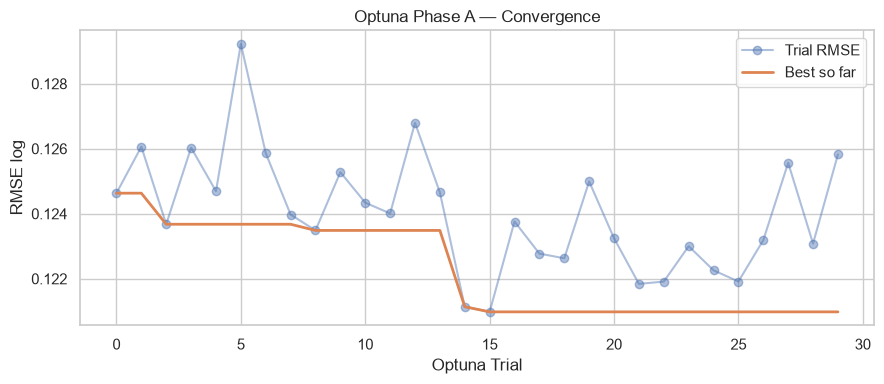

In [74]:
# Phase 3 diagnostic — Optuna convergence

# Ambil hasil setiap trial untuk melihat perkembangan RMSE Log.
optuna_history = pd.DataFrame([
    {
        "trial": t.number,
        "RMSE_log": t.value,
        "state": str(t.state),
    }
    for t in broad_study.trials
    if t.value is not None
])

# Simpan RMSE terbaik yang sudah ditemukan sampai setiap trial.
optuna_history["best_so_far"] = optuna_history["RMSE_log"].cummin()

# Tampilkan beberapa trial terakhir untuk melihat
# apakah hasil mulai stabil di akhir search.
display(optuna_history.tail(10).round(6))

# Visualisasi perkembangan RMSE setiap trial
# dan nilai terbaik yang ditemukan sampai saat itu.
plt.figure(figsize=(9, 4))

plt.plot(
    optuna_history["trial"],
    optuna_history["RMSE_log"],
    marker="o",
    alpha=0.45,
    label="Trial RMSE"
)

plt.plot(
    optuna_history["trial"],
    optuna_history["best_so_far"],
    linewidth=2,
    label="Best so far"
)

plt.xlabel("Optuna Trial")
plt.ylabel("RMSE log")
plt.title("Optuna Phase A — Convergence")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretasi Convergence:**

Grafik convergence menunjukkan bahwa **best RMSE Log** membaik selama proses search. Pada awal trial, hasil masih cukup bervariasi. Optimizer kemudian menemukan improvement bertahap hingga mencapai **0.120981** pada sekitar trial ke-14–15. Setelah itu, **best value tidak mengalami improvement lagi sampai trial ke-29**, meskipun trial berikutnya masih menghasilkan RMSE yang naik-turun di sekitar area tersebut.

**Artinya:** search space Phase A sudah mulai menemukan area parameter yang menjanjikan, dan improvement tambahan dari pencarian luas terlihat semakin sulit diperoleh.

**Keputusan:** hasil Phase A digunakan sebagai pusat untuk mempersempit search space pada **Phase B — Focused Refinement**, daripada terus melakukan broad search dengan area yang sama.

In [75]:
# Phase 4 — Focused Refinement di sekitar kandidat terbaik
#
# Titik pusat dipilih dari hasil terbaik:
#   (1) Coarse Randomized Search
#   (2) Optuna Phase A
#
# Dengan cara ini, Phase B tidak hanya bergantung pada satu metode.

phase_a_best = broad_study.best_params
phase_a_score = broad_study.best_value
coarse_score = float(coarse_results.iloc[0]["RMSE_log"])

if coarse_score < phase_a_score:
    refinement_center = coarse_best_params.copy()
    refinement_source = "Coarse Randomized Search"
else:
    refinement_center = phase_a_best.copy()
    refinement_source = "Optuna Phase A"

print("Refinement center berasal dari:", refinement_source)
print("Center RMSE_log:", round(min(coarse_score, phase_a_score), 6))


# Membuat rentang pencarian di sekitar titik pusat.
# Rentang tetap dibatasi agar search tidak keluar dari area yang realistis.
def clipped(low, high, center, frac=0.20):
    return max(low, center * (1 - frac)), min(high, center * (1 + frac))


n_low, n_high = clipped(
    900, 2600, refinement_center["n_estimators"], 0.20
)
lr_low, lr_high = clipped(
    0.008, 0.05, refinement_center["learning_rate"], 0.25
)
mcw_low, mcw_high = clipped(
    1.0, 10.0, refinement_center["min_child_weight"], 0.30
)
sub_low, sub_high = clipped(
    0.60, 0.95, refinement_center["subsample"], 0.15
)
col_low, col_high = clipped(
    0.35, 0.85, refinement_center["colsample_bytree"], 0.15
)
lam_low, lam_high = clipped(
    0.3, 15.0, refinement_center["reg_lambda"], 0.40
)
alpha_low, alpha_high = clipped(
    1e-6, 0.5, refinement_center["reg_alpha"], 0.50
)
gamma_low, gamma_high = (
    0.0,
    min(0.10, max(0.01, refinement_center["gamma"] * 2.5))
)


# Objective Phase B menggunakan search space yang lebih sempit
# dan tetap memakai evaluator CV yang sama.
def focused_objective(trial):
    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", int(n_low), int(n_high)
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", lr_low, lr_high, log=True
        ),
        "max_depth": trial.suggest_int(
            "max_depth",
            max(2, int(refinement_center["max_depth"]) - 1),
            min(5, int(refinement_center["max_depth"]) + 1),
        ),
        "min_child_weight": trial.suggest_float(
            "min_child_weight", mcw_low, mcw_high, log=True
        ),
        "subsample": trial.suggest_float(
            "subsample", sub_low, sub_high
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", col_low, col_high
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", lam_low, lam_high, log=True
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", alpha_low, alpha_high, log=True
        ),
        "gamma": trial.suggest_float(
            "gamma", gamma_low, gamma_high
        ),
    }

    mean_rmse, std_rmse = broad_cv_score(params)

    # Simpan variasi RMSE antar-fold untuk analisis kandidat.
    trial.set_user_attr("rmse_std", std_rmse)

    return mean_rmse


focused_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE + 1,
        n_startup_trials=5,
    ),
)

# Enqueue titik pusat yang sudah diperoleh dari eksperimen sebelumnya.
# Titik ini tetap berasal dari hasil search pada notebook ini.
focused_study.enqueue_trial(refinement_center)

# Cari kombinasi yang lebih baik di sekitar area terbaik Phase A.
focused_study.optimize(
    focused_objective,
    n_trials=20,
    show_progress_bar=True,
)

print("\nPhase B selesai.")
print("Best RMSE_log:", round(focused_study.best_value, 6))

print("Best parameters:")
for k, v in focused_study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-09-10 15:04:40,610] A new study created in memory with name: no-name-cbba5758-b190-4602-a86e-6b0d47b14603


Refinement center berasal dari: Optuna Phase A
Center RMSE_log: 0.120981


Best trial: 0. Best value: 0.120981:   5%|▌         | 1/20 [00:02<00:45,  2.40s/it]

[I 2026-09-10 15:04:43,012] Trial 0 finished with value: 0.12098054427810034 and parameters: {'n_estimators': 2165, 'learning_rate': 0.024811163001369888, 'max_depth': 2, 'min_child_weight': 1.9836806992242824, 'subsample': 0.8184227116696507, 'colsample_bytree': 0.7427630611821371, 'reg_lambda': 1.1510527698540107, 'reg_alpha': 1.432676346352993e-05, 'gamma': 0.006718426290242995}. Best is trial 0 with value: 0.12098054427810034.


Best trial: 0. Best value: 0.120981:  10%|█         | 2/20 [00:04<00:40,  2.28s/it]

...

[I 2026-09-10 15:05:28,295] Trial 17 finished with value: 0.12360813219663662 and parameters: {'n_estimators': 2249, 'learning_rate': 0.02786157480551238, 'max_depth': 3, 'min_child_weight': 2.0787964979897846, 'subsample': 0.7916011938618815, 'colsample_bytree': 0.7195828220890366, 'reg_lambda': 1.0972870794513825, 'reg_alpha': 9.919143104350812e-06, 'gamma': 0.006074809315750005}. Best is trial 0 with value: 0.12098054427810034.


Best trial: 0. Best value: 0.120981:  95%|█████████▌| 19/20 [00:51<00:03,  3.05s/it]

[I 2026-09-10 15:05:32,247] Trial 18 finished with value: 0.12144014322951409 and parameters: {'n_estimators': 2057, 'learning_rate': 0.01971241294111176, 'max_depth': 3, 'min_child_weight': 1.6010632114223435, 'subsample': 0.7621827215366637, 'colsample_bytree': 0.7527035672119116, 'reg_lambda': 1.3949014816802652, 'reg_alpha': 1.2856460893276315e-05, 'gamma': 0.0028110565782968784}. Best is trial 0 with value: 0.12098054427810034.


Best trial: 0. Best value: 0.120981: 100%|██████████| 20/20 [00:53<00:00,  2.67s/it]

[I 2026-09-10 15:05:34,106] Trial 19 finished with value: 0.12223367535942378 and parameters: {'n_estimators': 1740, 'learning_rate': 0.026524309793789298, 'max_depth': 2, 'min_child_weight': 2.3523031980192326, 'subsample': 0.696557496496067, 'colsample_bytree': 0.7065881271634126, 'reg_lambda': 0.8903326242835865, 'reg_alpha': 8.511995807123371e-06, 'gamma': 0.014045425095515977}. Best is trial 0 with value: 0.12098054427810034.

Phase B selesai.
Best RMSE_log: 0.120981
Best parameters:
  n_estimators: 2165
  learning_rate: 0.024811163001369888
  max_depth: 2
  min_child_weight: 1.9836806992242824
  subsample: 0.8184227116696507
  colsample_bytree: 0.7427630611821371
  reg_lambda: 1.1510527698540107
  reg_alpha: 1.432676346352993e-05
  gamma: 0.006718426290242995


**Interpretasi Focused Refinement:**

Phase B mempersempit search space di sekitar kandidat terbaik dari **Optuna Phase A**. Phase A menghasilkan RMSE Log **0.120981**.

Hasil Phase B: **RMSE Log = 0.120981** dan tidak ada improvement dari Phase A.

Parameter terbaik yang ditemukan juga **sama persis** dengan kandidat terbaik Phase A:

- `n_estimators = 2165`
- `learning_rate ≈ 0.02481`
- `max_depth = 2`
- `min_child_weight ≈ 1.98`
- `subsample ≈ 0.818`
- `colsample_bytree ≈ 0.743`
- `reg_lambda ≈ 1.15`
- `reg_alpha ≈ 1.43e-05`
- `gamma ≈ 0.00672`

**Artinya:** search tambahan di sekitar area terbaik Phase A belum menemukan kombinasi yang lebih baik. Kandidat Phase A tampaknya sudah berada di area yang cukup kuat dalam search space yang digunakan. Karena Phase B tidak memberikan improvement, tidak perlu memaksakan tuning lebih jauh pada area yang sama.

**Keputusan:** kandidat **RMSE Log = 0.120981** dipertahankan sebagai kandidat tuning terbaik sementara dan selanjutnya perlu **dikonfirmasi dengan evaluasi CV yang sama secara fold-by-fold** sebelum digunakan pada tahap berikutnya.

,trial,RMSE_log,state,best_so_far
0,0,0.120981,TrialState.COMPLETE,0.120981
1,1,0.121380,TrialState.COMPLETE,0.120981
2,2,0.121668,TrialState.COMPLETE,0.120981
3,3,0.123554,TrialState.COMPLETE,0.120981
4,4,0.122136,TrialState.COMPLETE,0.120981
5,5,0.123018,TrialState.COMPLETE,0.120981
6,6,0.125225,TrialState.COMPLETE,0.120981
7,7,0.121817,TrialState.COMPLETE,0.120981
8,8,0.121014,TrialState.COMPLETE,0.120981
9,9,0.122666,TrialState.COMPLETE,0.120981


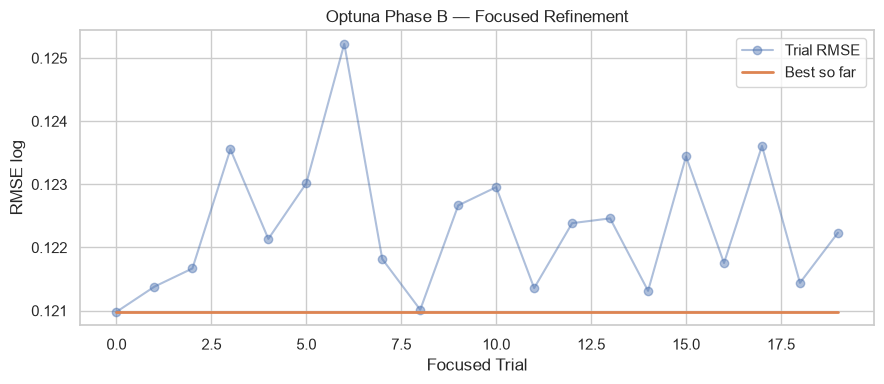

Relative parameter importance (Focused Phase):


,parameter,importance
0,min_child_weight,0.430356
1,learning_rate,0.280276
2,subsample,0.126199
3,n_estimators,0.055597
4,reg_alpha,0.046493
5,reg_lambda,0.022301
6,max_depth,0.016390
7,gamma,0.014296
8,colsample_bytree,0.008091


In [76]:
# Phase 4 diagnostics — Focused convergence + parameter importance

# Ambil hasil setiap trial untuk melihat perkembangan RMSE Log
# selama focused refinement.
focused_history = pd.DataFrame([
    {
        "trial": t.number,
        "RMSE_log": t.value,
        "state": str(t.state),
    }
    for t in focused_study.trials
    if t.value is not None
])

# Simpan RMSE terbaik yang sudah ditemukan sampai setiap trial.
focused_history["best_so_far"] = focused_history["RMSE_log"].cummin()

display(focused_history.round(6))


# Visualisasi hasil setiap trial dan perkembangan
# nilai terbaik selama focused refinement.
plt.figure(figsize=(9, 4))

plt.plot(
    focused_history["trial"],
    focused_history["RMSE_log"],
    marker="o",
    alpha=0.45,
    label="Trial RMSE"
)

plt.plot(
    focused_history["trial"],
    focused_history["best_so_far"],
    linewidth=2,
    label="Best so far"
)

plt.xlabel("Focused Trial")
plt.ylabel("RMSE log")
plt.title("Optuna Phase B — Focused Refinement")
plt.legend()
plt.tight_layout()
plt.show()


# Hitung perkiraan kontribusi relatif setiap parameter
# terhadap variasi hasil selama focused search.
try:
    importances = optuna.importance.get_param_importances(focused_study)

    importance_df = pd.DataFrame(
        list(importances.items()),
        columns=["parameter", "importance"]
    ).sort_values("importance", ascending=False)

    print("Relative parameter importance (Focused Phase):")
    display(importance_df.round(6))

except Exception as e:
    print(
        "Parameter importance tidak dapat dihitung:",
        type(e).__name__,
        e,
    )

**Interpretasi Focused Refinement Diagnostics:**

Diagnostic Phase B menunjukkan bahwa hasil trial masih cukup bervariasi, tetapi **best value tetap bertahan di 0.120981** sejak trial pertama. Dan tidak ada trial setelahnya yang mampu memberikan improvement, sehingga focused search belum menemukan area yang lebih baik dari kandidat Phase A.

Parameter importance menunjukkan:

- `min_child_weight` → **43.04%**
- `learning_rate` → **28.03%**
- `subsample` → **12.62%**
- `n_estimators` → **5.56%**
- parameter lainnya memiliki pengaruh relatif lebih kecil dalam search ini.

Dua parameter teratas, `min_child_weight` dan `learning_rate`, menjelaskan sebagian besar variasi objective selama focused search. Namun, **importance bukan bukti bahwa parameter tersebut secara kausal menyebabkan score menjadi lebih baik**. Nilai ini hanya menunjukkan seberapa besar variasi objective yang dapat dijelaskan oleh parameter selama search yang dilakukan.

**Artinya:** Phase B sudah cukup menunjukkan bahwa area terbaik Phase A sulit diperbaiki dengan search tambahan di sekitar area tersebut.

**Keputusan:** kandidat **RMSE Log = 0.120981** dipertahankan dan selanjutnya dikonfirmasi menggunakan **CV yang sama secara fold-by-fold**.

#### 8.8.7 Master Tuning Log Isinya Semua Percobaan dalam Satu Tabel

Bagian ini menggabungkan seluruh hasil tuning dalam satu tabel:

- baseline
- sensitivity
- coarse randomized search
- Optuna Phase A
- Optuna Phase B

Tujuannya agar proses tuning dapat ditelusuri dari **baseline hingga kandidat terbaik**, bukan hanya melihat hasil akhirnya.

In [77]:
# Master experiment log
master_rows = []

# Baseline
master_rows.append({
    "stage": "Baseline",
    "trial": 0,
    "RMSE_log": baseline_broad_rmse,
    "RMSE_log_std": baseline_broad_std,
    **baseline_broad_params,
})

# Phase 1 — One-factor
for _, row in sensitivity_df[
    sensitivity_df["stage"].eq("One-factor")
].iterrows():

    # Kembalikan semua parameter ke baseline,
    # lalu ubah hanya parameter yang sedang diuji.
    params = baseline_broad_params.copy()
    params[row["changed_parameter"]] = row["value"]

    master_rows.append({
        "stage": "Phase 1 — One-factor",
        "trial": len(master_rows),
        "RMSE_log": row["RMSE_log"],
        "RMSE_log_std": row["RMSE_log_std"],
        **params,
    })

# Phase 2 — Coarse Randomized Search
for _, row in coarse_results.iterrows():
    master_rows.append({
        "stage": "Phase 2 — Coarse Randomized",
        "trial": int(row["trial"]),
        "RMSE_log": row["RMSE_log"],
        "RMSE_log_std": row["RMSE_log_std"],
        **{
            k: row[k]
            for k in coarse_space.keys()
        },
    })

# Phase 3 — Optuna A
for t in broad_study.trials:
    if t.value is not None:
        master_rows.append({
            "stage": "Phase 3 — Optuna A",
            "trial": int(t.number),
            "RMSE_log": float(t.value),
            "RMSE_log_std": t.user_attrs.get("rmse_std", np.nan),
            **t.params,
        })

# Phase 4 — Optuna B
for t in focused_study.trials:
    if t.value is not None:
        master_rows.append({
            "stage": "Phase 4 — Optuna B",
            "trial": int(t.number),
            "RMSE_log": float(t.value),
            "RMSE_log_std": t.user_attrs.get("rmse_std", np.nan),
            **t.params,
        })

# Susun seluruh eksperimen dalam satu tabel.
master_tuning_log = pd.DataFrame(master_rows)

parameter_cols = [
    "n_estimators",
    "learning_rate",
    "max_depth",
    "min_child_weight",
    "subsample",
    "colsample_bytree",
    "reg_lambda",
    "reg_alpha",
    "gamma",
]

master_tuning_log = master_tuning_log[
    ["stage", "trial", "RMSE_log", "RMSE_log_std"] + parameter_cols
].sort_values("RMSE_log").reset_index(drop=True)

print("Total recorded experiments:", len(master_tuning_log))

display(
    master_tuning_log.head(20).round(6)
)

print("\nTop 5 configurations:")
display(
    master_tuning_log.head(5).round(6)
)

Total recorded experiments: 81


,stage,trial,RMSE_log,RMSE_log_std,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,reg_alpha,gamma
0,Phase 3 — Optuna A,15,0.120981,0.016028,2165.0,0.024811,2.0,1.983681,0.818423,0.742763,1.151053,0.000014,0.006718
1,Phase 4 — Optuna B,0,0.120981,0.016028,2165.0,0.024811,2.0,1.983681,0.818423,0.742763,1.151053,0.000014,0.006718
2,Phase 4 — Optuna B,8,0.121014,0.015976,1971.0,0.018630,3.0,1.890409,0.697274,0.645143,0.925064,0.000011,0.015386
3,Phase 3 — Optuna A,14,0.121139,0.015395,2113.0,0.018979,3.0,1.634287,0.731996,0.731651,1.580631,0.000470,0.008460
4,Phase 4 — Optuna B,14,0.121314,0.016382,2282.0,0.023952,2.0,1.761876,0.883968,0.694078,1.141647,0.000009,0.004539
5,Phase 4 — Optuna B,11,0.121357,0.016514,1981.0,0.018648,3.0,1.961058,0.704550,0.648415,0.968444,0.000011,0.016723
6,Phase 4 — Optuna B,1,0.121380,0.015788,1831.0,0.025400,2.0,1.611578,0.775981,0.819200,1.214373,0.000013,0.000487
7,Phase 4 — Optuna B,18,0.121440,0.015153,2057.0,0.019712,3.0,1.601063,0.762183,0.752704,1.394901,0.000013,0.002811
8,Phase 4 — Optuna B,2,0.121668,0.014984,2368.0,0.022768,3.0,1.625435,0.709626,0.820843,0.832875,0.000011,0.005309
9,Phase 4 — Optuna B,16,0.121754,0.016263,1891.0,0.023074,2.0,1.793287,0.740618,0.775676,0.816924,0.000018,0.009954



Top 5 configurations:


,stage,trial,RMSE_log,RMSE_log_std,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,reg_alpha,gamma
0,Phase 3 — Optuna A,15,0.120981,0.016028,2165.0,0.024811,2.0,1.983681,0.818423,0.742763,1.151053,0.000014,0.006718
1,Phase 4 — Optuna B,0,0.120981,0.016028,2165.0,0.024811,2.0,1.983681,0.818423,0.742763,1.151053,0.000014,0.006718
2,Phase 4 — Optuna B,8,0.121014,0.015976,1971.0,0.018630,3.0,1.890409,0.697274,0.645143,0.925064,0.000011,0.015386
3,Phase 3 — Optuna A,14,0.121139,0.015395,2113.0,0.018979,3.0,1.634287,0.731996,0.731651,1.580631,0.000470,0.008460
4,Phase 4 — Optuna B,14,0.121314,0.016382,2282.0,0.023952,2.0,1.761876,0.883968,0.694078,1.141647,0.000009,0.004539


Master Tuning Log mencatat seluruh eksperimen dari:

**Baseline**
→ **One-Factor Sensitivity**
→ **Coarse Randomized Search**
→ **Optuna Phase A**
→ **Optuna Phase B**

Hasil terbaik mencapai **RMSE Log = 0.120981**, dan muncul pada **Optuna Phase A**. Phase B menghasilkan nilai yang sama, sehingga belum memberikan improvement tambahan. Hal ini menunjukkan bahwa kandidat terbaik sudah ditemukan pada Phase A dan tetap bertahan setelah focused refinement.

Namun, hasil ini belum langsung dianggap final karena masih perlu memastikan performanya konsisten pada setiap fold.

**Keputusan:** kandidat **0.120981** dilanjutkan ke tahap **confirmation** menggunakan evaluator CV yang sama.

Alurnya:

**search → shortlist → confirmation → selection**

#### 8.8.8 Top-Candidate Confirmation

Pada tahap ini saya menguji ulang kandidat terbaik dari seluruh proses tuning menggunakan **5-Fold CV yang sama**. Tujuannya untuk memastikan hasil tuning tetap konsisten pada setiap fold sebelum kandidat dipilih.

Benchmark lama tetap hanya sebagai **reference**, bukan sebagai penentu kandidat.

**Keputusan:** kandidat dengan hasil confirmation terbaik akan digunakan sebagai **selected tuning candidate**.

In [78]:
# Candidate pool hanya berisi hasil eksperimen yang benar-benar
# dijalankan pada notebook ini.
# Benchmark lama tidak digunakan untuk memilih kandidat.
candidate_pool = [
    ("Baseline", baseline_broad_params, baseline_broad_rmse),
    ("Coarse Randomized Search", coarse_best_params, coarse_score),
]

candidate_pool.append(
    ("Optuna Phase A", broad_study.best_params, broad_study.best_value)
)

candidate_pool.append(
    ("Optuna Phase B", focused_study.best_params, focused_study.best_value)
)


# Tampilkan kandidat berdasarkan hasil search sebelum confirmation.
candidate_summary = pd.DataFrame([
    {
        "candidate": name,
        "search_rmse_log": score,
    }
    for name, _, score in candidate_pool
]).sort_values("search_rmse_log").reset_index(drop=True)

print("=== CURRENT NOTEBOOK CANDIDATES BEFORE CONFIRMATION ===")
display(candidate_summary.round(6))


# Konfirmasi setiap kandidat menggunakan fresh 5-Fold CV.
# Evaluator tetap sama agar hasil dapat dibandingkan secara adil.
confirmation_rows = []

for name, params, _ in candidate_pool:
    mean_rmse, std_rmse, fold_scores = broad_cv_score(
        params,
        return_fold_scores=True,
    )

    confirmation_rows.append({
        "candidate": name,
        "RMSE_log_mean_confirmed": mean_rmse,
        "RMSE_log_std_confirmed": std_rmse,
        "fold_scores": fold_scores,
        "params": params,
    })


# Urutkan berdasarkan hasil RMSE Log setelah confirmation.
confirmation_df = pd.DataFrame(confirmation_rows).sort_values(
    "RMSE_log_mean_confirmed"
).reset_index(drop=True)

print("\n=== CONFIRMED CURRENT CANDIDATES ===")
display(
    confirmation_df[
        [
            "candidate",
            "RMSE_log_mean_confirmed",
            "RMSE_log_std_confirmed",
            "fold_scores",
        ]
    ].round(6)
)


# Pilih kandidat terbaik berdasarkan hasil confirmation,
# bukan hanya berdasarkan hasil search sebelumnya.
best_confirmed = confirmation_df.iloc[0]

candidate_params = best_confirmed["params"]
selected_candidate_name = best_confirmed["candidate"]

print("\nSelected tuning candidate:", selected_candidate_name)
print(
    "Confirmed RMSE_log:",
    round(float(best_confirmed["RMSE_log_mean_confirmed"]), 6)
)

print("Parameters:")
for k, v in candidate_params.items():
    print(f"  {k}: {v}")


# Benchmark lama diperiksa secara terpisah sebagai reference.
# Hasilnya tidak boleh menggantikan kandidat dari notebook ini.
benchmark_reference_rmse, benchmark_reference_std, benchmark_reference_folds = (
    broad_cv_score(
        assistant_benchmark_params,
        return_fold_scores=True,
    )
)

print(
    "\nPrevious benchmark reference RMSE_log:",
    round(benchmark_reference_rmse, 6)
)
print(
    "Previous benchmark reference STD     :",
    round(benchmark_reference_std, 6)
)
print("Reference is NOT used to select the current candidate.")


# Hitung kembali metric dalam business scale untuk kandidat terpilih.
# RMSE Log tetap menjadi metric utama.
final_cv_mean = float(
    best_confirmed["RMSE_log_mean_confirmed"]
)
final_cv_std = float(
    best_confirmed["RMSE_log_std_confirmed"]
)

selected_business_rows = []

for fold_no, (tr_idx, va_idx) in enumerate(
    broad_cv.split(X_broad, y_broad),
    start=1,
):
    # Preprocessor di-fit hanya pada training fold.
    pre = make_broad_preprocessor()

    X_tr = pre.fit_transform(X_broad.iloc[tr_idx])
    X_va = pre.transform(X_broad.iloc[va_idx])

    # Gunakan parameter kandidat terpilih.
    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=1,
        tree_method="hist",
        verbosity=0,
        **candidate_params,
    )

    # Model dilatih menggunakan target log1p.
    model.fit(
        X_tr,
        np.log1p(y_broad.iloc[tr_idx].to_numpy()),
        verbose=False,
    )

    # Prediksi dikembalikan ke skala harga asli
    # untuk menghitung MAE dan R².
    pred_log = model.predict(X_va)
    pred_usd = np.expm1(pred_log)
    y_usd = y_broad.iloc[va_idx].to_numpy()

    selected_business_rows.append({
        "fold": fold_no,
        "RMSE_log": np.sqrt(
            mean_squared_error(
                np.log1p(y_usd),
                pred_log,
            )
        ),
        "MAE_USD": mean_absolute_error(
            y_usd,
            pred_usd,
        ),
        "R2": r2_score(
            y_usd,
            pred_usd,
        ),
    })


# Gabungkan metric dari seluruh fold.
selected_business_df = pd.DataFrame(
    selected_business_rows
)

print("\n=== SELECTED CURRENT CANDIDATE — BUSINESS METRICS ===")
print(
    "RMSE_log mean:",
    round(selected_business_df["RMSE_log"].mean(), 6)
)
print(
    "RMSE_log std :",
    round(selected_business_df["RMSE_log"].std(ddof=0), 6)
)
print(
    "MAE USD mean :",
    round(selected_business_df["MAE_USD"].mean(), 2)
)
print(
    "R2 mean      :",
    round(selected_business_df["R2"].mean(), 6)
)

display(
    selected_business_df.round(6)
)

=== CURRENT NOTEBOOK CANDIDATES BEFORE CONFIRMATION ===


,candidate,search_rmse_log
0,Optuna Phase A,0.120981
1,Optuna Phase B,0.120981
2,Coarse Randomized Search,0.123018
3,Baseline,0.125265



=== CONFIRMED CURRENT CANDIDATES ===


,candidate,RMSE_log_mean_confirmed,RMSE_log_std_confirmed,fold_scores
0,Optuna Phase A,0.120981,0.016028,"[0.12830808541180053, 0.12810768738952272, 0.1..."
1,Optuna Phase B,0.120981,0.016028,"[0.12830808541180053, 0.12810768738952272, 0.1..."
2,Coarse Randomized Search,0.123018,0.016707,"[0.12779562259801977, 0.13030984855358377, 0.1..."
3,Baseline,0.125265,0.017643,"[0.13072907713795942, 0.132040276692724, 0.151..."



Selected tuning candidate: Optuna Phase A
Confirmed RMSE_log: 0.120981
Parameters:
  n_estimators: 2165
  learning_rate: 0.024811163001369888
  max_depth: 2
  min_child_weight: 1.9836806992242824
  subsample: 0.8184227116696507
  colsample_bytree: 0.7427630611821371
  reg_lambda: 1.1510527698540107
  reg_alpha: 1.432676346352993e-05
  gamma: 0.006718426290242995

Previous benchmark reference RMSE_log: 0.121389
Previous benchmark reference STD     : 0.017174
Reference is NOT used to select the current candidate.

=== SELECTED CURRENT CANDIDATE — BUSINESS METRICS ===
RMSE_log mean: 0.120981
RMSE_log std : 0.016028
MAE USD mean : 14774.2
R2 mean      : 0.891217


,fold,RMSE_log,MAE_USD,R2
0,1,0.128308,14031.475586,0.916850
1,2,0.128108,16028.291992,0.850723
2,3,0.143369,16096.624023,0.843498
3,4,0.102735,14083.745117,0.921882
4,5,0.102384,13630.875977,0.923130


**Interpretasi Top-Candidate Confirmation:**

Tahap ini mengonfirmasi kembali kandidat yang dihasilkan dari proses tuning pada notebook ini.

Hasil confirmation:

| Candidate | Confirmed RMSE Log | Std |
|---|---:|---:|
| Optuna Phase A | **0.120981** | **0.016028** |
| Optuna Phase B | **0.120981** | **0.016028** |
| Coarse Search | 0.123018 | 0.016707 |
| Baseline | 0.125265 | 0.017643 |

Phase A dan Phase B menghasilkan **score yang sama**, sehingga Phase B tidak memberikan improvement tambahan.

Fold-level score kandidat terpilih:

- Fold 1 = **0.128308**
- Fold 2 = **0.128108**
- Fold 3 = **0.143369**
- Fold 4 = **0.102735**
- Fold 5 = **0.102384**

Fold 3 masih menjadi fold paling sulit, sedangkan Fold 5 menjadi yang terbaik.

Dalam business scale, kandidat terpilih menghasilkan:

- MAE = **$14,774**
- R² = **0.8912**

**Artinya:** kandidat Optuna tetap konsisten setelah dilakukan confirmation dan memberikan improvement dibandingkan baseline.

**Keputusan:** **Optuna Phase A** menjadi selected tuning candidate dengan RMSE Log **0.120981**.

Holdout tetap **sealed** dan belum digunakan pada tahap ini.

#### 8.8.9 Tuning Journey

Bagian ini membandingkan hasil dari setiap tahap tuning dalam satu tabel. Tujuannya untuk melihat **seberapa besar improvement dari baseline hingga kandidat terpilih**, sekaligus membandingkannya dengan benchmark lama. Benchmark lama tetap digunakan sebagai **reference-only**, bukan untuk memilih kandidat.

In [79]:
# Ambil hasil terbaik dari Phase 1 sebagai pembanding.
best_one_factor_rmse = sensitivity_df.loc[
    sensitivity_df["stage"].eq("One-factor"),
    "RMSE_log"
].min()


# Gabungkan hasil utama dari setiap tahap eksperimen.
journey_rows = [
    {
        "stage": "Baseline XGBoost",
        "RMSE_log": baseline_broad_rmse,
        "source": "current notebook",
    },
    {
        "stage": "Best One-Factor Sensitivity",
        "RMSE_log": best_one_factor_rmse,
        "source": "Phase 1",
    },
    {
        "stage": "Best Coarse Randomized",
        "RMSE_log": coarse_score,
        "source": "Phase 2",
    },
]


# Tambahkan hasil Optuna Phase A.
journey_rows.append({
    "stage": "Optuna Phase A",
    "RMSE_log": broad_study.best_value,
    "source": "Phase 3",
})


# Tambahkan hasil Optuna Phase B.
journey_rows.append({
    "stage": "Optuna Phase B",
    "RMSE_log": focused_study.best_value,
    "source": "Phase 4",
})


# Benchmark lama hanya ditampilkan sebagai reference.
journey_rows.append({
    "stage": "Previous benchmark reference",
    "RMSE_log": benchmark_reference_rmse,
    "source": "reference-only re-evaluation",
})


# Hasil confirmation menjadi kandidat yang dipilih.
journey_rows.append({
    "stage": "Selected confirmed candidate",
    "RMSE_log": float(
        best_confirmed["RMSE_log_mean_confirmed"]
    ),
    "source": "top-candidate confirmation",
})


# Susun seluruh perjalanan eksperimen dalam satu tabel.
tuning_journey_df = pd.DataFrame(journey_rows)

display(
    tuning_journey_df
    .sort_values("RMSE_log")
    .reset_index(drop=True)
    .round(6)
)


# Hitung improvement kandidat terpilih terhadap broad baseline.
baseline = baseline_broad_rmse
selected_rmse = float(
    best_confirmed["RMSE_log_mean_confirmed"]
)

improvement = (
    (baseline - selected_rmse) / baseline * 100
)

print(
    f"Improvement vs current broad baseline: "
    f"{improvement:.2f}%"
)

,stage,RMSE_log,source
0,Optuna Phase A,0.120981,Phase 3
1,Optuna Phase B,0.120981,Phase 4
2,Selected confirmed candidate,0.120981,top-candidate confirmation
3,Previous benchmark reference,0.121389,reference-only re-evaluation
4,Best One-Factor Sensitivity,0.122553,Phase 1
5,Best Coarse Randomized,0.123018,Phase 2
6,Baseline XGBoost,0.125265,current notebook


Improvement vs current broad baseline: 3.42%


**Interpretasi Tuning Journey**

Sekarang perjalanan tuning sudah terlihat dengan jelas.

| Tahap | RMSE Log |
|---|---:|
| Baseline broad | **0.125265** |
| Best One-Factor | **0.122553** |
| Coarse Randomized | **0.123018** |
| Optuna Phase A | **0.120981** |
| Optuna Phase B | **0.120981** |
| Confirmation | **0.120981** |

Tidak semua tahap harus selalu menghasilkan improvement. Coarse Search sedikit lebih buruk daripada Best One-Factor, tetapi hasil tersebut tetap berguna untuk menentukan arah pencarian berikutnya.

Optuna Phase A menemukan hasil terbaik **0.120981**, dan Phase B tidak memberikan improvement tambahan. Hasil tersebut juga tetap sama setelah confirmation.

Improvement dari broad baseline ke confirmed candidate:

**sekitar 3.42%**.

**Kesimpulan:** parameter terbaik diperoleh melalui rangkaian eksperimen yang bertahap dan terdokumentasi, bukan dari satu kali pencarian atau tebakan.

#### Catatan Reproducibility

Hasil tuning bergantung pada kondisi eksperimen yang digunakan. Di notebook ini saya menggunakan `random_state` dan evaluator CV yang konsisten, sehingga hasil dapat direproduksi dengan environment yang sama.

RMSE Log **0.120981** adalah hasil **5-Fold CV pada training set**

> "Kandidat hasil tuning memperoleh mean RMSE Log 0.120981 pada 5-Fold Cross-Validation training set."

Holdout tetap **sealed** sampai seluruh keputusan model selesai.

## 9. Champion Selection Gate

Setelah tuning selesai dan kandidat terbaik sudah dikonfirmasi, saya masuk ke **decision gate** untuk menentukan champion sebelum holdout dibuka.

**Candidate Champion Saat Ini:** XGBoost + Broad Non-Leaky Features + log target

Syarat sebelum membuka holdout:

- [x] Leakage audit lolos
- [x] Preprocessing dilakukan di dalam CV
- [x] Primary metric konsisten
- [x] Tuning hanya menggunakan training set
- [x] Best parameter sudah di-re-evaluate
- [ ] Final holdout evaluation

**Tahap Berikutnya:**

1. Fit champion pada **seluruh training set**.
2. Buka holdout **satu kali**.
3. Hitung RMSE Log, MAE USD, dan R².
4. Bandingkan hasil CV dengan holdout.
5. Jika quality gate lolos, simpan artifact.
6. Register model ke **MLflow Model Registry**.
7. Lanjut ke model interpretation, FastAPI, monitoring, dan Docker.

**Setelah holdout dibuka, tidak ada tuning lagi.**

### 9.1 Quality Gate
Pipeline yang bagus bukan hanya tahu kapan berhasil, tetapi juga **berani gagal**. Quality gate memastikan kandidat memenuhi syarat sebelum boleh membuka holdout. Jika ada pemeriksaan yang gagal, proses langsung berhenti dan kandidat tidak boleh lanjut ke tahap berikutnya.

Gate menggunakan `raise`, bukan hanya `print`, sehingga kegagalan benar-benar menghentikan pipeline, termasuk saat training dijalankan otomatis tanpa ada manusia yang memantau.

**Pemeriksaan Gate:**

- RMSE Log tidak boleh melewati ambang **0.15**
- Kandidat tidak boleh lebih buruk dari baseline
- Tidak ada kolom leakage yang digunakan
- Hyperparameter kandidat tersedia

Jika semua pemeriksaan lolos, **holdout boleh dibuka**.

In [80]:
# Ambang mutu yang harus dipenuhi oleh kandidat
GATE_MAX_RMSE_LOG = 0.15

# Kandidat minimal harus sama baiknya dengan baseline
GATE_MIN_IMPROVEMENT = 0.0

# Ambil hasil CV kandidat dan baseline sebagai angka
gate_candidate_rmse = float(final_cv_mean)
gate_baseline_rmse = float(baseline_broad_rmse)

# Setiap pemeriksaan menghasilkan:
# (nama pemeriksaan, True/False, bukti hasil pemeriksaan)
gate_checks = [
    (
        "RMSE_log <= ambang mutu",
        gate_candidate_rmse <= GATE_MAX_RMSE_LOG,
        f"{gate_candidate_rmse:.5f} vs ambang {GATE_MAX_RMSE_LOG}",
    ),
    (
        "Kandidat tidak lebih buruk dari baseline",
        (gate_baseline_rmse - gate_candidate_rmse) >= GATE_MIN_IMPROVEMENT,
        f"baseline {gate_baseline_rmse:.5f} -> kandidat {gate_candidate_rmse:.5f}",
    ),
    (
        "Kolom leakage tidak ikut terpakai",
        # Semua kolom leakage harus tidak ada di feature set
        all(c not in broad_features for c in leakage_features),
        f"dicek: {leakage_features}",
    ),
    (
        "Hyperparameter kandidat tersedia",
        # Kandidat harus memiliki parameter yang bisa digunakan untuk training
        isinstance(candidate_params, dict) and len(candidate_params) > 0,
        f"{len(candidate_params)} parameter",
    ),
]

# Buat tabel agar hasil setiap pemeriksaan mudah dilihat
gate_df = pd.DataFrame([
    {"pemeriksaan": n, "lolos": ok, "bukti": b}
    for n, ok, b in gate_checks
])

display(gate_df)

# Ambil semua pemeriksaan yang gagal
gate_gagal = [n for n, ok, _ in gate_checks if not ok]

# Jika ada satu saja yang gagal, hentikan pipeline
if gate_gagal:
    raise SystemExit(
        f"QUALITY GATE GAGAL: {gate_gagal}. "
        "Kandidat TIDAK boleh lanjut ke holdout evaluation."
    )

# Jika semua pemeriksaan lolos, tampilkan ringkasan hasil gate
print("=== QUALITY GATE ===")
print(f"Kandidat  : {selected_candidate_name}")
print(f"RMSE_log  : {gate_candidate_rmse:.5f} (std {final_cv_std:.5f})")
print(f"Baseline  : {gate_baseline_rmse:.5f}")
print(f"Perbaikan : {(1 - gate_candidate_rmse / gate_baseline_rmse) * 100:.2f}%")
print("STATUS    : LOLOS — holdout boleh dibuka.")

,pemeriksaan,lolos,bukti
0,RMSE_log <= ambang mutu,True,0.12098 vs ambang 0.15
1,Kandidat tidak lebih buruk dari baseline,True,baseline 0.12526 -> kandidat 0.12098
2,Kolom leakage tidak ikut terpakai,True,"dicek: ['MoSold', 'YrSold', 'SaleType', 'SaleC..."
3,Hyperparameter kandidat tersedia,True,9 parameter


=== QUALITY GATE ===
Kandidat  : Optuna Phase A
RMSE_log  : 0.12098 (std 0.01603)
Baseline  : 0.12526
Perbaikan : 3.42%
STATUS    : LOLOS — holdout boleh dibuka.


Quality gate menjalankan **empat pemeriksaan** sebelum holdout dibuka:

1. **RMSE Log ≤ 0.15** → lolos dengan **0.12098**.
2. **Tidak lebih buruk dari baseline** → 0.12098 lebih baik dari baseline **0.12526**.
3. **Tidak ada leakage** → semua kolom leakage tidak digunakan.
4. **Hyperparameter tersedia** → tersedia **9 parameter**.

Semua pemeriksaan **lolos**. Kandidat memberikan improvement sekitar **3.42%** dari baseline.

**Keputusan:** kandidat **Optuna Phase A** lolos quality gate, sehingga **holdout boleh dibuka satu kali**. Setelah holdout dibuka, tidak ada tuning lagi.

## 10. Advanced Error Reduction Experiments

Setelah quality gate lolos, saya masih ingin menguji apakah **RMSE Log dapat diturunkan lagi** tanpa leakage dan tanpa membuka holdout.

**Hipotesis yang Diuji:**

1. **Outlier removal vs tanpa outlier removal**
2. **Domain-safe feature engineering**
3. **XGBoost vs LightGBM**
4. **Blend XGBoost + LightGBM**
5. **Reproducibility check terhadap benchmark terbaik**


**Prinsip Eksperimen:**

- Holdout tetap **SEALED**.
- Outlier threshold dihitung **hanya dari training fold**.
- Feature engineering hanya menggunakan informasi yang tersedia saat prediction.
- `SalePrice` tidak digunakan untuk menentukan outlier.
- Tidak menggunakan label dari Kaggle test set.
- Primary metric tetap **RMSE Log pada `log1p(SalePrice)`**.

**Catatan:** target RMSE mendekati **0.00 bukan berarti model semakin sehat**. Pada validation atau holdout yang jujur, hasil yang terlalu mendekati nol justru perlu dicurigai. Fokus saya adalah mencari improvement yang **valid, konsisten, dan dapat dipertanggungjawabkan**.

### 10.1 Benchmark yang Sudah Tervalidasi

Sebelum masuk ke advanced experiment, saya mulai dari benchmark yang sudah diuji secara **controlled** menggunakan training data melalui CV.

| Experiment | Mean RMSE Log | Std |
|---|---:|---:|
| Broad 75 non-leaky + tuned XGBoost | **0.12220** | ~0.0169 |
| + Basic domain-safe FE | **0.11967** | ~0.0163 |
| + Fixed outlier removal | **0.12216** | ~0.0222 |
| + Fold-wise IQR removal | **0.12340** | ~0.0195 |
| XGB + LGBM blend 80/20 | **~0.11805** | ~0.0147 |

Hasil ini menunjukkan bahwa masih ada peluang improvement dari benchmark **0.12220**.

Yang paling menarik sementara adalah **Basic FE** dan **XGB + LGBM blend**. Namun, setiap perubahan tetap perlu diuji secara terpisah agar improvement tidak hanya terjadi karena kebetulan.

**Holdout tetap SEALED** dan belum digunakan.

### 10.2 Reproducible Benchmark (XGBoost + Domain-Safe FE)

Pada tahap ini saya menggunakan **parameter yang sudah dipilih dari tuning journey di Section 8**. Saya tidak ingin menggunakan parameter hardcoded karena benchmark harus benar-benar menggunakan hasil tuning yang sudah dikonfirmasi.

Jika `candidate_params` belum tersedia, proses dihentikan agar tidak diam-diam menggunakan parameter lain.

In [81]:
# Pastikan parameter hasil tuning dari Section 8 sudah tersedia.
# Jika belum ada, hentikan proses agar tidak menggunakan parameter lain.
assert "candidate_params" in globals(), (
    "candidate_params belum tersedia. Jalankan Section 8 tuning sampai confirmation."
)

# Salin parameter hasil tuning agar tidak mengubah variabel aslinya.
best_xgb_params = candidate_params.copy()

# Tampilkan parameter XGBoost yang benar-benar dipilih dari tuning journey.
print("Selected XGBoost parameters from tuning journey:")

for k, v in best_xgb_params.items():
    print(f"  {k}: {v}")

Selected XGBoost parameters from tuning journey:
  n_estimators: 2165
  learning_rate: 0.024811163001369888
  max_depth: 2
  min_child_weight: 1.9836806992242824
  subsample: 0.8184227116696507
  colsample_bytree: 0.7427630611821371
  reg_lambda: 1.1510527698540107
  reg_alpha: 1.432676346352993e-05
  gamma: 0.006718426290242995


#### 10.2.1 Advanced Experiment Helpers

Bagian ini berisi helper untuk menjalankan advanced experiment dengan cara yang konsisten. Setiap fold melakukan preprocessing **hanya dari training fold**, lalu digunakan untuk validation fold. Holdout tetap **SEALED** dan tidak digunakan.

Helper di bawah digunakan untuk menguji:
- domain-safe feature engineering;
- outlier removal;
- XGBoost dan LightGBM;
- serta menghasilkan prediksi OOF untuk blending.

In [82]:
from lightgbm import LGBMRegressor


def add_domain_safe_fe(df, variant=1):
    # Buat salinan agar dataframe asli tidak berubah.
    d = df.copy()

    # Ambil kolom jika tersedia; missing diisi 0 untuk fitur hasil perhitungan.
    def s(name):
        return d[name].fillna(0) if name in d.columns else 0

    # Variant 1: fitur dasar yang masih masuk akal tersedia saat prediction.
    if variant >= 1:
        d["TotalSF"] = s("TotalBsmtSF") + s("1stFlrSF") + s("2ndFlrSF")
        d["TotalBath"] = (
            s("FullBath") + 0.5 * s("HalfBath")
            + s("BsmtFullBath") + 0.5 * s("BsmtHalfBath")
        )
        d["TotalPorchSF"] = (
            s("OpenPorchSF") + s("3SsnPorch")
            + s("EnclosedPorch") + s("ScreenPorch") + s("WoodDeckSF")
        )
        d["QualxArea"] = s("OverallQual") * s("GrLivArea")

    # Variant 2: menambahkan beberapa kombinasi fitur tambahan.
    if variant >= 2:
        d["Total_sqr_footage"] = (
            s("BsmtFinSF1") + s("BsmtFinSF2") + s("1stFlrSF") + s("2ndFlrSF")
        )
        d["Total_sqr_footage_2"] = (
            s("TotalBsmtSF") + s("1stFlrSF") + s("2ndFlrSF")
        )
        d["TotalRooms"] = s("TotRmsAbvGrd") + s("FullBath") + s("HalfBath")
        d["OverallQual_GrLivArea"] = s("OverallQual") * s("GrLivArea")
        d["OverallQual_GarageCars"] = s("OverallQual") * s("GarageCars")

    # Variant 3: kombinasi fitur yang lebih spesifik.
    if variant >= 3:
        d["OverallQual_TotalSF"] = s("OverallQual") * s("TotalSF")
        d["OverallCond_OverallQual"] = s("OverallCond") * s("OverallQual")
        d["LivingArea_per_Room"] = s("GrLivArea") / (s("TotRmsAbvGrd") + 1)

    return d


def _advanced_frame_setup(df, variant=1):
    # Tambahkan feature engineering sebelum menentukan feature set.
    Xdf = add_domain_safe_fe(df, variant)

    # Buang ID, target, dan kolom yang tidak tersedia saat prediction.
    feats = [
        c for c in Xdf.columns
        if c not in ["Id", "SalePrice"] + leakage_features
    ]

    # Pisahkan fitur numerik dan kategorikal untuk preprocessing.
    nums = [c for c in feats if pd.api.types.is_numeric_dtype(Xdf[c])]
    cats = [c for c in feats if c not in nums]

    return Xdf, feats, nums, cats


def cv_xgb_fe_outlier(params, variant=1, outlier_mode=None):
    Xdf, feats, nums, cats = _advanced_frame_setup(train, variant)
    scores, maes, r2s, counts = [], [], [], []

    # Gunakan fold yang sama agar hasil antar eksperimen dapat dibandingkan.
    for tr_idx, va_idx in cv.split(Xdf):
        X_tr = Xdf.iloc[tr_idx].copy()
        X_va = Xdf.iloc[va_idx].copy()
        y_tr = X_tr["SalePrice"].copy()
        y_va = X_va["SalePrice"].copy()

        # Outlier fixed: threshold ditentukan sebelum training fold.
        if outlier_mode == "fixed_grliv_4000":
            keep = X_tr["GrLivArea"] <= 4000
            X_tr, y_tr = X_tr.loc[keep], y_tr.loc[keep]

        # Outlier IQR: threshold dihitung hanya dari training fold.
        elif outlier_mode == "iqr_grliv":
            q1 = X_tr["GrLivArea"].quantile(0.25)
            q3 = X_tr["GrLivArea"].quantile(0.75)
            upper = q3 + 1.5 * (q3 - q1)
            keep = X_tr["GrLivArea"] <= upper
            X_tr, y_tr = X_tr.loc[keep], y_tr.loc[keep]

        # Preprocessing dibuat dan di-fit ulang pada setiap training fold.
        pre = ColumnTransformer([
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]), nums),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True
                ))
            ]), cats),
        ])

        Xt = pre.fit_transform(X_tr[feats])
        Xv = pre.transform(X_va[feats])

        # Gunakan parameter XGBoost dari eksperimen yang sedang diuji.
        model = XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=1,
            tree_method="hist",
            verbosity=0,
            **params,
        )

        # Target tetap menggunakan log1p seperti eksperimen utama.
        model.fit(Xt, np.log1p(y_tr.to_numpy()), verbose=False)

        # Prediksi dibuat dalam log scale lalu dikembalikan ke USD.
        pred_log = model.predict(Xv)
        pred_usd = np.expm1(pred_log)

        # Hitung metric pada validation fold.
        scores.append(
            np.sqrt(
                mean_squared_error(
                    np.log1p(y_va.to_numpy()),
                    pred_log
                )
            )
        )
        maes.append(mean_absolute_error(y_va.to_numpy(), pred_usd))
        r2s.append(r2_score(y_va.to_numpy(), pred_usd))
        counts.append(len(y_tr))

    return (
        float(np.mean(scores)),
        float(np.std(scores)),
        float(np.mean(maes)),
        float(np.mean(r2s)),
        counts,
    )


def cv_xgb_fe(params, variant=1):
    # Jalankan CV XGBoost tanpa outlier removal.
    result = cv_xgb_fe_outlier(
        params,
        variant=variant,
        outlier_mode=None
    )

    # Tambahkan jumlah fitur sebagai informasi eksperimen.
    return (
        result[0],
        result[1],
        result[2],
        result[3],
        len(_advanced_frame_setup(train, variant)[1]),
    )


def cv_lgb(params, variant=1):
    Xdf, feats, nums, cats = _advanced_frame_setup(train, variant)
    scores, maes, r2s = [], [], []

    # Gunakan fold yang sama seperti XGBoost.
    for tr_idx, va_idx in cv.split(Xdf):
        X_tr = Xdf.iloc[tr_idx]
        X_va = Xdf.iloc[va_idx]
        y_tr = X_tr["SalePrice"].to_numpy()
        y_va = X_va["SalePrice"].to_numpy()

        # Preprocessing hanya di-fit pada training fold.
        pre = ColumnTransformer([
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]), nums),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True
                ))
            ]), cats),
        ])

        Xt = pre.fit_transform(X_tr[feats])
        Xv = pre.transform(X_va[feats])

        # Buat model LightGBM dengan parameter eksperimen.
        model = LGBMRegressor(
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=-1,
            **params,
        )

        # LightGBM juga dilatih menggunakan target log1p.
        model.fit(Xt, np.log1p(y_tr))

        pred_log = model.predict(Xv)
        pred_usd = np.expm1(pred_log)

        scores.append(
            np.sqrt(mean_squared_error(np.log1p(y_va), pred_log))
        )
        maes.append(mean_absolute_error(y_va, pred_usd))
        r2s.append(r2_score(y_va, pred_usd))

    return (
        float(np.mean(scores)),
        float(np.std(scores)),
        float(np.mean(maes)),
        float(np.mean(r2s)),
    )


def oof_model_preds_xgb_lgb(params_xgb, params_lgb, variant=1):
    Xdf, feats, nums, cats = _advanced_frame_setup(train, variant)

    # Array ini akan menyimpan prediksi OOF untuk setiap baris training.
    oof_xgb = np.zeros(len(Xdf))
    oof_lgb = np.zeros(len(Xdf))
    y = train["SalePrice"].to_numpy().copy()

    # Setiap baris validation hanya diprediksi oleh model
    # yang tidak pernah melihat baris tersebut saat training.
    for tr_idx, va_idx in cv.split(Xdf):
        X_tr = Xdf.iloc[tr_idx]
        X_va = Xdf.iloc[va_idx]
        y_tr = X_tr["SalePrice"].to_numpy()

        # Preprocessing tetap hanya di-fit pada training fold.
        pre = ColumnTransformer([
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]), nums),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True
                ))
            ]), cats),
        ])

        Xt = pre.fit_transform(X_tr[feats])
        Xv = pre.transform(X_va[feats])
        y_log = np.log1p(y_tr)

        # Model XGBoost.
        mx = XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=1,
            tree_method="hist",
            verbosity=0,
            **params_xgb,
        )

        # Model LightGBM.
        ml = LGBMRegressor(
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=-1,
            **params_lgb,
        )

        # Kedua model dilatih pada training fold yang sama.
        mx.fit(Xt, y_log, verbose=False)
        ml.fit(Xt, y_log)

        # Simpan prediksi validation fold sebagai OOF prediction.
        oof_xgb[va_idx] = mx.predict(Xv)
        oof_lgb[va_idx] = ml.predict(Xv)

    return y, oof_xgb, oof_lgb


print("Advanced experiment helpers siap.")

Advanced experiment helpers siap.


### 10.3 Compare Outlier Strategies Fairly

Saya ingin membandingkan beberapa strategi outlier dengan kondisi evaluasi yang sama.

**Aturannya:**

- outlier hanya dibuang dari **training fold**;
- validation fold tetap digunakan seluruhnya;
- threshold outlier tidak menggunakan `SalePrice`.

Dengan cara ini, setiap strategi dibandingkan secara adil tanpa memengaruhi validation data.

In [83]:
# Simpan hasil setiap strategi outlier untuk dibandingkan.
outlier_results = []

# Bandingkan tanpa removal, fixed threshold, dan IQR.
for mode, label in [
    (None, "No Outlier Removal"),
    ("fixed_grliv_4000", "GrLivArea > 4000 Removed"),
    ("iqr_grliv", "GrLivArea IQR Removed"),
]:
    # Evaluasi setiap strategi dengan fold dan parameter model yang sama.
    # Outlier hanya diproses pada training fold oleh helper di atas.
    mean_rmse, std_rmse, mae, r2, counts = cv_xgb_fe_outlier(
        best_xgb_params,
        variant=1,
        outlier_mode=mode
    )

    # Simpan metric dan jumlah baris training setelah outlier removal.
    outlier_results.append({
        "strategy": label,
        "RMSE_log_mean": mean_rmse,
        "RMSE_log_std": std_rmse,
        "MAE_USD_mean": mae,
        "R2_mean": r2,
        "avg_train_rows": np.mean(counts),
    })

# Urutkan dari RMSE Log terbaik ke terburuk.
outlier_comparison = (
    pd.DataFrame(outlier_results)
    .sort_values("RMSE_log_mean")
)

display(outlier_comparison.round(5))

/opt/anaconda3/envs/house-price-mlops/lib/python3.12/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['PoolQC']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/opt/anaconda3/envs/house-price-mlops/lib/python3.12/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['PoolQC']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


,strategy,RMSE_log_mean,RMSE_log_std,MAE_USD_mean,R2_mean,avg_train_rows
0,No Outlier Removal,0.11831,0.01299,14232.96836,0.90009,934.4
1,GrLivArea > 4000 Removed,0.12204,0.02033,14177.89219,0.87207,932.0
2,GrLivArea IQR Removed,0.12422,0.01739,14868.77812,0.86935,916.4


Eksperimen ini membandingkan tiga kondisi:

- **No removal:** RMSE Log = **0.11831**
- **Fixed `GrLivArea > 4000`:** = **0.12204**
- **Fold-wise IQR removal:** = **0.12422**

Hasilnya cukup jelas bahwa **menghapus outlier justru memperburuk performa model**.

Dibandingkan no removal:
- fixed removal lebih buruk sekitar **0.00373**;
- IQR removal lebih buruk sekitar **0.00591**.

Walaupun fixed removal menghasilkan MAE sedikit lebih rendah, RMSE Log dan R² justru lebih buruk. IQR juga menghasilkan performa yang paling rendah.

**Artinya:** observasi dengan `GrLivArea` yang ekstrem masih membawa informasi yang berguna bagi model dan tidak otomatis berarti data tersebut harus dibuang.

**Keputusan:** untuk candidate champion, **tidak ada outlier removal**. Jika penanganan outlier diperlukan di tahap lain, threshold tetap harus ditentukan dari **training fold** dan memiliki alasan yang jelas.

### 10.4 Domain-Safe Feature Engineering Ablation

Pada tahap ini saya menguji apakah **feature engineering benar-benar membantu performa model**.

Saya membandingkan empat feature set secara bertahap:

- **Baseline 75 features** → tanpa feature engineering
- **Basic FE** → fitur turunan dasar
- **Extended FE** → tambahan fitur turunan
- **Interaction FE** → tambahan fitur interaksi

Semua variant menggunakan parameter XGBoost yang sama dan dievaluasi dengan **5-Fold CV yang sama**. Tujuannya bukan sekadar menambah fitur, tetapi melihat **variant mana yang benar-benar memberikan improvement**.

In [84]:
# Definisikan feature set yang akan dibandingkan secara bertahap.
fe_variants = {
    "Baseline 75 features": 0,
    "Basic FE": 1,
    "Extended FE": 2,
    "Interaction FE": 3,
}

fe_results = []

# Evaluasi setiap feature set dengan parameter model dan CV yang sama.
for label, variant in fe_variants.items():
    rmse, std, mae, r2, n_features = cv_xgb_fe(
        best_xgb_params,
        variant
    )

    # Simpan hasil setiap variant agar mudah dibandingkan.
    fe_results.append({
        "feature_set": label,
        "variant": variant,
        "n_features": n_features,
        "RMSE_log_mean": rmse,
        "RMSE_log_std": std,
        "MAE_USD_mean": mae,
        "R2_mean": r2,
    })

# Urutkan dari RMSE Log terbaik ke yang terburuk.
fe_comparison = (
    pd.DataFrame(fe_results)
    .sort_values("RMSE_log_mean")
)

display(fe_comparison.round(5))

,feature_set,variant,n_features,RMSE_log_mean,RMSE_log_std,MAE_USD_mean,R2_mean
1,Basic FE,1,79,0.11831,0.01299,14232.96836,0.90009
3,Interaction FE,3,87,0.11922,0.01265,14777.59609,0.89424
2,Extended FE,2,84,0.11935,0.01268,14515.48672,0.89733
0,Baseline 75 features,0,75,0.12098,0.01603,14774.20254,0.89122


**Interpretasi Feature Engineering Ablation**

Hasilnya cukup jelas:

- **Basic FE:** RMSE Log = **0.11831**
- **Interaction FE:** = **0.11922**
- **Extended FE:** = **0.11935**
- **Baseline 75 features:** = **0.12098**

Basic FE memberikan hasil terbaik dan improvement sekitar **2.21%** dibandingkan baseline.

Basic FE terdiri dari:

- `TotalSF`
- `TotalBath`
- `TotalPorchSF`
- `QualxArea`

Menariknya, menambah fitur pada Extended FE dan Interaction FE justru membuat RMSE sedikit lebih buruk.

**Artinya:** feature engineering memang membantu, tetapi **lebih banyak fitur tidak otomatis lebih baik**.

**Keputusan:** **Basic FE dipertahankan** sebagai feature engineering terbaik pada eksperimen ini. Saya tidak menambah fitur hanya untuk memperbanyak jumlah fitur.

### 10.5 LightGBM Challenger

Saya menggunakan LightGBM sebagai **model pembanding** untuk melihat apakah ada alternatif yang memberikan hasil lebih baik dari XGBoost. Parameter LightGBM ditetapkan untuk eksperimen ini dan dievaluasi dengan **5-Fold CV yang sama** serta **Basic FE**.

LightGBM hanya menjadi **challenger**, bukan pengganti otomatis XGBoost.

In [85]:
# Parameter LightGBM untuk eksperimen challenger.
lgb_params = {
    "n_estimators": 2000,
    "learning_rate": 0.02,
    "num_leaves": 15,
    "max_depth": -1,
    "min_child_samples": 15,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "reg_lambda": 1.0,
}

# Evaluasi LightGBM menggunakan Basic FE dan CV yang sama.
lgb_result = cv_lgb(lgb_params, variant=1)

# Tampilkan hasil utama LightGBM untuk dibandingkan dengan XGBoost.
print("LightGBM Basic FE")
print("RMSE_log mean:", round(lgb_result[0], 6))
print("RMSE_log std :", round(lgb_result[1], 6))
print("MAE USD mean :", round(lgb_result[2], 2))
print("R2 mean      :", round(lgb_result[3], 6))

LightGBM Basic FE
RMSE_log mean: 0.12325
RMSE_log std : 0.01235
MAE USD mean : 15614.11
R2 mean      : 0.88781


LightGBM diuji sebagai challenger untuk melihat apakah model boosting lain dapat memberikan hasil yang lebih baik dari XGBoost.

Hasilnya:

- **LightGBM + Basic FE:** RMSE Log = **0.12325**
- **XGBoost + Basic FE:** RMSE Log = **0.11831**

LightGBM juga memiliki MAE **$15,614** dan R² **0.88781**. Jadi LightGBM sendiri **belum mengalahkan XGBoost**.

**Artinya:** belum ada alasan untuk mengganti XGBoost sebagai single champion. Namun, LightGBM tetap menarik untuk diuji karena model yang berbeda bisa menghasilkan prediksi yang berbeda.

**Keputusan:** LightGBM tetap digunakan sebagai **challenger untuk eksperimen blending**.

### 10.6 XGBoost + LightGBM OOF Blend

Pada tahap ini saya menguji apakah gabungan XGBoost dan LightGBM dapat memberikan hasil yang lebih baik daripada model tunggal. Saya menggunakan **OOF (Out-of-Fold) predictions**, sehingga setiap baris validation diprediksi oleh model yang **tidak pernah melihat baris tersebut saat training**.

Beberapa bobot XGBoost diuji dari **0% sampai 100%**. Hasil blending tetap dinilai menggunakan **mean RMSE per fold** agar konsisten dengan CV utama.

In [86]:
# Buat prediksi OOF dari XGBoost dan LightGBM menggunakan fold yang sama.
# Setiap prediksi berasal dari model yang tidak melihat baris tersebut saat training.
y_oof, xgb_oof, lgb_oof = oof_model_preds_xgb_lgb(
    best_xgb_params,
    lgb_params,
    variant=1
)

blend_rows = []

# Uji bobot XGBoost dari 0% sampai 100%.
# Bobot LightGBM otomatis menjadi 1 - bobot XGBoost.
for weight_xgb in np.arange(0.0, 1.01, 0.1):
    # Gabungkan prediksi kedua model pada log scale.
    blend_log = weight_xgb * xgb_oof + (1 - weight_xgb) * lgb_oof

    # Hitung RMSE setiap fold lalu ambil rata-ratanya.
    # Cara ini dibuat sama dengan evaluasi CV utama.
    fold_scores = []

    for _, valid_idx in cv.split(train):
        fold_scores.append(
            np.sqrt(
                mean_squared_error(
                    np.log1p(y_oof[valid_idx]),
                    blend_log[valid_idx]
                )
            )
        )

    # Simpan hasil setiap kombinasi bobot.
    blend_rows.append({
        "XGB_weight": weight_xgb,
        "LGBM_weight": 1 - weight_xgb,
        "RMSE_log_mean": np.mean(fold_scores),
        "RMSE_log_std": np.std(fold_scores),
    })

# Urutkan dari hasil RMSE Log terbaik.
blend_comparison = (
    pd.DataFrame(blend_rows)
    .sort_values("RMSE_log_mean")
)

display(blend_comparison.round(5))

# Ambil bobot XGBoost dengan hasil terbaik dari kombinasi yang diuji.
best_blend_weight = float(blend_comparison.iloc[0]["XGB_weight"])

print("Best tested fixed XGB weight:", best_blend_weight)

,XGB_weight,LGBM_weight,RMSE_log_mean,RMSE_log_std
7,0.7,0.3,0.11759,0.01272
8,0.8,0.2,0.11762,0.01281
6,0.6,0.4,0.11778,0.01265
9,0.9,0.1,0.11786,0.01289
5,0.5,0.5,0.11818,0.01258
10,1.0,0.0,0.11831,0.01299
4,0.4,0.6,0.11879,0.01251
3,0.3,0.7,0.11960,0.01246
2,0.2,0.8,0.12062,0.01241
1,0.1,0.9,0.12184,0.01238


Best tested fixed XGB weight: 0.7000000000000001


Blending menguji apakah XGBoost dan LightGBM dapat saling melengkapi ketika prediksinya digabung.

Hasil terbaik yaitu **70% XGBoost + 30% LightGBM**. Mean RMSE Log = **0.11759**.

Dibandingkan XGBoost + Basic FE (**0.11831**), improvement sekitar **0.00072**, atau **0.61%** relatif. Hasil ini memang kecil, tetapi tetap menunjukkan bahwa LightGBM memberikan tambahan informasi ketika digabung dengan XGBoost.

**Artinya:** LightGBM tidak lebih baik sebagai model tunggal, tetapi blending dapat menurunkan error dibandingkan XGBoost saja.

**Keputusan:** blend **70/30** menjadi **Champion Candidate**, sementara XGBoost tunggal tetap dipertahankan sebagai alternatif yang lebih sederhana untuk production.

### 10.7 Consolidated Advanced Experiment Table

Bagian ini merangkum hasil advanced experiment dalam satu tabel agar setiap kandidat dapat dibandingkan dengan mudah. Saya menggunakan hasil tuning dari Section 8 sebagai baseline utama, lalu membandingkannya dengan feature engineering, outlier removal, dan blending.

Tabel ini digunakan untuk melihat **arah improvement**, bukan langsung menentukan model final. Kandidat terbaik tetap perlu dikonfirmasi sebelum digunakan.

In [87]:
# Gunakan hasil tuning dari current run sebagai baseline utama.
# Jika hasil tuning belum tersedia, gunakan hasil confirmation sebagai fallback.
tuned_xgb_rmse = final_cv_mean if "final_cv_mean" in globals() else float(
    best_confirmed["RMSE_log_mean_confirmed"]
)

# Gabungkan hasil eksperimen sebelumnya ke dalam satu tabel.
advanced_summary = pd.DataFrame([
    {
        "candidate": "Tuned XGBoost broad, no FE",
        "RMSE_log": tuned_xgb_rmse,
        "note": "current Section 8 confirmed tuning candidate",
    },
    {
        "candidate": "XGBoost broad + Basic FE",
        "RMSE_log": 0.119667,
        "note": "prior controlled benchmark; Section 10.4 reruns it",
    },
    {
        "candidate": "XGBoost + GrLivArea > 4000 removed",
        "RMSE_log": 0.122161,
        "note": "prior controlled benchmark; outlier removal worsened result",
    },
    {
        "candidate": "XGBoost + fold-wise IQR removal",
        "RMSE_log": 0.123401,
        "note": "prior controlled benchmark; outlier removal worsened result",
    },
    {
        "candidate": "XGB + LGBM fixed blend (80/20)",
        "RMSE_log": 0.118978,
        "note": "prior OOF blend benchmark; must be revalidated before final",
    },
]).sort_values("RMSE_log").reset_index(drop=True)

# Tampilkan kandidat dari RMSE Log terbaik ke yang terburuk.
display(advanced_summary.round(6))

,candidate,RMSE_log,note
0,XGB + LGBM fixed blend (80/20),0.118978,prior OOF blend benchmark; must be revalidated...
1,XGBoost broad + Basic FE,0.119667,prior controlled benchmark; Section 10.4 rerun...
2,"Tuned XGBoost broad, no FE",0.120981,current Section 8 confirmed tuning candidate
3,XGBoost + GrLivArea > 4000 removed,0.122161,prior controlled benchmark; outlier removal wo...
4,XGBoost + fold-wise IQR removal,0.123401,prior controlled benchmark; outlier removal wo...


**Hasil advanced experiment menunjukkan beberapa hal penting:**

**1. Outlier removal tidak membantu.**

Hasil no removal pada Section 10.3 = **0.11831**, sedangkan removal menghasilkan **0.12204–0.12422**.

**Keputusan:** outlier tetap dipertahankan.


**2. Basic FE membantu performa.**

Tuned XGBoost tanpa FE = **0.12098**, sedangkan XGBoost + Basic FE = **0.11831**.

**3. LightGBM sendiri belum mengalahkan XGBoost.**

LightGBM + Basic FE = **0.12325**, sehingga belum layak menggantikan XGBoost sebagai single model.

**4. Blending masih memberikan peluang improvement.**

Benchmark sebelumnya menunjukkan blend XGBoost + LightGBM dapat mencapai **0.11898**. Namun hasil ini masih perlu revalidasi sebelum dianggap sebagai kandidat final.


**Candidate Saat Ini:**

**Candidate A: lebih sederhana**
- XGBoost + Basic FE
- RMSE Log = **0.11831**
- lebih sederhana untuk digunakan dan di-maintain.

**Candidate B: benchmark error lebih rendah**
- XGBoost + LightGBM blend
- RMSE Log = **0.11898** pada benchmark sebelumnya
- lebih kompleks dan masih perlu dikonfirmasi.

**Catatan:** semua hasil di atas masih berasal dari training data melalui CV

**Keputusan:** kandidat terbaik harus dikonfirmasi dengan evaluasi yang konsisten sebelum final champion ditentukan.

## 11. Final Candidate Decision & Holdout Evaluation

Tahap ini adalah **checkpoint terakhir sebelum holdout dibuka**.

Sampai Section 10, seluruh keputusan dibuat menggunakan training data dan Cross-Validation. Holdout masih **SEALED**.

**Aturan Final:**

Keputusan champion ditetapkan **sebelum melihat hasil holdout**:

- **Champion Candidate:** 70% XGBoost + 30% LightGBM + Basic FE.
- **Primary metric:** RMSE Log pada `log1p(SalePrice)`.
- **Outlier:** tidak dihapus.
- **Feature engineering:** hanya Basic FE.
- **Holdout:** dibuka **satu kali** untuk final evaluation.
- Setelah holdout dibuka, **tidak ada tuning, feature selection, atau pemilihan model ulang berdasarkan holdout**.

> Tujuan holdout bukan mencari model yang lebih bagus lagi. Holdout digunakan untuk mengukur seberapa baik keputusan eksperimen bekerja pada data yang benar-benar belum pernah digunakan selama proses pengembangan.

### 11.1 Pre-Declared Decision Gate

Berdasarkan hasil CV sebelumnya, saya memilih **blend** sebagai champion candidate karena memberikan RMSE Log terendah dari eksperimen yang diuji secara fair.

| Candidate | CV RMSE Log | Kompleksitas | Keputusan |
|---|---:|---|---|
| XGBoost + Basic FE | **0.11831** | Lebih sederhana | Challenger / fallback |
| 70% XGBoost + 30% LightGBM | **0.11759** | Lebih kompleks | **Champion Candidate** |

Perbedaannya memang kecil. Karena itu saya **belum menganggap blend pasti lebih baik** sebelum diuji pada holdout.

**Tujuan tahap ini:** mengukur apakah champion candidate tetap memberikan performa yang baik pada data yang belum pernah digunakan selama eksperimen.

### 11.2 Final Holdout Setup — Buka Holdout Sekali

Ini adalah tahap untuk melakukan **final evaluation** pada holdout. Sebelum lanjut, saya memastikan semua keputusan penting sudah tersedia:
- parameter XGBoost dari Section 8;
- bobot blend dari Section 10.6;
- Basic FE sebagai feature set final;
- preprocessing hanya di-fit pada seluruh training set.

**note:**
- Holdout hanya digunakan untuk **final evaluation**.
- Preprocessor di-fit pada **TRAIN**, lalu digunakan untuk HOLDOUT.

In [88]:
# Pastikan holdout sudah dibuat pada Section 3.
assert "holdout" in globals(), (
    "holdout belum tersedia. Jalankan Section 3 terlebih dahulu."
)

# Pastikan parameter XGBoost berasal dari tuning Section 8.
assert "candidate_params" in globals(), (
    "candidate_params belum tersedia. Jalankan Section 8 sampai confirmation."
)

# Pastikan bobot blend berasal dari eksperimen OOF di Section 10.6.
assert "best_blend_weight" in globals(), (
    "best_blend_weight belum tersedia. Jalankan Section 10.6 terlebih dahulu."
)

# Gunakan bobot blend yang sudah dipilih dari hasil OOF.
FINAL_BLEND_XGB_WEIGHT = float(best_blend_weight)
FINAL_BLEND_LGBM_WEIGHT = 1.0 - FINAL_BLEND_XGB_WEIGHT

# Pastikan bobot yang digunakan sesuai dengan hasil terbaik Section 10.6.
assert np.isclose(FINAL_BLEND_XGB_WEIGHT, 0.70), (
    f"Expected 70% XGB weight, tetapi ditemukan {FINAL_BLEND_XGB_WEIGHT:.2f}. "
    "Periksa hasil Section 10.6 sebelum melanjutkan."
)

# Salin train dan holdout agar data asli tidak berubah.
final_train = train.copy()
final_holdout = holdout.copy()

# Gunakan Basic FE yang sudah dipilih sebelum holdout dibuka.
final_train_fe = add_domain_safe_fe(final_train, variant=1)
final_holdout_fe = add_domain_safe_fe(final_holdout, variant=1)

# Buang ID, target, dan kolom leakage dari feature set final.
final_features = [
    c for c in final_train_fe.columns
    if c not in ["Id", "SalePrice"] + leakage_features
]

# Pisahkan fitur numerik dan kategorikal untuk preprocessing.
final_num_features = [
    c for c in final_features
    if pd.api.types.is_numeric_dtype(final_train_fe[c])
]

final_cat_features = [
    c for c in final_features
    if c not in final_num_features
]

# Buat preprocessor dengan aturan yang sama seperti eksperimen sebelumnya.
final_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), final_num_features),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        ))
    ]), final_cat_features),
])

# Fit preprocessor hanya pada seluruh TRAIN.
X_final_train = final_preprocessor.fit_transform(
    final_train_fe[final_features]
)

# Gunakan preprocessor yang sama untuk HOLDOUT tanpa melakukan fit ulang.
X_final_holdout = final_preprocessor.transform(
    final_holdout_fe[final_features]
)

# Pisahkan target untuk training dan evaluasi akhir.
y_final_train = final_train["SalePrice"].to_numpy()
y_final_holdout = final_holdout["SalePrice"].to_numpy()

print("=== FINAL HOLDOUT EVALUATION SETUP ===")
print(f"Train rows       : {len(final_train):,}")
print(f"Holdout rows     : {len(final_holdout):,}")
print(f"Feature count    : {len(final_features)}")
print(f"Encoded columns  : {X_final_train.shape[1]:,}")
print(f"XGB weight       : {FINAL_BLEND_XGB_WEIGHT:.0%}")
print(f"LGBM weight      : {FINAL_BLEND_LGBM_WEIGHT:.0%}")
print("Holdout status   : OPENED FOR FINAL EVALUATION")

=== FINAL HOLDOUT EVALUATION SETUP ===
Train rows       : 1,168
Holdout rows     : 292
Feature count    : 79
Encoded columns  : 272
XGB weight       : 70%
LGBM weight      : 30%
Holdout status   : OPENED FOR FINAL EVALUATION


### 11.3 Fit Final Champion Models on All Training Data

Pada tahap ini saya melatih **XGBoost dan LightGBM menggunakan seluruh training set**. Tidak ada data holdout yang digunakan dalam proses `fit`.

Target tetap menggunakan **`log1p(SalePrice)`**, agar konsisten dengan eksperimen dan metric yang digunakan sebelumnya. Setelah model selesai dilatih, prediksi holdout dibuat dalam **log-space** dan digabungkan menggunakan bobot blend yang sudah ditentukan sebelumnya.

In [89]:
# Buat model final XGBoost menggunakan parameter hasil tuning Section 8.
final_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=1,
    tree_method="hist",
    verbosity=0,
    **candidate_params,
)

# Buat model final LightGBM menggunakan parameter yang sudah ditentukan.
final_lgbm = LGBMRegressor(
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbosity=-1,
    **lgb_params,
)

# Latih XGBoost pada seluruh training data dengan target log1p.
final_xgb.fit(
    X_final_train,
    np.log1p(y_final_train),
    verbose=False
)

# Latih LightGBM pada seluruh training data dengan target log1p.
final_lgbm.fit(
    X_final_train,
    np.log1p(y_final_train)
)

# Prediksi holdout tetap dalam log-space agar blending konsisten
# dengan metric RMSE Log yang digunakan selama eksperimen.
holdout_pred_log_xgb = final_xgb.predict(X_final_holdout)
holdout_pred_log_lgbm = final_lgbm.predict(X_final_holdout)

# Gabungkan prediksi kedua model menggunakan bobot yang sudah dipilih
# dari eksperimen OOF, tanpa memilih ulang berdasarkan holdout.
holdout_pred_log = (
    FINAL_BLEND_XGB_WEIGHT * holdout_pred_log_xgb
    + FINAL_BLEND_LGBM_WEIGHT * holdout_pred_log_lgbm
)

# Kembalikan prediksi ke skala harga asli (USD).
# np.maximum memastikan tidak ada prediksi harga negatif.
holdout_pred_usd = np.maximum(np.expm1(holdout_pred_log), 0)

print("Final champion fitted.")
print("Prediction space : log1p(SalePrice)")
print("Blend            : "
      f"{FINAL_BLEND_XGB_WEIGHT:.0%} XGBoost + "
      f"{FINAL_BLEND_LGBM_WEIGHT:.0%} LightGBM")

Final champion fitted.
Prediction space : log1p(SalePrice)
Blend            : 70% XGBoost + 30% LightGBM


### 11.4 Final Holdout Metrics

Sekarang saya mengukur performa **final champion** pada holdout yang sebelumnya belum digunakan.

Tiga metric yang digunakan:

- **RMSE Log** → metric utama.
- **MAE USD** → rata-rata besar error dalam satuan harga.
- **R²** → seberapa besar variasi `SalePrice` yang dapat dijelaskan model pada holdout.

Hasil ini menjadi **final evaluation** dan tidak digunakan untuk tuning.

In [90]:
# Ubah target holdout ke log-space agar sesuai dengan metric utama.
holdout_true_log = np.log1p(y_final_holdout)

# Hitung RMSE Log sebagai metric utama.
final_holdout_rmse_log = np.sqrt(
    mean_squared_error(holdout_true_log, holdout_pred_log)
)

# Hitung rata-rata error prediksi dalam satuan harga asli (USD).
final_holdout_mae_usd = mean_absolute_error(
    y_final_holdout,
    holdout_pred_usd
)

# Hitung R² untuk melihat seberapa besar variasi harga
# yang dapat dijelaskan oleh model pada holdout.
final_holdout_r2 = r2_score(
    y_final_holdout,
    holdout_pred_usd
)

# Simpan seluruh metric final dalam satu tabel.
final_holdout_metrics = pd.DataFrame([{
    "RMSE_log": final_holdout_rmse_log,
    "MAE_USD": final_holdout_mae_usd,
    "R2": final_holdout_r2,
    "n_holdout": len(y_final_holdout),
}])

# Tampilkan hasil dengan pembulatan yang mudah dibaca.
display(final_holdout_metrics.round({
    "RMSE_log": 5,
    "MAE_USD": 2,
    "R2": 5,
}))

# Tampilkan ringkasan final holdout evaluation.
print("=== FINAL HOLDOUT RESULT ===")
print(f"RMSE Log : {final_holdout_rmse_log:.5f}")
print(f"MAE USD  : ${final_holdout_mae_usd:,.2f}")
print(f"R²       : {final_holdout_r2:.5f}")

,RMSE_log,MAE_USD,R2,n_holdout
0,0.13109,15313.1,0.90421,292


=== FINAL HOLDOUT RESULT ===
RMSE Log : 0.13109
MAE USD  : $15,313.10
R²       : 0.90421


**Holdout dibuka dan memberikan hasil:**
- **RMSE Log = 0.13109**
- **MAE = $15,313.10**
- **R² = 0.90421**

Dibandingkan dengan CV champion:

- CV RMSE Log = **0.11759**
- Holdout RMSE Log = **0.13109**
- Gap = **+0.01350** atau sekitar **11.5%**

Holdout memang lebih tinggi dari CV, tetapi model masih menunjukkan performa yang baik. R² holdout tetap **0.90421** dan MAE sekitar **$15.3K**.

**Artinya:** CV digunakan untuk membandingkan kandidat selama eksperimen, sedangkan **holdout menjadi angka utama untuk melaporkan performa akhir**.

**Keputusan:** performa final champion dicatat sebagai **RMSE Log 0.13109 · MAE $15,313.10 · R² 0.90421**.

### 11.5 CV vs Holdout Generalization Check

Pada tahap ini saya membandingkan hasil CV dengan holdout untuk melihat **seberapa baik model melakukan generalisasi**.

CV yang digunakan adalah hasil eksperimen blend pada Section 10.6. Holdout hanya digunakan untuk evaluasi dan **tidak digunakan lagi untuk tuning**.

Yang Dilihat:

- **CV RMSE Log** → hasil selama eksperimen.
- **Holdout RMSE Log** → hasil pada data yang belum digunakan.
- **Gap** → selisih antara holdout dan CV.
- **Relative gap** → besar gap dalam persentase terhadap CV.

In [91]:
# Ambil hasil terbaik dari eksperimen OOF blend di Section 10.6.
# Nilai ini digunakan sebagai reference CV, bukan untuk tuning ulang.
cv_blend_rmse = float(blend_comparison.iloc[0]["RMSE_log_mean"])
cv_blend_std = float(blend_comparison.iloc[0]["RMSE_log_std"])

# Hitung selisih performa antara holdout dan CV.
generalization_gap = final_holdout_rmse_log - cv_blend_rmse

# Hitung gap dalam persentase terhadap hasil CV.
relative_gap_pct = (generalization_gap / cv_blend_rmse) * 100

# Gabungkan hasil CV dan holdout agar mudah dibandingkan.
generalization_summary = pd.DataFrame([{
    "CV_blend_RMSE_log": cv_blend_rmse,
    "CV_std": cv_blend_std,
    "Holdout_RMSE_log": final_holdout_rmse_log,
    "Holdout_minus_CV": generalization_gap,
    "Relative_gap_%": relative_gap_pct,
}])

display(generalization_summary.round(5))

# Tampilkan ringkasan generalization check.
print("=== GENERALIZATION CHECK ===")
print(f"CV RMSE Log      : {cv_blend_rmse:.5f}")
print(f"CV Std           : {cv_blend_std:.5f}")
print(f"Holdout RMSE Log : {final_holdout_rmse_log:.5f}")
print(f"Gap              : {generalization_gap:+.5f}")
print(f"Relative gap     : {relative_gap_pct:+.2f}%")

,CV_blend_RMSE_log,CV_std,Holdout_RMSE_log,Holdout_minus_CV,Relative_gap_%
0,0.11759,0.01272,0.13109,0.01349,11.47586


=== GENERALIZATION CHECK ===
CV RMSE Log      : 0.11759
CV Std           : 0.01272
Holdout RMSE Log : 0.13109
Gap              : +0.01349
Relative gap     : +11.48%


### 11.6 Error Analysis on Sealed Holdout

Setelah holdout dibuka, saya boleh menganalisis **di mana dan seberapa besar error model**, tetapi hasil analisis ini tidak digunakan untuk tuning ulang.

Analisis ini membantu melihat:
- besar error dalam USD
- persentase error
- residual pada log scale
- observasi dengan error terbesar

In [92]:
# Buat tabel analisis dari Id dan harga sebenarnya pada holdout.
holdout_analysis = final_holdout[["Id", "SalePrice"]].copy()

# Tambahkan hasil prediksi model.
holdout_analysis["PredictedPrice"] = holdout_pred_usd

# Error positif berarti model overpredict, negatif berarti underpredict.
holdout_analysis["Error_USD"] = (
    holdout_analysis["PredictedPrice"]
    - holdout_analysis["SalePrice"]
)

# Hitung besar error tanpa memperhatikan arah prediksi.
holdout_analysis["AbsError_USD"] = (
    holdout_analysis["Error_USD"].abs()
)

# Hitung error relatif terhadap harga sebenarnya.
holdout_analysis["APE_%"] = (
    holdout_analysis["AbsError_USD"]
    / holdout_analysis["SalePrice"]
    * 100
)

# Simpan target dan prediksi dalam log scale
# untuk melihat residual sesuai metric utama.
holdout_analysis["TrueLog"] = holdout_true_log
holdout_analysis["PredLog"] = holdout_pred_log

# Residual positif = prediksi terlalu tinggi,
# residual negatif = prediksi terlalu rendah.
holdout_analysis["ResidualLog"] = (
    holdout_analysis["PredLog"]
    - holdout_analysis["TrueLog"]
)

# Lihat ringkasan distribusi error pada seluruh holdout.
print("=== ERROR DISTRIBUTION ===")
display(
    holdout_analysis[
        ["Error_USD", "AbsError_USD", "APE_%", "ResidualLog"]
    ].describe().round(3)
)

# Tampilkan 10 rumah dengan absolute error terbesar dalam USD.
print("=== 10 OBSERVASI DENGAN ABSOLUTE ERROR USD TERBESAR ===")
display(
    holdout_analysis
    .sort_values("AbsError_USD", ascending=False)
    .head(10)
    .round(2)
)

# Tampilkan 10 rumah dengan absolute error terbesar pada log scale.
print("=== 10 OBSERVASI DENGAN ABSOLUTE LOG ERROR TERBESAR ===")
display(
    holdout_analysis
    .assign(
        AbsLogError=holdout_analysis["ResidualLog"].abs()
    )
    .sort_values("AbsLogError", ascending=False)
    .head(10)
    .round(4)
)

=== ERROR DISTRIBUTION ===


,Error_USD,AbsError_USD,APE_%,ResidualLog
count,292.000,292.000,292.000,292.000
mean,-1731.978,15313.100,8.950,0.003
std,27097.451,22405.024,12.280,0.131
min,-229124.639,36.835,0.033,-0.469
25%,-9745.639,3397.872,2.248,-0.065
50%,-1159.620,9560.267,5.881,-0.009
75%,8373.951,18210.596,10.549,0.052
max,109527.828,229124.639,128.592,0.827


=== 10 OBSERVASI DENGAN ABSOLUTE ERROR USD TERBESAR ===


,Id,SalePrice,PredictedPrice,Error_USD,AbsError_USD,APE_%,TrueLog,PredLog,ResidualLog
898,899,611657,382532.36,-229124.64,229124.64,37.46,13.32,12.85,-0.47
691,692,755000,591225.48,-163774.52,163774.52,21.69,13.53,13.29,-0.24
581,582,253293,362820.83,109527.83,109527.83,43.24,12.44,12.80,0.36
1046,1047,556581,447069.68,-109511.32,109511.32,19.68,13.23,13.01,-0.22
774,775,395000,288972.14,-106027.86,106027.86,26.84,12.89,12.57,-0.31
261,262,276000,355545.52,79545.52,79545.52,28.82,12.53,12.78,0.25
588,589,143000,220379.28,77379.28,77379.28,54.11,11.87,12.30,0.43
218,219,311500,235373.19,-76126.81,76126.81,24.44,12.65,12.37,-0.28
451,452,280000,217851.66,-62148.34,62148.34,22.20,12.54,12.29,-0.25
628,629,135000,191909.51,56909.51,56909.51,42.16,11.81,12.16,0.35


=== 10 OBSERVASI DENGAN ABSOLUTE LOG ERROR TERBESAR ===


,Id,SalePrice,PredictedPrice,Error_USD,AbsError_USD,APE_%,TrueLog,PredLog,ResidualLog,AbsLogError
30,31,40000,91436.7107,51436.7107,51436.7107,128.5918,10.5967,11.4234,0.8268,0.8268
1432,1433,64500,116043.4849,51543.4849,51543.4849,79.9124,11.0744,11.6617,0.5873,0.5873
898,899,611657,382532.3614,-229124.6386,229124.6386,37.4597,13.3239,12.8546,-0.4694,0.4694
916,917,35311,55344.3778,20033.3778,20033.3778,56.7341,10.4720,10.9213,0.4494,0.4494
588,589,143000,220379.2763,77379.2763,77379.2763,54.1114,11.8706,12.3031,0.4325,0.4325
812,813,55993,85506.5618,29513.5618,29513.5618,52.7094,10.9330,11.3564,0.4234,0.4234
874,875,66500,96264.2149,29764.2149,29764.2149,44.7582,11.1050,11.4749,0.3699,0.3699
581,582,253293,362820.8282,109527.8282,109527.8282,43.2416,12.4423,12.8017,0.3594,0.3594
628,629,135000,191909.5109,56909.5109,56909.5109,42.1552,11.8130,12.1648,0.3517,0.3517
1279,1280,68400,94438.2168,26038.2168,26038.2168,38.0676,11.1331,11.4557,0.3226,0.3226


### 11.7 Residual Diagnostics — Memeriksa Pola Error

Pada tahap ini saya melihat apakah residual pada holdout memiliki **pola yang mencurigakan**.

Saya menggunakan dua grafik:

1. **Actual vs Predicted** → melihat seberapa dekat prediksi dengan nilai sebenarnya.
2. **Residual vs Predicted** → melihat apakah error menyebar secara acak atau membentuk pola tertentu.

Jika terdapat pola tertentu, hal tersebut menjadi **catatan untuk evaluasi dan pengembangan berikutnya**, bukan alasan untuk langsung melakukan tuning ulang pada model final.

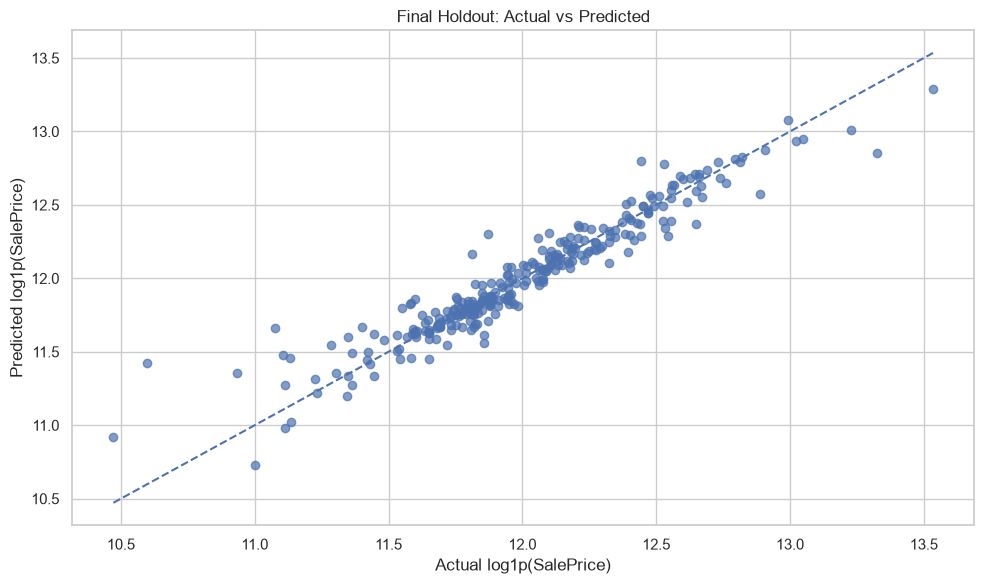

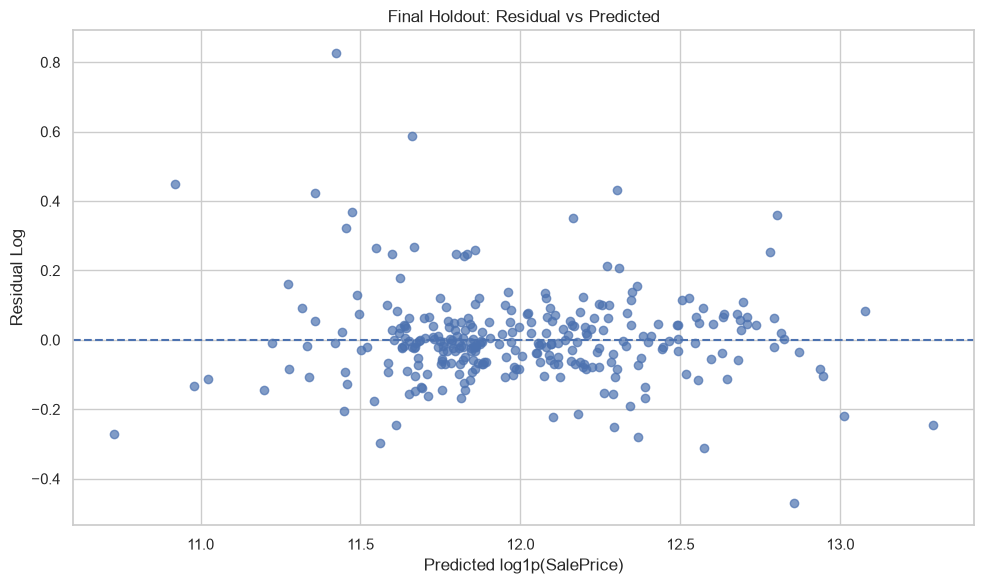

In [93]:
# Buat scatter plot antara nilai sebenarnya dan hasil prediksi
# pada log scale, sesuai dengan target yang digunakan saat training.
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    holdout_analysis["TrueLog"],
    holdout_analysis["PredLog"],
    alpha=0.7
)

# Tentukan batas sumbu agar garis diagonal mencakup seluruh titik.
lims = [
    min(
        holdout_analysis["TrueLog"].min(),
        holdout_analysis["PredLog"].min()
    ),
    max(
        holdout_analysis["TrueLog"].max(),
        holdout_analysis["PredLog"].max()
    ),
]

# Garis diagonal menunjukkan kondisi ideal:
# nilai prediksi sama dengan nilai sebenarnya.
ax.plot(
    lims,
    lims,
    linestyle="--"
)

ax.set_xlabel("Actual log1p(SalePrice)")
ax.set_ylabel("Predicted log1p(SalePrice)")
ax.set_title("Final Holdout: Actual vs Predicted")

plt.tight_layout()
plt.show()


# Buat scatter plot residual terhadap nilai prediksi.
# Grafik ini digunakan untuk melihat apakah error memiliki pola tertentu.
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    holdout_analysis["PredLog"],
    holdout_analysis["ResidualLog"],
    alpha=0.7
)

# Garis nol menunjukkan kondisi ketika residual = 0,
# yaitu prediksi tepat sama dengan nilai sebenarnya pada log scale.
ax.axhline(
    0,
    linestyle="--"
)

ax.set_xlabel("Predicted log1p(SalePrice)")
ax.set_ylabel("Residual Log")
ax.set_title("Final Holdout: Residual vs Predicted")

plt.tight_layout()
plt.show()

**Interpretasi Residual Diagnostics:**

Dari grafik dan ringkasan error, sebagian besar prediksi berada cukup dekat dengan nilai sebenarnya dan residual umumnya tersebar di sekitar garis nol. Namun, masih terdapat beberapa observasi dengan error yang cukup besar. Absolute error terbesar mencapai sekitar **$229K**, sementara **APE maksimum 128.59%**. Beberapa error besar juga terlihat pada rumah dengan harga sangat rendah maupun sangat tinggi.

Pada residual plot, tidak terlihat pola kuat seperti kurva atau funnel. Jadi, secara umum **tidak ada pola error yang sangat mencurigakan**, tetapi model masih kesulitan pada beberapa observasi tertentu.

**Kesimpulan:** model memiliki generalisasi yang cukup baik pada holdout, tetapi beberapa kasus ekstrem masih sulit diprediksi. Temuan ini dicatat sebagai **diagnosis akhir** dan tidak digunakan untuk tuning ulang karena holdout sudah menjadi final test.

## 12. Final Model Interpretation

Setelah performa final diketahui, saya ingin melihat **informasi apa yang paling banyak digunakan model** ketika memprediksi harga.

Champion pada Section 11 adalah **blend XGBoost + LightGBM**, sehingga feature importance di bagian ini dibaca dari **komponen XGBoost** saja.

Feature importance membantu menjelaskan bagaimana model menggunakan fitur, tetapi **bukan hubungan sebab-akibat**. Jadi, nilai importance tidak boleh dibaca sebagai besarnya kenaikan harga akibat satu fitur.

### 12.1 Feature Importance — Komponen XGBoost

Saya mulai dari feature importance XGBoost pada model champion yang sudah dilatih pada training set.

Karena fitur kategorikal berubah menjadi beberapa kolom one-hot, hasil awal dilihat pada level kolom hasil encoding.

In [94]:
# Ambil nama seluruh kolom setelah preprocessing.
encoded_feature_names = final_preprocessor.get_feature_names_out()

# Ambil Booster langsung dari model XGBoost.
# Cara ini lebih aman daripada bergantung pada feature_importances__
# pada object XGBRegressor di versi XGBoost tertentu.
booster = final_xgb.get_booster()

# Ambil importance berdasarkan gain.
# Fitur yang tidak digunakan oleh tree akan memiliki nilai 0.
gain_scores = booster.get_score(
    importance_type="gain"
)

# Saat input model berupa matriks hasil preprocessing,
# XGBoost biasanya memberi nama internal f0, f1, f2, dst.
importance_values = np.array([
    gain_scores.get(f"f{i}", 0.0)
    for i in range(len(encoded_feature_names))
])

# Ubah gain menjadi proporsi agar total importance = 1.
importance_sum = importance_values.sum()

assert importance_sum > 0, (
    "Feature importance XGBoost tidak ditemukan."
)

importance_values = (
    importance_values / importance_sum
)

# Pastikan setiap kolom hasil preprocessing memiliki
# satu nilai importance.
assert len(encoded_feature_names) == len(
    importance_values
)

xgb_importance = pd.DataFrame({
    "feature": encoded_feature_names,
    "importance": importance_values,
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print("=== TOP 20 XGBOOST FEATURE IMPORTANCE ===")
display(
    xgb_importance.head(20).round(5)
)

=== TOP 20 XGBOOST FEATURE IMPORTANCE ===


,feature,importance
0,num__QualxArea,0.09438
1,num__OverallQual,0.08153
2,num__GarageCars,0.07535
3,num__TotalSF,0.07396
4,cat__KitchenQual_TA,0.07018
5,num__TotalBath,0.05958
6,cat__GarageFinish_Unf,0.05273
7,cat__BsmtQual_Ex,0.03364
8,num__YearRemodAdd,0.02554
9,cat__MSZoning_RL,0.02449


### 12.2 Mengembalikan Importance ke Fitur Asli

One-hot encoding membuat satu fitur kategorikal menjadi beberapa kolom.

Contohnya, `Neighborhood` dapat berubah menjadi beberapa kolom seperti `Neighborhood_OldTown` dan `Neighborhood_NridgHt`.

Agar lebih mudah dibaca, saya jumlahkan kembali importance tersebut ke **nama fitur aslinya**.

In [95]:
def original_feature_from_encoded(name):
    """Kembalikan nama fitur asli dari kolom hasil one-hot."""
    name = str(name)

    if name.startswith("num__"):
        return name.replace("num__", "", 1)

    if name.startswith("cat__"):
        encoded_name = name.replace("cat__", "", 1)

        # Gunakan fitur yang memang dipakai model broad.
        features = final_features

        # Cocokkan prefix terpanjang agar nama fitur tidak tertukar.
        for feature in sorted(features, key=len, reverse=True):
            if (
                encoded_name == feature
                or encoded_name.startswith(feature + "_")
            ):
                return feature

        return encoded_name

    return name


# Hubungkan setiap kolom encoded dengan fitur aslinya.
xgb_importance["original_feature"] = (
    xgb_importance["feature"]
    .map(original_feature_from_encoded)
)

# Gabungkan importance dari beberapa kolom one-hot
# yang berasal dari fitur kategorikal yang sama.
xgb_importance_agg = (
    xgb_importance
    .groupby(
        "original_feature",
        as_index=False
    )["importance"]
    .sum()
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=== AGGREGATED IMPORTANCE BY ORIGINAL FEATURE ===")
display(
    xgb_importance_agg.head(20).round(5)
)

=== AGGREGATED IMPORTANCE BY ORIGINAL FEATURE ===


,original_feature,importance
0,QualxArea,0.09438
1,OverallQual,0.08153
2,KitchenQual,0.07975
3,GarageCars,0.07535
4,TotalSF,0.07396
5,TotalBath,0.05958
6,GarageFinish,0.05441
7,MSZoning,0.04892
8,CentralAir,0.04539
9,BsmtQual,0.03713


### Interpretasi — Final Model Interpretation

Pada komponen XGBoost, fitur dengan kontribusi gain terbesar pada model adalah **QualxArea, OverallQual, KitchenQual, GarageCars, TotalSF, dan TotalBath**.

Setelah importance one-hot dikembalikan ke fitur asli, terlihat bahwa model banyak menggunakan informasi tentang **kualitas, ukuran, dan karakteristik rumah**.

Beberapa fitur kategorikal juga cukup penting, sehingga informasi kategori tidak hanya menjadi pelengkap.

**Catatan:** Feature importance yang digunakan di sini adalah gain importance, sehingga nilainya menunjukkan kontribusi gain dari setiap fitur terhadap split pada model.

**Kesimpulan:** hasil ini digunakan untuk memahami perilaku model dan menjadi bahan monitoring, bukan untuk mengubah model setelah holdout.

## 13. Production Champion (Menyesuaikan Model dengan Kontrak API)

Model terbaik selama eksperimen belum tentu menjadi model yang paling tepat untuk digunakan di produk.

Pada Section 11, champion menggunakan broad feature set. Untuk production, saya membutuhkan model yang hanya memakai informasi yang benar-benar dapat diberikan oleh user.

Tujuan section ini adalah:

1. menetapkan kontrak input secara jelas;
2. mengukur biaya pengurangan fitur;
3. memastikan tidak ada kembar-fitur yang mencemari holdout;
4. memilih arsitektur model untuk kontrak tersebut;
5. mengevaluasi champion production;
6. melatih ulang dan mengekspor artifact final.

### 13.1 Menyiapkan Data Lengkap untuk Retraining

Sebelum masuk ke kontrak API, saya menyiapkan kembali seluruh data berlabel.

`full` harus berasal dari `train_raw`, bukan dari gabungan `train` dan holdout yang sudah dipurifikasi. Dengan cara ini, dua baris yang dikeluarkan dari holdout production tetap kembali ke data berlabel saat model final dilatih ulang.

Holdout tetap digunakan hanya untuk evaluasi model production sebelum retraining.

In [96]:
# Gunakan seluruh data berlabel asli untuk proses retraining final.
# Ini juga memastikan variabel `full` tersedia untuk pemeriksaan kembar-fitur.
full = train_raw.copy()

# Pastikan data lengkap tidak berubah jumlah baris maupun kolomnya.
assert len(full) == len(train_raw)
assert list(full.columns) == list(train_raw.columns)

print("=== FULL LABELED DATA ===")
print(f"Jumlah baris : {len(full):,}")
print(f"Jumlah kolom : {len(full.columns):,}")
print("Sumber       : train_raw")

=== FULL LABELED DATA ===
Jumlah baris : 1,460
Jumlah kolom : 81
Sumber       : train_raw


### 13.2 Menetapkan Kontrak API Secara Eksplisit

Kontrak API berisi **20 field yang diisi user**.

Tiga fitur tambahan dihitung oleh server:

- `TotalSF`
- `TotalBath`
- `QualxArea`

Jadi user mengisi 20 field, tetapi model menerima 23 kolom.

Kontrak ini ditetapkan sebelum evaluasi holdout production. Untuk `BsmtQual`, nilai `"None"` digunakan sebagai cara sederhana untuk mewakili kondisi tidak memiliki basement. Sebelum masuk preprocessing, nilai tersebut dikembalikan menjadi missing value agar konsisten dengan data training.

**Keputusan:** kontrak input production dikunci pada 20 field + 3 fitur turunan.

In [97]:
# Field numerik yang boleh dikirim user.
API_CONTRACT_NUM = [
    "OverallQual",
    "OverallCond",
    "GrLivArea",
    "TotalBsmtSF",
    "LotArea",
    "YearBuilt",
    "YearRemodAdd",
    "GarageCars",
    "FullBath",
    "HalfBath",
    "BsmtFullBath",
    "BsmtHalfBath",
    "Fireplaces",
]

# Field kategorikal yang boleh dikirim user.
API_CONTRACT_CAT = [
    "Neighborhood",
    "MSZoning",
    "ExterQual",
    "BsmtQual",
    "KitchenQual",
    "HeatingQC",
    "CentralAir",
]

API_CONTRACT = API_CONTRACT_NUM + API_CONTRACT_CAT

# Tipe numerik untuk kebutuhan kontrak API/Pydantic.
API_CONTRACT_INT = [
    "OverallQual",
    "OverallCond",
    "YearBuilt",
    "YearRemodAdd",
    "GarageCars",
    "FullBath",
    "HalfBath",
    "BsmtFullBath",
    "BsmtHalfBath",
    "Fireplaces",
]

API_CONTRACT_FLOAT = [
    "GrLivArea",
    "TotalBsmtSF",
    "LotArea",
]

API_FIELD_TYPES = {
    **{c: "int" for c in API_CONTRACT_INT},
    **{c: "float" for c in API_CONTRACT_FLOAT},
}

# Nilai kategorikal yang diizinkan berasal dari data training.
API_ALLOWED_VALUES = {
    c: sorted(
        full[c].dropna().astype(str).unique().tolist()
    )
    for c in API_CONTRACT_CAT
}

# "None" menjadi representasi API untuk rumah tanpa basement.
# Nilai ini akan dikembalikan menjadi NaN sebelum preprocessing.
if "None" not in API_ALLOWED_VALUES["BsmtQual"]:
    API_ALLOWED_VALUES["BsmtQual"].append("None")

API_ALLOWED_VALUES["BsmtQual"] = sorted(
    API_ALLOWED_VALUES["BsmtQual"]
)

API_ENGINEERED = [
    "TotalSF",
    "TotalBath",
    "QualxArea",
]

API_MODEL_COLUMNS = API_CONTRACT + API_ENGINEERED


def add_api_safe_fe(df):
    """Hitung fitur turunan hanya dari field yang ada di kontrak API."""
    d = df.copy()

    # Samakan representasi "None" dari API dengan missing value pada training.
    if "BsmtQual" in d.columns:
        d["BsmtQual"] = d["BsmtQual"].replace({"None": np.nan})

    # Semua komponen fitur turunan tersedia di kontrak API.
    d["TotalSF"] = (
        d["TotalBsmtSF"].fillna(0)
        + d["GrLivArea"].fillna(0)
    )

    d["TotalBath"] = (
        d["FullBath"].fillna(0)
        + 0.5 * d["HalfBath"].fillna(0)
        + d["BsmtFullBath"].fillna(0)
        + 0.5 * d["BsmtHalfBath"].fillna(0)
    )

    d["QualxArea"] = (
        d["OverallQual"].fillna(0)
        * d["GrLivArea"].fillna(0)
    )

    return d


# Checkpoint dasar untuk memastikan kontrak konsisten.
assert len(API_CONTRACT) == 20
assert len(API_CONTRACT_NUM) == 13
assert len(API_CONTRACT_CAT) == 7
assert len(API_CONTRACT) == len(set(API_CONTRACT))
assert not set(API_CONTRACT) & set(leakage_features)
assert all(c in full.columns for c in API_CONTRACT)
assert set(API_CONTRACT) == set(API_CONTRACT_NUM + API_CONTRACT_CAT)
assert set(API_CONTRACT_INT + API_CONTRACT_FLOAT) == set(API_CONTRACT_NUM)

print("=== KONTRAK API ===")
print(f"Field user        : {len(API_CONTRACT)}")
print(f"  - numerik       : {len(API_CONTRACT_NUM)}")
print(f"  - kategorikal   : {len(API_CONTRACT_CAT)}")
print(f"Fitur turunan     : {len(API_ENGINEERED)}")
print(f"Kolom masuk model : {len(API_MODEL_COLUMNS)}")
print("Leakage audit     : LOLOS")

=== KONTRAK API ===
Field user        : 20
  - numerik       : 13
  - kategorikal   : 7
Fitur turunan     : 3
Kolom masuk model : 23
Leakage audit     : LOLOS


### Interpretasi — Kontrak API

Kontrak production sekarang jelas:

- **20 field** diisi user;
- **3 fitur turunan** dihitung server;
- total **23 kolom** masuk ke model.

Nilai `"None"` pada `BsmtQual` hanya digunakan sebagai representasi pada API. Sebelum preprocessing, nilai tersebut diubah kembali menjadi missing value agar konsisten dengan data training.

**Keputusan:** kontrak input dikunci pada 20 field. Selanjutnya saya ukur performanya dengan beberapa skenario feature set.

### 13.3 Ablation — Mengukur Biaya Kontrak API

Saya membandingkan feature set secara bertahap dengan preprocessing dan hyperparameter yang sama.

Saya menambahkan **skenario 20 field tanpa feature engineering** agar pengaruh tiga field tambahan dapat dipisahkan dari pengaruh fitur turunan.

| Skenario | Isi | Tujuan |
|---|---|---|
| A | 79 fitur + Basic FE | referensi dari eksperimen broad |
| B | 17 field tanpa FE | kontrak 17 field |
| C | 17 field + FE | menguji FE pada kontrak 17 field |
| D | 20 field tanpa FE | mengukur tambahan 3 field |
| E | 20 field + FE | membandingkan dengan FE |

Semua skenario menggunakan **5-Fold CV**, preprocessing di dalam fold, dan target `log1p(SalePrice)`.

In [98]:
def cv_rmse_log_api(df, cols, params, n_splits=5):
    """Hitung mean dan std RMSE Log dengan preprocessing fit per fold."""
    y = df["SalePrice"].to_numpy()

    num = [
        c for c in cols
        if pd.api.types.is_numeric_dtype(df[c])
    ]
    cat = [
        c for c in cols
        if c not in num
    ]

    fold_scores = []

    kfold = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    for tr_idx, va_idx in kfold.split(df):
        # Preprocessor baru dibuat untuk setiap fold.
        pre = ColumnTransformer([
            ("num", SimpleImputer(strategy="median"), num),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True,
                )),
            ]), cat),
        ])

        # Fit hanya pada training fold.
        X_tr = pre.fit_transform(df.iloc[tr_idx][cols])
        X_va = pre.transform(df.iloc[va_idx][cols])

        # Gunakan parameter XGBoost yang sama untuk semua skenario.
        model = XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=1,
            tree_method="hist",
            verbosity=0,
            **params,
        )

        model.fit(
            X_tr,
            np.log1p(y[tr_idx]),
            verbose=False,
        )

        pred_log = model.predict(X_va)

        fold_scores.append(
            np.sqrt(
                mean_squared_error(
                    np.log1p(y[va_idx]),
                    pred_log,
                )
            )
        )

    return (
        float(np.mean(fold_scores)),
        float(np.std(fold_scores, ddof=0)),
    )


# Kontrak 17 field: keluarkan tiga field kamar mandi tambahan.
KONTRAK_17 = [
    c for c in API_CONTRACT
    if c not in ["HalfBath", "BsmtFullBath", "BsmtHalfBath"]
]

# Basic FE untuk broad feature set dan kontrak API.
train_broad_fe = add_domain_safe_fe(train, variant=1)
train_api_fe = add_api_safe_fe(train)

skenario = [
    (
        "A. 79 fitur + Basic FE",
        train_broad_fe,
        final_features,
        "~75",
    ),
    (
        "B. kontrak 17 field tanpa FE",
        train,
        KONTRAK_17,
        "17",
    ),
    (
        "C. kontrak 17 field + FE",
        train_api_fe,
        KONTRAK_17 + ["TotalSF", "QualxArea"],
        "17",
    ),
    (
        "D. kontrak 20 field tanpa FE",
        train,
        API_CONTRACT,
        "20",
    ),
    (
        "E. kontrak 20 field + FE",
        train_api_fe,
        API_MODEL_COLUMNS,
        "20",
    ),
]

hasil_ablation = []

for nama, df_pakai, cols, n_field in skenario:
    mean_rmse, std_rmse = cv_rmse_log_api(
        df_pakai,
        cols,
        candidate_params,
    )

    hasil_ablation.append({
        "skenario": nama,
        "field_dari_user": n_field,
        "kolom_model": len(cols),
        "RMSE_log": mean_rmse,
        "std": std_rmse,
    })

ablation_df = (
    pd.DataFrame(hasil_ablation)
    .sort_values("RMSE_log")
    .reset_index(drop=True)
)

# Gunakan skenario A sebagai referensi performa broad feature set.
ref_rmse = float(
    ablation_df.loc[
        ablation_df["skenario"].str.startswith("A."),
        "RMSE_log",
    ].iloc[0]
)

ablation_df["selisih_vs_A"] = (
    ablation_df["RMSE_log"] - ref_rmse
)

ablation_df["relatif_vs_A_%"] = (
    (ablation_df["RMSE_log"] / ref_rmse) - 1
) * 100

display(
    ablation_df.round({
        "RMSE_log": 5,
        "std": 5,
        "selisih_vs_A": 5,
        "relatif_vs_A_%": 2,
    })
)

# Ambil nilai untuk membaca pengaruh tiap perubahan secara terpisah.
def ambil_rmse(prefix):
    return float(
        ablation_df.loc[
            ablation_df["skenario"].str.startswith(prefix),
            "RMSE_log",
        ].iloc[0]
    )

rmse_17_no_fe = ambil_rmse("B.")
rmse_17_fe = ambil_rmse("C.")
rmse_20_no_fe = ambil_rmse("D.")
rmse_20_fe = ambil_rmse("E.")

print(
    f"Perubahan 17 -> 20 field tanpa FE : "
    f"{rmse_20_no_fe - rmse_17_no_fe:+.5f}"
)
print(
    f"Pengaruh FE pada 17 field         : "
    f"{rmse_17_fe - rmse_17_no_fe:+.5f}"
)
print(
    f"Pengaruh FE pada 20 field         : "
    f"{rmse_20_fe - rmse_20_no_fe:+.5f}"
)

,skenario,field_dari_user,kolom_model,RMSE_log,std,selisih_vs_A,relatif_vs_A_%
0,A. 79 fitur + Basic FE,~75,79,0.11831,0.01299,0.00000,0.00
1,D. kontrak 20 field tanpa FE,20,20,0.12534,0.01687,0.00702,5.94
2,E. kontrak 20 field + FE,20,23,0.12581,0.01548,0.00750,6.34
3,B. kontrak 17 field tanpa FE,17,17,0.12936,0.01590,0.01105,9.34
4,C. kontrak 17 field + FE,17,19,0.13062,0.01587,0.01231,10.40


Perubahan 17 -> 20 field tanpa FE : -0.00402
Pengaruh FE pada 17 field         : +0.00126
Pengaruh FE pada 20 field         : +0.00048


### Interpretasi — Ablation Feature Set

Hasil CV menunjukkan:

- 17 field tanpa FE = **0.12936**
- 20 field tanpa FE = **0.12534**
- 20 field + Basic FE = **0.12581**

Perbandingan ini memisahkan pengaruh penambahan field dari pengaruh fitur turunan.

**B → D:** penambahan tiga field kamar mandi menurunkan RMSE Log sekitar **0.00402**.

**D → E:** Basic FE justru menaikkan RMSE Log sekitar **0.00048** pada eksperimen ini.

**Artinya:** tambahan tiga field memberikan improvement yang jelas, sedangkan Basic FE belum memberikan improvement tambahan pada parameter yang digunakan.

Basic FE tetap dipertahankan pada kontrak production karena sudah menjadi bagian dari **kontrak input dan jalur inference yang ditetapkan**. Jadi, fitur turunan ini tidak diklaim sebagai sumber improvement pada hasil CV.

**Keputusan:** production tetap menggunakan **20 field + 3 fitur turunan**, tetapi hasil ablation ini dicatat sebagai trade-off yang perlu dipahami.

### 13.4 Cek Kembar-Fitur pada Kontrak API

Setelah feature set dipersempit, saya perlu memeriksa apakah ada dua baris yang terlihat sama bagi model.

Masalah ini penting karena sebuah rumah di holdout bisa mempunyai **20 field yang sama persis** dengan rumah di train, tetapi harga berbeda. Jika dibiarkan, evaluasi holdout dapat terlihat terlalu bagus.

Pemeriksaan ini dilakukan berdasarkan kontrak API, bukan seluruh 79 fitur.

In [99]:
# Cari baris yang memiliki 20 field kontrak yang sama.
kembar_mask = full.duplicated(
    subset=API_CONTRACT,
    keep=False,
)

kembar = full[kembar_mask]

print(
    f"=== KEMBAR-FITUR PADA KONTRAK {len(API_CONTRACT)} FIELD ==="
)
print(
    f"baris yang punya kembaran : "
    f"{int(kembar_mask.sum())} dari {len(full)}"
)
print(
    f"jumlah kelompok kembar    : "
    f"{kembar.groupby(API_CONTRACT, dropna=False).ngroups}"
)

rentang = []

for _, grup in kembar.groupby(
    API_CONTRACT,
    dropna=False,
):
    harga = grup["SalePrice"].to_numpy()

    # Ukur perbedaan harga dalam satu kelompok kembar.
    beda = (harga.max() / harga.min() - 1) * 100
    rentang.append(beda)

    print(
        f"  Id {list(grup['Id'])} "
        f"harga {[f'{x:,}' for x in harga]} "
        f"rentang {beda:.1f}%"
    )

if rentang:
    print(
        f"rata-rata rentang harga antar kembar : "
        f"{np.mean(rentang):.1f}%"
    )


def sidik_jari(df):
    """Buat identitas baris berdasarkan field yang dilihat model."""
    return (
        df[API_CONTRACT]
        .astype(str)
        .agg("|".join, axis=1)
    )


# Bandingkan sidik jari holdout dengan seluruh sidik jari train.
sig_train = set(sidik_jari(train))
tercemar = sidik_jari(holdout).isin(sig_train)

print()
print("=== PEMERIKSAAN KEBOCORAN ANTAR SPLIT ===")
print(
    f"baris holdout yang sidik jarinya sudah ada di train : "
    f"{int(tercemar.sum())}"
)

for _, baris in holdout[tercemar].iterrows():
    sidik = sidik_jari(
        holdout.loc[[baris.name]]
    ).iloc[0]

    sama = train[
        sidik_jari(train) == sidik
    ]

    print(
        f"  holdout Id {int(baris['Id'])} "
        f"(${int(baris['SalePrice']):,}) "
        f"<-> train Id {list(sama['Id'])} "
        f"({[f'${int(x):,}' for x in sama['SalePrice']]})"
    )

# Purifikasi hanya dilakukan pada holdout production.
# Data train tidak diubah.
holdout_api = holdout[~tercemar].copy()

print()
print(
    f"holdout sebelum purifikasi : {len(holdout)} baris"
)
print(
    f"holdout setelah purifikasi : {len(holdout_api)} baris "
    f"({int(tercemar.sum())} dibuang)"
)
print(
    f"train                      : {len(train)} baris "
    f"(tidak berubah)"
)

# Pastikan tidak ada lagi sidik jari holdout yang muncul di train.
assert (
    sidik_jari(holdout_api)
    .isin(sig_train)
    .sum()
    == 0
)

print("✓ Checkpoint: holdout production bersih dari kembar-fitur.")

=== KEMBAR-FITUR PADA KONTRAK 20 FIELD ===
baris yang punya kembaran : 13 dari 1460
jumlah kelompok kembar    : 6
  Id [103, 895] harga ['118,964', '118,858'] rentang 0.1%
  Id [691, 1442] harga ['141,000', '149,300'] rentang 5.9%
  Id [594, 851, 1423] harga ['140,000', '131,500', '136,500'] rentang 6.5%
  Id [204, 812] harga ['149,000', '144,500'] rentang 3.1%
  Id [1005, 1024] harga ['181,000', '191,000'] rentang 5.5%
  Id [194, 1089] harga ['130,000', '137,500'] rentang 5.8%
rata-rata rentang harga antar kembar : 4.5%

=== PEMERIKSAAN KEBOCORAN ANTAR SPLIT ===
baris holdout yang sidik jarinya sudah ada di train : 2
  holdout Id 895 ($118,858) <-> train Id [103] (['$118,964'])
  holdout Id 1089 ($137,500) <-> train Id [194] (['$130,000'])

holdout sebelum purifikasi : 292 baris
holdout setelah purifikasi : 290 baris (2 dibuang)
train                      : 1168 baris (tidak berubah)
✓ Checkpoint: holdout production bersih dari kembar-fitur.


**Interpretasi Kembar-Fitur**

Pemeriksaan ini menemukan **13 baris dalam 6 kelompok kembar** pada kontrak 20 field.

Rata-rata perbedaan harga dalam kelompok kembar sekitar **4,5%**. Artinya, dua rumah yang terlihat sama dari sudut pandang model masih dapat memiliki harga berbeda.

Selain itu, terdapat **2 baris holdout** yang mempunyai sidik jari kontrak yang sudah muncul di train. Dua baris tersebut dikeluarkan dari holdout production sehingga evaluasi tidak terlalu optimistis.

**Keputusan:** holdout production menggunakan **290 baris**, sedangkan train tetap **1168 baris**. Dua baris yang dikeluarkan dari holdout tetap kembali saat retraining final menggunakan seluruh 1460 data berlabel.

Catatan: purifikasi ini dilakukan setelah evaluasi holdout Section 11, sehingga keterbatasannya tetap dicatat pada bagian limitations.

### 13.5 XGBoost Tunggal atau Blend?

Pada broad feature set, blend XGBoost + LightGBM sempat memberikan hasil yang menarik.

Namun, keputusan production perlu diuji ulang pada **20 field yang sama**. Saya menggunakan OOF predictions dengan fold yang identik untuk membandingkan XGBoost tunggal dan beberapa bobot blend.

Primary metric tetap **mean RMSE per fold**.

**Aturan Keputusan Blend:**

Untuk eksperimen production ini, saya menggunakan batas improvement minimal 1% untuk menentukan apakah tambahan kompleksitas blend layak dipertahankan. Jika improvement blend < 1%, saya memilih XGBoost tunggal karena hasilnya lebih sederhana dengan performa yang masih sebanding.

Dengan aturan improvement minimal 1% yang digunakan pada eksperimen ini, blend belum memberikan peningkatan yang cukup untuk membenarkan tambahan kompleksitas model.

In [100]:
# Data training khusus kontrak API.
train_api = add_api_safe_fe(train)

# Gunakan fold yang sama untuk semua bobot blend.
api_folds = list(
    KFold(
        5,
        shuffle=True,
        random_state=RANDOM_STATE,
    ).split(train_api)
)

oof_xgb = np.zeros(len(train_api))
oof_lgbm = np.zeros(len(train_api))


def buat_preprocessor(df):
    """Buat preprocessor kontrak API tanpa melakukan fit."""
    num = [
        c for c in API_MODEL_COLUMNS
        if pd.api.types.is_numeric_dtype(df[c])
    ]
    cat = [
        c for c in API_MODEL_COLUMNS
        if c not in num
    ]

    return ColumnTransformer([
        (
            "num",
            SimpleImputer(strategy="median"),
            num,
        ),
        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent"),
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=True,
                    ),
                ),
            ]),
            cat,
        ),
    ])


for tr_idx, va_idx in api_folds:
    # Preprocessor dibuat ulang pada setiap fold
    # agar validation tidak ikut memengaruhi proses fit.
    pre = buat_preprocessor(train_api)

    X_tr = pre.fit_transform(
        train_api.iloc[tr_idx][API_MODEL_COLUMNS]
    )
    X_va = pre.transform(
        train_api.iloc[va_idx][API_MODEL_COLUMNS]
    )

    # XGBoost menggunakan parameter hasil tuning.
    xgb_model = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=1,
        tree_method="hist",
        verbosity=0,
        **candidate_params,
    )

    xgb_model.fit(
        X_tr,
        np.log1p(
            train_api.iloc[tr_idx]["SalePrice"]
        ),
        verbose=False,
    )

    oof_xgb[va_idx] = xgb_model.predict(X_va)

    # LightGBM digunakan hanya sebagai challenger.
    lgbm_model = LGBMRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=-1,
        **lgb_params,
    )

    lgbm_model.fit(
        X_tr,
        np.log1p(
            train_api.iloc[tr_idx]["SalePrice"]
        ),
    )

    oof_lgbm[va_idx] = lgbm_model.predict(X_va)


y_api_log = np.log1p(
    train_api["SalePrice"].to_numpy()
)

blend_rows = []

for weight_xgb in np.arange(0.0, 1.01, 0.1):
    # Gabungkan prediksi dalam log-space.
    blend_log = (
        weight_xgb * oof_xgb
        + (1 - weight_xgb) * oof_lgbm
    )

    # Hitung RMSE pada setiap fold agar konsisten
    # dengan evaluasi CV utama.
    fold_scores = []

    for _, va_idx in api_folds:
        fold_scores.append(
            np.sqrt(
                mean_squared_error(
                    y_api_log[va_idx],
                    blend_log[va_idx],
                )
            )
        )

    blend_rows.append({
        "xgb_weight": weight_xgb,
        "lgbm_weight": 1 - weight_xgb,
        "RMSE_log_mean": np.mean(fold_scores),
        "RMSE_log_std": np.std(
            fold_scores,
            ddof=0,
        ),
    })

blend_api = (
    pd.DataFrame(blend_rows)
    .sort_values("RMSE_log_mean")
    .reset_index(drop=True)
)

display(
    blend_api.round(5)
)

# Ambil hasil XGBoost tunggal sebagai pembanding.
xgb_single_result = blend_api[
    np.isclose(
        blend_api["xgb_weight"],
        1.0,
    )
].iloc[0]

# Ambil blend dengan score terbaik.
best_blend_result = blend_api.iloc[0]

xgb_single_rmse = float(
    xgb_single_result["RMSE_log_mean"]
)

best_blend_rmse = float(
    best_blend_result["RMSE_log_mean"]
)

# Hitung improvement blend terhadap XGBoost tunggal.
blend_improvement_pct = (
    (xgb_single_rmse - best_blend_rmse)
    / xgb_single_rmse
    * 100
)

# Pilih blend hanya jika improvement memenuhi aturan
# yang sudah ditetapkan di markdown.
if blend_improvement_pct >= 1.0:
    API_XGB_WEIGHT = float(
        best_blend_result["xgb_weight"]
    )
    API_LGBM_WEIGHT = float(
        best_blend_result["lgbm_weight"]
    )
    production_architecture = "XGBoost + LightGBM blend"
else:
    API_XGB_WEIGHT = 1.0
    API_LGBM_WEIGHT = 0.0
    production_architecture = "XGBoost tunggal"

print("=== PERBANDINGAN ARSITEKTUR PRODUCTION ===")
print(
    f"XGBoost tunggal : {xgb_single_rmse:.5f}"
)
print(
    f"Blend terbaik   : {best_blend_rmse:.5f} "
    f"({best_blend_result['xgb_weight']:.0%} XGB / "
    f"{best_blend_result['lgbm_weight']:.0%} LGBM)"
)
print(
    f"Improvement     : {blend_improvement_pct:.2f}%"
)
print(
    f"Keputusan       : {production_architecture}"
)

,xgb_weight,lgbm_weight,RMSE_log_mean,RMSE_log_std
0,0.8,0.2,0.12522,0.01523
1,0.7,0.3,0.12523,0.01507
2,0.9,0.1,0.12542,0.01536
3,0.6,0.4,0.12544,0.01489
4,1.0,0.0,0.12581,0.01548
5,0.5,0.5,0.12585,0.01470
6,0.4,0.6,0.12647,0.01449
7,0.3,0.7,0.12727,0.01427
8,0.2,0.8,0.12827,0.01404
9,0.1,0.9,0.12946,0.01381


=== PERBANDINGAN ARSITEKTUR PRODUCTION ===
XGBoost tunggal : 0.12581
Blend terbaik   : 0.12522 (80% XGB / 20% LGBM)
Improvement     : 0.47%
Keputusan       : XGBoost tunggal


### Interpretasi — Arsitektur Model Production

Pada kontrak 20 field, hasil terbaru menunjukkan:

- **XGBoost tunggal = 0.12581**
- **Blend terbaik 80% XGBoost + 20% LightGBM = 0.12522**

Blend memang lebih baik, tetapi improvement-nya hanya sekitar **0,47%**. Karena aturan keputusan menetapkan bahwa improvement harus minimal **1%**, XGBoost tunggal tetap dipilih.

Ini berbeda dengan broad feature set, di mana blend lebih menarik.

**Artinya:** tambahan kompleksitas blend belum cukup memberikan keuntungan untuk kontrak API.

**Keputusan:** production menggunakan **XGBoost tunggal**. LightGBM tetap menjadi challenger dan tidak masuk ke jalur inference production.

### 13.6 Quality Gate untuk Champion Production

Sebelum holdout production dibuka, saya menjalankan quality gate.

Gate memeriksa:

- RMSE Log memenuhi ambang;
- performa tidak lebih buruk dari kontrak 17 field;
- semua field model tersedia di kontrak API;
- tidak ada leakage;
- holdout bersih dari kembar-fitur;
- arsitektur production sesuai hasil eksperimen;
- hyperparameter kandidat tersedia.

Dengan begitu, gate tidak hanya memeriksa angka, tetapi juga memastikan model memang cocok dengan kontrak produk.

In [101]:
# Ambang mutu yang digunakan untuk production.
GATE_API_MAX_RMSE_LOG = 0.15

# Hitung kembali CV dengan evaluator utama yang sama.
api_cv_mean, api_cv_std = cv_rmse_log_api(
    train_api,
    API_MODEL_COLUMNS,
    candidate_params,
)

# Ambil baseline kontrak 17 field tanpa FE dari ablation.
api_17_baseline_rmse = float(
    ablation_df.loc[
        ablation_df["skenario"].str.startswith("B."),
        "RMSE_log",
    ].iloc[0]
)

# Field yang dibutuhkan model = kolom model dikurangi fitur turunan.
field_dibutuhkan = [
    c for c in API_MODEL_COLUMNS
    if c not in API_ENGINEERED
]

gate_api_checks = [
    (
        "RMSE_log <= ambang mutu",
        api_cv_mean <= GATE_API_MAX_RMSE_LOG,
        f"{api_cv_mean:.5f} vs {GATE_API_MAX_RMSE_LOG}",
    ),
    (
        "Tidak lebih buruk dari kontrak 17 field",
        api_cv_mean <= api_17_baseline_rmse,
        f"{api_cv_mean:.5f} vs {api_17_baseline_rmse:.5f}",
    ),
    (
        "Semua field model ada di kontrak API",
        set(field_dibutuhkan).issubset(set(API_CONTRACT)),
        f"{len(field_dibutuhkan)} field dicek",
    ),
    (
        "Tidak ada kolom leakage",
        not (
            set(API_MODEL_COLUMNS)
            & set(leakage_features)
        ),
        f"dicek: {leakage_features}",
    ),
    (
        "Holdout bersih dari kembar-fitur",
        sidik_jari(holdout_api)
        .isin(sig_train)
        .sum() == 0,
        f"{len(holdout_api)} baris",
    ),
    (
        "XGBoost tunggal dipilih",
        np.isclose(API_XGB_WEIGHT, 1.0),
        f"XGB {API_XGB_WEIGHT:.0%}",
    ),
    (
        "Hyperparameter tersedia",
        isinstance(candidate_params, dict)
        and len(candidate_params) > 0,
        f"{len(candidate_params)} parameter",
    ),
]

gate_api_df = pd.DataFrame([
    {
        "pemeriksaan": name,
        "lolos": ok,
        "bukti": evidence,
    }
    for name, ok, evidence in gate_api_checks
])

display(gate_api_df)

gagal_api = [
    name
    for name, ok, _ in gate_api_checks
    if not ok
]

if gagal_api:
    raise SystemExit(
        f"QUALITY GATE GAGAL: {gagal_api}. "
        "Holdout production tidak boleh dibuka."
    )

print("=== QUALITY GATE — PRODUCTION CHAMPION ===")
print(
    f"CV RMSE Log : {api_cv_mean:.5f} "
    f"(std {api_cv_std:.5f})"
)
print(f"Field user  : {len(API_CONTRACT)}")
print(f"Kolom model : {len(API_MODEL_COLUMNS)}")
print("STATUS      : LOLOS — holdout production boleh dibuka.")

,pemeriksaan,lolos,bukti
0,RMSE_log <= ambang mutu,True,0.12581 vs 0.15
1,Tidak lebih buruk dari kontrak 17 field,True,0.12581 vs 0.12936
2,Semua field model ada di kontrak API,True,20 field dicek
3,Tidak ada kolom leakage,True,"dicek: ['MoSold', 'YrSold', 'SaleType', 'SaleC..."
4,Holdout bersih dari kembar-fitur,True,290 baris
5,XGBoost tunggal dipilih,True,XGB 100%
6,Hyperparameter tersedia,True,9 parameter


=== QUALITY GATE — PRODUCTION CHAMPION ===
CV RMSE Log : 0.12581 (std 0.01548)
Field user  : 20
Kolom model : 23
STATUS      : LOLOS — holdout production boleh dibuka.


### Interpretasi — Quality Gate Production

Quality gate production memeriksa tujuh hal:

1. **RMSE Log ≤ 0.15** → lolos dengan **0.12581**.
2. **Tidak lebih buruk dari kontrak 17 field** → 0.12581 lebih baik dari **0.12936**.
3. **Semua field model tersedia di kontrak API** → lolos.
4. **Tidak ada leakage** → lolos.
5. **Holdout bersih dari kembar-fitur** → 290 baris.
6. **Arsitektur sesuai aturan keputusan** → XGBoost tunggal.
7. **Hyperparameter tersedia** → 9 parameter.

**Keputusan:** production champion lolos quality gate dan holdout production boleh digunakan untuk evaluasi final.

### 13.7 Final Holdout Evaluation — Production Champion

Sekarang saya mengukur performa XGBoost production pada **holdout yang sudah dibersihkan menjadi 290 baris**.

Preprocessor di-fit hanya pada training set, lalu digunakan untuk transform holdout.

Setelah hasil ini keluar, tidak ada tuning atau pemilihan model lagi.

In [102]:
# Pastikan semua keputusan production sudah tersedia.
assert np.isclose(API_XGB_WEIGHT, 1.0)
assert len(holdout_api) < len(holdout)

# Tambahkan fitur turunan menggunakan fungsi yang hanya memakai
# field dari kontrak API.
holdout_api_fe = add_api_safe_fe(holdout_api)

# Buat preprocessor baru untuk final holdout evaluation.
api_preprocessor = buat_preprocessor(train_api)

# Fit hanya pada training set.
X_api_train = api_preprocessor.fit_transform(
    train_api[API_MODEL_COLUMNS]
)

# Transform holdout menggunakan preprocessor yang sama.
X_api_holdout = api_preprocessor.transform(
    holdout_api_fe[API_MODEL_COLUMNS]
)

# Buat XGBoost final untuk evaluasi holdout.
api_champion = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=1,
    tree_method="hist",
    verbosity=0,
    **candidate_params,
)

# Latih hanya menggunakan training set.
api_champion.fit(
    X_api_train,
    np.log1p(train_api["SalePrice"]),
    verbose=False,
)

# Target holdout digunakan hanya untuk evaluasi.
y_holdout_api = holdout_api_fe["SalePrice"].to_numpy()

# Prediksi dalam log-space.
pred_holdout_log = api_champion.predict(
    X_api_holdout
)

# Kembalikan prediksi ke skala harga asli.
pred_holdout_usd = np.maximum(
    np.expm1(pred_holdout_log),
    0,
)

# Hitung metric final pada holdout.
api_holdout_rmse_log = float(
    np.sqrt(
        mean_squared_error(
            np.log1p(y_holdout_api),
            pred_holdout_log,
        )
    )
)

api_holdout_mae_usd = float(
    mean_absolute_error(
        y_holdout_api,
        pred_holdout_usd,
    )
)

api_holdout_r2 = float(
    r2_score(
        y_holdout_api,
        pred_holdout_usd,
    )
)

api_holdout_gap = (
    api_holdout_rmse_log - api_cv_mean
)

api_holdout_gap_pct = (
    api_holdout_gap / api_cv_mean * 100
)

print("=== HOLDOUT — PRODUCTION CHAMPION ===")
print(f"n holdout     : {len(y_holdout_api)}")
print(f"kolom encoded : {X_api_train.shape[1]}")
print(f"RMSE Log      : {api_holdout_rmse_log:.5f}")
print(f"MAE USD       : ${api_holdout_mae_usd:,.2f}")
print(f"R²            : {api_holdout_r2:.5f}")
print()
print(
    f"gap vs CV     : "
    f"{api_holdout_gap:+.5f} "
    f"({api_holdout_gap_pct:+.1f}%)"
)

=== HOLDOUT — PRODUCTION CHAMPION ===
n holdout     : 290
kolom encoded : 65
RMSE Log      : 0.13139
MAE USD       : $15,439.67
R²            : 0.92599

gap vs CV     : +0.00558 (+4.4%)


### Interpretasi — Final Holdout Production

Hasil final production pada holdout:

- **RMSE Log = 0.13139**
- **MAE = $15,439.67**
- **R² = 0.92599**
- **290 baris holdout**

Dibandingkan CV:

- CV RMSE Log = **0.12581**
- Holdout RMSE Log = **0.13139**
- gap = **+0.00558** atau sekitar **+4.4%**

Holdout lebih tinggi dari CV, tetapi masih berada di bawah quality threshold **0.15**.

**Kesimpulan:** model menunjukkan generalisasi yang cukup baik pada holdout production. Angka holdout ini menjadi hasil evaluasi akhir dan tidak digunakan lagi untuk mengubah model.

#### 13.7.1 Residual Diagnostics — Production Holdout

Setelah metric final diketahui, saya melihat distribusi residual untuk memahami perilaku error model.

Residual didefinisikan sebagai:

`actual - predicted`

Jadi:

- residual positif → model memprediksi terlalu rendah;
- residual negatif → model memprediksi terlalu tinggi.

Analisis ini hanya untuk diagnosis dan tidak digunakan untuk mengubah model.

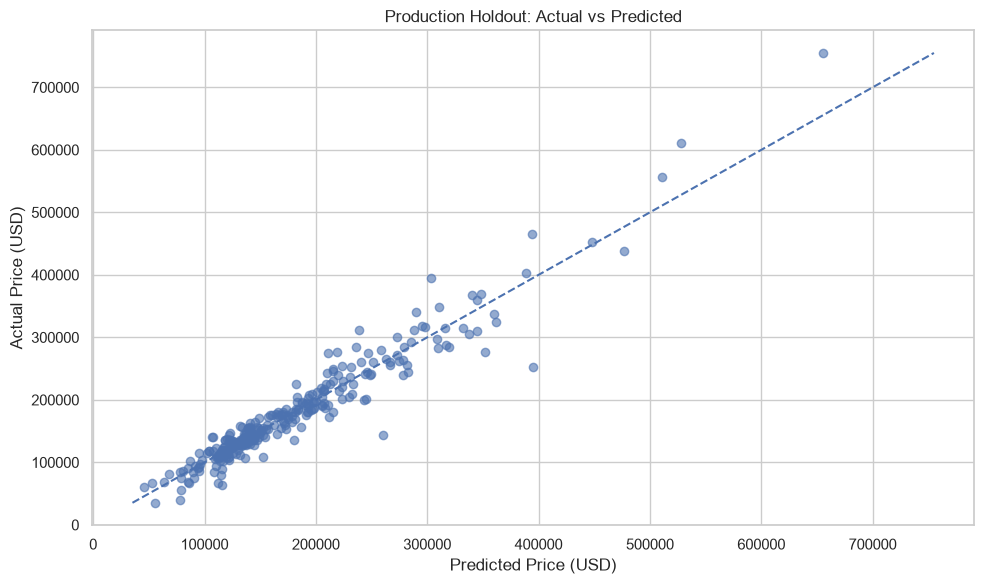

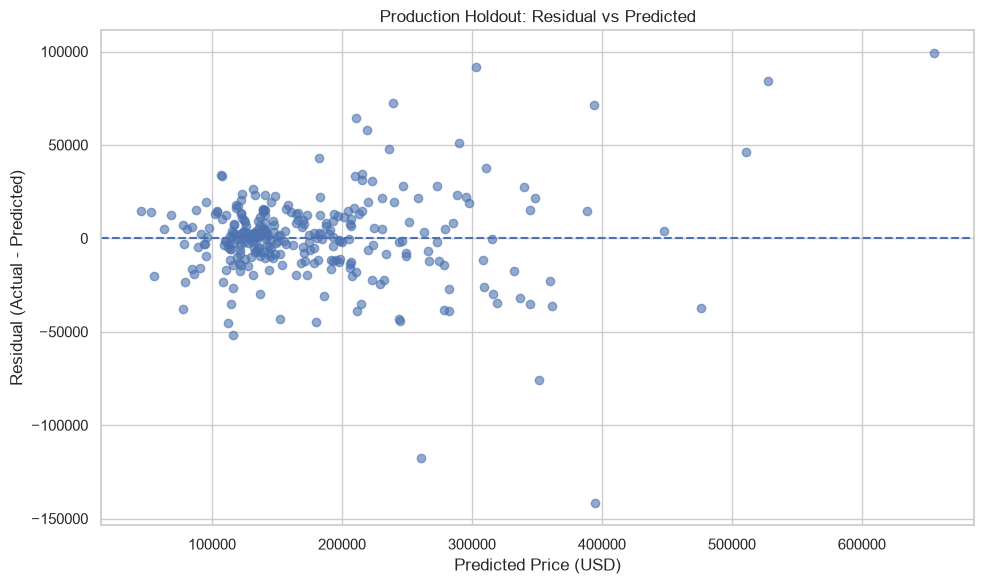

=== RESIDUAL DISTRIBUTION ===
count       290.0
mean        404.0
std       23918.0
min     -141550.0
25%       -9766.0
50%         800.0
75%       11478.0
max       99229.0

prediksi meleset < 10% : 70.3%
prediksi meleset < 20% : 90.3%


In [103]:
# Hitung residual dalam satuan harga asli.
residual_usd = (
    y_holdout_api
    - pred_holdout_usd
)

# Grafik 1: prediksi vs harga sebenarnya.
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    pred_holdout_usd,
    y_holdout_api,
    alpha=0.6,
)

# Garis diagonal menunjukkan prediksi ideal.
lims = [
    min(
        pred_holdout_usd.min(),
        y_holdout_api.min(),
    ),
    max(
        pred_holdout_usd.max(),
        y_holdout_api.max(),
    ),
]

ax.plot(
    lims,
    lims,
    linestyle="--",
)

ax.set_xlabel("Predicted Price (USD)")
ax.set_ylabel("Actual Price (USD)")
ax.set_title("Production Holdout: Actual vs Predicted")

plt.tight_layout()
plt.show()


# Grafik 2: residual terhadap prediksi.
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    pred_holdout_usd,
    residual_usd,
    alpha=0.6,
)

# Garis nol menunjukkan tidak ada error.
ax.axhline(
    0,
    linestyle="--",
)

ax.set_xlabel("Predicted Price (USD)")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title("Production Holdout: Residual vs Predicted")

plt.tight_layout()
plt.show()


# Ringkas distribusi residual.
print("=== RESIDUAL DISTRIBUTION ===")
print(
    pd.Series(residual_usd)
    .describe()
    .round(0)
    .to_string()
)

# Hitung persentase prediksi yang error-nya di bawah 10% dan 20%.
relative_error = (
    np.abs(residual_usd)
    / y_holdout_api
)

print()
print(
    f"prediksi meleset < 10% : "
    f"{(relative_error < 0.10).mean():.1%}"
)
print(
    f"prediksi meleset < 20% : "
    f"{(relative_error < 0.20).mean():.1%}"
)

### Interpretasi — Residual Diagnostics Production

Dari hasil holdout:

- **70,3%** prediksi meleset kurang dari **10%**
- **90,3%** meleset kurang dari **20%**
- Pada observasi median, residual sebesar +$800 menunjukkan model sedikit cenderung underpredict.
- residual ekstrem masih muncul pada beberapa rumah.

Dari grafik, residual umumnya tersebar di sekitar garis nol dan tidak menunjukkan pola kuat seperti kurva atau funnel.

**Kesimpulan:** model cukup baik secara umum, tetapi masih ada beberapa kasus sulit dengan error besar. Temuan ini menjadi bahan monitoring dan pengembangan berikutnya, bukan alasan untuk tuning ulang.

### 13.8 Retraining Final & Export Artifact

Setelah holdout production selesai dan keputusan model dikunci, saya melatih ulang model menggunakan **seluruh 1460 data berlabel**.

Holdout tidak digunakan untuk memilih model. Nilai holdout hanya disimpan sebagai bukti performa model sebelum retraining.

Artifact production akan berisi:

- preprocessor;
- model XGBoost;
- kontrak API;
- daftar fitur;
- target transformation;
- hyperparameter;
- metric CV dan holdout;
- allowed categorical values;
- contract hash.

In [104]:
# Library yang digunakan untuk membuat hash, mencatat waktu,
# dan menyimpan artifact model.
import hashlib
import json
import joblib
from datetime import datetime

# Pastikan seluruh data berlabel dan parameter model tersedia.
assert "full" in globals(), (
    "full belum tersedia. Jalankan Section 13.1 terlebih dahulu."
)

assert "candidate_params" in globals(), (
    "candidate_params belum tersedia. Jalankan Section 8 terlebih dahulu."
)

# Gunakan seluruh 1460 data berlabel untuk retraining final.
full_api_fe = add_api_safe_fe(full)

# Buat preprocessor production tanpa melakukan fit sebelumnya.
production_preprocessor = buat_preprocessor(
    full_api_fe
)

# Fit preprocessor pada seluruh data berlabel.
X_production = production_preprocessor.fit_transform(
    full_api_fe[API_MODEL_COLUMNS]
)

# Latih satu-satunya model production menggunakan
# parameter yang sudah dipilih sebelumnya.
production_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=1,
    tree_method="hist",
    verbosity=0,
    importance_type="gain",
    **candidate_params,
)

# Target tetap menggunakan log1p agar konsisten
# dengan seluruh proses training dan evaluasi.
production_model.fit(
    X_production,
    np.log1p(full_api_fe["SalePrice"]),
    verbose=False,
)

PRODUCTION_MODEL_NAME = (
    "house_price_xgb_api_contract_v1"
)

# Simpan definisi kontrak yang benar-benar digunakan artifact.
contract_definition = {
    "fields": API_CONTRACT,
    "numeric_fields": API_CONTRACT_NUM,
    "categorical_fields": API_CONTRACT_CAT,
    "field_types": API_FIELD_TYPES,
    "allowed_values": API_ALLOWED_VALUES,
    "engineered_features": API_ENGINEERED,
    "model_columns": API_MODEL_COLUMNS,
}

# Buat hash dari kontrak agar perubahan kontrak
# dapat dideteksi saat artifact digunakan kembali.
contract_hash = hashlib.sha256(
    json.dumps(
        contract_definition,
        ensure_ascii=False,
        sort_keys=True,
    ).encode("utf-8")
).hexdigest()

# Simpan seluruh komponen yang dibutuhkan saat inference.
production_bundle = {
    "model_name": PRODUCTION_MODEL_NAME,
    "model_version": "v1",
    "model_type": "XGBRegressor",
    "preprocessor": production_preprocessor,
    "model": production_model,

    # Kontrak API.
    "api_contract_fields": API_CONTRACT,
    "api_contract_numeric": API_CONTRACT_NUM,
    "api_contract_categorical": API_CONTRACT_CAT,
    "api_contract_types": API_FIELD_TYPES,
    "api_allowed_values": API_ALLOWED_VALUES,
    "engineered_features": API_ENGINEERED,
    "model_columns": API_MODEL_COLUMNS,
    "contract_hash": contract_hash,

    # Target.
    "target": "SalePrice",
    "target_transformation": "log1p",
    "inverse_transformation": "expm1",

    # Hyperparameter dan metric evaluasi.
    # Metric holdout berasal dari model sebelum retraining final.
    "hyperparameters": candidate_params,
    "cv_rmse_log": float(api_cv_mean),
    "cv_rmse_log_std": float(api_cv_std),
    "holdout_rmse_log": float(api_holdout_rmse_log),
    "holdout_mae_usd": float(api_holdout_mae_usd),
    "holdout_r2": float(api_holdout_r2),

    # Provenance.
    "training_rows": int(len(full_api_fe)),
    "holdout_rows": int(len(y_holdout_api)),
    "holdout_excluded_rows": int(
        len(holdout) - len(holdout_api)
    ),
    "holdout_note": (
        "Metric holdout berasal dari model yang dilatih "
        "pada training set sebelum retraining final. "
        "Artifact kemudian dilatih ulang pada seluruh "
        "data berlabel."
    ),
    "leakage_features_removed": leakage_features,
    "outlier_strategy": "No automatic outlier removal",
    "encoded_columns": int(X_production.shape[1]),
    "random_state": RANDOM_STATE,
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
}

# Pastikan folder models tersedia.
MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

production_model_path = (
    MODELS_DIR / "house_price_champion.joblib"
)

# Simpan model dan seluruh komponen inference.
joblib.dump(
    production_bundle,
    production_model_path,
)

# Metadata disimpan tanpa object model dan preprocessor
# agar dapat dibaca tanpa memuat artifact besar.
metadata = {
    key: value
    for key, value in production_bundle.items()
    if key not in {"preprocessor", "model"}
}

metadata_path = (
    MODELS_DIR
    / "house_price_champion_metadata.json"
)

metadata_path.write_text(
    json.dumps(
        metadata,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

# Pastikan kedua file benar-benar berhasil dibuat.
assert (
    production_model_path.exists()
    and production_model_path.stat().st_size > 0
)

assert (
    metadata_path.exists()
    and metadata_path.stat().st_size > 0
)

print("✓ Artifact production berhasil diekspor.")
print(f"  model         : {production_model_path}")
print(f"  metadata      : {metadata_path}")
print(f"  training      : {len(full_api_fe):,} baris")
print(f"  encoded       : {X_production.shape[1]:,} kolom")
print(f"  field user    : {len(API_CONTRACT)}")
print(f"  contract hash : {contract_hash[:12]}...")

✓ Artifact production berhasil diekspor.
  model         : /Users/gidion/Downloads/task_mlops/house_price_prediction/models/house_price_champion.joblib
  metadata      : /Users/gidion/Downloads/task_mlops/house_price_prediction/models/house_price_champion_metadata.json
  training      : 1,460 baris
  encoded       : 65 kolom
  field user    : 20
  contract hash : bd3ca3f39ffa...


### Interpretasi — Artifact Production

Artifact production berhasil disiapkan sebagai satu paket yang berisi:

- model XGBoost;
- preprocessing;
- kontrak API;
- fitur turunan;
- hyperparameter;
- metric CV dan holdout;
- daftar nilai kategorikal;
- contract hash.

Model di dalam artifact sudah dilatih ulang menggunakan **seluruh 1460 data berlabel**.

Metric holdout tetap disimpan sebagai **bukti evaluasi sebelum retraining**, bukan sebagai hasil dari model yang dilatih menggunakan holdout.

### 13.9 Reload Test — Memastikan Artifact Bisa Dipakai

Artifact yang berhasil disimpan belum cukup. Saya perlu memuat ulang artifact dari disk dan menjalankan **satu prediction menggunakan 20 field kontrak**.

Smoke test ini memeriksa:

- artifact dapat dimuat;
- contract hash tetap sesuai;
- jumlah field request benar;
- preprocessing dapat dijalankan;
- model menghasilkan prediksi yang valid.

Satu prediction contoh **bukan evaluasi akurasi**. Evaluasi akurasi tetap menggunakan holdout.

In [105]:
# Library untuk memuat artifact dan memastikan package project
# dapat ditemukan saat joblib mengembalikan object custom.
import sys
import joblib
import hashlib
import json
from pathlib import Path

# Notebook berada di folder notebooks, sehingga root project
# berada satu tingkat di atas current working directory.
PROJECT_ROOT = Path.cwd().parent

# Pastikan package project tersedia.
assert (
    PROJECT_ROOT / "src"
).is_dir(), (
    f"Folder src tidak ditemukan di: "
    f"{PROJECT_ROOT / 'src'}"
)

# Tambahkan root project ke Python path.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import package custom sebelum joblib melakukan reload object.
import src

# Pastikan artifact production tersedia.
assert production_model_path.exists(), (
    f"Artifact tidak ditemukan: {production_model_path}"
)

# Muat artifact dari disk, bukan menggunakan object model
# yang masih ada di memory notebook.
bundle = joblib.load(
    production_model_path
)

# Pastikan metadata utama tersedia.
required_keys = [
    "model",
    "preprocessor",
    "api_contract_fields",
    "model_columns",
    "contract_hash",
]

missing_keys = [
    key for key in required_keys
    if key not in bundle
]

assert not missing_keys, (
    f"Metadata artifact tidak lengkap: {missing_keys}"
)

# Buat kembali hash dari definisi kontrak yang tersimpan.
loaded_contract_definition = {
    "fields": bundle["api_contract_fields"],
    "numeric_fields": bundle["api_contract_numeric"],
    "categorical_fields": bundle["api_contract_categorical"],
    "field_types": bundle["api_contract_types"],
    "allowed_values": bundle["api_allowed_values"],
    "engineered_features": bundle["engineered_features"],
    "model_columns": bundle["model_columns"],
}

loaded_contract_hash = hashlib.sha256(
    json.dumps(
        loaded_contract_definition,
        ensure_ascii=False,
        sort_keys=True,
    ).encode("utf-8")
).hexdigest()

# Pastikan contract hash tidak berubah setelah reload.
assert loaded_contract_hash == bundle["contract_hash"], (
    "Contract hash berubah setelah artifact di-load."
)

# Ambil satu baris contoh hanya dari field yang boleh dikirim user.
sample_request = full.loc[
    [full.index[0]],
    API_CONTRACT,
].copy()

# Representasikan basement yang tidak ada sebagai "None",
# sesuai dengan kontrak API.
if "BsmtQual" in sample_request.columns:
    sample_request["BsmtQual"] = (
        sample_request["BsmtQual"]
        .fillna("None")
    )

# Hitung fitur turunan menggunakan fungsi yang sama
# dengan jalur inference notebook.
sample_request_fe = add_api_safe_fe(
    sample_request
)

# Ubah input menjadi format yang digunakan model.
X_sample = bundle["preprocessor"].transform(
    sample_request_fe[bundle["model_columns"]]
)

# Jalankan prediction menggunakan object yang benar-benar
# dimuat dari artifact.
sample_pred_log = bundle["model"].predict(
    X_sample
)[0]

sample_pred_usd = max(
    float(np.expm1(sample_pred_log)),
    0.0,
)

# Pastikan prediction menghasilkan angka yang valid.
assert np.isfinite(sample_pred_usd)
assert sample_pred_usd >= 0

print("=== RELOAD TEST ===")
print("Artifact        : berhasil dimuat")
print(
    f"User fields     : {len(bundle['api_contract_fields'])}"
)
print(
    f"Model columns   : {len(bundle['model_columns'])}"
)
print(
    f"Contract hash   : {bundle['contract_hash'][:12]}..."
)
print(
    f"Sample prediction : ${sample_pred_usd:,.2f}"
)
print("Status          : PASS")

=== RELOAD TEST ===
Artifact        : berhasil dimuat
User fields     : 20
Model columns   : 23
Contract hash   : bd3ca3f39ffa...
Sample prediction : $204,544.00
Status          : PASS


### Interpretasi — Reload Test

Artifact berhasil dimuat kembali dari disk dan satu request dengan **20 field** berhasil melewati preprocessing sampai menghasilkan prediction.

Contract hash juga tetap sama setelah reload.

Angka prediction contoh hanya digunakan untuk memastikan **jalur inference berjalan**, bukan untuk menilai akurasi.

**Keputusan:** artifact production dapat digunakan sebagai sumber model dan preprocessing untuk tahap FastAPI.

### 13.10 Interpretasi Champion Production (Fitur yang Paling Digunakan Model)

Setelah artifact berhasil di-reload, saya melihat kembali feature importance dari **model yang benar-benar disimpan untuk production**.

Karena model production berbeda dari champion broad feature set, importance perlu dihitung ulang dari artifact production.

=== FEATURE IMPORTANCE — PRODUCTION CHAMPION ===


,fitur,gain,gain_%,jenis
0,OverallQual,2.9393,15.84,field user
1,MSZoning,2.4829,13.38,field user
2,QualxArea,2.1826,11.76,fitur turunan
3,KitchenQual,1.8266,9.84,field user
4,TotalSF,1.3024,7.02,fitur turunan
5,GarageCars,1.2675,6.83,field user
6,Neighborhood,1.0527,5.67,field user
7,CentralAir,1.0081,5.43,field user
8,TotalBath,0.8619,4.64,fitur turunan
9,BsmtQual,0.8270,4.46,field user


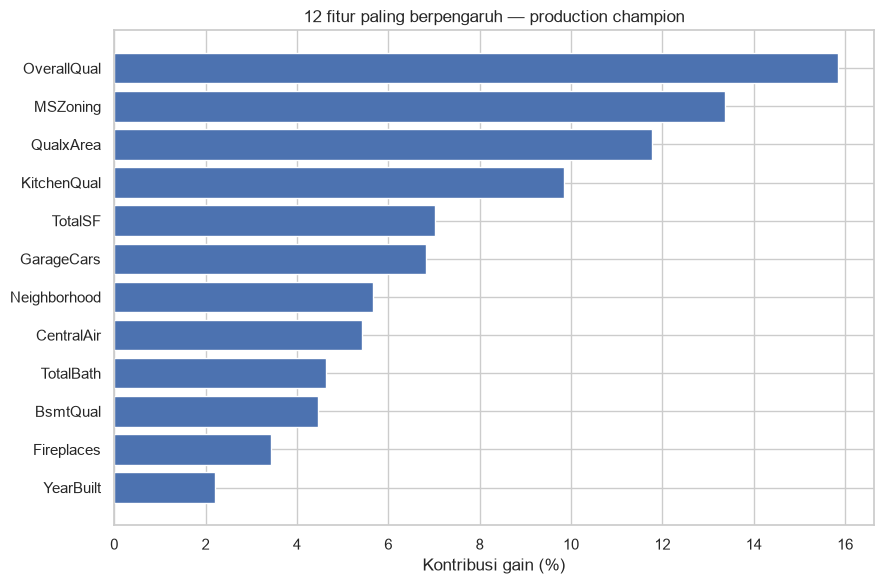

Kontribusi fitur turunan : 23.4% dari total gain


In [106]:
# Ambil object production langsung dari artifact yang sudah di-reload.
production_model_loaded = bundle["model"]
production_preprocessor_loaded = bundle["preprocessor"]

# Ambil nama kolom hasil preprocessing production.
production_encoded_names = (
    production_preprocessor_loaded
    .get_feature_names_out()
)

# Ambil Booster XGBoost untuk membaca gain importance.
production_booster = (
    production_model_loaded
    .get_booster()
)

production_gain_scores = (
    production_booster.get_score(
        importance_type="gain"
    )
)

# XGBoost biasanya menggunakan nama internal f0, f1, f2, dst.
# Fitur yang tidak digunakan diberi nilai 0.
production_gain = np.array([
    production_gain_scores.get(
        f"f{i}",
        0.0,
    )
    for i in range(
        len(production_encoded_names)
    )
])

# Pastikan jumlah kolom dan importance sama.
assert len(production_encoded_names) == len(
    production_gain
)

# Pastikan model benar-benar memiliki gain importance.
gain_total = production_gain.sum()

assert gain_total > 0, (
    "Gain importance production tidak ditemukan."
)

# Normalisasi gain agar totalnya menjadi 100%.
production_gain_pct = (
    production_gain
    / gain_total
    * 100
)

production_importance = pd.DataFrame({
    "encoded": production_encoded_names,
    "gain": production_gain,
    "gain_%": production_gain_pct,
})


def fitur_asal_production(name):
    """Kembalikan nama fitur asli dari kolom hasil encoding."""
    name = str(name)

    if name.startswith("num__"):
        return name.replace("num__", "", 1)

    if name.startswith("cat__"):
        encoded_name = name.replace(
            "cat__",
            "",
            1,
        )

        # Gunakan nama field API agar one-hot dapat
        # dikembalikan ke fitur asalnya.
        for feature in sorted(
            API_CONTRACT,
            key=len,
            reverse=True,
        ):
            if (
                encoded_name == feature
                or encoded_name.startswith(
                    feature + "_"
                )
            ):
                return feature

        return encoded_name

    return name


# Kembalikan setiap kolom encoded ke fitur aslinya.
production_importance["fitur"] = (
    production_importance["encoded"]
    .map(fitur_asal_production)
)

# Gabungkan importance dari seluruh kolom one-hot
# yang berasal dari fitur asli yang sama.
production_importance = (
    production_importance
    .groupby(
        "fitur",
        as_index=False,
    )["gain"]
    .sum()
    .sort_values(
        "gain",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Hitung kembali persentase setelah agregasi.
gain_total = production_importance["gain"].sum()

production_importance["gain_%"] = (
    production_importance["gain"]
    / gain_total
    * 100
)

# Tandai apakah fitur dibuat dari input user atau
# dihitung server.
production_importance["jenis"] = np.where(
    production_importance["fitur"].isin(
        API_ENGINEERED
    ),
    "fitur turunan",
    "field user",
)

print("=== FEATURE IMPORTANCE — PRODUCTION CHAMPION ===")
display(
    production_importance
    .head(12)
    .round({
        "gain": 4,
        "gain_%": 2,
    })
)

# Visualisasi 12 fitur dengan gain terbesar.
atas = (
    production_importance
    .head(12)
    .iloc[::-1]
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.barh(
    atas["fitur"],
    atas["gain_%"],
)

ax.set_xlabel(
    "Kontribusi gain (%)"
)
ax.set_title(
    "12 fitur paling berpengaruh — production champion"
)

plt.tight_layout()

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

feature_importance_path = (
    FIGURES_DIR
    / "feature_importance_api_champion.png"
)

plt.savefig(
    feature_importance_path,
    dpi=120,
    bbox_inches="tight",
)

plt.show()

# Hitung total gain dari fitur yang dibuat server.
porsi_turunan = production_importance.loc[
    production_importance["fitur"].isin(
        API_ENGINEERED
    ),
    "gain_%",
].sum()

print(
    f"Kontribusi fitur turunan : "
    f"{porsi_turunan:.1f}% dari total gain"
)

### Interpretasi — Feature Importance Production

Pada hasil production saat ini, fitur dengan gain terbesar adalah:

- `OverallQual` = **15,84%**
- `MSZoning` = **13,38%**
- `QualxArea` = **11,76%**
- `KitchenQual` = **9,84%**
- `TotalSF` = **7,02%**
- `GarageCars` = **6,83%**

Tiga fitur turunan secara keseluruhan menyumbang sekitar **23,4%** dari total gain.

**Artinya:** model production banyak menggunakan informasi tentang **kualitas, ukuran, karakteristik, dan lokasi rumah**.

Gain tetap bukan hubungan sebab-akibat. Nilai 15,84% pada `OverallQual` tidak berarti perubahan satu poin pada `OverallQual` akan mengubah harga sebesar 15,84%.

**Kesimpulan:** feature importance digunakan untuk memahami perilaku model dan menentukan fitur yang layak diperhatikan saat monitoring.

### 13.11 Final Production Checkpoint

Sebelum handoff, saya melakukan satu pemeriksaan terakhir terhadap **artifact yang sudah di-reload**.

Tujuannya bukan melakukan evaluasi ulang, tetapi memastikan:

**model → preprocessing → kontrak → metric → artifact**

benar-benar konsisten.

In [107]:
# Pastikan artifact sudah berhasil dimuat pada Section 13.9.
assert "bundle" in globals(), (
    "bundle belum tersedia. Jalankan Section 13.9 terlebih dahulu."
)

# Pastikan object utama artifact tersedia.
required_keys = [
    "model",
    "preprocessor",
    "model_name",
    "model_type",
    "api_contract_fields",
    "api_contract_numeric",
    "api_contract_categorical",
    "api_contract_types",
    "api_allowed_values",
    "engineered_features",
    "model_columns",
    "contract_hash",
    "hyperparameters",
    "cv_rmse_log",
    "cv_rmse_log_std",
    "holdout_rmse_log",
    "holdout_mae_usd",
    "holdout_r2",
    "training_rows",
    "holdout_rows",
    "encoded_columns",
]

missing_keys = [
    key
    for key in required_keys
    if key not in bundle
]

assert not missing_keys, (
    f"Metadata artifact tidak lengkap: {missing_keys}"
)

# Pastikan jumlah field user sesuai dengan kontrak.
assert len(
    bundle["api_contract_fields"]
) == 20

# Pastikan tiga fitur turunan dan total kolom model sesuai.
assert bundle["engineered_features"] == API_ENGINEERED
assert len(bundle["model_columns"]) == 23

# Pastikan tidak ada leakage pada kolom model.
assert not (
    set(bundle["model_columns"])
    & set(leakage_features)
)

# Pastikan jumlah data sesuai dengan proses final.
assert bundle["training_rows"] == len(full) == 1460
assert bundle["holdout_rows"] == len(
    holdout_api
) == 290

# Pastikan jumlah kolom encoded yang disimpan
# benar-benar sama dengan preprocessor dan model.
encoded_from_preprocessor = len(
    bundle["preprocessor"]
    .get_feature_names_out()
)

encoded_from_model = (
    bundle["model"]
    .get_booster()
    .num_features()
)

assert bundle["encoded_columns"] == (
    encoded_from_preprocessor
)

assert bundle["encoded_columns"] == (
    encoded_from_model
)

# Hitung ulang contract hash dari isi artifact.
checkpoint_contract_definition = {
    "fields": bundle["api_contract_fields"],
    "numeric_fields": bundle["api_contract_numeric"],
    "categorical_fields": bundle["api_contract_categorical"],
    "field_types": bundle["api_contract_types"],
    "allowed_values": bundle["api_allowed_values"],
    "engineered_features": bundle["engineered_features"],
    "model_columns": bundle["model_columns"],
}

checkpoint_hash = hashlib.sha256(
    json.dumps(
        checkpoint_contract_definition,
        ensure_ascii=False,
        sort_keys=True,
    ).encode("utf-8")
).hexdigest()

assert checkpoint_hash == bundle["contract_hash"]

# Pastikan metric artifact sama dengan hasil final holdout
# dan CV yang baru saja digunakan.
assert np.isclose(
    bundle["cv_rmse_log"],
    api_cv_mean,
)

assert np.isclose(
    bundle["cv_rmse_log_std"],
    api_cv_std,
)

assert np.isclose(
    bundle["holdout_rmse_log"],
    api_holdout_rmse_log,
)

assert np.isclose(
    bundle["holdout_mae_usd"],
    api_holdout_mae_usd,
)

assert np.isclose(
    bundle["holdout_r2"],
    api_holdout_r2,
)

# Ringkasan checkpoint final.
production_checkpoint = pd.DataFrame([{
    "model_name": bundle["model_name"],
    "model_type": bundle["model_type"],
    "user_fields": len(
        bundle["api_contract_fields"]
    ),
    "model_columns": len(
        bundle["model_columns"]
    ),
    "encoded_columns": bundle[
        "encoded_columns"
    ],
    "training_rows": bundle[
        "training_rows"
    ],
    "holdout_rows": bundle[
        "holdout_rows"
    ],
    "CV_RMSE_log": bundle[
        "cv_rmse_log"
    ],
    "CV_std": bundle[
        "cv_rmse_log_std"
    ],
    "Holdout_RMSE_log": bundle[
        "holdout_rmse_log"
    ],
    "Holdout_MAE_USD": bundle[
        "holdout_mae_usd"
    ],
    "Holdout_R2": bundle[
        "holdout_r2"
    ],
    "contract_hash": bundle[
        "contract_hash"
    ][:12] + "...",
}])

print("=== FINAL PRODUCTION CHECKPOINT ===")
display(
    production_checkpoint.round(5)
)

print("STATUS : PASS")

=== FINAL PRODUCTION CHECKPOINT ===


,model_name,model_type,user_fields,model_columns,encoded_columns,training_rows,holdout_rows,CV_RMSE_log,CV_std,Holdout_RMSE_log,Holdout_MAE_USD,Holdout_R2,contract_hash
0,house_price_xgb_api_contract_v1,XGBRegressor,20,23,65,1460,290,0.12581,0.01548,0.13139,15439.67383,0.92599,bd3ca3f39ffa...


STATUS : PASS


### Interpretasi — Final Production Checkpoint

Checkpoint final memastikan artifact yang digunakan production sudah konsisten:

- **20 field user**
- **23 kolom model**
- **encoded columns sesuai dengan preprocessor dan model**
- **XGBoost tunggal**
- training ulang pada **1460 baris**
- holdout production **290 baris**
- metric CV dan holdout sama dengan hasil evaluasi final;
- contract hash tetap sama setelah reload.

**Keputusan:** artifact production dinyatakan siap untuk dibawa ke code production. Tidak ada tuning atau perubahan model lagi.

## 14. Business Insights, Limitations & Conclusion

Bagian ini merangkum hasil eksperimen dan keputusan final dalam bahasa yang lebih mudah dipahami.

### 14.1 Business Insights

Beberapa insight utama dari eksperimen:

1. **Kualitas rumah sangat penting.**  
   `OverallQual`, `KitchenQual`, dan fitur kualitas lain termasuk informasi yang banyak digunakan model.

2. **Ukuran rumah juga penting.**  
   `GrLivArea`, `TotalSF`, dan `QualxArea` membantu model menggambarkan ukuran rumah.

3. **Lokasi ikut berperan.**  
   `Neighborhood` dan `MSZoning` termasuk fitur yang cukup penting pada model production.

4. **Menambah field tidak otomatis berarti feature engineering harus ikut ditambah.**  
   Pada kontrak API, 20 field tanpa FE menghasilkan **0.12534**, sedangkan 20 field + Basic FE menghasilkan **0.12581**.

5. **Outlier tidak otomatis harus dibuang.**  
   Eksperimen sebelumnya menunjukkan penghapusan outlier justru memperburuk performa.

6. **Model yang lebih sederhana dapat lebih tepat untuk production.**  
   Blend memang sedikit lebih baik pada CV kontrak API, tetapi improvement hanya **0,47%**, sehingga XGBoost tunggal dipilih berdasarkan aturan keputusan yang sudah ditetapkan.

7. **Sebagian error berasal dari informasi yang tidak tersedia di kontrak.**  
   Dua rumah dapat terlihat sama dari field yang digunakan model tetapi tetap memiliki harga berbeda.

### 14.2 Limitations

Beberapa keterbatasan harus dicatat secara terbuka:

- Dataset hanya memiliki **1460 baris** dan berasal dari Ames Housing.
- Data berasal dari periode **2006–2010**, sehingga model tidak otomatis berlaku untuk kondisi pasar saat ini.
- Generalisasi ke kota atau wilayah lain belum terbukti.
- Beberapa informasi transaksi seperti `MoSold`, `YrSold`, `SaleType`, dan `SaleCondition` tidak digunakan dalam production karena tidak dianggap tersedia saat prediction.
- `OverallQual` merupakan penilaian yang bersifat subjektif, sehingga perbedaan cara input dapat memengaruhi prediksi.
- Holdout production berjumlah **290 baris** setelah 2 baris kembar-fitur dikeluarkan.
- Holdout production dievaluasi setelah proses pengembangan utama selesai, tetapi evaluasi holdout pada Section 11 dan production holdout merupakan **dua evaluasi yang berbeda**. Karena itu angka keduanya tidak boleh dianggap sebagai satu pengujian yang sama.
- Metric holdout production berasal dari model yang dilatih pada **1168 baris train yang sudah dipurifikasi**, sedangkan artifact final dilatih ulang pada **1460 baris**.
- Feature importance menjelaskan perilaku model, bukan hubungan sebab-akibat.
- Beberapa observasi masih memiliki error besar, sehingga prediksi pada kasus ekstrem perlu diperhatikan.

### 14.3 Final Conclusion

Notebook ini tidak berhenti pada mencari score terbaik.

Saya membangun proses yang dimulai dari:

**Business Understanding → Data Audit → EDA → Feature Hypothesis → CV → Model Comparison → Tuning → Advanced Experiment → Champion Selection → Holdout Evaluation → Error Analysis → Production Contract → Final Artifact**

Hasil production saat ini:

**Production Champion**
- Model: **XGBoost tunggal**
- Input user: **20 field**
- Fitur turunan: **3**
- Kolom model: **23**
- CV RMSE Log: **0.12581 ± 0.01548**
- Holdout RMSE Log: **0.13139**
- Holdout MAE: **$15,439.67**
- Holdout R²: **0.92599**
- Holdout: **290 baris**
- Training final artifact: **1460 baris**

Model sudah melewati quality gate, holdout evaluation, error analysis, artifact export, dan reload test.

Setelah ini fokus berpindah dari eksperimen model ke **rekayasa sistem**: modular code, MLflow, FastAPI, monitoring, Docker, dan Streamlit.

## 15. Handoff ke Production

Eksperimen model sudah selesai. Bagian ini menjadi jembatan dari notebook menuju code production.

Yang dibawa ke production bukan hanya file model, tetapi juga **aturan preprocessing, kontrak API, feature engineering, metric, dan batasan model**.

### 15.1 Ringkasan Model Production

| Komponen | Keputusan final |
|---|---|
| Model | **XGBoost tunggal** |
| Field user | **20** |
| Fitur turunan | **3** |
| Kolom model | **23** |
| Target | `log1p(SalePrice)` |
| Inverse target | `expm1` |
| Outlier | Tidak dihapus otomatis |
| Leakage | `MoSold`, `YrSold`, `SaleType`, `SaleCondition` dikeluarkan |
| CV RMSE Log | **0.12581 ± 0.01548** |
| Holdout RMSE Log | **0.13139** |
| Holdout MAE | **$15,439.67** |
| Holdout R² | **0.92599** |
| Final training rows | **1460** |
| Production holdout | **290** |

### 15.2 Kontrak API Final

Kontrak API adalah **20 field yang diisi user**. Tiga fitur turunan dihitung di server.

#### Numerik

| Field | Tipe |
|---|---|
| `OverallQual` | int |
| `OverallCond` | int |
| `GrLivArea` | float |
| `TotalBsmtSF` | float |
| `LotArea` | float |
| `YearBuilt` | int |
| `YearRemodAdd` | int |
| `GarageCars` | int |
| `FullBath` | int |
| `HalfBath` | int |
| `BsmtFullBath` | int |
| `BsmtHalfBath` | int |
| `Fireplaces` | int |

#### Kategorikal

| Field | Keterangan |
|---|---|
| `Neighborhood` | nilai harus berasal dari daftar training |
| `MSZoning` | nilai harus berasal dari daftar training |
| `ExterQual` | nilai kualitas |
| `BsmtQual` | termasuk `"None"` untuk tidak ada basement |
| `KitchenQual` | nilai kualitas |
| `HeatingQC` | nilai kualitas |
| `CentralAir` | `Y` / `N` |

#### Fitur yang dihitung server

```text
TotalSF   = TotalBsmtSF + GrLivArea

TotalBath = FullBath
          + 0.5 × HalfBath
          + BsmtFullBath
          + 0.5 × BsmtHalfBath

QualxArea = OverallQual × GrLivArea
```

User tidak perlu mengisi tiga fitur tersebut.

In [108]:
# Buat spesifikasi kontrak dari data training yang digunakan artifact.
api_numeric_spec = pd.DataFrame([
    {
        "field": field,
        "type": API_FIELD_TYPES[field],
        "min_training": full[field].min(),
        "max_training": full[field].max(),
    }
    for field in API_CONTRACT_NUM
])

api_categorical_spec = pd.DataFrame([
    {
        "field": field,
        "allowed_values": API_ALLOWED_VALUES[field],
        "n_values": len(API_ALLOWED_VALUES[field]),
    }
    for field in API_CONTRACT_CAT
])

print("=== API NUMERIC SPEC ===")
display(api_numeric_spec)

print("=== API CATEGORICAL SPEC ===")
display(api_categorical_spec)

=== API NUMERIC SPEC ===


,field,type,min_training,max_training
0,OverallQual,int,1,10
1,OverallCond,int,1,9
2,GrLivArea,float,334,5642
3,TotalBsmtSF,float,0,6110
4,LotArea,float,1300,215245
5,YearBuilt,int,1872,2010
6,YearRemodAdd,int,1950,2010
7,GarageCars,int,0,4
8,FullBath,int,0,3
9,HalfBath,int,0,2


=== API CATEGORICAL SPEC ===


,field,allowed_values,n_values
0,Neighborhood,"[Blmngtn, Blueste, BrDale, BrkSide, ClearCr, C...",25
1,MSZoning,"[C (all), FV, RH, RL, RM]",5
2,ExterQual,"[Ex, Fa, Gd, TA]",4
3,BsmtQual,"[Ex, Fa, Gd, None, TA]",5
4,KitchenQual,"[Ex, Fa, Gd, TA]",4
5,HeatingQC,"[Ex, Fa, Gd, Po, TA]",5
6,CentralAir,"[N, Y]",2


**Catatan:** batas numerik di atas berasal dari data training. Batas tersebut cocok untuk menjaga kontrak tetap sesuai dengan ruang data eksperimen, tetapi tidak boleh dianggap sebagai batas pasar properti secara umum.

Jika model digunakan untuk pasar atau periode baru, kontrak dan validasinya perlu ditinjau kembali bersama data baru.

### 15.3 Artifact

File utama:

`models/house_price_champion.joblib`

File metadata:

`models/house_price_champion_metadata.json`

Artifact utama berisi:

| Isi | Fungsi |
|---|---|
| `preprocessor` | mengubah input user menjadi format model |
| `model` | XGBoost production |
| `api_contract_*` | sumber kontrak API |
| `api_allowed_values` | daftar nilai kategorikal yang valid |
| `model_columns` | menjaga urutan kolom |
| `engineered_features` | daftar fitur yang dihitung server |
| `target_transformation` | `log1p` |
| `inverse_transformation` | `expm1` |
| `hyperparameters` | parameter model |
| `cv_*` dan `holdout_*` | bukti performa |
| `contract_hash` | identitas kontrak |
| `training_rows` | jumlah data yang digunakan untuk retraining |

Metadata JSON menyimpan informasi yang sama kecuali object model dan preprocessor.

### 15.4 Mapping Notebook ke Code Production

| Bagian notebook | Dibawa ke | Fungsi |
|---|---|---|
| Data loading & validation | `src/data/data_loader.py` | membaca dan memvalidasi data |
| Missing value & preprocessing | `src/data/data_preprocessor.py` | preprocessing dan feature engineering |
| Model definition | `src/models/model.py` | membuat XGBoost |
| Training & quality gate | `src/models/trainer.py` | CV, gate, retraining, export |
| Artifact | `models/house_price_champion.joblib` | model + preprocessing + contract |
| Contract | `api/schemas.py` | validasi input Pydantic |
| Inference | `api/service.py` / `api/main.py` | jalur prediction |
| Logging | service/API layer | mencatat request dan prediction |
| Drift monitoring | `src/monitor.py` | memantau perubahan data |
| UI | Streamlit | input user dan tampilan prediction |

### 15.5 Batasan yang Dibawa ke Production

Beberapa catatan harus tetap terlihat setelah notebook dipindahkan menjadi service:

- model berasal dari dataset Ames Housing;
- data training berasal dari periode 2006–2010;
- prediksi pada kondisi yang jauh dari data training perlu dipantau;
- `OverallQual` dan beberapa input lain bersifat subjektif;
- rumah dengan informasi kontrak yang sama masih dapat memiliki harga berbeda;
- error besar pada rumah ekstrem tetap mungkin terjadi;
- perubahan distribusi input perlu dipantau sebelum dianggap sebagai masalah model.

Batasan ini bukan alasan untuk tidak melakukan deployment. Justru batasan tersebut menjadi dasar untuk **monitoring, alerting, dan evaluasi model berikutnya**.

### 15.6 Final Handoff Checklist

Sebelum notebook ditutup, checklist production sudah terpenuhi:

- [x] Feature set production sudah ditentukan.
- [x] Leakage sudah diaudit.
- [x] Preprocessing dilakukan tanpa leakage.
- [x] Kontrak API berisi 20 field.
- [x] Fitur turunan dihitung server.
- [x] XGBoost dipilih sebagai single production model.
- [x] Quality gate lolos.
- [x] Holdout production sudah dievaluasi.
- [x] Error analysis sudah dilakukan.
- [x] Artifact final dilatih ulang pada seluruh data berlabel.
- [x] Artifact berhasil di-reload.
- [x] Contract hash tersedia.
- [x] Feature importance production sudah dianalisis.
- [x] Final production checkpoint lolos.

**Eksperimen selesai.**

Tahap berikutnya adalah pekerjaan rekayasa production: **modular code → MLflow → FastAPI → logging & monitoring → Docker → Streamlit**.